In [1]:
# ======================================================================================
# ASD-ContextFusion
# REVIEWER-REQUESTED LIGHTWEIGHT ADDITIONAL ANALYSES
#
# IMPORTANT:
#   - NO NT-v2 embedding generation
#   - NO XGBoost refitting
#   - NO logistic model refitting
#   - NO PU resampling
#   - NO strict fusion rerun
#   - ONLY frozen saved results are used
# ======================================================================================

from pathlib import Path
import hashlib
import json
import time

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

from scipy.stats import hypergeom


# ======================================================================================
# 0. PROJECT PATH
# ======================================================================================

ROOT = Path(r"E:\ASD_ContextFusion_Q1")


CONTROL_SCORE_FILE = (
    ROOT /
    "05_results" /
    "proposed" /
    "sequence_controls" /
    "Context_NTv2_LengthGC_4mer_gene_level_OOF_scores.tsv"
)


FUSION_SCORE_FILE = (
    ROOT /
    "05_results" /
    "proposed" /
    "strict_context_NTv2_fusion" /
    "StrictFusion_gene_level_OOF_scores.tsv"
)


STAGE9C_RANK_FILE = (
    ROOT /
    "05_results" /
    "proposed" /
    "stage9C_external_validation" /
    "Stage9C_nonseed_18062_model_ranks.tsv.gz"
)


STAGE9D_RANK_FILE = (
    ROOT /
    "05_results" /
    "proposed" /
    "stage9D_external_sequence_controls" /
    "Stage9D_nonseed_18062_sequence_model_ranks.tsv.gz"
)


EXT_DIR = (
    ROOT /
    "02_interim" /
    "external_validation_source_lock"
)


OUT_DIR = (
    ROOT /
    "05_results" /
    "proposed" /
    "reviewer_requested_additional_analyses"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ======================================================================================
# CONSTANTS
# ======================================================================================

N_TOTAL = 18252
N_SEEDS = 190
N_NONSEED = 18062

BOOTSTRAP_REPS = 5000
BOOTSTRAP_SEED = 20260830


# ======================================================================================
# HELPERS
# ======================================================================================

def sha256_file(path, chunk_size=1024 * 1024):

    h = hashlib.sha256()

    with open(path, "rb") as f:

        while True:

            chunk = f.read(chunk_size)

            if not chunk:
                break

            h.update(chunk)

    return h.hexdigest()


def bh_adjust(pvalues):

    p = np.asarray(
        pvalues,
        dtype=float
    )

    m = len(p)

    order = np.argsort(p)

    ranked = p[order]

    adjusted = (
        ranked *
        m /
        np.arange(
            1,
            m + 1
        )
    )

    adjusted = np.minimum.accumulate(
        adjusted[::-1]
    )[::-1]

    adjusted = np.clip(
        adjusted,
        0,
        1
    )

    result = np.empty(
        m,
        dtype=float
    )

    result[order] = adjusted

    return result


# ======================================================================================
# INPUT QC
# ======================================================================================

required_files = [
    CONTROL_SCORE_FILE,
    FUSION_SCORE_FILE,
    STAGE9C_RANK_FILE,
    STAGE9D_RANK_FILE
]

for path in required_files:

    if not path.exists():
        raise FileNotFoundError(
            f"MISSING REQUIRED FILE:\n{path}"
        )

    print("[OK]", path)


print("\nOUTPUT DIRECTORY:")
print(OUT_DIR)

[OK] E:\ASD_ContextFusion_Q1\05_results\proposed\sequence_controls\Context_NTv2_LengthGC_4mer_gene_level_OOF_scores.tsv
[OK] E:\ASD_ContextFusion_Q1\05_results\proposed\strict_context_NTv2_fusion\StrictFusion_gene_level_OOF_scores.tsv
[OK] E:\ASD_ContextFusion_Q1\05_results\proposed\stage9C_external_validation\Stage9C_nonseed_18062_model_ranks.tsv.gz
[OK] E:\ASD_ContextFusion_Q1\05_results\proposed\stage9D_external_sequence_controls\Stage9D_nonseed_18062_sequence_model_ranks.tsv.gz

OUTPUT DIRECTORY:
E:\ASD_ContextFusion_Q1\05_results\proposed\reviewer_requested_additional_analyses


In [2]:
# ======================================================================================
# STEP 1
# LOAD EXISTING GENE-LEVEL OOF SCORES
# ======================================================================================

control = pd.read_csv(
    CONTROL_SCORE_FILE,
    sep="\t"
)


fusion = pd.read_csv(
    FUSION_SCORE_FILE,
    sep="\t"
)


print("Control file shape:", control.shape)
print("Fusion file shape :", fusion.shape)

print("\nControl columns:")
print(control.columns.tolist())

print("\nFusion columns:")
print(fusion.columns.tolist())


# ======================================================================================
# REQUIRED COLUMNS
# ======================================================================================

required_control = {
    "Gene_Name",
    "known_gene",
    "Context_probability",
    "NT_probability",
    "LengthGC_probability",
    "Fourmer_probability"
}


required_fusion = {
    "Gene_Name",
    "known_gene",
    "Context_probability",
    "NT_probability",
    "Fusion_probability"
}


assert required_control.issubset(
    control.columns
)

assert required_fusion.issubset(
    fusion.columns
)


# ======================================================================================
# BASIC IDENTITY CHECKS
# ======================================================================================

assert len(control) == N_TOTAL
assert len(fusion) == N_TOTAL

assert control["Gene_Name"].nunique() == N_TOTAL
assert fusion["Gene_Name"].nunique() == N_TOTAL

assert int(control["known_gene"].sum()) == N_SEEDS
assert int(fusion["known_gene"].sum()) == N_SEEDS


# ======================================================================================
# MERGE
# ======================================================================================

scores = control[
    [
        "Gene_Name",
        "known_gene",
        "Context_probability",
        "NT_probability",
        "LengthGC_probability",
        "Fourmer_probability"
    ]
].merge(

    fusion[
        [
            "Gene_Name",
            "known_gene",
            "Context_probability",
            "NT_probability",
            "Fusion_probability"
        ]
    ],

    on=[
        "Gene_Name",
        "known_gene"
    ],

    how="inner",

    suffixes=(
        "_control",
        "_fusion"
    ),

    validate="one_to_one"
)


assert len(scores) == N_TOTAL


# ======================================================================================
# VERIFY CONTEXT / NT ARE IDENTICAL ACROSS SAVED FILES
# ======================================================================================

assert np.allclose(
    scores[
        "Context_probability_control"
    ],
    scores[
        "Context_probability_fusion"
    ],
    atol=1e-12,
    rtol=0
)


assert np.allclose(
    scores[
        "NT_probability_control"
    ],
    scores[
        "NT_probability_fusion"
    ],
    atol=1e-12,
    rtol=0
)


# ======================================================================================
# CLEAN FINAL SCORE TABLE
# ======================================================================================

scores = pd.DataFrame(
    {
        "Gene_Name":
            scores["Gene_Name"],

        "known_gene":
            scores["known_gene"].astype(int),

        "Context":
            scores["Context_probability_control"],

        "NT-v2":
            scores["NT_probability_control"],

        "Length+GC":
            scores["LengthGC_probability"],

        "4-mer":
            scores["Fourmer_probability"],

        "Fusion":
            scores["Fusion_probability"]
    }
)


# finite check
model_columns = [
    "Context",
    "NT-v2",
    "Length+GC",
    "4-mer",
    "Fusion"
]


for col in model_columns:

    assert np.isfinite(
        scores[col]
    ).all()


assert len(scores) == 18252
assert scores["Gene_Name"].is_unique
assert int(scores["known_gene"].sum()) == 190


print("\nFINAL MERGED TABLE:")
print(scores.shape)

print(
    scores.head()
)

print("\nSEEDS:", scores["known_gene"].sum())
print(
    "NON-SEEDS:",
    (scores["known_gene"] == 0).sum()
)

print("\nSTEP 1 COMPLETE [OK]")

Control file shape: (18252, 7)
Fusion file shape : (18252, 6)

Control columns:
['Gene_Name', 'known_gene', 'Context_probability', 'NT_probability', 'OOF_prediction_count', 'LengthGC_probability', 'Fourmer_probability']

Fusion columns:
['Gene_Name', 'known_gene', 'Context_probability', 'NT_probability', 'Fusion_probability', 'OOF_prediction_count']

FINAL MERGED TABLE:
(18252, 7)
  Gene_Name  known_gene   Context     NT-v2  Length+GC     4-mer    Fusion
0      A1BG           0  0.040623  0.010716   0.281130  0.000909  0.057729
1      A1CF           0  0.055652  0.194614   0.669132  0.313807  0.075926
2       A2M           0  0.115010  0.267630   0.323393  0.609891  0.119528
3     A2ML1           0  0.036925  0.140425   0.379912  0.361494  0.077687
4   A3GALT2           0  0.055033  0.136340   0.184737  0.000611  0.075939

SEEDS: 190
NON-SEEDS: 18062

STEP 1 COMPLETE [OK]


In [3]:
# ======================================================================================
# STEP 2
# REVIEWER #13 — PREDICTION / RANK CORRELATION ANALYSIS
# ======================================================================================

MODEL_ORDER = [
    "Context",
    "NT-v2",
    "Length+GC",
    "4-mer",
    "Fusion"
]


# ======================================================================================
# 2A. ALL GENES
# ======================================================================================

spearman_all = (
    scores[
        MODEL_ORDER
    ]
    .corr(
        method="spearman"
    )
)


# ======================================================================================
# 2B. NON-SEED GENES ONLY
# ======================================================================================

nonseed_scores = (
    scores.loc[
        scores["known_gene"] == 0
    ]
    .copy()
)


assert len(nonseed_scores) == 18062


spearman_nonseed = (
    nonseed_scores[
        MODEL_ORDER
    ]
    .corr(
        method="spearman"
    )
)


print("=" * 90)
print("SPEARMAN CORRELATION — ALL 18,252 GENES")
print("=" * 90)

print(
    spearman_all.round(4)
)


print("\n" + "=" * 90)
print("SPEARMAN CORRELATION — 18,062 NON-SEED GENES")
print("=" * 90)

print(
    spearman_nonseed.round(4)
)


# ======================================================================================
# SAVE MATRICES
# ======================================================================================

spearman_all.to_csv(
    OUT_DIR /
    "Reviewer13_Spearman_all_18252_genes.tsv",
    sep="\t"
)


spearman_nonseed.to_csv(
    OUT_DIR /
    "Reviewer13_Spearman_nonseed_18062_genes.tsv",
    sep="\t"
)


print("\nSaved correlation matrices [OK]")

SPEARMAN CORRELATION — ALL 18,252 GENES
           Context   NT-v2  Length+GC   4-mer  Fusion
Context     1.0000  0.5185     0.4170  0.2881  0.8540
NT-v2       0.5185  1.0000     0.6201  0.3708  0.8051
Length+GC   0.4170  0.6201     1.0000 -0.0087  0.5264
4-mer       0.2881  0.3708    -0.0087  1.0000  0.3685
Fusion      0.8540  0.8051     0.5264  0.3685  1.0000

SPEARMAN CORRELATION — 18,062 NON-SEED GENES
           Context   NT-v2  Length+GC   4-mer  Fusion
Context     1.0000  0.5069     0.4061  0.2769  0.8496
NT-v2       0.5069  1.0000     0.6137  0.3611  0.8008
Length+GC   0.4061  0.6137     1.0000 -0.0215  0.5177
4-mer       0.2769  0.3611    -0.0215  1.0000  0.3589
Fusion      0.8496  0.8008     0.5177  0.3589  1.0000

Saved correlation matrices [OK]


In [4]:
# ======================================================================================
# STEP 2B
# CREATE PAIRWISE CORRELATION TABLE
# ======================================================================================

pairwise_rows = []


for scope_name, corr_matrix, n_genes in [

    (
        "All genes",
        spearman_all,
        18252
    ),

    (
        "Non-seed genes",
        spearman_nonseed,
        18062
    )
]:

    for i in range(
        len(MODEL_ORDER)
    ):

        for j in range(
            i + 1,
            len(MODEL_ORDER)
        ):

            model_a = MODEL_ORDER[i]
            model_b = MODEL_ORDER[j]

            pairwise_rows.append(
                {
                    "analysis_scope":
                        scope_name,

                    "n_genes":
                        n_genes,

                    "model_A":
                        model_a,

                    "model_B":
                        model_b,

                    "Spearman_rho":
                        float(
                            corr_matrix.loc[
                                model_a,
                                model_b
                            ]
                        )
                }
            )


pairwise_corr = pd.DataFrame(
    pairwise_rows
)


pairwise_corr.to_csv(
    OUT_DIR /
    "Reviewer13_pairwise_Spearman_correlations.tsv",
    sep="\t",
    index=False
)


print(
    pairwise_corr.to_string(
        index=False
    )
)

analysis_scope  n_genes   model_A   model_B  Spearman_rho
     All genes    18252   Context     NT-v2      0.518536
     All genes    18252   Context Length+GC      0.417026
     All genes    18252   Context     4-mer      0.288101
     All genes    18252   Context    Fusion      0.854000
     All genes    18252     NT-v2 Length+GC      0.620143
     All genes    18252     NT-v2     4-mer      0.370832
     All genes    18252     NT-v2    Fusion      0.805149
     All genes    18252 Length+GC     4-mer     -0.008739
     All genes    18252 Length+GC    Fusion      0.526365
     All genes    18252     4-mer    Fusion      0.368531
Non-seed genes    18062   Context     NT-v2      0.506859
Non-seed genes    18062   Context Length+GC      0.406089
Non-seed genes    18062   Context     4-mer      0.276889
Non-seed genes    18062   Context    Fusion      0.849562
Non-seed genes    18062     NT-v2 Length+GC      0.613747
Non-seed genes    18062     NT-v2     4-mer      0.361138
Non-seed genes

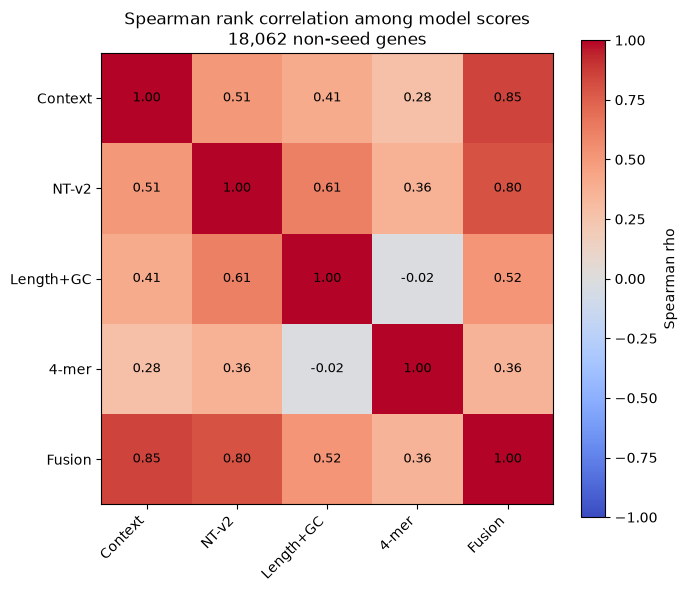

STEP 2 COMPLETE [OK]


In [5]:
# ======================================================================================
# STEP 2C
# CORRELATION MATRIX FIGURE
# NON-SEED GENES
# ======================================================================================

fig, ax = plt.subplots(
    figsize=(7, 6)
)


matrix = (
    spearman_nonseed
    .loc[
        MODEL_ORDER,
        MODEL_ORDER
    ]
)


im = ax.imshow(
    matrix.values,
    vmin=-1,
    vmax=1,
    cmap="coolwarm"
)


ax.set_xticks(
    np.arange(
        len(MODEL_ORDER)
    )
)

ax.set_yticks(
    np.arange(
        len(MODEL_ORDER)
    )
)


ax.set_xticklabels(
    MODEL_ORDER,
    rotation=45,
    ha="right"
)


ax.set_yticklabels(
    MODEL_ORDER
)


for i in range(
    len(MODEL_ORDER)
):

    for j in range(
        len(MODEL_ORDER)
    ):

        ax.text(
            j,
            i,
            f"{matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=9
        )


ax.set_title(
    "Spearman rank correlation among model scores\n"
    "18,062 non-seed genes"
)


cbar = fig.colorbar(
    im,
    ax=ax
)

cbar.set_label(
    "Spearman rho"
)


fig.tight_layout()


fig.savefig(
    OUT_DIR /
    "Reviewer13_nonseed_prediction_correlation.pdf",
    bbox_inches="tight"
)


fig.savefig(
    OUT_DIR /
    "Reviewer13_nonseed_prediction_correlation.png",
    dpi=600,
    bbox_inches="tight"
)


plt.show()


print("STEP 2 COMPLETE [OK]")

In [6]:
# ======================================================================================
# STEP 3A
# LOAD FROZEN NON-SEED RANK TABLES
# ======================================================================================

rank9c = pd.read_csv(
    STAGE9C_RANK_FILE,
    sep="\t",
    compression="gzip"
)


rank9d = pd.read_csv(
    STAGE9D_RANK_FILE,
    sep="\t",
    compression="gzip"
)


print(
    "Stage 9C:",
    rank9c.shape
)

print(
    "Stage 9D:",
    rank9d.shape
)


assert len(rank9c) == N_NONSEED
assert len(rank9d) == N_NONSEED

assert rank9c["Gene_Name"].is_unique
assert rank9d["Gene_Name"].is_unique


required9c = {
    "Gene_Name",
    "Context_rank",
    "Context_rank_percentile",
    "NTv2_rank",
    "NTv2_rank_percentile",
    "StrictFusion_rank",
    "StrictFusion_rank_percentile"
}


required9d = {
    "Gene_Name",
    "NTv2_rank",
    "NTv2_rank_percentile",
    "LengthGC_rank",
    "LengthGC_rank_percentile",
    "Fourmer_rank",
    "Fourmer_rank_percentile"
}


assert required9c.issubset(
    rank9c.columns
)

assert required9d.issubset(
    rank9d.columns
)


# ======================================================================================
# MERGE
# ======================================================================================

rank_all = rank9c.merge(

    rank9d[
        [
            "Gene_Name",
            "NTv2_rank",
            "NTv2_rank_percentile",
            "LengthGC_rank",
            "LengthGC_rank_percentile",
            "Fourmer_rank",
            "Fourmer_rank_percentile"
        ]
    ],

    on="Gene_Name",

    how="inner",

    validate="one_to_one",

    suffixes=(
        "_9C",
        "_9D"
    )
)


assert len(rank_all) == N_NONSEED


# ======================================================================================
# VERIFY NT-v2 RANK IDENTICAL IN STAGE 9C AND 9D
# ======================================================================================

assert np.array_equal(
    rank_all["NTv2_rank_9C"].to_numpy(),
    rank_all["NTv2_rank_9D"].to_numpy()
)


assert np.allclose(
    rank_all[
        "NTv2_rank_percentile_9C"
    ],
    rank_all[
        "NTv2_rank_percentile_9D"
    ],
    atol=1e-12,
    rtol=0
)


rank_all["NTv2_rank"] = (
    rank_all[
        "NTv2_rank_9C"
    ]
)


rank_all[
    "NTv2_rank_percentile"
] = (
    rank_all[
        "NTv2_rank_percentile_9C"
    ]
)


print(
    "\nMerged non-seed rank universe:",
    rank_all.shape
)

print(
    "NT-v2 Stage9C vs Stage9D rank identity: MATCH [OK]"
)

Stage 9C: (18062, 10)
Stage 9D: (18062, 10)

Merged non-seed rank universe: (18062, 18)
NT-v2 Stage9C vs Stage9D rank identity: MATCH [OK]


In [7]:
# ======================================================================================
# STEP 3B
# LOAD EXACT LOCKED EXTERNAL SETS
# ======================================================================================

SET_CONFIG = {

    "Broad134": {
        "file":
            EXT_DIR /
            "Stage9B3_Tan_All245_NONSEED_PROJECT_IDENTITIES_LOCKED.tsv",

        "expected_n":
            134
    },


    "Suggestive45": {
        "file":
            EXT_DIR /
            (
                "Stage9B3_Tan_SupplementSuggestive46_"
                "NONSEED_PROJECT_IDENTITIES_LOCKED.tsv"
            ),

        "expected_n":
            45
    },


    "NoEvidence30": {
        "file":
            EXT_DIR /
            (
                "Stage9B3_Tan_SupplementNoEvidence32_"
                "NONSEED_PROJECT_IDENTITIES_LOCKED.tsv"
            ),

        "expected_n":
            30
    },


    "LowEvidence75": {
        "file":
            EXT_DIR /
            (
                "Stage9B3_"
                "Tan_SupplementSuggestiveOrNoEvidence78_"
                "NONSEED_PROJECT_IDENTITIES_LOCKED.tsv"
            ),

        "expected_n":
            75
    }
}


external_sets = {}


for set_name, cfg in SET_CONFIG.items():

    path = cfg["file"]

    assert path.exists(), (
        f"Missing external set:\n{path}"
    )

    ext = pd.read_csv(
        path,
        sep="\t"
    )


    assert len(ext) == cfg["expected_n"]


    assert (
        "project_scoring_gene"
        in ext.columns
    )


    assert ext[
        "project_scoring_gene"
    ].is_unique


    external_sets[
        set_name
    ] = ext


    print(
        f"{set_name:15s}",
        len(ext),
        "[OK]"
    )

Broad134        134 [OK]
Suggestive45    45 [OK]
NoEvidence30    30 [OK]
LowEvidence75   75 [OK]


In [8]:
# ======================================================================================
# STEP 3C
# REVIEWER-REQUESTED FIXED TOP-K
# ======================================================================================

FIXED_K = [
    10,
    50,
    100,
    200,
    500
]


MODEL_RANK_COLUMNS = {

    "Context":
        "Context_rank",

    "NT-v2":
        "NTv2_rank",

    "Length+GC":
        "LengthGC_rank",

    "4-mer":
        "Fourmer_rank",

    "Fusion":
        "StrictFusion_rank"
}


topk_rows = []

recovered_gene_rows = []


for set_name, ext in external_sets.items():

    external_genes = (
        ext[
            "project_scoring_gene"
        ]
        .astype(str)
        .tolist()
    )


    d = rank_all.loc[
        rank_all[
            "Gene_Name"
        ].isin(
            external_genes
        )
    ].copy()


    assert len(d) == SET_CONFIG[
        set_name
    ][
        "expected_n"
    ]


    M = len(d)


    for model, rank_col in MODEL_RANK_COLUMNS.items():

        for K in FIXED_K:

            recovered_df = (
                d.loc[
                    d[
                        rank_col
                    ] <= K
                ]
                .sort_values(
                    rank_col
                )
                .copy()
            )


            recovered = len(
                recovered_df
            )


            recall = (
                recovered
                /
                M
            )


            precision_at_k = (
                recovered
                /
                K
            )


            expected_random_overlap = (
                M
                *
                K
                /
                N_NONSEED
            )


            baseline_fraction = (
                K
                /
                N_NONSEED
            )


            enrichment_fold = (
                recall
                /
                baseline_fraction
            )


            p_hyper = float(
                hypergeom.sf(
                    recovered - 1,
                    N_NONSEED,
                    M,
                    K
                )
            )


            topk_rows.append(
                {
                    "analysis_status":
                        "Reviewer-requested secondary analysis",

                    "external_set":
                        set_name,

                    "external_set_n":
                        M,

                    "model":
                        model,

                    "K":
                        K,

                    "recovered_genes":
                        recovered,

                    "recall":
                        recall,

                    "precision_at_K":
                        precision_at_k,

                    "expected_random_overlap":
                        expected_random_overlap,

                    "enrichment_fold":
                        enrichment_fold,

                    "hypergeometric_p":
                        p_hyper
                }
            )


            for _, row in recovered_df.iterrows():

                recovered_gene_rows.append(
                    {
                        "external_set":
                            set_name,

                        "model":
                            model,

                        "K":
                            K,

                        "Gene_Name":
                            row[
                                "Gene_Name"
                            ],

                        "ordinal_rank":
                            int(
                                row[
                                    rank_col
                                ]
                            )
                    }
                )


fixed_topk = pd.DataFrame(
    topk_rows
)


fixed_topk_genes = pd.DataFrame(
    recovered_gene_rows
)


# ======================================================================================
# BH CORRECTION
# Reviewer-requested analyses are secondary/post hoc.
# ======================================================================================

fixed_topk[
    "BH_FDR_q_across_reviewer_requested_tests"
] = bh_adjust(
    fixed_topk[
        "hypergeometric_p"
    ].to_numpy()
)


# ======================================================================================
# SAVE
# ======================================================================================

fixed_topk.to_csv(
    OUT_DIR /
    "Reviewer15_fixed_top10_50_100_200_500.tsv",
    sep="\t",
    index=False
)


fixed_topk_genes.to_csv(
    OUT_DIR /
    "Reviewer15_fixed_topK_recovered_genes.tsv",
    sep="\t",
    index=False
)


print(
    fixed_topk.to_string(
        index=False
    )
)


print("\nSTEP 3 COMPLETE [OK]")

                      analysis_status  external_set  external_set_n     model   K  recovered_genes   recall  precision_at_K  expected_random_overlap  enrichment_fold  hypergeometric_p  BH_FDR_q_across_reviewer_requested_tests
Reviewer-requested secondary analysis      Broad134             134   Context  10                1 0.007463           0.100                 0.074189        13.479104      7.177777e-02                              1.157706e-01
Reviewer-requested secondary analysis      Broad134             134   Context  50                6 0.044776           0.120                 0.370945        16.174925      1.811262e-06                              1.293759e-05
Reviewer-requested secondary analysis      Broad134             134   Context 100                8 0.059701           0.080                 0.741889        10.783284      7.804200e-07                              7.094727e-06
Reviewer-requested secondary analysis      Broad134             134   Context 200               

In [9]:
# ======================================================================================
# STEP 4A
# STRATIFIED GENE-LEVEL BOOTSTRAP
# INDIVIDUAL MODEL AUROC / AP + DELTA VS CONTEXT
#
# NO MODEL FITTING
# ======================================================================================

MODEL_SCORE_COLUMNS = [
    "Context",
    "NT-v2",
    "Length+GC",
    "4-mer",
    "Fusion"
]


y = (
    scores[
        "known_gene"
    ]
    .to_numpy(
        dtype=int
    )
)


positive_idx = np.flatnonzero(
    y == 1
)


unlabeled_idx = np.flatnonzero(
    y == 0
)


assert len(positive_idx) == 190
assert len(unlabeled_idx) == 18062


score_arrays = {

    model:
        scores[
            model
        ].to_numpy(
            dtype=float
        )

    for model
    in MODEL_SCORE_COLUMNS
}


# ======================================================================================
# OBSERVED VALUES
# ======================================================================================

observed_rows = []


for model in MODEL_SCORE_COLUMNS:

    observed_rows.append(
        {
            "model":
                model,

            "AUROC":
                roc_auc_score(
                    y,
                    score_arrays[
                        model
                    ]
                ),

            "AP":
                average_precision_score(
                    y,
                    score_arrays[
                        model
                    ]
                )
        }
    )


observed_metrics = pd.DataFrame(
    observed_rows
)


print("Observed metrics:")
print(
    observed_metrics.to_string(
        index=False
    )
)

Observed metrics:
    model    AUROC       AP
  Context 0.947076 0.182366
    NT-v2 0.899628 0.099593
Length+GC 0.832049 0.052922
    4-mer 0.779947 0.039135
   Fusion 0.951591 0.196525


In [10]:
# ======================================================================================
# STEP 4B
# 5000 STRATIFIED BOOTSTRAP REPLICATES
# CHECKPOINTED
# ======================================================================================

BOOT_FILE = (
    OUT_DIR /
    "Reviewer21_model_metric_bootstrap_5000.tsv.gz"
)


BOOT_BATCH = 100


bootstrap_columns = [
    "replicate"
]

for model in MODEL_SCORE_COLUMNS:

    bootstrap_columns.extend(
        [
            f"{model}__AUROC",
            f"{model}__AP"
        ]
    )


# ======================================================================================
# SAFE RESUME
# ======================================================================================

if BOOT_FILE.exists():

    boot_df = pd.read_csv(
        BOOT_FILE,
        sep="\t",
        compression="gzip"
    )


    missing = (
        set(
            bootstrap_columns
        )
        -
        set(
            boot_df.columns
        )
    )


    if missing:

        raise RuntimeError(
            f"Incompatible existing checkpoint:\n{missing}"
        )


    boot_df = (
        boot_df[
            bootstrap_columns
        ]
        .sort_values(
            "replicate"
        )
        .reset_index(
            drop=True
        )
    )


    assert boot_df[
        "replicate"
    ].is_unique


    start_rep = len(
        boot_df
    )


    print(
        "Resuming from:",
        start_rep,
        "/",
        BOOTSTRAP_REPS
    )


else:

    boot_df = pd.DataFrame(
        columns=
            bootstrap_columns
    )

    start_rep = 0

    print(
        "Starting bootstrap from replicate 0"
    )


start_time = time.time()


for batch_start in range(
    start_rep,
    BOOTSTRAP_REPS,
    BOOT_BATCH
):

    batch_end = min(
        batch_start + BOOT_BATCH,
        BOOTSTRAP_REPS
    )


    rows = []


    for b in range(
        batch_start,
        batch_end
    ):

        # deterministic replicate-specific seed
        rng = np.random.default_rng(
            np.random.SeedSequence(
                [
                    BOOTSTRAP_SEED,
                    2101,
                    b
                ]
            )
        )


        sampled_positive = rng.choice(
            positive_idx,
            size=len(
                positive_idx
            ),
            replace=True
        )


        sampled_unlabeled = rng.choice(
            unlabeled_idx,
            size=len(
                unlabeled_idx
            ),
            replace=True
        )


        idx = np.concatenate(
            [
                sampled_positive,
                sampled_unlabeled
            ]
        )


        y_b = y[idx]


        row = {
            "replicate":
                b
        }


        for model in MODEL_SCORE_COLUMNS:

            s_b = (
                score_arrays[
                    model
                ][idx]
            )


            row[
                f"{model}__AUROC"
            ] = roc_auc_score(
                y_b,
                s_b
            )


            row[
                f"{model}__AP"
            ] = average_precision_score(
                y_b,
                s_b
            )


        rows.append(
            row
        )


    batch_df = pd.DataFrame(
        rows
    )


    boot_df = pd.concat(
        [
            boot_df,
            batch_df
        ],
        ignore_index=True
    )


    boot_df.to_csv(
        BOOT_FILE,
        sep="\t",
        index=False,
        compression="gzip"
    )


    elapsed = (
        time.time()
        -
        start_time
    ) / 60


    print(
        f"{batch_end:4d}/{BOOTSTRAP_REPS} "
        f"completed | "
        f"{elapsed:.1f} min"
    )


assert len(boot_df) == BOOTSTRAP_REPS
assert boot_df["replicate"].nunique() == BOOTSTRAP_REPS


print("\nBOOTSTRAP COMPLETE [OK]")

Resuming from: 5000 / 5000

BOOTSTRAP COMPLETE [OK]


In [11]:
# ======================================================================================
# STEP 4C
# MODEL-SPECIFIC CI + DELTA VS CONTEXT
# ======================================================================================

observed_lookup = (
    observed_metrics
    .set_index(
        "model"
    )
)


metric_summary_rows = []


for model in MODEL_SCORE_COLUMNS:

    for metric in [
        "AUROC",
        "AP"
    ]:

        observed = float(
            observed_lookup.loc[
                model,
                metric
            ]
        )


        dist = (
            boot_df[
                f"{model}__{metric}"
            ]
            .to_numpy(
                dtype=float
            )
        )


        ci_low = float(
            np.quantile(
                dist,
                0.025
            )
        )


        ci_high = float(
            np.quantile(
                dist,
                0.975
            )
        )


        # --------------------------------------------------------------
        # Delta relative to Context
        # --------------------------------------------------------------

        observed_context = float(
            observed_lookup.loc[
                "Context",
                metric
            ]
        )


        observed_delta = (
            observed
            -
            observed_context
        )


        if model == "Context":

            delta_dist = np.zeros(
                len(
                    boot_df
                )
            )

        else:

            delta_dist = (
                boot_df[
                    f"{model}__{metric}"
                ].to_numpy(
                    dtype=float
                )
                -
                boot_df[
                    f"Context__{metric}"
                ].to_numpy(
                    dtype=float
                )
            )


        delta_ci_low = float(
            np.quantile(
                delta_dist,
                0.025
            )
        )


        delta_ci_high = float(
            np.quantile(
                delta_dist,
                0.975
            )
        )


        metric_summary_rows.append(
            {
                "model":
                    model,

                "metric":
                    metric,

                "observed":
                    observed,

                "CI95_low":
                    ci_low,

                "CI95_high":
                    ci_high,

                "reference_model":
                    "Context",

                "delta_vs_Context":
                    observed_delta,

                "delta_CI95_low":
                    delta_ci_low,

                "delta_CI95_high":
                    delta_ci_high,

                "n_bootstrap":
                    BOOTSTRAP_REPS
            }
        )


metric_summary = pd.DataFrame(
    metric_summary_rows
)


metric_summary.to_csv(
    OUT_DIR /
    "Reviewer21_internal_metric_CI_and_delta_vs_Context.tsv",
    sep="\t",
    index=False
)


print(
    metric_summary.to_string(
        index=False
    )
)

    model metric  observed  CI95_low  CI95_high reference_model  delta_vs_Context  delta_CI95_low  delta_CI95_high  n_bootstrap
  Context  AUROC  0.947076  0.934277   0.958192         Context          0.000000        0.000000         0.000000         5000
  Context     AP  0.182366  0.150314   0.231546         Context          0.000000        0.000000         0.000000         5000
    NT-v2  AUROC  0.899628  0.879340   0.917879         Context         -0.047447       -0.066053        -0.029927         5000
    NT-v2     AP  0.099593  0.080871   0.132325         Context         -0.082773       -0.125948        -0.044374         5000
Length+GC  AUROC  0.832049  0.804579   0.857958         Context         -0.115027       -0.140399        -0.091103         5000
Length+GC     AP  0.052922  0.042848   0.072782         Context         -0.129444       -0.174026        -0.095515         5000
    4-mer  AUROC  0.779947  0.747534   0.810770         Context         -0.167129       -0.197608       

In [12]:
# ======================================================================================
# STEP 5
# TEMPORAL MEAN RANK-PERCENTILE CI
# BROAD 134-GENE EXTERNAL SET
# ======================================================================================

broad_ext = (
    external_sets[
        "Broad134"
    ]
)


broad = broad_ext.merge(

    rank_all,

    left_on=
        "project_scoring_gene",

    right_on=
        "Gene_Name",

    how="left",

    validate="one_to_one"
)


assert len(broad) == 134
assert broad["Gene_Name"].notna().all()


MODEL_PERCENTILE_COLUMNS = {

    "Context":
        "Context_rank_percentile",

    "NT-v2":
        "NTv2_rank_percentile",

    "Length+GC":
        "LengthGC_rank_percentile",

    "4-mer":
        "Fourmer_rank_percentile",

    "Fusion":
        "StrictFusion_rank_percentile"
}


TEMP_BOOT_FILE = (
    OUT_DIR /
    "Reviewer21_temporal_mean_rank_bootstrap_5000.tsv.gz"
)


temporal_rows = []


for b in range(
    BOOTSTRAP_REPS
):

    rng = np.random.default_rng(
        np.random.SeedSequence(
            [
                BOOTSTRAP_SEED,
                2102,
                b
            ]
        )
    )


    idx = rng.choice(
        np.arange(
            len(
                broad
            )
        ),
        size=len(
            broad
        ),
        replace=True
    )


    row = {
        "replicate":
            b
    }


    for model, col in MODEL_PERCENTILE_COLUMNS.items():

        values = (
            broad[
                col
            ]
            .to_numpy(
                dtype=float
            )
        )


        row[
            model
        ] = float(
            np.mean(
                values[idx]
            )
        )


    temporal_rows.append(
        row
    )


temporal_boot = pd.DataFrame(
    temporal_rows
)


temporal_boot.to_csv(
    TEMP_BOOT_FILE,
    sep="\t",
    index=False,
    compression="gzip"
)


# ======================================================================================
# SUMMARIZE
# ======================================================================================

temporal_summary_rows = []


for model, col in MODEL_PERCENTILE_COLUMNS.items():

    observed = float(
        broad[
            col
        ].mean()
    )


    dist = (
        temporal_boot[
            model
        ]
        .to_numpy(
            dtype=float
        )
    )


    temporal_summary_rows.append(
        {
            "model":
                model,

            "temporal_set":
                "Broad134",

            "n_external_genes":
                134,

            "mean_rank_percentile":
                observed,

            "CI95_low":
                float(
                    np.quantile(
                        dist,
                        0.025
                    )
                ),

            "CI95_high":
                float(
                    np.quantile(
                        dist,
                        0.975
                    )
                )
        }
    )


temporal_summary = pd.DataFrame(
    temporal_summary_rows
)


temporal_summary.to_csv(
    OUT_DIR /
    "Reviewer21_temporal_mean_rank_percentile_CI.tsv",
    sep="\t",
    index=False
)


print(
    temporal_summary.to_string(
        index=False
    )
)

    model temporal_set  n_external_genes  mean_rank_percentile  CI95_low  CI95_high
  Context     Broad134               134             82.084263 77.931135  85.948464
    NT-v2     Broad134               134             74.754336 70.240197  79.075496
Length+GC     Broad134               134             70.979070 66.489434  75.286006
    4-mer     Broad134               134             66.852135 62.039613  71.553627
   Fusion     Broad134               134             82.101700 77.915963  85.962410


In [13]:
# ======================================================================================
# STEP 6
# FINAL REVIEWER-REQUESTED MAIN QUANTITATIVE SUMMARY TABLE
# ======================================================================================

rows = []


for model in MODEL_SCORE_COLUMNS:

    auc_row = metric_summary.loc[
        (
            metric_summary["model"] == model
        )
        &
        (
            metric_summary["metric"] == "AUROC"
        )
    ].iloc[0]


    ap_row = metric_summary.loc[
        (
            metric_summary["model"] == model
        )
        &
        (
            metric_summary["metric"] == "AP"
        )
    ].iloc[0]


    temporal_row = temporal_summary.loc[
        temporal_summary[
            "model"
        ] == model
    ].iloc[0]


    rows.append(
        {
            "Model":
                model,

            "AUROC":
                auc_row[
                    "observed"
                ],

            "AUROC_95CI_low":
                auc_row[
                    "CI95_low"
                ],

            "AUROC_95CI_high":
                auc_row[
                    "CI95_high"
                ],

            "Delta_AUROC_vs_Context":
                auc_row[
                    "delta_vs_Context"
                ],

            "Delta_AUROC_95CI_low":
                auc_row[
                    "delta_CI95_low"
                ],

            "Delta_AUROC_95CI_high":
                auc_row[
                    "delta_CI95_high"
                ],

            "AP":
                ap_row[
                    "observed"
                ],

            "AP_95CI_low":
                ap_row[
                    "CI95_low"
                ],

            "AP_95CI_high":
                ap_row[
                    "CI95_high"
                ],

            "Delta_AP_vs_Context":
                ap_row[
                    "delta_vs_Context"
                ],

            "Delta_AP_95CI_low":
                ap_row[
                    "delta_CI95_low"
                ],

            "Delta_AP_95CI_high":
                ap_row[
                    "delta_CI95_high"
                ],

            "Broad134_mean_rank_percentile":
                temporal_row[
                    "mean_rank_percentile"
                ],

            "Broad134_rank_95CI_low":
                temporal_row[
                    "CI95_low"
                ],

            "Broad134_rank_95CI_high":
                temporal_row[
                    "CI95_high"
                ]
        }
    )


main_summary = pd.DataFrame(
    rows
)


main_summary.to_csv(
    OUT_DIR /
    "Reviewer21_MAIN_quantitative_summary_table.tsv",
    sep="\t",
    index=False
)


print(
    main_summary.round(6).to_string(
        index=False
    )
)


print("\nSTEP 6 COMPLETE [OK]")

    Model    AUROC  AUROC_95CI_low  AUROC_95CI_high  Delta_AUROC_vs_Context  Delta_AUROC_95CI_low  Delta_AUROC_95CI_high       AP  AP_95CI_low  AP_95CI_high  Delta_AP_vs_Context  Delta_AP_95CI_low  Delta_AP_95CI_high  Broad134_mean_rank_percentile  Broad134_rank_95CI_low  Broad134_rank_95CI_high
  Context 0.947076        0.934277         0.958192                0.000000              0.000000               0.000000 0.182366     0.150314      0.231546             0.000000           0.000000            0.000000                      82.084263               77.931135                85.948464
    NT-v2 0.899628        0.879340         0.917879               -0.047447             -0.066053              -0.029927 0.099593     0.080871      0.132325            -0.082773          -0.125948           -0.044374                      74.754336               70.240197                79.075496
Length+GC 0.832049        0.804579         0.857958               -0.115027             -0.140399            

In [14]:
# ======================================================================================
# STEP 7
# REVIEWER-REQUESTED ANALYSIS MANIFEST
# ======================================================================================

manifest = {

    "analysis_name":
        "Reviewer-requested lightweight additional analyses",

    "analysis_status":
        "Secondary analyses added in response to reviewer comments",

    "model_refitting":
        False,

    "new_PU_sampling":
        False,

    "new_NTv2_embedding_generation":
        False,

    "new_fusion_training":
        False,

    "frozen_gene_universe":
        18252,

    "frozen_seed_count":
        190,

    "frozen_nonseed_ranking_universe":
        18062,

    "analyses_added": [
        "Spearman prediction/rank correlation",
        "Fixed top-10/50/100/200/500 recovery",
        "Model-specific AUROC/AP bootstrap confidence intervals",
        "Delta AUROC/AP versus Context",
        "Broad temporal-set mean-rank-percentile confidence intervals"
    ],

    "fixed_topk_status":
        "Reviewer-requested secondary/post-hoc analysis; not prespecified",

    "bootstrap_replicates":
        BOOTSTRAP_REPS,

    "bootstrap_seed":
        BOOTSTRAP_SEED,

    "inputs": {

        str(CONTROL_SCORE_FILE):
            sha256_file(
                CONTROL_SCORE_FILE
            ),

        str(FUSION_SCORE_FILE):
            sha256_file(
                FUSION_SCORE_FILE
            ),

        str(STAGE9C_RANK_FILE):
            sha256_file(
                STAGE9C_RANK_FILE
            ),

        str(STAGE9D_RANK_FILE):
            sha256_file(
                STAGE9D_RANK_FILE
            )
    }
}


with open(
    OUT_DIR /
    "reviewer_requested_analysis_manifest.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        manifest,
        f,
        indent=2
    )


print(
    json.dumps(
        manifest,
        indent=2
    )
)


print(
    "\nALL LIGHTWEIGHT REVIEWER ANALYSES COMPLETE [OK]"
)

{
  "analysis_name": "Reviewer-requested lightweight additional analyses",
  "analysis_status": "Secondary analyses added in response to reviewer comments",
  "model_refitting": false,
  "new_PU_sampling": false,
  "new_NTv2_embedding_generation": false,
  "new_fusion_training": false,
  "frozen_gene_universe": 18252,
  "frozen_seed_count": 190,
  "frozen_nonseed_ranking_universe": 18062,
  "analyses_added": [
    "Spearman prediction/rank correlation",
    "Fixed top-10/50/100/200/500 recovery",
    "Model-specific AUROC/AP bootstrap confidence intervals",
    "Delta AUROC/AP versus Context",
    "Broad temporal-set mean-rank-percentile confidence intervals"
  ],
  "fixed_topk_status": "Reviewer-requested secondary/post-hoc analysis; not prespecified",
  "bootstrap_replicates": 5000,
  "bootstrap_seed": 20260830,
  "inputs": {
    "E:\\ASD_ContextFusion_Q1\\05_results\\proposed\\sequence_controls\\Context_NTv2_LengthGC_4mer_gene_level_OOF_scores.tsv": "0d2d5d27de1abe56bae04dceec99741f

In [15]:
from pathlib import Path
import re

ROOT = Path(r"E:\ASD_ContextFusion_Q1")
OUT = ROOT / "NTV2_POOLING_FORENSIC_SEARCH.txt"

# Code / text files only — large binary data will not be read
TEXT_EXTS = {
    ".py", ".ipynb", ".json", ".txt", ".md",
    ".yaml", ".yml", ".log", ".sh", ".bat",
    ".ps1", ".r"
}

KEYWORDS = [
    "nucleotide-transformer-v2-50m",
    "nucleotide_transformer",
    "nucleotide-transformer",
    "NTv2",
    "nt_v2",
    "hidden_states[-1]",
    "hidden_states",
    "last_hidden_state",
    "attention_mask",
    "mean_sequence_embeddings",
    "mean pooling",
    "mean_pool",
    "pooling",
    "chunk_embeddings",
    "segment_embeddings",
    "embedding_shard",
    "shard",
    "np.save",
    "12000",
    "10800",
    "1200",
    "2048",
    "18627",
]

NAME_TERMS = [
    "ntv2", "nt_v2", "nucleotide",
    "embedding", "embed", "shard",
    "pool", "transcript"
]

MAX_FILE_MB = 50
CONTEXT = 3

results = []

def add(txt=""):
    results.append(str(txt))

add("=" * 120)
add("NT-v2 POOLING / EMBEDDING GENERATOR FORENSIC SEARCH")
add(f"ROOT: {ROOT}")
add("=" * 120)

# ------------------------------------------------------------------
# 1. Search file/folder names
# ------------------------------------------------------------------
add("\n\n[1] RELEVANT FILE / DIRECTORY NAMES")
add("-" * 120)

name_hits = []

for p in ROOT.rglob("*"):
    try:
        low = p.name.lower()
        if any(term in low for term in NAME_TERMS):
            name_hits.append(str(p))
    except Exception:
        pass

for x in sorted(name_hits):
    add(x)

add(f"\nTotal filename/path hits: {len(name_hits)}")

# ------------------------------------------------------------------
# 2. Search file contents
# ------------------------------------------------------------------
add("\n\n[2] CONTENT SEARCH")
add("-" * 120)

files_scanned = 0
files_with_hits = 0

for path in ROOT.rglob("*"):
    if not path.is_file():
        continue

    if path.suffix.lower() not in TEXT_EXTS:
        continue

    try:
        size_mb = path.stat().st_size / (1024 * 1024)
        if size_mb > MAX_FILE_MB:
            continue

        text = path.read_text(
            encoding="utf-8",
            errors="ignore"
        )

        files_scanned += 1
        lines = text.splitlines()

        file_hits = []

        for i, line in enumerate(lines):
            low = line.lower()

            matched = [
                kw for kw in KEYWORDS
                if kw.lower() in low
            ]

            if matched:
                start = max(0, i - CONTEXT)
                end = min(len(lines), i + CONTEXT + 1)

                snippet = "\n".join(
                    f"{j+1:>7}: {lines[j]}"
                    for j in range(start, end)
                )

                file_hits.append(
                    (
                        i + 1,
                        matched,
                        snippet
                    )
                )

        if file_hits:
            files_with_hits += 1

            add("\n" + "=" * 120)
            add(f"FILE: {path}")
            add(f"SIZE: {size_mb:.2f} MB")
            add(f"HITS: {len(file_hits)}")
            add("=" * 120)

            for line_no, matched, snippet in file_hits:
                add(
                    f"\n>>> LINE {line_no} | "
                    f"MATCHED: {', '.join(matched)}"
                )
                add(snippet)

    except Exception as e:
        add(f"\n[READ ERROR] {path}")
        add(str(e))

# ------------------------------------------------------------------
# 3. Finish
# ------------------------------------------------------------------
add("\n\n" + "=" * 120)
add("SUMMARY")
add("=" * 120)
add(f"Text/code files scanned : {files_scanned}")
add(f"Files containing hits   : {files_with_hits}")
add(f"Relevant name hits      : {len(name_hits)}")
add(f"Report                  : {OUT}")
add("=" * 120)

OUT.write_text(
    "\n".join(results),
    encoding="utf-8"
)

print("DONE")
print("Files scanned       :", files_scanned)
print("Files with hits     :", files_with_hits)
print("Relevant path hits  :", len(name_hits))
print("\nREPORT SAVED HERE:")
print(OUT)

DONE
Files scanned       : 9414
Files with hits     : 999
Relevant path hits  : 57

REPORT SAVED HERE:
E:\ASD_ContextFusion_Q1\NTV2_POOLING_FORENSIC_SEARCH.txt


In [16]:
from pathlib import Path
import os

# ============================================================
# NT-v2 ORIGINAL GENERATOR — WHOLE-PC FORENSIC SEARCH
# ============================================================

# Current ASD project: already scanned, so this will be skipped
PROJECT = Path(r"E:\ASD_ContextFusion_Q1")
PROJECT_LOWER = str(PROJECT).lower().rstrip("\\/")

# ============================================================
# 1. SEARCH LOCATIONS
# ============================================================

roots = []

# Search whole E: drive, except current ASD project
if Path("E:/").exists():
    roots.append(Path("E:/"))

# Common locations on C:
HOME = Path.home()

for p in [
    HOME / "Desktop",
    HOME / "Documents",
    HOME / "Downloads",
    HOME / "OneDrive",
    HOME / "Google Drive",
    HOME / "My Drive",
]:
    if p.exists():
        roots.append(p)

# ------------------------------------------------------------
# OPTIONAL:
# If you remember any other drive/folder, add it here.
#
# Example:
# roots.append(Path("D:/Research"))
# roots.append(Path("F:/Old_Project"))
# ------------------------------------------------------------


# Remove duplicate roots
unique_roots = []
seen_roots = set()

for r in roots:
    try:
        key = str(r.resolve()).lower()
    except Exception:
        key = str(r).lower()

    if key not in seen_roots:
        seen_roots.add(key)
        unique_roots.append(r)

roots = unique_roots


# ============================================================
# 2. FILE TYPES TO INSPECT
# ============================================================

TEXT_EXTS = {
    ".py",
    ".ipynb",
    ".json",
    ".txt",
    ".md",
    ".yaml",
    ".yml",
    ".log",
    ".sh",
    ".bat",
    ".ps1",
    ".r",
}


# ============================================================
# 3. DIRECTORIES TO SKIP
# ============================================================

SKIP_DIR_NAMES = {
    "site-packages",
    "__pycache__",
    ".git",
    ".ipynb_checkpoints",
    "node_modules",

    "anaconda3",
    "miniconda3",
    "miniconda",

    "env",
    "envs",
    "venv",
    ".venv",

    "cache",
    ".cache",
    "temp",
    "tmp",

    "$recycle.bin",
    "system volume information",

    "windows",
    "program files",
    "program files (x86)",
}


# ============================================================
# 4. SEARCH TERMS
# ============================================================

# Very strong evidence that a file is the NT-v2 generator
STRONG_TERMS = [
    "InstaDeepAI/nucleotide-transformer-v2-50m-multi-species",
    "nucleotide-transformer-v2-50m",
    "nucleotide_transformer",

    "AutoTokenizer.from_pretrained",
    "AutoModel.from_pretrained",

    "hidden_states[-1]",
    "last_hidden_state",
    "attention_mask",
    "mean_sequence_embeddings",
    "output_hidden_states",

    "NTv2_50m_full_transcript_embeddings_18252x512.npy",
]


# Medium-strength clues
MEDIUM_TERMS = [
    "ntv2",
    "nt_v2",
    "nucleotide transformer",

    "embedding_shard",
    "embedding shard",

    "chunk_embeddings",
    "chunk_embedding",

    "segment_embeddings",
    "segment_embedding",

    "transcript_embeddings",
    "transcript_embedding",

    "gene_embeddings",
    "gene_embedding",

    "mean pooling",
    "mean_pool",
    "pooling",

    "representative transcript",
]


# Numbers that characterize YOUR original NT-v2 run
NUMERIC_TERMS = [
    "12000",
    "1200",
    "10800",
    "2048",
    "18627",
    "18252",
    "512",
]


# Saving/output clues
SAVE_TERMS = [
    "np.save",
    "np.savez",
    "torch.save",
    ".npy",
    "shard",
]


# Filename/path clues
NAME_TERMS = [
    "ntv2",
    "nt_v2",
    "nucleotide",
    "transformer",
    "embedding",
    "embed",
    "transcript",
    "gene_embedding",
    "shard",
    "pool",
]


# Avoid trying to read giant text files
MAX_FILE_MB = 40


# ============================================================
# 5. HELPER FUNCTIONS
# ============================================================

def is_inside_current_project(path):
    """
    Return True if path belongs to the already-scanned ASD project.
    """
    try:
        low = str(path.resolve()).lower().rstrip("\\/")
    except Exception:
        low = str(path).lower().rstrip("\\/")

    return (
        low == PROJECT_LOWER
        or low.startswith(PROJECT_LOWER + "\\")
        or low.startswith(PROJECT_LOWER + "/")
    )


def read_text_safe(path):
    """
    Read only reasonably sized text/code files.
    """
    try:
        size_mb = path.stat().st_size / (1024 * 1024)

        if size_mb > MAX_FILE_MB:
            return None

        return path.read_text(
            encoding="utf-8",
            errors="ignore"
        )

    except Exception:
        return None


def score_text(text):
    """
    Give each candidate file a relevance score.
    """
    low = text.lower()

    strong = [
        x for x in STRONG_TERMS
        if x.lower() in low
    ]

    medium = [
        x for x in MEDIUM_TERMS
        if x.lower() in low
    ]

    numeric = [
        x for x in NUMERIC_TERMS
        if x.lower() in low
    ]

    save = [
        x for x in SAVE_TERMS
        if x.lower() in low
    ]

    score = (
        len(strong) * 20
        + len(medium) * 6
        + len(numeric) * 2
        + len(save) * 4
    )

    # --------------------------------------------------------
    # Bonus: NT + hidden-state / pooling code
    # --------------------------------------------------------

    if (
        (
            "attention_mask" in low
            or "hidden_states" in low
            or "last_hidden_state" in low
        )
        and (
            "nucleotide" in low
            or "ntv2" in low
            or "instadeepai" in low
        )
    ):
        score += 50

    # --------------------------------------------------------
    # Bonus: exact chunking combination
    # --------------------------------------------------------

    if (
        "12000" in low
        and "10800" in low
        and "1200" in low
    ):
        score += 50

    # --------------------------------------------------------
    # Bonus: exact number of chunks
    # --------------------------------------------------------

    if (
        "18627" in low
        and (
            "embedding" in low
            or "chunk" in low
            or "shard" in low
        )
    ):
        score += 35

    # --------------------------------------------------------
    # Bonus: exact number of genes + embedding dimension
    # --------------------------------------------------------

    if (
        "18252" in low
        and "512" in low
        and "embedding" in low
    ):
        score += 30

    # --------------------------------------------------------
    # Bonus: generation + saving logic
    # --------------------------------------------------------

    if (
        (
            "automodel" in low
            or "hidden_states" in low
            or "last_hidden_state" in low
        )
        and (
            "np.save" in low
            or "torch.save" in low
        )
    ):
        score += 40

    return score, strong, medium, numeric, save


# ============================================================
# 6. SCAN
# ============================================================

candidates = []
name_hits = []

scanned = 0
read_failures = 0

seen_files = set()


print("=" * 115)
print("NT-v2 ORIGINAL GENERATOR — WHOLE-PC FORENSIC SEARCH")
print("=" * 115)

print("\nSEARCH ROOTS:")

for r in roots:
    print("  ", r)


for root in roots:

    print("\n" + "=" * 115)
    print("SCANNING:", root)
    print("=" * 115)

    try:

        for dirpath, dirnames, filenames in os.walk(
            root,
            topdown=True
        ):

            current = Path(dirpath)

            # ------------------------------------------------
            # Completely skip current ASD project
            # ------------------------------------------------

            if is_inside_current_project(current):
                dirnames[:] = []
                continue

            # ------------------------------------------------
            # Remove irrelevant directories before descending
            # ------------------------------------------------

            dirnames[:] = [
                d
                for d in dirnames
                if d.lower() not in SKIP_DIR_NAMES
            ]

            # ------------------------------------------------
            # Check files
            # ------------------------------------------------

            for filename in filenames:

                p = current / filename

                # Avoid duplicates
                try:
                    file_key = str(p.resolve()).lower()
                except Exception:
                    file_key = str(p).lower()

                if file_key in seen_files:
                    continue

                seen_files.add(file_key)

                path_low = str(p).lower()

                # Filename/path-based clue
                if any(
                    term.lower() in path_low
                    for term in NAME_TERMS
                ):
                    name_hits.append(str(p))

                # Only inspect relevant text/code extensions
                if p.suffix.lower() not in TEXT_EXTS:
                    continue

                text = read_text_safe(p)

                if text is None:
                    read_failures += 1
                    continue

                scanned += 1

                score, strong, medium, numeric, save = score_text(
                    text
                )

                # Ignore weak candidates
                if score < 12:
                    continue

                lines = text.splitlines()

                interesting_lines = []

                all_terms = (
                    STRONG_TERMS
                    + MEDIUM_TERMS
                    + NUMERIC_TERMS
                    + SAVE_TERMS
                )

                for i, line in enumerate(lines):

                    line_low = line.lower()

                    matched = [
                        term
                        for term in all_terms
                        if term.lower() in line_low
                    ]

                    if matched:

                        interesting_lines.append(
                            {
                                "line_no": i + 1,
                                "matched": matched,
                                "text": line[:700],
                            }
                        )

                candidates.append(
                    {
                        "score": score,
                        "path": str(p),
                        "strong": strong,
                        "medium": medium,
                        "numeric": numeric,
                        "save": save,
                        "lines": interesting_lines[:150],
                    }
                )

    except Exception as e:
        print("Could not fully scan:", root)
        print("Reason:", e)


# ============================================================
# 7. SORT BEST CANDIDATES FIRST
# ============================================================

candidates = sorted(
    candidates,
    key=lambda x: x["score"],
    reverse=True
)


# ============================================================
# 8. CREATE REPORT
# ============================================================

desktop = HOME / "Desktop"

if desktop.exists():
    OUT = desktop / "NTV2_WHOLE_PC_FORENSIC_REPORT.txt"
else:
    OUT = HOME / "NTV2_WHOLE_PC_FORENSIC_REPORT.txt"


report = []

report.append("=" * 120)
report.append(
    "NT-v2 ORIGINAL GENERATOR — WHOLE-PC FORENSIC SEARCH REPORT"
)
report.append("=" * 120)

report.append(
    f"Text/code files scanned: {scanned}"
)

report.append(
    f"Files skipped/unreadable/too large: {read_failures}"
)

report.append(
    f"Candidate files: {len(candidates)}"
)

report.append(
    f"Relevant filename/path hits: {len(set(name_hits))}"
)

report.append("")

report.append("SEARCH ROOTS:")

for r in roots:
    report.append(
        f"  {r}"
    )


# ============================================================
# TOP CANDIDATES
# ============================================================

report.append("\n\n")
report.append("=" * 120)
report.append("TOP CANDIDATES")
report.append("=" * 120)


for rank, c in enumerate(
    candidates[:100],
    start=1
):

    report.append("\n")

    report.append(
        "#" * 120
    )

    report.append(
        f"RANK {rank} | SCORE {c['score']}"
    )

    report.append(
        f"FILE: {c['path']}"
    )

    if c["strong"]:

        report.append(
            "STRONG MATCHES: "
            + " | ".join(c["strong"])
        )

    if c["medium"]:

        report.append(
            "MEDIUM MATCHES: "
            + " | ".join(c["medium"])
        )

    if c["numeric"]:

        report.append(
            "NUMERIC MATCHES: "
            + " | ".join(c["numeric"])
        )

    if c["save"]:

        report.append(
            "SAVE/OUTPUT MATCHES: "
            + " | ".join(c["save"])
        )

    report.append(
        "-" * 120
    )

    for hit in c["lines"]:

        report.append(
            f"\nLINE {hit['line_no']} "
            f"| MATCHED: {', '.join(hit['matched'])}"
        )

        report.append(
            hit["text"]
        )


# ============================================================
# RELEVANT FILE/PATH NAMES
# ============================================================

report.append("\n\n")
report.append("=" * 120)
report.append("RELEVANT FILENAMES / PATHS")
report.append("=" * 120)

for p in sorted(set(name_hits)):
    report.append(p)


# ============================================================
# SAVE REPORT
# ============================================================

OUT.write_text(
    "\n".join(report),
    encoding="utf-8"
)


# ============================================================
# 9. PRINT SUMMARY
# ============================================================

print("\n")
print("=" * 115)
print("SEARCH COMPLETE")
print("=" * 115)

print(
    "Text/code files scanned       :",
    scanned
)

print(
    "Candidate files               :",
    len(candidates)
)

print(
    "Relevant filename/path hits   :",
    len(set(name_hits))
)

print(
    "Skipped/unreadable/large files:",
    read_failures
)


print("\nTOP 25 CANDIDATES")
print("-" * 115)

if not candidates:

    print(
        "No meaningful NT-v2 generator candidate was found."
    )

else:

    for i, c in enumerate(
        candidates[:25],
        start=1
    ):

        print(
            f"{i:02d}. "
            f"SCORE={c['score']:>4} | "
            f"{c['path']}"
        )


print("\n")
print("=" * 115)
print("REPORT SAVED HERE:")
print(OUT)
print("=" * 115)

NT-v2 ORIGINAL GENERATOR — WHOLE-PC FORENSIC SEARCH

SEARCH ROOTS:
   E:\
   C:\Users\ACT\Documents
   C:\Users\ACT\Downloads
   C:\Users\ACT\OneDrive

SCANNING: E:\


KeyboardInterrupt: 

In [17]:
%pip install -U transformers safetensors huggingface_hub

   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   -- ------------------------------------- 0.8/12.3 MB 7.1 MB/s eta 0:00:02
   ----- ---------------------------------- 1.6/12.3 MB 6.5 MB/s eta 0:00:02
   -------- ------------------------------- 2.6/12.3 MB 5.2 MB/s eta 0:00:02
   ----------- ---------------------------- 3.7/12.3 MB 4.6 MB/s eta 0:00:02
   ------------- -------------------------- 4.2/12.3 MB 4.8 MB/s eta 0:00:02
   ------------------ --------------------- 5.8/12.3 MB 4.6 MB/s eta 0:00:02
   --------------------- ------------------ 6.6/12.3 MB 4.6 MB/s eta 0:00:02
   ------------------------ --------------- 7.6/12.3 MB 4.5 MB/s eta 0:00:02
   --------------------------- ------------ 8.4/12.3 MB 4.5 MB/s eta 0:00:01
   ------------------------------ --------- 9.4/12.3 MB 4.4 MB/s eta 0:00:01
   --------------------------------- ------ 10.2/12.3 MB 4.4 MB/s eta 0:00:01
   ------------------------------------ --- 11.3/12.3 MB 4.4 MB/s eta 0:00:01
   -

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires pandas<3,>=1.4.0, but you have pandas 3.0.5 which is incompatible.
streamlit 1.51.0 requires pyarrow<22,>=7.0, but you have pyarrow 25.0.1 which is incompatible.


In [1]:
# ============================================================
# NT-v2 POOLING FORENSIC VERIFICATION
#
# Goal:
#   Regenerate ONLY a few multi-chunk representative transcripts
#   and compare candidate pooling/aggregation procedures against
#   the original locked 18,252 x 512 embedding matrix.
#
# This does NOT rerun the downstream ASD analyses.
# ============================================================

from pathlib import Path
import gzip
import json
import math
import numpy as np
import pandas as pd
import torch

from transformers import AutoTokenizer, AutoModelForMaskedLM


# ============================================================
# 0. PATHS
# ============================================================

ROOT = Path(r"E:\ASD_ContextFusion_Q1")

META_FILE = (
    ROOT /
    "03_features" /
    "nt_v2" /
    "NTv2_embedding_row_metadata.tsv"
)

EMB_FILE = (
    ROOT /
    "03_features" /
    "nt_v2" /
    "NTv2_50m_full_transcript_embeddings_18252x512.npy"
)

FASTA_FILE = (
    ROOT /
    "03_features" /
    "sequence_controls" /
    "GENCODE_v50_selected_18252_representative_transcripts.fa.gz"
)

OUT_DIR = (
    ROOT /
    "06_publication" /
    "reproducibility"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RESULT_TSV = (
    OUT_DIR /
    "NTv2_pooling_forensic_verification.tsv"
)

SUMMARY_JSON = (
    OUT_DIR /
    "NTv2_pooling_forensic_verification_summary.json"
)


# ============================================================
# 1. EXACT ARCHIVED MODEL / CHUNK SETTINGS
# ============================================================

MODEL_NAME = (
    "InstaDeepAI/"
    "nucleotide-transformer-v2-50m-multi-species"
)

# Use archived revision for reproducibility.
MODEL_REVISION = (
    "81b29e5786726d891dbf929404ef20adca5b36f1"
)

CHUNK_NT = 12000
OVERLAP_NT = 1200
STRIDE_NT = 10800
MAX_TOKENS = 2048


# ============================================================
# 2. USER OPTIONS
# ============================================================

# None = automatically choose highly informative multi-chunk genes.
#
# Or manually specify:
#
# USER_GENES = ["SMAD2", "GRIN2B", "FLRT2"]
#
USER_GENES = None

# Number of genes if automatic selection is used.
N_TEST_GENES = 5


# ============================================================
# 3. REPRODUCIBILITY SETTINGS
# ============================================================

SEED = 20260830

np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

    # Avoid TF32 differences during forensic comparison.
    torch.backends.cuda.matmul.allow_tf32 = False

    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.allow_tf32 = False

try:
    torch.set_float32_matmul_precision("highest")
except Exception:
    pass


DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("=" * 100)
print("NT-v2 POOLING FORENSIC VERIFICATION")
print("=" * 100)
print("Device :", DEVICE)
print()


# ============================================================
# 4. CHECK INPUT FILES
# ============================================================

for p in [
    META_FILE,
    EMB_FILE,
    FASTA_FILE
]:
    if not p.exists():
        raise FileNotFoundError(
            f"Required file missing:\n{p}"
        )

print("Input files found.")


# ============================================================
# 5. LOAD ORIGINAL METADATA + EMBEDDING MATRIX
# ============================================================

meta = pd.read_csv(
    META_FILE,
    sep="\t"
)

X_saved = np.load(
    EMB_FILE,
    mmap_mode="r"
)

print("\nMetadata shape :", meta.shape)
print("Embedding shape:", X_saved.shape)
print("Embedding dtype:", X_saved.dtype)


required_cols = [
    "embedding_row",
    "gencode_gene_symbol",
    "transcript_id",
    "sequence_length_nt",
    "ntv2_n_chunks",
]

missing_cols = [
    c for c in required_cols
    if c not in meta.columns
]

if missing_cols:
    raise ValueError(
        "Missing metadata columns: "
        + str(missing_cols)
    )


assert X_saved.shape == (18252, 512)
assert len(meta) == 18252


# embedding_row must match matrix ordering
rows = meta["embedding_row"].astype(int).to_numpy()

assert np.array_equal(
    rows,
    np.arange(len(meta))
), (
    "embedding_row is not identical to matrix row order."
)


# ============================================================
# 6. VERIFY ARCHIVED CHUNK COUNTS FROM SEQUENCE LENGTH
# ============================================================

def expected_chunks(length_nt):
    length_nt = int(length_nt)

    if length_nt <= CHUNK_NT:
        return 1

    return (
        1
        + math.ceil(
            (length_nt - CHUNK_NT)
            / STRIDE_NT
        )
    )


meta["expected_chunks"] = (
    meta["sequence_length_nt"]
    .astype(int)
    .apply(expected_chunks)
)

chunk_mismatch = (
    meta["expected_chunks"]
    != meta["ntv2_n_chunks"].astype(int)
)

n_mismatch = int(
    chunk_mismatch.sum()
)

print(
    "\nChunk-count mismatches:",
    n_mismatch
)

if n_mismatch != 0:
    print(
        meta.loc[
            chunk_mismatch,
            [
                "gencode_gene_symbol",
                "sequence_length_nt",
                "ntv2_n_chunks",
                "expected_chunks",
            ]
        ].head(20)
    )

    raise RuntimeError(
        "Archived chunking cannot be reproduced."
    )

print(
    "Archived chunk-count rule reproduced for all genes."
)


# ============================================================
# 7. SELECT HIGH-INFORMATION MULTI-CHUNK GENES
# ============================================================

multi = (
    meta.loc[
        meta["ntv2_n_chunks"].astype(int) > 1
    ]
    .copy()
)

multi["sequence_length_nt"] = (
    multi["sequence_length_nt"]
    .astype(int)
)

multi["ntv2_n_chunks"] = (
    multi["ntv2_n_chunks"]
    .astype(int)
)


if USER_GENES is not None:

    test_meta = (
        meta.loc[
            meta["gencode_gene_symbol"]
            .isin(USER_GENES)
        ]
        .copy()
    )

    missing_genes = (
        set(USER_GENES)
        -
        set(
            test_meta[
                "gencode_gene_symbol"
            ]
        )
    )

    if missing_genes:
        raise ValueError(
            f"Genes not found: {missing_genes}"
        )

    if (
        test_meta["ntv2_n_chunks"]
        .astype(int)
        .le(1)
        .any()
    ):
        print(
            "WARNING: at least one chosen gene "
            "is single-chunk."
        )

else:

    selected_indices = []

    # --------------------------------------------------------
    # A. shortest 2-chunk gene
    # Very useful for distinguishing equal-weight mean from
    # length-weighted mean, because terminal chunk is short.
    # --------------------------------------------------------

    s2 = (
        multi.loc[
            multi["ntv2_n_chunks"] == 2
        ]
        .sort_values(
            "sequence_length_nt"
        )
    )

    if len(s2):
        selected_indices.append(
            s2.index[0]
        )

    # --------------------------------------------------------
    # B. longest 2-chunk gene
    # Gives a more balanced two-chunk example.
    # --------------------------------------------------------

    if len(s2) > 1:
        selected_indices.append(
            s2.index[-1]
        )

    # --------------------------------------------------------
    # C. representative 3-chunk gene
    # --------------------------------------------------------

    s3 = (
        multi.loc[
            multi["ntv2_n_chunks"] == 3
        ]
        .sort_values(
            "sequence_length_nt"
        )
    )

    if len(s3):
        selected_indices.append(
            s3.index[0]
        )

    # --------------------------------------------------------
    # D. representative 4-chunk gene
    # --------------------------------------------------------

    s4 = (
        multi.loc[
            multi["ntv2_n_chunks"] == 4
        ]
        .sort_values(
            "sequence_length_nt"
        )
    )

    if len(s4):
        selected_indices.append(
            s4.index[0]
        )

    # --------------------------------------------------------
    # E. another 3-chunk / 2-chunk gene
    # --------------------------------------------------------

    if len(s3) > 1:
        selected_indices.append(
            s3.index[-1]
        )

    if len(selected_indices) < N_TEST_GENES:

        remaining = (
            multi.loc[
                ~multi.index.isin(
                    selected_indices
                )
            ]
            .sort_values(
                [
                    "ntv2_n_chunks",
                    "sequence_length_nt"
                ]
            )
        )

        need = (
            N_TEST_GENES
            - len(selected_indices)
        )

        selected_indices.extend(
            list(
                remaining
                .head(need)
                .index
            )
        )

    test_meta = (
        meta.loc[
            selected_indices[:N_TEST_GENES]
        ]
        .copy()
    )


print("\nGenes selected for verification:")
print(
    test_meta[
        [
            "embedding_row",
            "gencode_gene_symbol",
            "transcript_id",
            "sequence_length_nt",
            "ntv2_n_chunks",
        ]
    ].to_string(
        index=False
    )
)


# ============================================================
# 8. LOAD ONLY THE REQUIRED FASTA SEQUENCES
# ============================================================

wanted_exact = set(
    test_meta[
        "transcript_id"
    ].astype(str)
)

wanted_base = set(
    x.split(".")[0]
    for x in wanted_exact
)

seqs = {}


def store_fasta_record(header, seq):

    if header is None:
        return

    # First pipe-delimited item generally contains ENST ID.
    first = (
        header.split()[0]
        .split("|")[0]
        .lstrip(">")
    )

    base = first.split(".")[0]

    if (
        first in wanted_exact
        or base in wanted_base
    ):
        seqs[first] = seq.upper()
        seqs[base] = seq.upper()


print("\nReading selected FASTA records...")

with gzip.open(
    FASTA_FILE,
    "rt",
    encoding="utf-8",
    errors="ignore"
) as fh:

    header = None
    pieces = []

    for line in fh:

        line = line.strip()

        if not line:
            continue

        if line.startswith(">"):

            if header is not None:
                store_fasta_record(
                    header,
                    "".join(pieces)
                )

            header = line[1:]
            pieces = []

        else:
            pieces.append(line)

    if header is not None:
        store_fasta_record(
            header,
            "".join(pieces)
        )


# Resolve exact transcripts
gene_sequences = {}

for _, row in test_meta.iterrows():

    tx = str(
        row["transcript_id"]
    )

    tx_base = tx.split(".")[0]

    seq = (
        seqs.get(tx)
        or seqs.get(tx_base)
    )

    if seq is None:
        raise KeyError(
            f"Sequence not found for transcript: {tx}"
        )

    expected_len = int(
        row["sequence_length_nt"]
    )

    if len(seq) != expected_len:
        raise ValueError(
            f"Length mismatch for {tx}: "
            f"FASTA={len(seq)}, "
            f"metadata={expected_len}"
        )

    gene_sequences[
        str(row["gencode_gene_symbol"])
    ] = seq


print(
    "All selected transcript sequences recovered "
    "with exact archived lengths."
)


# ============================================================
# 9. LOAD EXACT NT-v2 MODEL
# ============================================================

print("\nLoading NT-v2 model...")
print(
    "First run may download model files."
)

tokenizer = (
    AutoTokenizer
    .from_pretrained(
        MODEL_NAME,
        revision=MODEL_REVISION,
        trust_remote_code=True,
    )
)

model = (
    AutoModelForMaskedLM
    .from_pretrained(
        MODEL_NAME,
        revision=MODEL_REVISION,
        trust_remote_code=True,
        torch_dtype=torch.float32,
    )
)

model = model.to(DEVICE)
model.eval()

print("Model loaded.")
print(
    "Hidden size:",
    getattr(
        model.config,
        "hidden_size",
        "unknown"
    )
)


if int(model.config.hidden_size) != 512:
    raise RuntimeError(
        "Unexpected NT-v2 hidden size."
    )


# ============================================================
# 10. CHUNKING FUNCTION
# ============================================================

def make_chunks(sequence):

    L = len(sequence)

    if L <= CHUNK_NT:
        return [
            {
                "start": 0,
                "end": L,
                "sequence": sequence,
            }
        ]

    chunks = []

    start = 0

    while start < L:

        end = min(
            start + CHUNK_NT,
            L
        )

        chunks.append(
            {
                "start": start,
                "end": end,
                "sequence": sequence[start:end],
            }
        )

        if end >= L:
            break

        start += STRIDE_NT

    return chunks


# ============================================================
# 11. NT-v2 CHUNK EMBEDDING
# ============================================================

@torch.no_grad()
def embed_chunk(sequence):

    # Force the archived max token length.
    enc = tokenizer(
        sequence,
        return_tensors="pt",
        padding="max_length",
        truncation=True,
        max_length=MAX_TOKENS,
        return_special_tokens_mask=True,
    )

    input_ids = (
        enc["input_ids"]
        .to(DEVICE)
    )

    # Reconstruct mask explicitly, matching official NT-v2
    # mean-embedding example.
    attention_mask = (
        input_ids
        != tokenizer.pad_token_id
    )

    kwargs = dict(
        input_ids=input_ids,
        attention_mask=attention_mask,
        output_hidden_states=True,
    )

    # Official NT-v2 code also uses
    # encoder_attention_mask. Keep compatibility.
    try:

        outputs = model(
            encoder_attention_mask=attention_mask,
            **kwargs
        )

    except TypeError:

        outputs = model(
            **kwargs
        )

    hidden = (
        outputs.hidden_states[-1]
        .float()
    )

    # --------------------------------------------------------
    # Candidate A:
    # Official attention-mask-aware mean over all
    # non-padding token positions.
    # --------------------------------------------------------

    mask = (
        attention_mask
        .unsqueeze(-1)
        .float()
    )

    masked_mean = (
        (hidden * mask).sum(dim=1)
        /
        mask.sum(dim=1)
    )[0]

    # --------------------------------------------------------
    # Candidate B:
    # mean excluding special tokens
    # --------------------------------------------------------

    if "special_tokens_mask" in enc:

        special = (
            enc["special_tokens_mask"]
            .to(DEVICE)
            .bool()
        )

        nonspecial_mask = (
            attention_mask
            & (~special)
        )

    else:

        # Fallback:
        # use tokenizer's special token IDs.
        special_ids = set(
            tokenizer.all_special_ids
        )

        nonspecial_mask = (
            attention_mask.clone()
        )

        for sid in special_ids:
            nonspecial_mask &= (
                input_ids != sid
            )

    ns_mask = (
        nonspecial_mask
        .unsqueeze(-1)
        .float()
    )

    no_special_mean = (
        (hidden * ns_mask).sum(dim=1)
        /
        ns_mask.sum(dim=1)
    )[0]

    n_nonpad_tokens = int(
        attention_mask.sum().item()
    )

    n_nonspecial_tokens = int(
        nonspecial_mask.sum().item()
    )

    return {
        "masked_mean":
            masked_mean.cpu().numpy().astype(
                np.float32
            ),

        "no_special_mean":
            no_special_mean.cpu().numpy().astype(
                np.float32
            ),

        "n_nonpad_tokens":
            n_nonpad_tokens,

        "n_nonspecial_tokens":
            n_nonspecial_tokens,
    }


# ============================================================
# 12. COMPARISON METRICS
# ============================================================

def comparison_metrics(
    candidate,
    target
):

    a = np.asarray(
        candidate,
        dtype=np.float64
    )

    b = np.asarray(
        target,
        dtype=np.float64
    )

    diff = a - b

    l2_diff = float(
        np.linalg.norm(diff)
    )

    target_l2 = float(
        np.linalg.norm(b)
    )

    rel_l2 = (
        l2_diff / target_l2
        if target_l2 != 0
        else np.nan
    )

    rmse = float(
        np.sqrt(
            np.mean(
                diff ** 2
            )
        )
    )

    max_abs = float(
        np.max(
            np.abs(diff)
        )
    )

    denom = (
        np.linalg.norm(a)
        *
        np.linalg.norm(b)
    )

    cosine = (
        float(
            np.dot(a, b)
            / denom
        )
        if denom != 0
        else np.nan
    )

    pearson = float(
        np.corrcoef(
            a,
            b
        )[0, 1]
    )

    return {
        "cosine_similarity":
            cosine,

        "pearson_r":
            pearson,

        "rmse":
            rmse,

        "max_abs_difference":
            max_abs,

        "l2_difference":
            l2_diff,

        "relative_l2_difference":
            rel_l2,
    }


# ============================================================
# 13. UNIQUE-COVERAGE WEIGHTS
# ============================================================

def unique_coverage_weights(chunks):

    """
    Weight each chunk by newly contributed nucleotide
    positions after accounting for overlap.

    Included as a competing aggregation hypothesis.
    """

    weights = []

    covered_until = 0

    for c in chunks:

        start = c["start"]
        end = c["end"]

        new_start = max(
            start,
            covered_until
        )

        new_nt = max(
            0,
            end - new_start
        )

        weights.append(
            float(new_nt)
        )

        covered_until = max(
            covered_until,
            end
        )

    return np.array(
        weights,
        dtype=float
    )


# ============================================================
# 14. REGENERATE SELECTED GENES
# ============================================================

all_results = []

gene_details = {}

for _, row in test_meta.iterrows():

    gene = str(
        row["gencode_gene_symbol"]
    )

    tx = str(
        row["transcript_id"]
    )

    matrix_row = int(
        row["embedding_row"]
    )

    seq = gene_sequences[gene]

    chunks = make_chunks(
        seq
    )

    archived_n = int(
        row["ntv2_n_chunks"]
    )

    if len(chunks) != archived_n:
        raise RuntimeError(
            f"{gene}: regenerated "
            f"{len(chunks)} chunks but "
            f"metadata reports {archived_n}"
        )

    print("\n" + "=" * 100)
    print(
        f"{gene} | {tx}"
    )
    print(
        f"Length={len(seq):,} nt | "
        f"chunks={len(chunks)} | "
        f"saved row={matrix_row}"
    )
    print("=" * 100)

    chunk_masked = []
    chunk_no_special = []

    chunk_nt_lengths = []
    chunk_token_counts = []

    for i, c in enumerate(
        chunks,
        start=1
    ):

        print(
            f"  embedding chunk {i}/{len(chunks)} "
            f"[{c['start']:,}:{c['end']:,}] "
            f"({len(c['sequence']):,} nt)"
        )

        e = embed_chunk(
            c["sequence"]
        )

        chunk_masked.append(
            e["masked_mean"]
        )

        chunk_no_special.append(
            e["no_special_mean"]
        )

        chunk_nt_lengths.append(
            len(c["sequence"])
        )

        chunk_token_counts.append(
            e["n_nonpad_tokens"]
        )

    chunk_masked = np.vstack(
        chunk_masked
    )

    chunk_no_special = np.vstack(
        chunk_no_special
    )

    nt_weights = np.asarray(
        chunk_nt_lengths,
        dtype=float
    )

    token_weights = np.asarray(
        chunk_token_counts,
        dtype=float
    )

    unique_weights = (
        unique_coverage_weights(
            chunks
        )
    )

    # --------------------------------------------------------
    # Competing hypotheses
    # --------------------------------------------------------

    candidates = {}

    # H1 — expected method:
    # official masked mean per chunk
    # + equal arithmetic mean across chunks
    candidates[
        "masked_token_mean__equal_chunk_mean"
    ] = (
        chunk_masked.mean(
            axis=0
        )
    )

    # H2 — chunk weighting by nucleotide length
    candidates[
        "masked_token_mean__nt_length_weighted"
    ] = (
        np.average(
            chunk_masked,
            axis=0,
            weights=nt_weights
        )
    )

    # H3 — chunk weighting by non-padding token count
    candidates[
        "masked_token_mean__token_count_weighted"
    ] = (
        np.average(
            chunk_masked,
            axis=0,
            weights=token_weights
        )
    )

    # H4 — overlap-adjusted unique coverage weighting
    candidates[
        "masked_token_mean__unique_coverage_weighted"
    ] = (
        np.average(
            chunk_masked,
            axis=0,
            weights=unique_weights
        )
    )

    # H5 — special tokens removed,
    # then equal chunk averaging
    candidates[
        "non_special_token_mean__equal_chunk_mean"
    ] = (
        chunk_no_special.mean(
            axis=0
        )
    )

    # H6 — coordinate-wise max across chunk vectors
    candidates[
        "masked_token_mean__chunk_max"
    ] = (
        chunk_masked.max(
            axis=0
        )
    )

    # H7 — raw sum across chunks
    candidates[
        "masked_token_mean__chunk_sum"
    ] = (
        chunk_masked.sum(
            axis=0
        )
    )

    # Saved original vector
    saved = np.asarray(
        X_saved[matrix_row],
        dtype=np.float32
    )

    gene_details[gene] = {
        "transcript_id":
            tx,

        "sequence_length_nt":
            len(seq),

        "n_chunks":
            len(chunks),

        "chunk_nt_lengths":
            [
                int(x)
                for x in chunk_nt_lengths
            ],

        "chunk_token_counts":
            [
                int(x)
                for x in chunk_token_counts
            ],

        "unique_coverage_weights":
            [
                float(x)
                for x in unique_weights
            ],

        "saved_embedding_l2":
            float(
                np.linalg.norm(
                    saved
                )
            ),
    }

    # Compare every candidate
    local = []

    for method, candidate in candidates.items():

        metrics = comparison_metrics(
            candidate,
            saved
        )

        rec = {
            "gene":
                gene,

            "transcript_id":
                tx,

            "embedding_row":
                matrix_row,

            "sequence_length_nt":
                len(seq),

            "n_chunks":
                len(chunks),

            "method":
                method,

            **metrics,
        }

        all_results.append(
            rec
        )

        local.append(
            rec
        )

    local_df = (
        pd.DataFrame(
            local
        )
        .sort_values(
            [
                "rmse",
                "relative_l2_difference"
            ]
        )
    )

    print(
        "\nCandidate pooling comparison:"
    )

    print(
        local_df[
            [
                "method",
                "cosine_similarity",
                "rmse",
                "max_abs_difference",
                "relative_l2_difference",
            ]
        ].to_string(
            index=False
        )
    )


# ============================================================
# 15. COMBINE RESULTS
# ============================================================

res = pd.DataFrame(
    all_results
)

res = res.sort_values(
    [
        "gene",
        "rmse"
    ]
)

res.to_csv(
    RESULT_TSV,
    sep="\t",
    index=False
)


# ============================================================
# 16. METHOD-LEVEL SUMMARY ACROSS GENES
# ============================================================

method_summary = (
    res.groupby(
        "method",
        as_index=False
    )
    .agg(
        n_genes=(
            "gene",
            "nunique"
        ),

        mean_cosine=(
            "cosine_similarity",
            "mean"
        ),

        min_cosine=(
            "cosine_similarity",
            "min"
        ),

        mean_rmse=(
            "rmse",
            "mean"
        ),

        median_rmse=(
            "rmse",
            "median"
        ),

        max_rmse=(
            "rmse",
            "max"
        ),

        mean_relative_l2=(
            "relative_l2_difference",
            "mean"
        ),

        max_relative_l2=(
            "relative_l2_difference",
            "max"
        ),
    )
    .sort_values(
        [
            "mean_rmse",
            "mean_relative_l2"
        ]
    )
)


print("\n")
print("=" * 100)
print("METHOD-LEVEL SUMMARY")
print("=" * 100)

print(
    method_summary.to_string(
        index=False
    )
)


# ============================================================
# 17. WINNER PER GENE
# ============================================================

winner_per_gene = (
    res.sort_values(
        "rmse"
    )
    .groupby(
        "gene",
        as_index=False
    )
    .first()
)


print("\n")
print("=" * 100)
print("BEST-MATCHING METHOD FOR EACH GENE")
print("=" * 100)

print(
    winner_per_gene[
        [
            "gene",
            "n_chunks",
            "method",
            "cosine_similarity",
            "rmse",
            "max_abs_difference",
            "relative_l2_difference",
        ]
    ].to_string(
        index=False
    )
)


# ============================================================
# 18. DETERMINE GLOBAL BEST METHOD
# ============================================================

global_best = (
    method_summary
    .iloc[0]
)

best_method = str(
    global_best["method"]
)


print("\n")
print("=" * 100)
print("GLOBAL BEST-MATCHING AGGREGATION")
print("=" * 100)

print(
    "Method:",
    best_method
)

print(
    "Mean cosine:",
    f"{global_best['mean_cosine']:.10f}"
)

print(
    "Minimum cosine:",
    f"{global_best['min_cosine']:.10f}"
)

print(
    "Mean RMSE:",
    f"{global_best['mean_rmse']:.10e}"
)

print(
    "Maximum RMSE:",
    f"{global_best['max_rmse']:.10e}"
)

print(
    "Mean relative L2:",
    f"{global_best['mean_relative_l2']:.10e}"
)


# ============================================================
# 19. SAVE SUMMARY JSON
# ============================================================

summary = {
    "purpose":
        "Forensic verification of archived NT-v2 pooling and multi-chunk aggregation",

    "model_name":
        MODEL_NAME,

    "model_revision":
        MODEL_REVISION,

    "chunking": {
        "chunk_nt":
            CHUNK_NT,

        "overlap_nt":
            OVERLAP_NT,

        "stride_nt":
            STRIDE_NT,

        "max_tokens":
            MAX_TOKENS,
    },

    "device":
        str(DEVICE),

    "torch_version":
        torch.__version__,

    "genes_tested":
        gene_details,

    "globally_best_method":
        best_method,

    "method_summary":
        method_summary.to_dict(
            orient="records"
        ),
}


with open(
    SUMMARY_JSON,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        summary,
        f,
        indent=2
    )


# ============================================================
# 20. FINAL INTERPRETATION HELPER
# ============================================================

expected_method = (
    "masked_token_mean__equal_chunk_mean"
)

winner_count = int(
    (
        winner_per_gene["method"]
        == expected_method
    ).sum()
)

n_tested = int(
    len(
        winner_per_gene
    )
)


print("\n")
print("=" * 100)
print("FORENSIC INTERPRETATION")
print("=" * 100)

print(
    f"Expected method won "
    f"{winner_count}/{n_tested} genes."
)

if (
    best_method
    == expected_method
    and winner_count == n_tested
):

    print()
    print(
        "STRONG SUPPORT:"
    )

    print(
        "Saved embeddings are most consistent with:"
    )

    print(
        "final hidden layer"
    )

    print(
        " -> attention-mask-aware token mean"
    )

    print(
        " -> equal arithmetic mean across transcript chunks"
    )

else:

    print()
    print(
        "DO NOT finalize the manuscript pooling statement yet."
    )

    print(
        "A competing aggregation method matched the archived "
        "vectors better and should be investigated."
    )


print("\nFiles written:")
print(RESULT_TSV)
print(SUMMARY_JSON)

print("\nDONE.")

NT-v2 POOLING FORENSIC VERIFICATION
Device : cpu

Input files found.

Metadata shape : (18252, 27)
Embedding shape: (18252, 512)
Embedding dtype: float32

Chunk-count mismatches: 0
Archived chunk-count rule reproduced for all genes.

Genes selected for verification:
 embedding_row gencode_gene_symbol     transcript_id  sequence_length_nt  ntv2_n_chunks
         11503               PEAK1 ENST00000682557.1               12003              2
         15325               SYNE2 ENST00000555002.6               21822              2
         15001              SRGAP1 ENST00000355086.8               22920              3
          5635               FLRT2 ENST00000330753.6               33681              4
          6493              GRIN2B ENST00000609686.4               30609              3

Reading selected FASTA records...
All selected transcript sequences recovered with exact archived lengths.

Loading NT-v2 model...
First run may download model files.


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


ImportError: cannot import name 'find_pruneable_heads_and_indices' from 'transformers.pytorch_utils' (E:\Python\Lib\site-packages\transformers\pytorch_utils.py)

In [2]:
%pip uninstall -y transformers tokenizers
%pip install --no-cache-dir "transformers==4.57.1"

Found existing installation: transformers 5.17.0
Uninstalling transformers-5.17.0:
  Successfully uninstalled transformers-5.17.0
Found existing installation: tokenizers 0.23.2
Uninstalling tokenizers-0.23.2:
  Successfully uninstalled tokenizers-0.23.2
Note: you may need to restart the kernel to use updated packages.


You can safely remove it manually.


   ---------------------------------------- 0.0/12.0 MB ? eta -:--:--
   -- ------------------------------------- 0.8/12.0 MB 7.3 MB/s eta 0:00:02
   ----- ---------------------------------- 1.6/12.0 MB 6.4 MB/s eta 0:00:02
   -------- ------------------------------- 2.6/12.0 MB 4.7 MB/s eta 0:00:03
   ----------- ---------------------------- 3.4/12.0 MB 5.0 MB/s eta 0:00:02
   --------------- ------------------------ 4.7/12.0 MB 4.8 MB/s eta 0:00:02
   ---------------- ----------------------- 5.0/12.0 MB 4.1 MB/s eta 0:00:02
   --------------------- ------------------ 6.6/12.0 MB 4.6 MB/s eta 0:00:02
   ------------------------- -------------- 7.6/12.0 MB 4.6 MB/s eta 0:00:01
   --------------------------- ------------ 8.4/12.0 MB 4.5 MB/s eta 0:00:01
   ------------------------------- -------- 9.4/12.0 MB 4.5 MB/s eta 0:00:01
   ---------------------------------- ----- 10.2/12.0 MB 4.5 MB/s eta 0:00:01
   ------------------------------------ --- 11.0/12.0 MB 4.5 MB/s eta 0:00:01
   -

In [1]:
import transformers
import torch

print("transformers:", transformers.__version__)
print("torch:", torch.__version__)

from transformers.pytorch_utils import (
    find_pruneable_heads_and_indices,
    prune_linear_layer
)

print("Compatibility test: PASS")

transformers: 4.57.1
torch: 2.10.0+cpu
Compatibility test: PASS


In [2]:
# ============================================================
# NT-v2 POOLING FORENSIC VERIFICATION — CORRECTED FULL CELL
#
# Environment confirmed:
# transformers == 4.57.1
# torch == 2.10.0+cpu
#
# PURPOSE:
# Determine which token-pooling + multi-chunk aggregation
# reproduces the ORIGINAL locked 18,252 x 512 NT-v2 matrix.
#
# This regenerates ONLY 5 multi-chunk transcripts.
# It does NOT rerun downstream ASD models.
# ============================================================

from pathlib import Path
import gzip
import json
import math
import hashlib

import numpy as np
import pandas as pd
import torch
import transformers

from transformers import AutoTokenizer, AutoModelForMaskedLM


# ============================================================
# 0. ENVIRONMENT CHECK
# ============================================================

print("=" * 105)
print("NT-v2 POOLING FORENSIC VERIFICATION")
print("=" * 105)

print("transformers :", transformers.__version__)
print("torch        :", torch.__version__)

if transformers.__version__ != "4.57.1":
    print(
        "\nWARNING: Expected transformers 4.57.1, "
        f"but found {transformers.__version__}"
    )

DEVICE = torch.device("cpu")

print("Device       :", DEVICE)


# ============================================================
# 1. PROJECT PATHS
# ============================================================

ROOT = Path(r"E:\ASD_ContextFusion_Q1")

META_FILE = (
    ROOT
    / "03_features"
    / "nt_v2"
    / "NTv2_embedding_row_metadata.tsv"
)

EMB_FILE = (
    ROOT
    / "03_features"
    / "nt_v2"
    / "NTv2_50m_full_transcript_embeddings_18252x512.npy"
)

FASTA_FILE = (
    ROOT
    / "03_features"
    / "sequence_controls"
    / "GENCODE_v50_selected_18252_representative_transcripts.fa.gz"
)

OUT_DIR = (
    ROOT
    / "06_publication"
    / "reproducibility"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RESULT_TSV = (
    OUT_DIR
    / "NTv2_pooling_forensic_verification.tsv"
)

METHOD_SUMMARY_TSV = (
    OUT_DIR
    / "NTv2_pooling_forensic_method_summary.tsv"
)

SUMMARY_JSON = (
    OUT_DIR
    / "NTv2_pooling_forensic_verification_summary.json"
)


# ============================================================
# 2. ARCHIVED MODEL / CHUNK SETTINGS
# ============================================================

MODEL_NAME = (
    "InstaDeepAI/"
    "nucleotide-transformer-v2-50m-multi-species"
)

MODEL_REVISION = (
    "81b29e5786726d891dbf929404ef20adca5b36f1"
)

CHUNK_NT = 12000
OVERLAP_NT = 1200
STRIDE_NT = 10800
MAX_TOKENS = 2048

SEED = 20260830

np.random.seed(SEED)
torch.manual_seed(SEED)


# ============================================================
# 3. HELPER: SHA256
# ============================================================

def sha256_file(path, block_size=1024 * 1024):
    h = hashlib.sha256()

    with open(path, "rb") as f:
        while True:
            b = f.read(block_size)

            if not b:
                break

            h.update(b)

    return h.hexdigest()


# ============================================================
# 4. INPUT CHECKS
# ============================================================

for p in [
    META_FILE,
    EMB_FILE,
    FASTA_FILE,
]:
    if not p.exists():
        raise FileNotFoundError(
            f"Required input file is missing:\n{p}"
        )

print("\nInput files found.")

print(
    "Embedding SHA256:",
    sha256_file(EMB_FILE)
)


# ============================================================
# 5. LOAD ARCHIVED METADATA + LOCKED MATRIX
# ============================================================

meta = pd.read_csv(
    META_FILE,
    sep="\t"
)

X_saved = np.load(
    EMB_FILE,
    mmap_mode="r"
)

print("\nMetadata shape :", meta.shape)
print("Embedding shape:", X_saved.shape)
print("Embedding dtype:", X_saved.dtype)


required_cols = [
    "embedding_row",
    "gencode_gene_symbol",
    "transcript_id",
    "sequence_length_nt",
    "ntv2_n_chunks",
]

missing = [
    c for c in required_cols
    if c not in meta.columns
]

if missing:
    raise ValueError(
        "Missing required metadata columns: "
        + str(missing)
    )

if X_saved.shape != (18252, 512):
    raise ValueError(
        f"Unexpected embedding shape: {X_saved.shape}"
    )

if len(meta) != 18252:
    raise ValueError(
        f"Unexpected metadata row count: {len(meta)}"
    )


# ============================================================
# 6. VERIFY MATRIX ROW ORDER
# ============================================================

embedding_rows = (
    meta["embedding_row"]
    .astype(int)
    .to_numpy()
)

if not np.array_equal(
    embedding_rows,
    np.arange(18252)
):
    raise RuntimeError(
        "embedding_row does not match NPY row order."
    )

print("Embedding-row ordering verified.")


# ============================================================
# 7. VERIFY CHUNK-COUNT FORMULA FOR ALL 18,252 GENES
# ============================================================

def expected_n_chunks(length_nt):

    L = int(length_nt)

    if L <= CHUNK_NT:
        return 1

    return (
        1
        + math.ceil(
            (L - CHUNK_NT)
            / STRIDE_NT
        )
    )


meta["expected_n_chunks"] = (
    meta["sequence_length_nt"]
    .astype(int)
    .apply(expected_n_chunks)
)

chunk_mismatch = (
    meta["expected_n_chunks"]
    !=
    meta["ntv2_n_chunks"].astype(int)
)

n_mismatch = int(
    chunk_mismatch.sum()
)

print(
    "\nChunk-count mismatches:",
    n_mismatch
)

if n_mismatch != 0:

    print(
        meta.loc[
            chunk_mismatch,
            [
                "gencode_gene_symbol",
                "sequence_length_nt",
                "ntv2_n_chunks",
                "expected_n_chunks",
            ]
        ].head(20)
    )

    raise RuntimeError(
        "Archived chunking rule could not be reproduced."
    )

print(
    "Archived chunk-count rule reproduced "
    "for all 18,252 genes."
)


# ============================================================
# 8. SELECT FIVE HIGH-INFORMATION GENES
#
# We deliberately choose:
#
# PEAK1  -> barely above 12 kb;
#           excellent discriminator of equal vs weighted mean
#
# SYNE2  -> long 2-chunk transcript
#
# SRGAP1 -> 3 chunks
#
# GRIN2B -> 3 chunks
#
# FLRT2  -> 4 chunks
# ============================================================

TARGET_GENES = [
    "PEAK1",
    "SYNE2",
    "SRGAP1",
    "GRIN2B",
    "FLRT2",
]

test_meta = (
    meta.loc[
        meta[
            "gencode_gene_symbol"
        ].isin(TARGET_GENES)
    ]
    .copy()
)

found_genes = set(
    test_meta[
        "gencode_gene_symbol"
    ].astype(str)
)

missing_genes = (
    set(TARGET_GENES)
    - found_genes
)

if missing_genes:
    raise RuntimeError(
        f"Target genes missing from metadata: "
        f"{missing_genes}"
    )

# Keep requested order
test_meta[
    "_gene_order"
] = pd.Categorical(
    test_meta[
        "gencode_gene_symbol"
    ],
    categories=TARGET_GENES,
    ordered=True,
)

test_meta = (
    test_meta
    .sort_values("_gene_order")
    .drop(columns="_gene_order")
)


print("\nGenes selected for verification:")

print(
    test_meta[
        [
            "embedding_row",
            "gencode_gene_symbol",
            "transcript_id",
            "sequence_length_nt",
            "ntv2_n_chunks",
        ]
    ].to_string(
        index=False
    )
)


# ============================================================
# 9. READ ONLY THE FIVE REQUIRED FASTA RECORDS
# ============================================================

wanted_exact = set(
    test_meta[
        "transcript_id"
    ].astype(str)
)

wanted_base = {
    tx.split(".")[0]
    for tx in wanted_exact
}

seq_lookup = {}


def maybe_store_sequence(
    header,
    sequence
):

    if header is None:
        return

    first_field = (
        header
        .split()[0]
        .split("|")[0]
        .lstrip(">")
    )

    base_id = (
        first_field
        .split(".")[0]
    )

    if (
        first_field in wanted_exact
        or base_id in wanted_base
    ):

        seq = (
            sequence
            .upper()
            .replace(" ", "")
        )

        seq_lookup[
            first_field
        ] = seq

        seq_lookup[
            base_id
        ] = seq


print("\nReading selected FASTA records...")

with gzip.open(
    FASTA_FILE,
    mode="rt",
    encoding="utf-8",
    errors="ignore",
) as fh:

    current_header = None
    current_parts = []

    for raw_line in fh:

        line = raw_line.strip()

        if not line:
            continue

        if line.startswith(">"):

            if current_header is not None:

                maybe_store_sequence(
                    current_header,
                    "".join(
                        current_parts
                    )
                )

            current_header = (
                line[1:]
            )

            current_parts = []

        else:

            current_parts.append(
                line
            )

    if current_header is not None:

        maybe_store_sequence(
            current_header,
            "".join(
                current_parts
            )
        )


gene_sequences = {}

for _, row in test_meta.iterrows():

    gene = str(
        row[
            "gencode_gene_symbol"
        ]
    )

    tx = str(
        row[
            "transcript_id"
        ]
    )

    tx_base = (
        tx.split(".")[0]
    )

    seq = (
        seq_lookup.get(tx)
        or
        seq_lookup.get(tx_base)
    )

    if seq is None:

        raise KeyError(
            f"FASTA sequence not found "
            f"for {gene} / {tx}"
        )

    expected_len = int(
        row[
            "sequence_length_nt"
        ]
    )

    if len(seq) != expected_len:

        raise ValueError(
            f"{gene}: FASTA length "
            f"{len(seq)} != metadata "
            f"{expected_len}"
        )

    gene_sequences[
        gene
    ] = seq


print(
    "All selected transcript sequences "
    "recovered with exact archived lengths."
)


# ============================================================
# 10. LOAD EXACT ARCHIVED NT-v2 REVISION
# ============================================================

print("\nLoading NT-v2 tokenizer...")
print(
    "First execution may download files "
    "from Hugging Face."
)

tokenizer = (
    AutoTokenizer
    .from_pretrained(
        MODEL_NAME,
        revision=MODEL_REVISION,
        trust_remote_code=True,
    )
)

print(
    "Tokenizer loaded."
)

print(
    "Tokenizer model_max_length:",
    tokenizer.model_max_length
)


print("\nLoading NT-v2 model...")

model = (
    AutoModelForMaskedLM
    .from_pretrained(
        MODEL_NAME,
        revision=MODEL_REVISION,
        trust_remote_code=True,
    )
)

# Explicit full float32
model = (
    model
    .float()
    .to(DEVICE)
)

model.eval()

print("Model loaded.")

print(
    "Hidden size:",
    model.config.hidden_size
)

if int(
    model.config.hidden_size
) != 512:

    raise RuntimeError(
        "Unexpected hidden size. "
        f"Expected 512, got "
        f"{model.config.hidden_size}"
    )


# ============================================================
# 11. ARCHIVED TRANSCRIPT CHUNKING
# ============================================================

def make_transcript_chunks(
    sequence
):

    L = len(sequence)

    if L <= CHUNK_NT:

        return [
            {
                "chunk_index": 0,
                "start": 0,
                "end": L,
                "sequence": sequence,
            }
        ]

    chunks = []

    start = 0
    chunk_index = 0

    while start < L:

        end = min(
            start + CHUNK_NT,
            L
        )

        chunks.append(
            {
                "chunk_index":
                    chunk_index,

                "start":
                    start,

                "end":
                    end,

                "sequence":
                    sequence[
                        start:end
                    ],
            }
        )

        if end >= L:
            break

        start += STRIDE_NT
        chunk_index += 1

    return chunks


# ============================================================
# 12. TOKENIZATION + FINAL HIDDEN-LAYER EMBEDDING
#
# Official NT-v2 recipe:
#
# final hidden state
# + attention mask
# + arithmetic mean over non-padding tokens
#
# We also compute a version excluding special tokens
# as a competing forensic hypothesis.
# ============================================================

@torch.inference_mode()
def embed_one_chunk(
    sequence
):

    # --------------------------------------------------------
    # Tokenize exactly one sequence.
    #
    # padding=max_length reproduces the official model-card
    # approach while attention masking prevents padding
    # positions from affecting the mean.
    # --------------------------------------------------------

    encoded = (
        tokenizer.batch_encode_plus(
            [sequence],
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=MAX_TOKENS,
        )
    )

    input_ids = (
        encoded[
            "input_ids"
        ]
        .to(DEVICE)
    )

    # Official NT-v2 model-card definition
    attention_mask = (
        input_ids
        != tokenizer.pad_token_id
    )

    # --------------------------------------------------------
    # Model forward pass
    # --------------------------------------------------------

    outputs = model(
        input_ids,
        attention_mask=attention_mask,
        encoder_attention_mask=attention_mask,
        output_hidden_states=True,
        return_dict=True,
    )

    hidden = (
        outputs.hidden_states[-1]
        .detach()
        .float()
    )

    # Shape:
    # 1 x 2048 x 512

    # --------------------------------------------------------
    # Candidate token pooling A:
    # official masked arithmetic mean over all non-padding
    # tokens, including any model special token retained in
    # the attention mask.
    # --------------------------------------------------------

    mask3d = (
        attention_mask
        .unsqueeze(-1)
        .to(hidden.dtype)
    )

    official_masked_mean = (
        (
            hidden
            * mask3d
        ).sum(
            dim=1
        )
        /
        mask3d.sum(
            dim=1
        )
    )[0]

    # --------------------------------------------------------
    # Candidate token pooling B:
    # exclude tokenizer special tokens before mean pooling.
    #
    # This is NOT the primary expected method.
    # It is included to test an alternative hypothesis.
    # --------------------------------------------------------

    special_ids = set(
        tokenizer.all_special_ids
    )

    non_special_mask = (
        attention_mask.clone()
    )

    for special_id in special_ids:

        non_special_mask &= (
            input_ids
            != special_id
        )

    non_special_mask3d = (
        non_special_mask
        .unsqueeze(-1)
        .to(hidden.dtype)
    )

    if (
        non_special_mask3d.sum()
        <= 0
    ):
        raise RuntimeError(
            "No non-special tokens available."
        )

    no_special_mean = (
        (
            hidden
            * non_special_mask3d
        ).sum(
            dim=1
        )
        /
        non_special_mask3d.sum(
            dim=1
        )
    )[0]

    # --------------------------------------------------------
    # Diagnostic token counts
    # --------------------------------------------------------

    n_nonpadding = int(
        attention_mask.sum().item()
    )

    n_non_special = int(
        non_special_mask.sum().item()
    )

    # Also determine whether the sequence was actually
    # truncated at 2048 tokens.
    unpadded = (
        tokenizer(
            sequence,
            add_special_tokens=True,
            truncation=False,
        )[
            "input_ids"
        ]
    )

    n_tokens_before_truncation = (
        len(unpadded)
    )

    was_truncated = (
        n_tokens_before_truncation
        > MAX_TOKENS
    )

    return {
        "official_masked_mean":
            official_masked_mean
            .cpu()
            .numpy()
            .astype(
                np.float32
            ),

        "no_special_mean":
            no_special_mean
            .cpu()
            .numpy()
            .astype(
                np.float32
            ),

        "n_nonpadding_tokens":
            n_nonpadding,

        "n_non_special_tokens":
            n_non_special,

        "n_tokens_before_truncation":
            n_tokens_before_truncation,

        "was_truncated":
            bool(
                was_truncated
            ),
    }


# ============================================================
# 13. COMPARISON METRICS
# ============================================================

def compare_vectors(
    candidate,
    target
):

    a = np.asarray(
        candidate,
        dtype=np.float64,
    )

    b = np.asarray(
        target,
        dtype=np.float64,
    )

    difference = (
        a - b
    )

    norm_a = float(
        np.linalg.norm(a)
    )

    norm_b = float(
        np.linalg.norm(b)
    )

    l2_difference = float(
        np.linalg.norm(
            difference
        )
    )

    relative_l2 = (
        l2_difference
        / norm_b
        if norm_b > 0
        else np.nan
    )

    rmse = float(
        np.sqrt(
            np.mean(
                difference ** 2
            )
        )
    )

    max_abs = float(
        np.max(
            np.abs(
                difference
            )
        )
    )

    denominator = (
        norm_a * norm_b
    )

    cosine = (
        float(
            np.dot(
                a,
                b
            )
            / denominator
        )
        if denominator > 0
        else np.nan
    )

    pearson = float(
        np.corrcoef(
            a,
            b
        )[0, 1]
    )

    return {
        "cosine_similarity":
            cosine,

        "pearson_r":
            pearson,

        "rmse":
            rmse,

        "max_abs_difference":
            max_abs,

        "l2_difference":
            l2_difference,

        "relative_l2_difference":
            relative_l2,

        "candidate_l2_norm":
            norm_a,

        "saved_l2_norm":
            norm_b,
    }


# ============================================================
# 14. OVERLAP-ADJUSTED UNIQUE-COVERAGE WEIGHTS
# ============================================================

def unique_coverage_weights(
    chunks
):

    weights = []

    covered_until = 0

    for c in chunks:

        start = int(
            c["start"]
        )

        end = int(
            c["end"]
        )

        newly_covered_start = max(
            start,
            covered_until
        )

        new_bases = max(
            0,
            end
            - newly_covered_start
        )

        weights.append(
            float(
                new_bases
            )
        )

        covered_until = max(
            covered_until,
            end
        )

    return np.asarray(
        weights,
        dtype=np.float64,
    )


# ============================================================
# 15. REGENERATE FIVE TEST GENES
# ============================================================

all_results = []
gene_diagnostics = {}

any_truncation = False


for _, row in test_meta.iterrows():

    gene = str(
        row[
            "gencode_gene_symbol"
        ]
    )

    transcript_id = str(
        row[
            "transcript_id"
        ]
    )

    embedding_row = int(
        row[
            "embedding_row"
        ]
    )

    archived_n_chunks = int(
        row[
            "ntv2_n_chunks"
        ]
    )

    sequence = (
        gene_sequences[
            gene
        ]
    )

    chunks = (
        make_transcript_chunks(
            sequence
        )
    )

    if len(chunks) != archived_n_chunks:

        raise RuntimeError(
            f"{gene}: regenerated "
            f"{len(chunks)} chunks but "
            f"metadata reports "
            f"{archived_n_chunks}."
        )


    print("\n" + "=" * 105)

    print(
        f"{gene} | {transcript_id}"
    )

    print(
        f"Length = {len(sequence):,} nt"
    )

    print(
        f"Chunks = {len(chunks)}"
    )

    print(
        f"Locked embedding row = "
        f"{embedding_row}"
    )

    print("=" * 105)


    # --------------------------------------------------------
    # Store per-chunk embeddings
    # --------------------------------------------------------

    official_vectors = []
    no_special_vectors = []

    nt_lengths = []
    token_counts = []

    chunk_details = []


    for chunk_number, chunk in enumerate(
        chunks,
        start=1,
    ):

        chunk_seq = (
            chunk[
                "sequence"
            ]
        )

        print(
            f"Embedding chunk "
            f"{chunk_number}/"
            f"{len(chunks)}: "
            f"{chunk['start']:,}-"
            f"{chunk['end']:,} "
            f"({len(chunk_seq):,} nt)"
        )

        emb = (
            embed_one_chunk(
                chunk_seq
            )
        )

        official_vectors.append(
            emb[
                "official_masked_mean"
            ]
        )

        no_special_vectors.append(
            emb[
                "no_special_mean"
            ]
        )

        nt_lengths.append(
            len(chunk_seq)
        )

        token_counts.append(
            emb[
                "n_nonpadding_tokens"
            ]
        )

        if emb[
            "was_truncated"
        ]:
            any_truncation = True

        chunk_details.append(
            {
                "chunk":
                    chunk_number,

                "start_nt":
                    int(
                        chunk[
                            "start"
                        ]
                    ),

                "end_nt":
                    int(
                        chunk[
                            "end"
                        ]
                    ),

                "length_nt":
                    int(
                        len(
                            chunk_seq
                        )
                    ),

                "tokens_before_truncation":
                    int(
                        emb[
                            "n_tokens_before_truncation"
                        ]
                    ),

                "nonpadding_tokens":
                    int(
                        emb[
                            "n_nonpadding_tokens"
                        ]
                    ),

                "non_special_tokens":
                    int(
                        emb[
                            "n_non_special_tokens"
                        ]
                    ),

                "was_truncated":
                    bool(
                        emb[
                            "was_truncated"
                        ]
                    ),
            }
        )


    official_vectors = (
        np.vstack(
            official_vectors
        )
    )

    no_special_vectors = (
        np.vstack(
            no_special_vectors
        )
    )


    # --------------------------------------------------------
    # Candidate chunk-weighting schemes
    # --------------------------------------------------------

    nt_weights = np.asarray(
        nt_lengths,
        dtype=np.float64,
    )

    token_weights = np.asarray(
        token_counts,
        dtype=np.float64,
    )

    unique_weights = (
        unique_coverage_weights(
            chunks
        )
    )


    # --------------------------------------------------------
    # Competing full transcript aggregation hypotheses
    # --------------------------------------------------------

    candidates = {}


    # H1:
    # Official token masked mean
    # +
    # equal arithmetic mean of chunks
    candidates[
        "masked_token_mean__equal_chunk_mean"
    ] = (
        official_vectors.mean(
            axis=0
        )
    )


    # H2:
    # Weight chunk vectors by raw nucleotide length
    candidates[
        "masked_token_mean__nt_length_weighted"
    ] = (
        np.average(
            official_vectors,
            axis=0,
            weights=nt_weights,
        )
    )


    # H3:
    # Weight by token count
    candidates[
        "masked_token_mean__token_count_weighted"
    ] = (
        np.average(
            official_vectors,
            axis=0,
            weights=token_weights,
        )
    )


    # H4:
    # Discount overlapping sequence positions
    candidates[
        "masked_token_mean__unique_coverage_weighted"
    ] = (
        np.average(
            official_vectors,
            axis=0,
            weights=unique_weights,
        )
    )


    # H5:
    # Exclude special tokens
    # + equal mean across chunks
    candidates[
        "non_special_token_mean__equal_chunk_mean"
    ] = (
        no_special_vectors.mean(
            axis=0
        )
    )


    # H6:
    # Coordinate-wise maximum across chunk embeddings
    candidates[
        "masked_token_mean__chunk_max"
    ] = (
        official_vectors.max(
            axis=0
        )
    )


    # H7:
    # Sum chunk embeddings without normalization
    candidates[
        "masked_token_mean__chunk_sum"
    ] = (
        official_vectors.sum(
            axis=0
        )
    )


    # --------------------------------------------------------
    # Original archived target vector
    # --------------------------------------------------------

    saved_vector = np.asarray(
        X_saved[
            embedding_row
        ],
        dtype=np.float32,
    )


    # --------------------------------------------------------
    # Compare every hypothesis
    # --------------------------------------------------------

    local_results = []


    for method_name, candidate_vector in (
        candidates.items()
    ):

        metrics = (
            compare_vectors(
                candidate_vector,
                saved_vector,
            )
        )

        record = {
            "gene":
                gene,

            "transcript_id":
                transcript_id,

            "embedding_row":
                embedding_row,

            "sequence_length_nt":
                len(
                    sequence
                ),

            "n_chunks":
                len(
                    chunks
                ),

            "method":
                method_name,

            **metrics,
        }

        all_results.append(
            record
        )

        local_results.append(
            record
        )


    local_df = (
        pd.DataFrame(
            local_results
        )
        .sort_values(
            [
                "rmse",
                "relative_l2_difference",
            ]
        )
    )


    gene_diagnostics[
        gene
    ] = {
        "transcript_id":
            transcript_id,

        "sequence_length_nt":
            int(
                len(
                    sequence
                )
            ),

        "embedding_row":
            embedding_row,

        "n_chunks":
            len(
                chunks
            ),

        "chunk_details":
            chunk_details,

        "unique_coverage_weights":
            [
                float(x)
                for x
                in unique_weights
            ],

        "saved_embedding_l2":
            float(
                np.linalg.norm(
                    saved_vector
                )
            ),
    }


    print(
        "\nCandidate aggregation comparison:"
    )

    print(
        local_df[
            [
                "method",
                "cosine_similarity",
                "pearson_r",
                "rmse",
                "max_abs_difference",
                "relative_l2_difference",
            ]
        ].to_string(
            index=False,
            float_format=lambda x:
                f"{x:.10g}"
        )
    )


# ============================================================
# 16. COMBINED RESULTS
# ============================================================

results = pd.DataFrame(
    all_results
)

results = (
    results
    .sort_values(
        [
            "gene",
            "rmse",
        ]
    )
)

results.to_csv(
    RESULT_TSV,
    sep="\t",
    index=False,
)


# ============================================================
# 17. METHOD-LEVEL SUMMARY
# ============================================================

method_summary = (
    results
    .groupby(
        "method",
        as_index=False,
    )
    .agg(
        n_genes=(
            "gene",
            "nunique",
        ),

        mean_cosine=(
            "cosine_similarity",
            "mean",
        ),

        min_cosine=(
            "cosine_similarity",
            "min",
        ),

        mean_pearson=(
            "pearson_r",
            "mean",
        ),

        mean_rmse=(
            "rmse",
            "mean",
        ),

        median_rmse=(
            "rmse",
            "median",
        ),

        max_rmse=(
            "rmse",
            "max",
        ),

        mean_relative_l2=(
            "relative_l2_difference",
            "mean",
        ),

        max_relative_l2=(
            "relative_l2_difference",
            "max",
        ),
    )
    .sort_values(
        [
            "mean_rmse",
            "mean_relative_l2",
        ]
    )
)


method_summary.to_csv(
    METHOD_SUMMARY_TSV,
    sep="\t",
    index=False,
)


print("\n")
print("=" * 105)
print("METHOD-LEVEL SUMMARY")
print("=" * 105)

print(
    method_summary.to_string(
        index=False,
        float_format=lambda x:
            f"{x:.10g}"
    )
)


# ============================================================
# 18. BEST METHOD FOR EACH GENE
# ============================================================

winner_per_gene = (
    results
    .sort_values(
        [
            "gene",
            "rmse",
        ]
    )
    .groupby(
        "gene",
        as_index=False,
    )
    .first()
)


print("\n")
print("=" * 105)
print("BEST-MATCHING METHOD FOR EACH GENE")
print("=" * 105)

print(
    winner_per_gene[
        [
            "gene",
            "n_chunks",
            "method",
            "cosine_similarity",
            "pearson_r",
            "rmse",
            "max_abs_difference",
            "relative_l2_difference",
        ]
    ].to_string(
        index=False,
        float_format=lambda x:
            f"{x:.10g}"
    )
)


# ============================================================
# 19. GLOBAL BEST-MATCHING METHOD
# ============================================================

best_row = (
    method_summary.iloc[0]
)

best_method = str(
    best_row[
        "method"
    ]
)


print("\n")
print("=" * 105)
print("GLOBAL BEST-MATCHING AGGREGATION")
print("=" * 105)

print(
    "Method             :",
    best_method,
)

print(
    "Mean cosine        :",
    f"{best_row['mean_cosine']:.12f}",
)

print(
    "Minimum cosine     :",
    f"{best_row['min_cosine']:.12f}",
)

print(
    "Mean Pearson r     :",
    f"{best_row['mean_pearson']:.12f}",
)

print(
    "Mean RMSE          :",
    f"{best_row['mean_rmse']:.12e}",
)

print(
    "Maximum RMSE       :",
    f"{best_row['max_rmse']:.12e}",
)

print(
    "Mean relative L2   :",
    f"{best_row['mean_relative_l2']:.12e}",
)

print(
    "Maximum relative L2:",
    f"{best_row['max_relative_l2']:.12e}",
)


# ============================================================
# 20. EXPECTED-METHOD CHECK
# ============================================================

EXPECTED_METHOD = (
    "masked_token_mean__equal_chunk_mean"
)

expected_wins = int(
    (
        winner_per_gene[
            "method"
        ]
        == EXPECTED_METHOD
    ).sum()
)

total_genes = int(
    len(
        winner_per_gene
    )
)


print("\n")
print("=" * 105)
print("FORENSIC INTERPRETATION")
print("=" * 105)

print(
    f"Expected method won: "
    f"{expected_wins}/{total_genes} genes"
)


if any_truncation:

    print()
    print(
        "WARNING:"
    )

    print(
        "At least one 12-kb chunk produced more than "
        "2,048 tokens before truncation."
    )

    print(
        "Inspect chunk diagnostics before finalizing "
        "the historical reconstruction."
    )


if (
    best_method
    == EXPECTED_METHOD
    and
    expected_wins
    == total_genes
):

    print()
    print(
        "RESULT:"
    )

    print(
        "The archived embeddings are most consistent with:"
    )

    print()
    print(
        "final hidden-layer token representations"
    )
    print(
        "    -> attention-mask-aware arithmetic mean "
        "over non-padding tokens"
    )
    print(
        "    -> equal element-wise arithmetic mean "
        "across transcript chunks"
    )

else:

    print()
    print(
        "RESULT:"
    )

    print(
        "Do NOT finalize the manuscript pooling statement yet."
    )

    print(
        "A competing aggregation scheme matched the locked "
        "matrix better for at least one test gene."
    )


# ============================================================
# 21. SAVE JSON AUDIT RECORD
# ============================================================

summary_record = {
    "analysis":
        "NT-v2 pooling forensic verification",

    "transformers_version":
        transformers.__version__,

    "torch_version":
        torch.__version__,

    "device":
        str(
            DEVICE
        ),

    "model":
        {
            "name":
                MODEL_NAME,

            "revision":
                MODEL_REVISION,
        },

    "chunking":
        {
            "chunk_nt":
                CHUNK_NT,

            "overlap_nt":
                OVERLAP_NT,

            "stride_nt":
                STRIDE_NT,

            "max_tokens":
                MAX_TOKENS,
        },

    "embedding_sha256":
        sha256_file(
            EMB_FILE
        ),

    "genes_tested":
        gene_diagnostics,

    "expected_method":
        EXPECTED_METHOD,

    "expected_method_wins":
        expected_wins,

    "n_test_genes":
        total_genes,

    "global_best_method":
        best_method,

    "method_summary":
        (
            method_summary
            .replace(
                {
                    np.nan:
                        None
                }
            )
            .to_dict(
                orient="records"
            )
        ),
}


with open(
    SUMMARY_JSON,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        summary_record,
        f,
        indent=2,
    )


# ============================================================
# 22. FINAL OUTPUT PATHS
# ============================================================

print("\n")
print("=" * 105)
print("FILES WRITTEN")
print("=" * 105)

print(
    RESULT_TSV
)

print(
    METHOD_SUMMARY_TSV
)

print(
    SUMMARY_JSON
)

print("\nDONE.")

NT-v2 POOLING FORENSIC VERIFICATION
transformers : 4.57.1
torch        : 2.10.0+cpu
Device       : cpu

Input files found.
Embedding SHA256: 91ca0065d01b45e220084c72da08dd0ee8b8fd066385c4444ad914a580f41f06

Metadata shape : (18252, 27)
Embedding shape: (18252, 512)
Embedding dtype: float32
Embedding-row ordering verified.

Chunk-count mismatches: 0
Archived chunk-count rule reproduced for all 18,252 genes.

Genes selected for verification:
 embedding_row gencode_gene_symbol     transcript_id  sequence_length_nt  ntv2_n_chunks
         11503               PEAK1 ENST00000682557.1               12003              2
         15325               SYNE2 ENST00000555002.6               21822              2
         15001              SRGAP1 ENST00000355086.8               22920              3
          6493              GRIN2B ENST00000609686.4               30609              3
          5635               FLRT2 ENST00000330753.6               33681              4

Reading selected FASTA reco

In [3]:
# ============================================================
# NT-v2 SINGLE-CHUNK TOKEN-POOLING VERIFICATION
#
# Run AFTER the previous forensic cell, in the SAME kernel.
#
# Purpose:
# Determine token-level pooling independently of
# multi-chunk aggregation.
# ============================================================

import gzip
import numpy as np
import pandas as pd
import torch


# ============================================================
# 1. SELECT SINGLE-CHUNK GENES ACROSS LENGTH RANGE
# ============================================================

single = (
    meta.loc[
        meta["ntv2_n_chunks"].astype(int) == 1
    ]
    .copy()
)

single["sequence_length_nt"] = (
    single["sequence_length_nt"].astype(int)
)

# Choose informative lengths:
# short, medium, long, and near-context-limit
targets = []

length_targets = [
    1000,
    3000,
    6000,
    10000,
    11900,
]

for target_len in length_targets:

    idx = (
        single["sequence_length_nt"]
        .sub(target_len)
        .abs()
        .idxmin()
    )

    if idx not in targets:
        targets.append(idx)

test_single = (
    single.loc[targets]
    .sort_values("sequence_length_nt")
    .copy()
)

print("=" * 100)
print("SINGLE-CHUNK GENES SELECTED")
print("=" * 100)

print(
    test_single[
        [
            "embedding_row",
            "gencode_gene_symbol",
            "transcript_id",
            "sequence_length_nt",
        ]
    ].to_string(index=False)
)


# ============================================================
# 2. READ ONLY THESE TRANSCRIPTS FROM FASTA
# ============================================================

wanted_exact = set(
    test_single["transcript_id"].astype(str)
)

wanted_base = {
    x.split(".")[0]
    for x in wanted_exact
}

seq_lookup_single = {}


def store_single(header, seq):

    if header is None:
        return

    tx = (
        header
        .split()[0]
        .split("|")[0]
        .lstrip(">")
    )

    base = tx.split(".")[0]

    if (
        tx in wanted_exact
        or base in wanted_base
    ):

        seq = seq.upper()

        seq_lookup_single[tx] = seq
        seq_lookup_single[base] = seq


with gzip.open(
    FASTA_FILE,
    "rt",
    encoding="utf-8",
    errors="ignore",
) as fh:

    header = None
    pieces = []

    for line in fh:

        line = line.strip()

        if not line:
            continue

        if line.startswith(">"):

            if header is not None:
                store_single(
                    header,
                    "".join(pieces)
                )

            header = line[1:]
            pieces = []

        else:
            pieces.append(line)

    if header is not None:
        store_single(
            header,
            "".join(pieces)
        )


# ============================================================
# 3. ADD TOKEN-POOLING CANDIDATES
# ============================================================

@torch.inference_mode()
def token_pooling_candidates(sequence):

    encoded = tokenizer.batch_encode_plus(
        [sequence],
        return_tensors="pt",
        padding="max_length",
        truncation=True,
        max_length=MAX_TOKENS,
    )

    input_ids = encoded["input_ids"].to(DEVICE)

    attention_mask = (
        input_ids
        != tokenizer.pad_token_id
    )

    outputs = model(
        input_ids,
        attention_mask=attention_mask,
        encoder_attention_mask=attention_mask,
        output_hidden_states=True,
        return_dict=True,
    )

    hidden = (
        outputs.hidden_states[-1]
        .detach()
        .float()
    )

    # --------------------------------------------
    # A. Official NT-v2 masked mean
    # --------------------------------------------

    mask = (
        attention_mask
        .unsqueeze(-1)
        .float()
    )

    masked_mean = (
        (hidden * mask).sum(dim=1)
        /
        mask.sum(dim=1)
    )[0]

    # --------------------------------------------
    # B. Mean excluding special tokens
    # --------------------------------------------

    non_special = attention_mask.clone()

    for sid in tokenizer.all_special_ids:
        non_special &= (
            input_ids != sid
        )

    ns_mask = (
        non_special
        .unsqueeze(-1)
        .float()
    )

    no_special_mean = (
        (hidden * ns_mask).sum(dim=1)
        /
        ns_mask.sum(dim=1)
    )[0]

    # --------------------------------------------
    # C. First non-padding token / CLS-like
    # --------------------------------------------

    first_token = hidden[0, 0]

    # --------------------------------------------
    # D. Max over non-padding positions
    # --------------------------------------------

    valid_hidden = hidden[
        0,
        attention_mask[0]
    ]

    max_pool = (
        valid_hidden.max(dim=0).values
    )

    return {
        "official_masked_mean":
            masked_mean.cpu().numpy(),

        "non_special_mean":
            no_special_mean.cpu().numpy(),

        "first_token":
            first_token.cpu().numpy(),

        "max_pool":
            max_pool.cpu().numpy(),
    }


# ============================================================
# 4. COMPARE TO ORIGINAL LOCKED NPY
# ============================================================

records = []

for _, row in test_single.iterrows():

    gene = str(
        row["gencode_gene_symbol"]
    )

    tx = str(
        row["transcript_id"]
    )

    tx_base = tx.split(".")[0]

    sequence = (
        seq_lookup_single.get(tx)
        or seq_lookup_single.get(tx_base)
    )

    if sequence is None:
        raise RuntimeError(
            f"Sequence missing for {gene}"
        )

    if len(sequence) != int(
        row["sequence_length_nt"]
    ):
        raise RuntimeError(
            f"Length mismatch for {gene}"
        )

    pools = token_pooling_candidates(
        sequence
    )

    saved = np.asarray(
        X_saved[
            int(row["embedding_row"])
        ],
        dtype=np.float32,
    )

    for method, candidate in pools.items():

        m = compare_vectors(
            candidate,
            saved
        )

        records.append(
            {
                "gene":
                    gene,

                "sequence_length_nt":
                    len(sequence),

                "method":
                    method,

                **m,
            }
        )


single_results = pd.DataFrame(
    records
)


# ============================================================
# 5. SHOW RESULTS
# ============================================================

print("\n")
print("=" * 100)
print("SINGLE-CHUNK TOKEN-POOLING RESULTS")
print("=" * 100)

for gene in test_single[
    "gencode_gene_symbol"
]:

    tmp = (
        single_results.loc[
            single_results["gene"] == gene
        ]
        .sort_values("rmse")
    )

    print("\n", gene)

    print(
        tmp[
            [
                "method",
                "cosine_similarity",
                "rmse",
                "max_abs_difference",
                "relative_l2_difference",
            ]
        ].to_string(
            index=False,
            float_format=lambda x: f"{x:.12g}"
        )
    )


# ============================================================
# 6. SUMMARY
# ============================================================

single_summary = (
    single_results
    .groupby(
        "method",
        as_index=False
    )
    .agg(
        mean_cosine=(
            "cosine_similarity",
            "mean"
        ),

        min_cosine=(
            "cosine_similarity",
            "min"
        ),

        mean_rmse=(
            "rmse",
            "mean"
        ),

        max_rmse=(
            "rmse",
            "max"
        ),

        mean_relative_l2=(
            "relative_l2_difference",
            "mean"
        ),

        max_relative_l2=(
            "relative_l2_difference",
            "max"
        ),
    )
    .sort_values("mean_rmse")
)

print("\n")
print("=" * 100)
print("SINGLE-CHUNK METHOD SUMMARY")
print("=" * 100)

print(
    single_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.12g}"
    )
)

SINGLE-CHUNK GENES SELECTED
 embedding_row gencode_gene_symbol     transcript_id  sequence_length_nt
          2983              CHCHD6 ENST00000290913.8                1000
           977               ARMC1 ENST00000276569.8                3000
          1597               BTBD8 ENST00000636805.2                5999
          2183             CACNA1I ENST00000402142.4               10002
         11630                PHIP ENST00000275034.5               11926


SINGLE-CHUNK TOKEN-POOLING RESULTS

 CHCHD6
              method  cosine_similarity             rmse  max_abs_difference  relative_l2_difference
    non_special_mean     0.999999858614 0.00027959291211   0.000915169715881       0.000531878976907
official_masked_mean     0.999992682626 0.00201495507744    0.00656748563051        0.00383311664452
         first_token     0.842562430802   0.348956910209       1.18459941447          0.663832437617
            max_pool     0.445057360606    1.01697814479       1.64324269444        

In [4]:
# ============================================================
# FINAL NT-v2 MULTI-CHUNK AGGREGATION FORENSIC TEST
#
# Requires objects from previous cells:
# meta, test_meta, gene_sequences, tokenizer, model,
# X_saved, DEVICE, MAX_TOKENS, OVERLAP_NT,
# make_transcript_chunks, unique_coverage_weights,
# compare_vectors
#
# Purpose:
# Token pooling is now strongly supported as:
# final hidden layer -> mean over non-padding NON-SPECIAL tokens.
#
# This cell determines HOW multiple chunks were combined.
# ============================================================

import numpy as np
import pandas as pd
import torch


# ============================================================
# 1. GET NON-SPECIAL TOKEN VECTORS FOR ONE CHUNK
# ============================================================

@torch.inference_mode()
def get_non_special_token_vectors(sequence):

    encoded = tokenizer.batch_encode_plus(
        [sequence],
        return_tensors="pt",
        padding="max_length",
        truncation=True,
        max_length=MAX_TOKENS,
    )

    input_ids = (
        encoded["input_ids"]
        .to(DEVICE)
    )

    attention_mask = (
        input_ids
        != tokenizer.pad_token_id
    )

    outputs = model(
        input_ids,
        attention_mask=attention_mask,
        encoder_attention_mask=attention_mask,
        output_hidden_states=True,
        return_dict=True,
    )

    hidden = (
        outputs.hidden_states[-1]
        .detach()
        .float()
    )

    valid_mask = attention_mask.clone()

    # Remove all tokenizer special tokens
    for sid in tokenizer.all_special_ids:
        valid_mask &= (
            input_ids != sid
        )

    vectors = (
        hidden[
            0,
            valid_mask[0]
        ]
        .cpu()
        .numpy()
        .astype(np.float32)
    )

    return vectors


# ============================================================
# 2. DETERMINE TOKEN COUNT OF EXACT 1,200-nt OVERLAP
# ============================================================

# Use an actual overlap sequence from PEAK1 so tokenizer behavior
# is measured rather than assumed from 6-mer arithmetic.

peak_seq = gene_sequences["PEAK1"]

overlap_example = peak_seq[
    10800:12000
]

overlap_encoded = tokenizer(
    overlap_example,
    add_special_tokens=False,
    truncation=False,
)

OVERLAP_TOKEN_COUNT = len(
    overlap_encoded["input_ids"]
)

print("=" * 110)
print("OVERLAP TOKENIZATION")
print("=" * 110)

print(
    "Overlap length (nt)    :",
    len(overlap_example)
)

print(
    "Overlap token count    :",
    OVERLAP_TOKEN_COUNT
)

print(
    "Approx nt/token        :",
    len(overlap_example)
    / max(OVERLAP_TOKEN_COUNT, 1)
)


# ============================================================
# 3. HELPER: SEQUENTIAL TOKEN-LEVEL DEDUPLICATION
# ============================================================

def deduplicate_keep_left(
    token_vectors,
    overlap_tokens,
):
    """
    For overlap between adjacent chunks:
    retain overlap representation from the EARLIER chunk,
    remove duplicate prefix tokens from the later chunk.
    """

    merged = token_vectors[0].copy()

    for v in token_vectors[1:]:

        ov = min(
            overlap_tokens,
            len(v),
            len(merged),
        )

        merged = np.vstack(
            [
                merged,
                v[ov:],
            ]
        )

    return merged.mean(axis=0)


def deduplicate_keep_right(
    token_vectors,
    overlap_tokens,
):
    """
    For overlap:
    discard overlap representation from earlier chunk
    and retain corresponding representation from later chunk.
    """

    merged = token_vectors[0].copy()

    for v in token_vectors[1:]:

        ov = min(
            overlap_tokens,
            len(v),
            len(merged),
        )

        if ov > 0:

            merged = np.vstack(
                [
                    merged[:-ov],
                    v,
                ]
            )

        else:

            merged = np.vstack(
                [
                    merged,
                    v,
                ]
            )

    return merged.mean(axis=0)


def deduplicate_average_overlap(
    token_vectors,
    overlap_tokens,
):
    """
    Count each overlapping token position once,
    but average its contextual representations
    from adjacent chunks.
    """

    merged = token_vectors[0].copy()

    for v in token_vectors[1:]:

        ov = min(
            overlap_tokens,
            len(v),
            len(merged),
        )

        if ov > 0:

            averaged_overlap = (
                merged[-ov:]
                + v[:ov]
            ) / 2.0

            merged = np.vstack(
                [
                    merged[:-ov],
                    averaged_overlap,
                    v[ov:],
                ]
            )

        else:

            merged = np.vstack(
                [
                    merged,
                    v,
                ]
            )

    return merged.mean(axis=0)


# ============================================================
# 4. RUN ALL FIVE MULTI-CHUNK GENES
# ============================================================

records = []

diagnostics = []


for _, row in test_meta.iterrows():

    gene = str(
        row["gencode_gene_symbol"]
    )

    tx = str(
        row["transcript_id"]
    )

    embedding_row = int(
        row["embedding_row"]
    )

    sequence = gene_sequences[
        gene
    ]

    chunks = make_transcript_chunks(
        sequence
    )

    print("\n" + "=" * 110)

    print(
        gene,
        "|",
        tx,
        "| length =",
        f"{len(sequence):,}",
        "| chunks =",
        len(chunks)
    )

    print("=" * 110)


    # --------------------------------------------------------
    # Generate token vectors for every chunk
    # --------------------------------------------------------

    token_vectors = []

    chunk_means = []

    chunk_token_counts = []

    chunk_nt_lengths = []


    for i, chunk in enumerate(
        chunks,
        start=1
    ):

        vecs = (
            get_non_special_token_vectors(
                chunk["sequence"]
            )
        )

        token_vectors.append(
            vecs
        )

        chunk_means.append(
            vecs.mean(
                axis=0
            )
        )

        chunk_token_counts.append(
            len(vecs)
        )

        chunk_nt_lengths.append(
            len(
                chunk["sequence"]
            )
        )

        print(
            f"chunk {i}: "
            f"{len(chunk['sequence']):,} nt | "
            f"{len(vecs):,} non-special tokens"
        )


    chunk_means = np.vstack(
        chunk_means
    )

    chunk_token_counts = np.asarray(
        chunk_token_counts,
        dtype=float
    )

    chunk_nt_lengths = np.asarray(
        chunk_nt_lengths,
        dtype=float
    )


    # --------------------------------------------------------
    # Unique nucleotide contribution of each chunk
    #
    # Example:
    # chunk 1 = all bases
    # later chunks = only bases beyond previously covered end
    # --------------------------------------------------------

    unique_nt_weights = (
        unique_coverage_weights(
            chunks
        )
    )


    # --------------------------------------------------------
    # Approximate unique-token contribution
    # --------------------------------------------------------

    unique_token_weights = []

    for i, vecs in enumerate(
        token_vectors
    ):

        if i == 0:

            w = len(vecs)

        else:

            w = max(
                0,
                len(vecs)
                - OVERLAP_TOKEN_COUNT
            )

        unique_token_weights.append(
            float(w)
        )

    unique_token_weights = (
        np.asarray(
            unique_token_weights,
            dtype=float
        )
    )


    # --------------------------------------------------------
    # Candidate historical aggregation procedures
    # --------------------------------------------------------

    candidates = {}


    # --------------------------------------------------------
    # H1
    # Equal mean of corrected non-special chunk vectors
    # --------------------------------------------------------

    candidates[
        "non_special_mean__equal_chunk_mean"
    ] = (
        chunk_means.mean(
            axis=0
        )
    )


    # --------------------------------------------------------
    # H2
    # Weight whole chunk means by RAW chunk nucleotide length
    # --------------------------------------------------------

    candidates[
        "non_special_mean__raw_nt_length_weighted"
    ] = (
        np.average(
            chunk_means,
            axis=0,
            weights=chunk_nt_lengths,
        )
    )


    # --------------------------------------------------------
    # H3
    # Weight whole chunk means by RAW token count
    # --------------------------------------------------------

    candidates[
        "non_special_mean__raw_token_count_weighted"
    ] = (
        np.average(
            chunk_means,
            axis=0,
            weights=chunk_token_counts,
        )
    )


    # --------------------------------------------------------
    # H4 — MAIN EXPECTED CANDIDATE
    #
    # Weight chunk means by NEW / UNIQUE nucleotide coverage.
    # Overlapping bases do not receive full weight twice.
    # --------------------------------------------------------

    candidates[
        "non_special_mean__unique_nt_weighted"
    ] = (
        np.average(
            chunk_means,
            axis=0,
            weights=unique_nt_weights,
        )
    )


    # --------------------------------------------------------
    # H5
    # Same idea but weight by estimated unique TOKEN count
    # --------------------------------------------------------

    valid_unique_token = (
        unique_token_weights.sum()
        > 0
    )

    if valid_unique_token:

        candidates[
            "non_special_mean__unique_token_weighted"
        ] = (
            np.average(
                chunk_means,
                axis=0,
                weights=unique_token_weights,
            )
        )


    # --------------------------------------------------------
    # H6
    # Token-level de-duplication:
    # retain overlap representation from left/earlier chunk
    # --------------------------------------------------------

    candidates[
        "token_dedup__keep_left_overlap"
    ] = (
        deduplicate_keep_left(
            token_vectors,
            OVERLAP_TOKEN_COUNT,
        )
    )


    # --------------------------------------------------------
    # H7
    # Token-level de-duplication:
    # retain overlap representation from right/later chunk
    # --------------------------------------------------------

    candidates[
        "token_dedup__keep_right_overlap"
    ] = (
        deduplicate_keep_right(
            token_vectors,
            OVERLAP_TOKEN_COUNT,
        )
    )


    # --------------------------------------------------------
    # H8
    # Count overlap once, averaging its two contextual vectors
    # --------------------------------------------------------

    candidates[
        "token_dedup__average_overlap"
    ] = (
        deduplicate_average_overlap(
            token_vectors,
            OVERLAP_TOKEN_COUNT,
        )
    )


    # --------------------------------------------------------
    # Original locked embedding
    # --------------------------------------------------------

    saved = np.asarray(
        X_saved[
            embedding_row
        ],
        dtype=np.float32
    )


    # --------------------------------------------------------
    # Compare
    # --------------------------------------------------------

    local_records = []

    for method, candidate in (
        candidates.items()
    ):

        metrics = compare_vectors(
            candidate,
            saved,
        )

        rec = {
            "gene":
                gene,

            "transcript_id":
                tx,

            "sequence_length_nt":
                len(sequence),

            "n_chunks":
                len(chunks),

            "method":
                method,

            **metrics,
        }

        records.append(
            rec
        )

        local_records.append(
            rec
        )


    local_df = (
        pd.DataFrame(
            local_records
        )
        .sort_values(
            [
                "rmse",
                "relative_l2_difference",
            ]
        )
    )


    print("\nCandidate comparison:")

    print(
        local_df[
            [
                "method",
                "cosine_similarity",
                "rmse",
                "max_abs_difference",
                "relative_l2_difference",
            ]
        ].to_string(
            index=False,
            float_format=lambda x:
                f"{x:.12g}"
        )
    )


    diagnostics.append(
        {
            "gene":
                gene,

            "chunk_nt_lengths":
                list(
                    chunk_nt_lengths
                    .astype(int)
                ),

            "chunk_token_counts":
                list(
                    chunk_token_counts
                    .astype(int)
                ),

            "unique_nt_weights":
                list(
                    unique_nt_weights
                    .astype(float)
                ),

            "unique_token_weights":
                list(
                    unique_token_weights
                    .astype(float)
                ),
        }
    )


# ============================================================
# 5. GLOBAL SUMMARY
# ============================================================

final_multi_results = pd.DataFrame(
    records
)


final_multi_summary = (
    final_multi_results
    .groupby(
        "method",
        as_index=False
    )
    .agg(
        n_genes=(
            "gene",
            "nunique"
        ),

        mean_cosine=(
            "cosine_similarity",
            "mean"
        ),

        min_cosine=(
            "cosine_similarity",
            "min"
        ),

        mean_rmse=(
            "rmse",
            "mean"
        ),

        median_rmse=(
            "rmse",
            "median"
        ),

        max_rmse=(
            "rmse",
            "max"
        ),

        mean_relative_l2=(
            "relative_l2_difference",
            "mean"
        ),

        max_relative_l2=(
            "relative_l2_difference",
            "max"
        ),
    )
    .sort_values(
        [
            "mean_rmse",
            "mean_relative_l2",
        ]
    )
)


print("\n")
print("=" * 110)
print("FINAL MULTI-CHUNK METHOD SUMMARY")
print("=" * 110)

print(
    final_multi_summary.to_string(
        index=False,
        float_format=lambda x:
            f"{x:.12g}"
    )
)


# ============================================================
# 6. BEST METHOD FOR EACH GENE
# ============================================================

best_each_gene = (
    final_multi_results
    .sort_values(
        [
            "gene",
            "rmse",
        ]
    )
    .groupby(
        "gene",
        as_index=False
    )
    .first()
)


print("\n")
print("=" * 110)
print("FINAL BEST METHOD PER GENE")
print("=" * 110)

print(
    best_each_gene[
        [
            "gene",
            "n_chunks",
            "method",
            "cosine_similarity",
            "rmse",
            "max_abs_difference",
            "relative_l2_difference",
        ]
    ].to_string(
        index=False,
        float_format=lambda x:
            f"{x:.12g}"
    )
)


# ============================================================
# 7. GLOBAL WINNER
# ============================================================

winner = final_multi_summary.iloc[0]

print("\n")
print("=" * 110)
print("FINAL GLOBAL WINNER")
print("=" * 110)

print(
    "Method            :",
    winner["method"]
)

print(
    "Mean cosine       :",
    f"{winner['mean_cosine']:.12f}"
)

print(
    "Minimum cosine    :",
    f"{winner['min_cosine']:.12f}"
)

print(
    "Mean RMSE         :",
    f"{winner['mean_rmse']:.12e}"
)

print(
    "Max RMSE          :",
    f"{winner['max_rmse']:.12e}"
)

print(
    "Mean relative L2  :",
    f"{winner['mean_relative_l2']:.12e}"
)

print(
    "Max relative L2   :",
    f"{winner['max_relative_l2']:.12e}"
)


# ============================================================
# 8. SAVE RESULT
# ============================================================

OUT_FINAL = (
    OUT_DIR
    / "NTv2_final_multichunk_aggregation_forensic.tsv"
)

OUT_FINAL_SUMMARY = (
    OUT_DIR
    / "NTv2_final_multichunk_aggregation_summary.tsv"
)

final_multi_results.to_csv(
    OUT_FINAL,
    sep="\t",
    index=False,
)

final_multi_summary.to_csv(
    OUT_FINAL_SUMMARY,
    sep="\t",
    index=False,
)

print("\nSaved:")
print(OUT_FINAL)
print(OUT_FINAL_SUMMARY)

print("\nDONE.")

OVERLAP TOKENIZATION
Overlap length (nt)    : 1200
Overlap token count    : 200
Approx nt/token        : 6.0

PEAK1 | ENST00000682557.1 | length = 12,003 | chunks = 2
chunk 1: 12,000 nt | 2,000 non-special tokens
chunk 2: 1,203 nt | 203 non-special tokens

Candidate comparison:
                                    method  cosine_similarity              rmse  max_abs_difference  relative_l2_difference
      non_special_mean__unique_nt_weighted     0.999999914543 0.000220648480273   0.000693661127946       0.000413580092866
   non_special_mean__unique_token_weighted     0.999999821377 0.000324040644699    0.00113748251291       0.000607376763986
            token_dedup__keep_left_overlap     0.999999146867 0.000710415252979    0.00258505344391        0.00133159134355
              token_dedup__average_overlap     0.999894700758  0.00800509062818     0.0363290011883         0.0150046178487
  non_special_mean__raw_nt_length_weighted     0.999606765106   0.0155460990411     0.0684990702407  

In [5]:
# ============================================================
# NT-v2 FINAL FORENSIC TEST:
# RECOVER CHUNK WEIGHTS DIRECTLY FROM LOCKED GENE EMBEDDINGS
#
# Requires previous successful cells in SAME kernel:
# meta, test_meta, gene_sequences, tokenizer, model,
# X_saved, DEVICE, MAX_TOKENS,
# make_transcript_chunks, compare_vectors,
# get_non_special_token_vectors
# ============================================================

import numpy as np
import pandas as pd


# ============================================================
# 1. CONSTRAINED LEAST-SQUARES:
#    minimize || E^T w - y ||^2
#    subject to sum(w) = 1
# ============================================================

def solve_weights_sum_to_one(chunk_matrix, target):
    """
    chunk_matrix: shape (C, 512)
    target:       shape (512,)

    Solves least squares with sum(weights)=1.
    """

    E = np.asarray(
        chunk_matrix,
        dtype=np.float64
    )

    y = np.asarray(
        target,
        dtype=np.float64
    )

    C = E.shape[0]

    # Objective:
    # ||E.T @ w - y||^2
    #
    # KKT system:
    #
    # [E E.T   1] [w]   [E y]
    # [1.T      0] [λ] = [ 1 ]
    #

    A = E @ E.T
    b = E @ y

    KKT = np.zeros(
        (C + 1, C + 1),
        dtype=np.float64
    )

    KKT[:C, :C] = A
    KKT[:C, C] = 1.0
    KKT[C, :C] = 1.0

    rhs = np.zeros(
        C + 1,
        dtype=np.float64
    )

    rhs[:C] = b
    rhs[C] = 1.0

    solution = np.linalg.lstsq(
        KKT,
        rhs,
        rcond=None
    )[0]

    w = solution[:C]

    reconstructed = (
        w @ E
    )

    return w, reconstructed


# ============================================================
# 2. ALSO SOLVE COMPLETELY UNCONSTRAINED WEIGHTS
# ============================================================

def solve_weights_unconstrained(chunk_matrix, target):

    E = np.asarray(
        chunk_matrix,
        dtype=np.float64
    )

    y = np.asarray(
        target,
        dtype=np.float64
    )

    # E.T shape = 512 x C
    w, *_ = np.linalg.lstsq(
        E.T,
        y,
        rcond=None
    )

    reconstructed = (
        w @ E
    )

    return w, reconstructed


# ============================================================
# 3. EXPECTED WEIGHT SCHEMES
# ============================================================

def get_expected_weights(chunks, token_counts):

    nt_lengths = np.array(
        [
            len(c["sequence"])
            for c in chunks
        ],
        dtype=np.float64
    )

    # Equal weights
    equal = np.ones(
        len(chunks),
        dtype=np.float64
    )

    equal /= equal.sum()

    # Raw nucleotide length
    raw_nt = (
        nt_lengths
        / nt_lengths.sum()
    )

    # Raw token count
    token_counts = np.asarray(
        token_counts,
        dtype=np.float64
    )

    raw_tokens = (
        token_counts
        / token_counts.sum()
    )

    # --------------------------------------------------------
    # UNIQUE NUCLEOTIDE COVERAGE
    #
    # First chunk contributes all its sequence.
    # Subsequent chunks contribute only sequence not already
    # covered by previous chunks.
    # --------------------------------------------------------

    unique_nt = []

    covered_until = 0

    for c in chunks:

        start = int(c["start"])
        end = int(c["end"])

        newly_covered_start = max(
            start,
            covered_until
        )

        new_bases = max(
            0,
            end - newly_covered_start
        )

        unique_nt.append(
            float(new_bases)
        )

        covered_until = max(
            covered_until,
            end
        )

    unique_nt = np.asarray(
        unique_nt,
        dtype=np.float64
    )

    unique_nt_norm = (
        unique_nt
        / unique_nt.sum()
    )

    return {
        "equal":
            equal,

        "raw_nt":
            raw_nt,

        "raw_tokens":
            raw_tokens,

        "unique_nt":
            unique_nt_norm,
    }


# ============================================================
# 4. RUN FIVE MULTI-CHUNK GENES
# ============================================================

weight_rows = []
fit_rows = []


for _, row in test_meta.iterrows():

    gene = str(
        row["gencode_gene_symbol"]
    )

    transcript_id = str(
        row["transcript_id"]
    )

    embedding_row = int(
        row["embedding_row"]
    )

    sequence = (
        gene_sequences[gene]
    )

    chunks = (
        make_transcript_chunks(
            sequence
        )
    )

    print("\n" + "=" * 105)

    print(
        gene,
        "|",
        transcript_id,
        "|",
        len(chunks),
        "chunks"
    )

    print("=" * 105)


    # --------------------------------------------------------
    # Generate NON-SPECIAL mean vector for every chunk
    # --------------------------------------------------------

    chunk_means = []
    token_counts = []

    for i, chunk in enumerate(
        chunks,
        start=1
    ):

        token_vectors = (
            get_non_special_token_vectors(
                chunk["sequence"]
            )
        )

        chunk_mean = (
            token_vectors.mean(
                axis=0
            )
        )

        chunk_means.append(
            chunk_mean
        )

        token_counts.append(
            len(token_vectors)
        )

        print(
            f"chunk {i}: "
            f"{len(chunk['sequence']):,} nt | "
            f"{len(token_vectors):,} tokens"
        )


    chunk_means = np.vstack(
        chunk_means
    )

    saved = np.asarray(
        X_saved[
            embedding_row
        ],
        dtype=np.float64
    )


    # ========================================================
    # 5. RECOVER WEIGHTS
    # ========================================================

    w_constrained, fit_constrained = (
        solve_weights_sum_to_one(
            chunk_means,
            saved
        )
    )

    w_unconstrained, fit_unconstrained = (
        solve_weights_unconstrained(
            chunk_means,
            saved
        )
    )


    # ========================================================
    # 6. EXPECTED WEIGHTS
    # ========================================================

    expected = get_expected_weights(
        chunks,
        token_counts
    )


    # ========================================================
    # 7. PRINT WEIGHTS
    # ========================================================

    weight_table = pd.DataFrame(
        {
            "chunk":
                np.arange(
                    1,
                    len(chunks) + 1
                ),

            "chunk_nt":
                [
                    len(c["sequence"])
                    for c in chunks
                ],

            "token_count":
                token_counts,

            "solved_sum1":
                w_constrained,

            "solved_unconstrained":
                w_unconstrained,

            "equal":
                expected["equal"],

            "raw_nt":
                expected["raw_nt"],

            "raw_tokens":
                expected["raw_tokens"],

            "unique_nt":
                expected["unique_nt"],
        }
    )


    print(
        "\nRecovered vs expected weights:"
    )

    print(
        weight_table.to_string(
            index=False,
            float_format=lambda x:
                f"{x:.8f}"
        )
    )


    # ========================================================
    # 8. COMPARE FITS
    # ========================================================

    candidate_vectors = {
        "solved_sum_to_one":
            fit_constrained,

        "solved_unconstrained":
            fit_unconstrained,

        "equal":
            expected["equal"]
            @ chunk_means,

        "raw_nt":
            expected["raw_nt"]
            @ chunk_means,

        "raw_tokens":
            expected["raw_tokens"]
            @ chunk_means,

        "unique_nt":
            expected["unique_nt"]
            @ chunk_means,
    }


    local_fits = []

    for method, candidate in (
        candidate_vectors.items()
    ):

        metrics = compare_vectors(
            candidate,
            saved
        )

        rec = {
            "gene":
                gene,

            "method":
                method,

            **metrics,
        }

        fit_rows.append(
            rec
        )

        local_fits.append(
            rec
        )


    local_fit_df = (
        pd.DataFrame(
            local_fits
        )
        .sort_values(
            "rmse"
        )
    )


    print(
        "\nFit to archived vector:"
    )

    print(
        local_fit_df[
            [
                "method",
                "cosine_similarity",
                "rmse",
                "max_abs_difference",
                "relative_l2_difference",
            ]
        ].to_string(
            index=False,
            float_format=lambda x:
                f"{x:.12g}"
        )
    )


    # ========================================================
    # 9. DISTANCE BETWEEN SOLVED WEIGHTS AND EACH HYPOTHESIS
    # ========================================================

    for scheme in [
        "equal",
        "raw_nt",
        "raw_tokens",
        "unique_nt",
    ]:

        distance = float(
            np.linalg.norm(
                w_constrained
                - expected[scheme]
            )
        )

        weight_rows.append(
            {
                "gene":
                    gene,

                "scheme":
                    scheme,

                "weight_l2_distance":
                    distance,
            }
        )


# ============================================================
# 10. GLOBAL WEIGHT-HYPOTHESIS SUMMARY
# ============================================================

weight_df = pd.DataFrame(
    weight_rows
)

weight_summary = (
    weight_df
    .groupby(
        "scheme",
        as_index=False
    )
    .agg(
        mean_weight_distance=(
            "weight_l2_distance",
            "mean"
        ),

        median_weight_distance=(
            "weight_l2_distance",
            "median"
        ),

        max_weight_distance=(
            "weight_l2_distance",
            "max"
        ),
    )
    .sort_values(
        "mean_weight_distance"
    )
)


print("\n")
print("=" * 105)
print("WEIGHT-HYPOTHESIS SUMMARY")
print("=" * 105)

print(
    weight_summary.to_string(
        index=False,
        float_format=lambda x:
            f"{x:.12g}"
    )
)


# ============================================================
# 11. GLOBAL VECTOR-FIT SUMMARY
# ============================================================

fit_df = pd.DataFrame(
    fit_rows
)

fit_summary = (
    fit_df
    .groupby(
        "method",
        as_index=False
    )
    .agg(
        mean_cosine=(
            "cosine_similarity",
            "mean"
        ),

        min_cosine=(
            "cosine_similarity",
            "min"
        ),

        mean_rmse=(
            "rmse",
            "mean"
        ),

        max_rmse=(
            "rmse",
            "max"
        ),

        mean_relative_l2=(
            "relative_l2_difference",
            "mean"
        ),

        max_relative_l2=(
            "relative_l2_difference",
            "max"
        ),
    )
    .sort_values(
        "mean_rmse"
    )
)


print("\n")
print("=" * 105)
print("VECTOR-FIT SUMMARY")
print("=" * 105)

print(
    fit_summary.to_string(
        index=False,
        float_format=lambda x:
            f"{x:.12g}"
    )
)


# ============================================================
# 12. SAVE
# ============================================================

WEIGHT_OUT = (
    OUT_DIR
    / "NTv2_recovered_chunk_weight_hypotheses.tsv"
)

FIT_OUT = (
    OUT_DIR
    / "NTv2_recovered_chunk_vector_fit.tsv"
)

weight_df.to_csv(
    WEIGHT_OUT,
    sep="\t",
    index=False
)

fit_df.to_csv(
    FIT_OUT,
    sep="\t",
    index=False
)


print("\nSaved:")
print(WEIGHT_OUT)
print(FIT_OUT)

print("\nDONE.")


PEAK1 | ENST00000682557.1 | 2 chunks
chunk 1: 12,000 nt | 2,000 tokens
chunk 2: 1,203 nt | 203 tokens

Recovered vs expected weights:
 chunk  chunk_nt  token_count  solved_sum1  solved_unconstrained      equal     raw_nt  raw_tokens  unique_nt
     1     12000         2000   0.99989978            0.99989797 0.50000000 0.90888434  0.90785293 0.99975006
     2      1203          203   0.00010022            0.00007356 0.50000000 0.09111566  0.09214707 0.00024994

Fit to archived vector:
              method  cosine_similarity              rmse  max_abs_difference  relative_l2_difference
solved_unconstrained     0.999999915993 0.000218682016957   0.000647059498758       0.000409894184492
   solved_sum_to_one      0.99999991596 0.000219161887257    0.00071416528146       0.000410793645949
           unique_nt     0.999999914543 0.000220648480273   0.000693661127946       0.000413580092866
              raw_nt     0.999606765106   0.0155460990411     0.0684990702407         0.0291393671833


In [6]:
# ======================================================================================
# ASD ContextFusion
# EXPANDED SIMPLE-SEQUENCE CONTROL — FEATURE CONSTRUCTION
#
# Features:
#   1 transcript length
#   1 GC fraction
#   1 CpG observed/expected
#   16 oriented 2-mer frequencies
#   64 oriented 3-mer frequencies
#   1 normalized 3-mer Shannon entropy
#   256 existing oriented 4-mer frequencies
#
# TOTAL = 340 features
#
# IMPORTANT:
# - SAME 18,252 representative transcripts
# - SAME row order as NT-v2
# - NO outcome information
# - NO model fitting in this cell
# ======================================================================================

from pathlib import Path
from itertools import product
import gzip
import hashlib
import json
import math

import numpy as np
import pandas as pd


# ======================================================================================
# 0. PATHS
# ======================================================================================

ROOT = Path(r"E:\ASD_ContextFusion_Q1")

NT_META = (
    ROOT /
    "03_features" /
    "nt_v2" /
    "NTv2_embedding_row_metadata.tsv"
)

SELECTED_FASTA = (
    ROOT /
    "03_features" /
    "sequence_controls" /
    "GENCODE_v50_selected_18252_representative_transcripts.fa.gz"
)

FOURMER_FILE = (
    ROOT /
    "03_features" /
    "sequence_controls" /
    "GENCODE_v50_selected_18252_4mer_frequency_18252x256.npy"
)

OUT_DIR = (
    ROOT /
    "03_features" /
    "sequence_controls" /
    "expanded_simple"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FEATURE_FILE = (
    OUT_DIR /
    "GENCODE_v50_selected_18252_expanded_simple_18252x340.npy"
)

FEATURE_NAMES_FILE = (
    OUT_DIR /
    "GENCODE_v50_expanded_simple_feature_names.tsv"
)

ROW_META_FILE = (
    OUT_DIR /
    "GENCODE_v50_expanded_simple_row_metadata.tsv"
)

MANIFEST_FILE = (
    OUT_DIR /
    "expanded_simple_sequence_control_manifest.json"
)


# ======================================================================================
# 1. HELPERS
# ======================================================================================

DNA = "ACGT"

DIMERS = [
    "".join(x)
    for x in product(
        DNA,
        repeat=2
    )
]

TRIMERS = [
    "".join(x)
    for x in product(
        DNA,
        repeat=3
    )
]

FOURMERS = [
    "".join(x)
    for x in product(
        DNA,
        repeat=4
    )
]

DI_INDEX = {
    k: i
    for i, k in enumerate(DIMERS)
}

TRI_INDEX = {
    k: i
    for i, k in enumerate(TRIMERS)
}


def sha256_file(path, block_size=1024 * 1024):

    h = hashlib.sha256()

    with open(path, "rb") as f:

        while True:

            block = f.read(
                block_size
            )

            if not block:
                break

            h.update(
                block
            )

    return h.hexdigest()


def kmer_frequency(
    sequence,
    k,
    index_map,
    n_features
):

    L = len(sequence)

    denom = (
        L - k + 1
    )

    out = np.zeros(
        n_features,
        dtype=np.float64
    )

    if denom <= 0:
        return out

    for i in range(
        denom
    ):

        kmer = sequence[
            i:i+k
        ]

        idx = index_map.get(
            kmer
        )

        if idx is None:

            raise ValueError(
                f"Unexpected non-ACGT k-mer: {kmer}"
            )

        out[idx] += 1.0

    out /= float(
        denom
    )

    return out


def cpg_observed_expected(
    sequence
):

    L = len(sequence)

    n_c = sequence.count("C")
    n_g = sequence.count("G")

    n_cg = 0

    for i in range(
        max(
            0,
            L - 1
        )
    ):

        if sequence[
            i:i+2
        ] == "CG":

            n_cg += 1

    if (
        L == 0
        or n_c == 0
        or n_g == 0
    ):

        return 0.0

    # Classical CpG O/E:
    #
    # observed CG /
    # expected under independent C and G composition
    #
    # = N_CG * L / (N_C * N_G)

    return (
        float(n_cg)
        * float(L)
        /
        (
            float(n_c)
            * float(n_g)
        )
    )


def normalized_shannon_entropy(
    probabilities
):

    p = np.asarray(
        probabilities,
        dtype=np.float64
    )

    p = p[
        p > 0
    ]

    if len(p) == 0:
        return 0.0

    H = -np.sum(
        p * np.log2(p)
    )

    Hmax = math.log2(
        64.0
    )

    return float(
        H / Hmax
    )


# ======================================================================================
# 2. LOAD LOCKED ROW METADATA + EXISTING 4-MER
# ======================================================================================

for p in [
    NT_META,
    SELECTED_FASTA,
    FOURMER_FILE,
]:

    if not p.exists():

        raise FileNotFoundError(
            f"Missing required input:\n{p}"
        )


meta = pd.read_csv(
    NT_META,
    sep="\t",
    low_memory=False
)

X4 = np.load(
    FOURMER_FILE,
    mmap_mode="r"
)


assert len(meta) == 18252
assert X4.shape == (
    18252,
    256
)

assert np.array_equal(
    meta[
        "embedding_row"
    ]
    .astype(int)
    .to_numpy(),
    np.arange(
        18252
    )
)

required = {
    "embedding_row",
    "gencode_gene_symbol",
    "transcript_id",
    "sequence_length_nt",
}

missing = (
    required
    -
    set(meta.columns)
)

if missing:

    raise ValueError(
        f"Missing metadata columns: {missing}"
    )


print("=" * 110)
print("EXPANDED SIMPLE-SEQUENCE CONTROL")
print("=" * 110)

print(
    "Genes:",
    len(meta)
)

print(
    "Existing 4-mer shape:",
    X4.shape
)


# ======================================================================================
# 3. LOAD SELECTED REPRESENTATIVE TRANSCRIPTS
# ======================================================================================

wanted_exact = set(
    meta[
        "transcript_id"
    ].astype(str)
)

wanted_base = {
    x.split(".")[0]
    for x in wanted_exact
}

seq_lookup = {}


def save_record(
    header,
    sequence
):

    if header is None:
        return

    tx = (
        header
        .split()[0]
        .split("|")[0]
        .lstrip(">")
    )

    tx_base = (
        tx.split(".")[0]
    )

    if (
        tx in wanted_exact
        or
        tx_base in wanted_base
    ):

        seq = (
            sequence
            .upper()
            .replace(" ", "")
        )

        seq_lookup[
            tx
        ] = seq

        seq_lookup[
            tx_base
        ] = seq


print("\nReading selected FASTA...")

with gzip.open(
    SELECTED_FASTA,
    "rt",
    encoding="utf-8",
    errors="ignore"
) as fh:

    header = None
    parts = []

    for raw in fh:

        line = raw.strip()

        if not line:
            continue

        if line.startswith(">"):

            if header is not None:

                save_record(
                    header,
                    "".join(parts)
                )

            header = line[1:]
            parts = []

        else:

            parts.append(
                line
            )

    if header is not None:

        save_record(
            header,
            "".join(parts)
        )


# ======================================================================================
# 4. BUILD NEW FEATURES
# ======================================================================================

# New simple features:
#
# 0   length
# 1   GC
# 2   CpG O/E
# 3   normalized 3-mer Shannon entropy
# 4:20     16 dimers
# 20:84    64 trimers
#
# Then append existing 256 4-mers.
#
# Total:
# 4 + 16 + 64 + 256 = 340

X_simple = np.zeros(
    (
        18252,
        84
    ),
    dtype=np.float32
)


print(
    "\nConstructing Length/GC/CpG/"
    "2-mer/3-mer/entropy features..."
)


for row_number, row in enumerate(
    meta.itertuples(
        index=False
    )
):

    tx = str(
        row.transcript_id
    )

    tx_base = (
        tx.split(".")[0]
    )

    sequence = (
        seq_lookup.get(tx)
        or
        seq_lookup.get(
            tx_base
        )
    )

    if sequence is None:

        raise RuntimeError(
            f"Sequence not found: {tx}"
        )

    expected_length = int(
        row.sequence_length_nt
    )

    if len(sequence) != expected_length:

        raise RuntimeError(
            f"Length mismatch for "
            f"{row.gencode_gene_symbol}: "
            f"{len(sequence)} vs "
            f"{expected_length}"
        )

    invalid = (
        set(sequence)
        -
        set(DNA)
    )

    if invalid:

        raise RuntimeError(
            f"Non-ACGT characters in "
            f"{row.gencode_gene_symbol}: "
            f"{invalid}"
        )

    L = len(
        sequence
    )

    gc = (
        sequence.count("G")
        +
        sequence.count("C")
    ) / float(L)

    cpg_oe = (
        cpg_observed_expected(
            sequence
        )
    )

    di = kmer_frequency(
        sequence,
        2,
        DI_INDEX,
        16
    )

    tri = kmer_frequency(
        sequence,
        3,
        TRI_INDEX,
        64
    )

    entropy3 = (
        normalized_shannon_entropy(
            tri
        )
    )

    X_simple[
        row_number,
        0
    ] = L

    X_simple[
        row_number,
        1
    ] = gc

    X_simple[
        row_number,
        2
    ] = cpg_oe

    X_simple[
        row_number,
        3
    ] = entropy3

    X_simple[
        row_number,
        4:20
    ] = di

    X_simple[
        row_number,
        20:84
    ] = tri


    if (
        (row_number + 1)
        % 2000
        == 0
    ):

        print(
            f"Processed "
            f"{row_number + 1:,}"
            f"/18,252 transcripts"
        )


# ======================================================================================
# 5. APPEND PRESPECIFIED 4-MER FEATURES
# ======================================================================================

X_expanded = np.concatenate(
    [
        X_simple,
        np.asarray(
            X4,
            dtype=np.float32
        )
    ],
    axis=1
)


assert X_expanded.shape == (
    18252,
    340
)

assert np.isfinite(
    X_expanded
).all()


# ======================================================================================
# 6. FEATURE NAMES
# ======================================================================================

feature_names = (
    [
        "transcript_length_nt",
        "GC_fraction",
        "CpG_observed_expected",
        "trinucleotide_Shannon_entropy_normalized",
    ]
    +
    [
        f"2mer_{x}"
        for x in DIMERS
    ]
    +
    [
        f"3mer_{x}"
        for x in TRIMERS
    ]
    +
    [
        f"4mer_{x}"
        for x in FOURMERS
    ]
)


assert len(
    feature_names
) == 340


# ======================================================================================
# 7. QC AGAINST EXISTING LENGTH + GC
# ======================================================================================

OLD_LENGTH_GC = (
    ROOT /
    "03_features" /
    "sequence_controls" /
    "GENCODE_v50_selected_18252_Length_GC.tsv"
)

old_lg = pd.read_csv(
    OLD_LENGTH_GC,
    sep="\t"
)

assert len(
    old_lg
) == 18252

length_match = np.allclose(
    X_expanded[:, 0],
    old_lg[
        "transcript_length_nt"
    ].to_numpy(
        dtype=float
    ),
    rtol=0,
    atol=0
)

gc_match = np.allclose(
    X_expanded[:, 1],
    old_lg[
        "GC_fraction"
    ].to_numpy(
        dtype=float
    ),
    rtol=0,
    atol=1e-7
)


print("\nQC:")
print(
    "Length matches existing control :",
    length_match
)

print(
    "GC matches existing control     :",
    gc_match
)

if not length_match:
    raise RuntimeError(
        "Length QC failed."
    )

if not gc_match:
    raise RuntimeError(
        "GC QC failed."
    )


# ======================================================================================
# 8. SAVE
# ======================================================================================

np.save(
    FEATURE_FILE,
    X_expanded.astype(
        np.float32
    )
)

pd.DataFrame(
    {
        "feature_index":
            np.arange(
                340
            ),

        "feature_name":
            feature_names,
    }
).to_csv(
    FEATURE_NAMES_FILE,
    sep="\t",
    index=False
)


row_meta_out = meta[
    [
        "embedding_row",
        "gencode_gene_symbol",
        "gene_id",
        "transcript_id",
        "sequence_length_nt",
    ]
].copy()

row_meta_out.to_csv(
    ROW_META_FILE,
    sep="\t",
    index=False
)


# ======================================================================================
# 9. SUMMARY STATISTICS
# ======================================================================================

summary = {
    "rows":
        int(
            X_expanded.shape[0]
        ),

    "dimensions":
        int(
            X_expanded.shape[1]
        ),

    "components": {
        "length":
            1,

        "GC":
            1,

        "CpG_observed_expected":
            1,

        "trinucleotide_entropy":
            1,

        "oriented_2mers":
            16,

        "oriented_3mers":
            64,

        "oriented_4mers":
            256,
    },

    "same_representative_transcripts_as_NTv2":
        True,

    "outcome_information_used":
        False,

    "feature_file":
        str(
            FEATURE_FILE
        ),

    "feature_names_file":
        str(
            FEATURE_NAMES_FILE
        ),

    "feature_sha256":
        sha256_file(
            FEATURE_FILE
        ),

    "selected_fasta_sha256":
        sha256_file(
            SELECTED_FASTA
        ),
}


with open(
    MANIFEST_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        summary,
        f,
        indent=2
    )


# ======================================================================================
# 10. FINAL AUDIT
# ======================================================================================

print("\n")
print("=" * 110)
print("EXPANDED SIMPLE-SEQUENCE CONTROL FEATURE AUDIT")
print("=" * 110)

print(
    "Shape:",
    X_expanded.shape
)

print(
    "Finite values:",
    bool(
        np.isfinite(
            X_expanded
        ).all()
    )
)

print(
    "Length range:",
    int(
        X_expanded[:, 0].min()
    ),
    "-",
    int(
        X_expanded[:, 0].max()
    )
)

print(
    "GC range:",
    float(
        X_expanded[:, 1].min()
    ),
    "-",
    float(
        X_expanded[:, 1].max()
    )
)

print(
    "CpG O/E range:",
    float(
        X_expanded[:, 2].min()
    ),
    "-",
    float(
        X_expanded[:, 2].max()
    )
)

print(
    "3-mer entropy range:",
    float(
        X_expanded[:, 3].min()
    ),
    "-",
    float(
        X_expanded[:, 3].max()
    )
)

print(
    "Feature SHA256:",
    sha256_file(
        FEATURE_FILE
    )
)

print("\nSaved:")
print(FEATURE_FILE)
print(FEATURE_NAMES_FILE)
print(ROW_META_FILE)
print(MANIFEST_FILE)

print("\nFEATURE CONSTRUCTION COMPLETE [OK]")

EXPANDED SIMPLE-SEQUENCE CONTROL
Genes: 18252
Existing 4-mer shape: (18252, 256)

Reading selected FASTA...

Constructing Length/GC/CpG/2-mer/3-mer/entropy features...
Processed 2,000/18,252 transcripts
Processed 4,000/18,252 transcripts
Processed 6,000/18,252 transcripts
Processed 8,000/18,252 transcripts
Processed 10,000/18,252 transcripts
Processed 12,000/18,252 transcripts
Processed 14,000/18,252 transcripts
Processed 16,000/18,252 transcripts
Processed 18,000/18,252 transcripts

QC:
Length matches existing control : True
GC matches existing control     : True


EXPANDED SIMPLE-SEQUENCE CONTROL FEATURE AUDIT
Shape: (18252, 340)
Finite values: True
Length range: 56 - 109224
GC range: 0.3073170781135559 - 0.7685337662696838
CpG O/E range: 0.0 - 1.1337367296218872
3-mer entropy range: 0.8092435002326965 - 0.9911541938781738
Feature SHA256: 27cb0724f0256c90fcdf61d937bc0ee1bc503e93969798d811a760f4a7816f82

Saved:
E:\ASD_ContextFusion_Q1\03_features\sequence_controls\expanded_simple\GENC

In [8]:
# ======================================================================================
# 7. GENE-IDENTITY / ROW-MAPPING LOCK — CORRECTED
#
# IMPORTANT:
# The multimodal master was locked using ORIGINAL gene symbols
# from NT-v2 metadata, NOT current GENCODE symbols.
#
# Expanded-control feature rows remain in exact NT embedding-row order.
# Therefore:
#     master NT_row_index
#         -> NT metadata embedding_row
#         -> original_gene_symbol
#
# must reproduce master Gene_Name exactly.
# ======================================================================================

NT_SOURCE_META = (
    ROOT
    / "03_features"
    / "nt_v2"
    / "NTv2_embedding_row_metadata.tsv"
)

assert NT_SOURCE_META.exists()

nt_source_meta = pd.read_csv(
    NT_SOURCE_META,
    sep="\t",
    low_memory=False,
)

assert len(nt_source_meta) == 18252

assert {
    "embedding_row",
    "original_gene_symbol",
    "gencode_gene_symbol",
}.issubset(
    nt_source_meta.columns
)

nt_source_meta["embedding_row"] = (
    nt_source_meta["embedding_row"]
    .astype(int)
)

# Exact NT row order
assert np.array_equal(
    nt_source_meta[
        "embedding_row"
    ].to_numpy(),
    np.arange(18252)
)

# Expanded feature matrix must use the same row numbering.
assert np.array_equal(
    row_meta[
        "embedding_row"
    ].astype(int).to_numpy(),
    nt_source_meta[
        "embedding_row"
    ].to_numpy()
)

original_gene_lookup = (
    nt_source_meta[
        "original_gene_symbol"
    ]
    .astype(str)
    .str.strip()
    .to_numpy()
)

gencode_gene_lookup = (
    nt_source_meta[
        "gencode_gene_symbol"
    ]
    .astype(str)
    .str.strip()
    .to_numpy()
)


# ----------------------------------------------------------------------
# Audit every preserved Dhindsa/master row against ORIGINAL gene symbol.
#
# Note:
# master has 18,253 rows because TMSB15B is preserved twice,
# but only 18,252 unique genes. Both TMSB15B rows point to the same
# NT_row_index, which is intentional.
# ----------------------------------------------------------------------

identity_mismatches = []

for r in master[
    [
        "dhindsa_row_id",
        "Gene_Name",
        "NT_row_index",
    ]
].itertuples(
    index=False
):

    nt_idx = int(
        r.NT_row_index
    )

    expected_gene = str(
        original_gene_lookup[
            nt_idx
        ]
    )

    observed_gene = str(
        r.Gene_Name
    ).strip()

    if observed_gene != expected_gene:

        identity_mismatches.append(
            {
                "dhindsa_row_id":
                    int(
                        r.dhindsa_row_id
                    ),

                "Gene_Name":
                    observed_gene,

                "NT_row_index":
                    nt_idx,

                "expected_original_gene_symbol":
                    expected_gene,

                "gencode_gene_symbol":
                    str(
                        gencode_gene_lookup[
                            nt_idx
                        ]
                    ),
            }
        )


print("\n[GENE-MAPPING AUDIT]")

print(
    "Master rows checked       :",
    len(master)
)

print(
    "Unique master genes       :",
    master[
        "Gene_Name"
    ].nunique()
)

print(
    "Identity mismatches       :",
    len(
        identity_mismatches
    )
)


if identity_mismatches:

    mismatch_df = pd.DataFrame(
        identity_mismatches
    )

    print(
        mismatch_df.head(
            20
        ).to_string(
            index=False
        )
    )

    raise RuntimeError(
        "Original-symbol / NT-row mapping failed."
    )


print(
    "Original-symbol mapping   : PASS [OK]"
)


# ----------------------------------------------------------------------
# Additional provenance diagnostic:
# how often current GENCODE symbol differs from original locked symbol.
# This difference is EXPECTED due to alias/rescue mappings.
# ----------------------------------------------------------------------

symbol_changed = (
    nt_source_meta[
        "original_gene_symbol"
    ]
    .astype(str)
    .str.strip()
    !=
    nt_source_meta[
        "gencode_gene_symbol"
    ]
    .astype(str)
    .str.strip()
)

print(
    "Rows with original != current GENCODE symbol:",
    int(
        symbol_changed.sum()
    )
)


# ----------------------------------------------------------------------
# TMSB15B duplicate integrity
# ----------------------------------------------------------------------

tmsb = master.loc[
    master[
        "Gene_Name"
    ] == "TMSB15B",
    [
        "dhindsa_row_id",
        "Gene_Name",
        "NT_row_index",
    ]
].copy()

print("\nTMSB15B audit:")
print(
    tmsb.to_string(
        index=False
    )
)

assert len(tmsb) == 2

assert (
    tmsb[
        "NT_row_index"
    ].nunique()
    == 1
)

print(
    "TMSB15B duplicate preservation: PASS [OK]"
)


# ----------------------------------------------------------------------
# Now create the row-indexed master used by the modeling loop.
# ----------------------------------------------------------------------

master_idx = master.set_index(
    "dhindsa_row_id",
    drop=False,
)


assert np.isfinite(
    np.asarray(
        X_expanded
    )
).all()


print(
    "\nExpanded feature-to-master row mapping: VERIFIED [OK]"
)


[GENE-MAPPING AUDIT]
Master rows checked       : 18253
Unique master genes       : 18252
Identity mismatches       : 0
Original-symbol mapping   : PASS [OK]
Rows with original != current GENCODE symbol: 1261

TMSB15B audit:
 dhindsa_row_id Gene_Name  NT_row_index
          17922   TMSB15B         16181
          17923   TMSB15B         16181
TMSB15B duplicate preservation: PASS [OK]

Expanded feature-to-master row mapping: VERIFIED [OK]


In [9]:
# ======================================================================================
# ASD ContextFusion
# EXPANDED SIMPLE-SEQUENCE CONTROL — COMPLETE FROZEN-PU EVALUATION
#
# Standalone continuation cell
#
# - Reloads all required files
# - Verifies original_gene_symbol -> NT_row_index mapping
# - Uses exact same frozen 7,900 PU test folds
# - StandardScaler fitted on TRAINING FOLD ONLY
# - L2 LogisticRegression, C=1.0, lbfgs, max_iter=2000
# - No new PU sampling
# - No hyperparameter tuning
# - Existing NT-v2 predictions are reused
# - 5,000 paired stratified gene bootstrap
# ======================================================================================

from pathlib import Path
import time
import json
import hashlib
import warnings

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.exceptions import ConvergenceWarning


# ======================================================================================
# 0. PATHS
# ======================================================================================

ROOT = Path(r"E:\ASD_ContextFusion_Q1")

MASTER_FILE = (
    ROOT
    / "03_features"
    / "multimodal_master"
    / "dhindsa_NTv2_row_preserved_master.tsv"
)

NT_META_FILE = (
    ROOT
    / "03_features"
    / "nt_v2"
    / "NTv2_embedding_row_metadata.tsv"
)

EXPANDED_FILE = (
    ROOT
    / "03_features"
    / "sequence_controls"
    / "expanded_simple"
    / "GENCODE_v50_selected_18252_expanded_simple_18252x340.npy"
)

EXPANDED_ROW_META = (
    ROOT
    / "03_features"
    / "sequence_controls"
    / "expanded_simple"
    / "GENCODE_v50_expanded_simple_row_metadata.tsv"
)

PARTITION_DIR = (
    ROOT
    / "04_models"
    / "checkpoints"
    / "dhindsa_PU_common_universe"
)

PRIMARY_GENE_FILE = (
    ROOT
    / "05_results"
    / "proposed"
    / "primary_context_NTv2"
    / "Context_NTv2_gene_level_OOF_scores.tsv"
)

CHECKPOINT_DIR = (
    ROOT
    / "04_models"
    / "checkpoints"
    / "expanded_simple_sequence_control"
)

OUT_DIR = (
    ROOT
    / "05_results"
    / "proposed"
    / "expanded_simple_sequence_control"
)

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ======================================================================================
# 1. OUTPUT FILES
# ======================================================================================

ALL_METRIC_FILE = (
    OUT_DIR
    / "ExpandedSimple_all_7900_fold_metrics.tsv"
)

ALL_PRED_FILE = (
    OUT_DIR
    / "ExpandedSimple_all_OOF_predictions.tsv.gz"
)

GENE_SCORE_FILE = (
    OUT_DIR
    / "ExpandedSimple_gene_level_OOF_scores.tsv"
)

GENE_SUMMARY_FILE = (
    OUT_DIR
    / "ExpandedSimple_gene_level_summary.tsv"
)

COMBINED_GENE_FILE = (
    OUT_DIR
    / "NTv2_vs_ExpandedSimple_gene_level_scores.tsv"
)

BOOTSTRAP_FILE = (
    OUT_DIR
    / "NTv2_vs_ExpandedSimple_bootstrap_5000.tsv.gz"
)

BOOTSTRAP_SUMMARY_FILE = (
    OUT_DIR
    / "NTv2_vs_ExpandedSimple_bootstrap_summary.tsv"
)

MANIFEST_OUT = (
    OUT_DIR
    / "expanded_simple_evaluation_manifest.json"
)


# ======================================================================================
# 2. LOCKED SETTINGS
# ======================================================================================

LOGISTIC_PARAMS = {
    "penalty": "l2",
    "C": 1.0,
    "solver": "lbfgs",
    "max_iter": 2000,
}

N_ITERATIONS = 10
N_BALANCED = 79
N_FOLDS = 10
EXPECTED_SPLITS = 7900

BOOTSTRAP_REPS = 5000
BOOTSTRAP_SEED = 20260830


# ======================================================================================
# 3. HELPERS
# ======================================================================================

def sha256_file(path, block_size=1024 * 1024):

    h = hashlib.sha256()

    with open(path, "rb") as f:

        while True:

            block = f.read(block_size)

            if not block:
                break

            h.update(block)

    return h.hexdigest()


def checkpoint_paths(iteration):

    pred_file = (
        CHECKPOINT_DIR
        / f"iteration_{iteration:02d}_OOF_predictions.tsv.gz"
    )

    metric_file = (
        CHECKPOINT_DIR
        / f"iteration_{iteration:02d}_fold_metrics.tsv"
    )

    return pred_file, metric_file


# ======================================================================================
# 4. INPUT FILE CHECK
# ======================================================================================

for p in [
    MASTER_FILE,
    NT_META_FILE,
    EXPANDED_FILE,
    EXPANDED_ROW_META,
    PRIMARY_GENE_FILE,
]:

    if not p.exists():

        raise FileNotFoundError(
            f"Missing required input:\n{p}"
        )


for iteration in range(1, 11):

    membership_file = (
        PARTITION_DIR
        / f"iteration_{iteration:02d}_test_fold_membership.tsv.gz"
    )

    if not membership_file.exists():

        raise FileNotFoundError(
            f"Missing frozen membership:\n{membership_file}"
        )


print("=" * 120)
print("EXPANDED SIMPLE-SEQUENCE CONTROL — COMPLETE FROZEN-PU EVALUATION")
print("=" * 120)


# ======================================================================================
# 5. LOAD LOCKED DATA
# ======================================================================================

master = pd.read_csv(
    MASTER_FILE,
    sep="\t",
    low_memory=False,
)

nt_meta = pd.read_csv(
    NT_META_FILE,
    sep="\t",
    low_memory=False,
)

row_meta = pd.read_csv(
    EXPANDED_ROW_META,
    sep="\t",
    low_memory=False,
)

X_expanded = np.load(
    EXPANDED_FILE,
    mmap_mode="r",
)

primary_gene = pd.read_csv(
    PRIMARY_GENE_FILE,
    sep="\t",
    low_memory=False,
)


# ======================================================================================
# 6. STRUCTURAL LOCKS
# ======================================================================================

assert len(master) == 18253
assert master["Gene_Name"].nunique() == 18252

assert len(nt_meta) == 18252
assert len(row_meta) == 18252

assert X_expanded.shape == (
    18252,
    340,
)

assert {
    "dhindsa_row_id",
    "Gene_Name",
    "known_gene",
    "NT_row_index",
}.issubset(
    master.columns
)

assert {
    "embedding_row",
    "original_gene_symbol",
    "gencode_gene_symbol",
}.issubset(
    nt_meta.columns
)

assert {
    "embedding_row",
    "gencode_gene_symbol",
}.issubset(
    row_meta.columns
)

assert {
    "Gene_Name",
    "known_gene",
    "NT_probability",
}.issubset(
    primary_gene.columns
)


master["dhindsa_row_id"] = (
    master["dhindsa_row_id"]
    .astype(int)
)

master["NT_row_index"] = (
    master["NT_row_index"]
    .astype(int)
)

master["known_gene"] = (
    master["known_gene"]
    .astype(int)
)

nt_meta["embedding_row"] = (
    nt_meta["embedding_row"]
    .astype(int)
)

row_meta["embedding_row"] = (
    row_meta["embedding_row"]
    .astype(int)
)


assert np.array_equal(
    nt_meta["embedding_row"].to_numpy(),
    np.arange(18252),
)

assert np.array_equal(
    row_meta["embedding_row"].to_numpy(),
    np.arange(18252),
)


# ======================================================================================
# 7. CORRECT GENE-MAPPING AUDIT
# ======================================================================================

original_gene_lookup = (
    nt_meta[
        "original_gene_symbol"
    ]
    .astype(str)
    .str.strip()
    .to_numpy()
)

gencode_gene_lookup = (
    nt_meta[
        "gencode_gene_symbol"
    ]
    .astype(str)
    .str.strip()
    .to_numpy()
)


identity_mismatches = []

for r in master[
    [
        "dhindsa_row_id",
        "Gene_Name",
        "NT_row_index",
    ]
].itertuples(
    index=False
):

    nt_idx = int(
        r.NT_row_index
    )

    observed_gene = str(
        r.Gene_Name
    ).strip()

    expected_gene = str(
        original_gene_lookup[
            nt_idx
        ]
    ).strip()

    if observed_gene != expected_gene:

        identity_mismatches.append(
            {
                "dhindsa_row_id":
                    int(
                        r.dhindsa_row_id
                    ),

                "Gene_Name":
                    observed_gene,

                "NT_row_index":
                    nt_idx,

                "expected_original_gene_symbol":
                    expected_gene,

                "gencode_gene_symbol":
                    str(
                        gencode_gene_lookup[
                            nt_idx
                        ]
                    ),
            }
        )


print("\n[GENE-MAPPING AUDIT]")

print(
    "Master rows checked       :",
    len(master)
)

print(
    "Unique master genes       :",
    master[
        "Gene_Name"
    ].nunique()
)

print(
    "Identity mismatches       :",
    len(
        identity_mismatches
    )
)


if identity_mismatches:

    print(
        pd.DataFrame(
            identity_mismatches
        )
        .head(20)
        .to_string(
            index=False
        )
    )

    raise RuntimeError(
        "Original gene-symbol mapping failed."
    )


print(
    "Original-symbol mapping   : PASS [OK]"
)


symbol_changed = (
    nt_meta[
        "original_gene_symbol"
    ]
    .astype(str)
    .str.strip()
    !=
    nt_meta[
        "gencode_gene_symbol"
    ]
    .astype(str)
    .str.strip()
)

print(
    "Rows original != GENCODE :",
    int(
        symbol_changed.sum()
    )
)


# ======================================================================================
# 8. TMSB15B DUPLICATE AUDIT
# ======================================================================================

tmsb = master.loc[
    master[
        "Gene_Name"
    ] == "TMSB15B",
    [
        "dhindsa_row_id",
        "Gene_Name",
        "NT_row_index",
    ]
].copy()


print("\nTMSB15B audit:")

print(
    tmsb.to_string(
        index=False
    )
)

assert len(tmsb) == 2

assert (
    tmsb[
        "NT_row_index"
    ].nunique()
    == 1
)

print(
    "TMSB15B duplicate preservation: PASS [OK]"
)


# ======================================================================================
# 9. MASTER INDEX + FEATURE AUDIT
# ======================================================================================

master_idx = master.set_index(
    "dhindsa_row_id",
    drop=False,
)

assert np.isfinite(
    np.asarray(
        X_expanded
    )
).all()


print("\n[DATA AUDIT]")

print(
    "Master rows          :",
    len(master)
)

print(
    "Unique genes         :",
    master[
        "Gene_Name"
    ].nunique()
)

print(
    "ASD genes            :",
    master.loc[
        master[
            "known_gene"
        ] == 1,
        "Gene_Name",
    ].nunique()
)

print(
    "Expanded dimensions  :",
    X_expanded.shape[1]
)

print(
    "Feature SHA256       :",
    sha256_file(
        EXPANDED_FILE
    )
)


# ======================================================================================
# 10. MODEL
# ======================================================================================

print("\n[MODEL]")

print(
    "StandardScaler + L2 LogisticRegression"
)

print(
    LOGISTIC_PARAMS
)

print(
    "No tuning; same classifier specification as original sequence controls."
)


# ======================================================================================
# 11. CHECKPOINT VALIDATION
# ======================================================================================

def checkpoint_valid(iteration):

    pred_file, metric_file = (
        checkpoint_paths(
            iteration
        )
    )

    if not (
        pred_file.exists()
        and
        metric_file.exists()
    ):

        return False

    try:

        m = pd.read_csv(
            metric_file,
            sep="\t",
        )

        p = pd.read_csv(
            pred_file,
            sep="\t",
            compression="gzip",
        )

        if len(m) != 790:
            return False

        if (
            m[
                "balanced_dataset"
            ].nunique()
            != 79
        ):
            return False

        if (
            m[
                "fold"
            ].nunique()
            != 10
        ):
            return False

        if not {
            "Expanded_AUROC",
            "Expanded_AP",
        }.issubset(
            m.columns
        ):
            return False

        if not {
            "dhindsa_row_id",
            "Gene_Name",
            "known_gene",
            "NT_row_index",
            "Expanded_probability",
        }.issubset(
            p.columns
        ):
            return False

        unl = p.loc[
            p[
                "known_gene"
            ] == 0
        ]

        if len(unl) != 18063:
            return False

        if (
            unl[
                "dhindsa_row_id"
            ].nunique()
            != 18063
        ):
            return False

        return True

    except Exception:

        return False


# ======================================================================================
# 12. RUN ALL 10 FROZEN ITERATIONS
# ======================================================================================

total_start = time.time()

total_convergence_warnings = 0


for iteration in range(
    1,
    N_ITERATIONS + 1,
):

    print("\n" + "=" * 120)

    print(
        f"STOCHASTIC ITERATION {iteration:02d}"
    )

    print("=" * 120)


    if checkpoint_valid(
        iteration
    ):

        print(
            "Valid checkpoint already exists — SKIPPING."
        )

        continue


    membership_file = (
        PARTITION_DIR
        / f"iteration_{iteration:02d}_test_fold_membership.tsv.gz"
    )


    membership = pd.read_csv(
        membership_file,
        sep="\t",
        compression="gzip",
    )


    assert {
        "iteration",
        "balanced_dataset",
        "fold",
        "dhindsa_row_id",
        "Gene_Name",
        "known_gene",
    }.issubset(
        membership.columns
    )

    assert (
        membership[
            "iteration"
        ].nunique()
        == 1
    )

    assert int(
        membership[
            "iteration"
        ].iloc[0]
    ) == iteration

    assert (
        membership[
            "balanced_dataset"
        ].nunique()
        == 79
    )

    assert (
        membership[
            "fold"
        ].nunique()
        == 10
    )


    iteration_predictions = []
    iteration_metrics = []

    split_counter = 0
    iter_start = time.time()


    # ==================================================================================
    # EACH BALANCED DATASET
    # ==================================================================================

    for balanced_dataset, bal in (
        membership.groupby(
            "balanced_dataset",
            sort=True,
        )
    ):

        balanced_dataset = int(
            balanced_dataset
        )

        balanced_ids = (
            bal[
                "dhindsa_row_id"
            ]
            .astype(int)
            .tolist()
        )


        assert (
            len(
                balanced_ids
            )
            ==
            len(
                set(
                    balanced_ids
                )
            )
        )

        assert (
            380
            <=
            len(
                balanced_ids
            )
            <=
            383
        )


        # ==============================================================================
        # EXACT 10 FOLDS
        # ==============================================================================

        for fold in range(
            N_FOLDS
        ):

            split_counter += 1


            test_part = (
                bal.loc[
                    bal[
                        "fold"
                    ] == fold
                ]
                .copy()
            )


            test_ids = (
                test_part[
                    "dhindsa_row_id"
                ]
                .astype(int)
                .tolist()
            )


            test_id_set = set(
                test_ids
            )


            train_ids = [
                rid
                for rid in balanced_ids
                if rid not in test_id_set
            ]


            assert set(
                train_ids
            ).isdisjoint(
                test_id_set
            )


            train_df = (
                master_idx.loc[
                    train_ids
                ]
            )

            test_df = (
                master_idx.loc[
                    test_ids
                ]
            )


            y_train = (
                train_df[
                    "known_gene"
                ]
                .to_numpy(
                    dtype=np.int32
                )
            )

            y_test = (
                test_df[
                    "known_gene"
                ]
                .to_numpy(
                    dtype=np.int32
                )
            )


            assert set(
                np.unique(
                    y_train
                )
            ) == {
                0,
                1,
            }

            assert set(
                np.unique(
                    y_test
                )
            ) == {
                0,
                1,
            }


            train_idx = (
                train_df[
                    "NT_row_index"
                ]
                .to_numpy(
                    dtype=np.int64
                )
            )

            test_idx = (
                test_df[
                    "NT_row_index"
                ]
                .to_numpy(
                    dtype=np.int64
                )
            )


            X_train = np.asarray(
                X_expanded[
                    train_idx
                ],
                dtype=np.float32,
            )

            X_test = np.asarray(
                X_expanded[
                    test_idx
                ],
                dtype=np.float32,
            )


            # ==========================================================================
            # TRAIN-FOLD-ONLY STANDARDIZATION
            # ==========================================================================

            scaler = StandardScaler()

            X_train_scaled = (
                scaler.fit_transform(
                    X_train
                )
            )

            X_test_scaled = (
                scaler.transform(
                    X_test
                )
            )


            # ==========================================================================
            # L2 LOGISTIC LINEAR PROBE
            # ==========================================================================

            model = LogisticRegression(
                **LOGISTIC_PARAMS
            )


            with warnings.catch_warnings(
                record=True
            ) as captured:

                warnings.simplefilter(
                    "always",
                    ConvergenceWarning,
                )

                model.fit(
                    X_train_scaled,
                    y_train,
                )


            n_conv = sum(
                issubclass(
                    w.category,
                    ConvergenceWarning
                )
                for w in captured
            )

            total_convergence_warnings += (
                n_conv
            )


            prob = (
                model
                .predict_proba(
                    X_test_scaled
                )[:, 1]
            )


            # ==========================================================================
            # SPLIT METRICS
            # ==========================================================================

            auroc = roc_auc_score(
                y_test,
                prob,
            )

            ap = average_precision_score(
                y_test,
                prob,
            )


            iteration_metrics.append(
                {
                    "iteration":
                        iteration,

                    "balanced_dataset":
                        balanced_dataset,

                    "fold":
                        fold,

                    "n_train":
                        len(
                            train_ids
                        ),

                    "n_test":
                        len(
                            test_ids
                        ),

                    "test_positive":
                        int(
                            y_test.sum()
                        ),

                    "test_unlabelled":
                        int(
                            len(
                                y_test
                            )
                            -
                            y_test.sum()
                        ),

                    "Expanded_AUROC":
                        float(
                            auroc
                        ),

                    "Expanded_AP":
                        float(
                            ap
                        ),
                }
            )


            # ==========================================================================
            # HELD-OUT PREDICTIONS
            # ==========================================================================

            test_meta = (
                test_df[
                    [
                        "dhindsa_row_id",
                        "Gene_Name",
                        "known_gene",
                        "NT_row_index",
                    ]
                ]
                .copy()
            )


            for j in range(
                len(
                    test_meta
                )
            ):

                r = (
                    test_meta.iloc[
                        j
                    ]
                )

                iteration_predictions.append(
                    {
                        "iteration":
                            iteration,

                        "balanced_dataset":
                            balanced_dataset,

                        "fold":
                            fold,

                        "dhindsa_row_id":
                            int(
                                r[
                                    "dhindsa_row_id"
                                ]
                            ),

                        "Gene_Name":
                            str(
                                r[
                                    "Gene_Name"
                                ]
                            ),

                        "known_gene":
                            int(
                                r[
                                    "known_gene"
                                ]
                            ),

                        "NT_row_index":
                            int(
                                r[
                                    "NT_row_index"
                                ]
                            ),

                        "Expanded_probability":
                            float(
                                prob[
                                    j
                                ]
                            ),
                    }
                )


            if (
                split_counter
                % 100
                == 0
            ):

                elapsed = (
                    time.time()
                    -
                    iter_start
                )

                print(
                    f"Iteration {iteration:02d} | "
                    f"{split_counter}/790 splits | "
                    f"{elapsed/60:.1f} min"
                )


    # ==================================================================================
    # ITERATION CHECKPOINT
    # ==================================================================================

    metrics_df = pd.DataFrame(
        iteration_metrics
    )

    pred_df = pd.DataFrame(
        iteration_predictions
    )


    assert len(
        metrics_df
    ) == 790

    assert (
        metrics_df[
            "balanced_dataset"
        ].nunique()
        == 79
    )

    assert (
        metrics_df[
            "fold"
        ].nunique()
        == 10
    )


    unl = pred_df.loc[
        pred_df[
            "known_gene"
        ] == 0
    ]


    assert len(
        unl
    ) == 18063

    assert (
        unl[
            "dhindsa_row_id"
        ].nunique()
        == 18063
    )


    assert (
        pred_df.loc[
            pred_df[
                "known_gene"
            ] == 1,
            "Gene_Name",
        ].nunique()
        == 190
    )


    pred_file, metric_file = (
        checkpoint_paths(
            iteration
        )
    )


    pred_df.to_csv(
        pred_file,
        sep="\t",
        index=False,
        compression="gzip",
    )

    metrics_df.to_csv(
        metric_file,
        sep="\t",
        index=False,
    )


    print()

    print(
        f"Iteration {iteration:02d} completed."
    )

    print(
        "Expanded AUROC:",
        f"{metrics_df['Expanded_AUROC'].mean():.6f}"
    )

    print(
        "Expanded AP   :",
        f"{metrics_df['Expanded_AP'].mean():.6f}"
    )

    print(
        "Checkpoint saved:",
        pred_file
    )


# ======================================================================================
# 13. VERIFY ALL CHECKPOINTS
# ======================================================================================

for iteration in range(
    1,
    11
):

    assert checkpoint_valid(
        iteration
    ), (
        f"Invalid checkpoint: iteration {iteration}"
    )


print(
    "\nAll 10 expanded-control iterations verified [OK]"
)


# ======================================================================================
# 14. COMBINE ALL 10 ITERATIONS
# ======================================================================================

metric_frames = []
prediction_frames = []


for iteration in range(
    1,
    11
):

    pred_file, metric_file = (
        checkpoint_paths(
            iteration
        )
    )

    metric_frames.append(
        pd.read_csv(
            metric_file,
            sep="\t",
        )
    )

    prediction_frames.append(
        pd.read_csv(
            pred_file,
            sep="\t",
            compression="gzip",
        )
    )


all_metrics = pd.concat(
    metric_frames,
    ignore_index=True,
)

all_predictions = pd.concat(
    prediction_frames,
    ignore_index=True,
)


assert len(
    all_metrics
) == EXPECTED_SPLITS


all_metrics.to_csv(
    ALL_METRIC_FILE,
    sep="\t",
    index=False,
)

all_predictions.to_csv(
    ALL_PRED_FILE,
    sep="\t",
    index=False,
    compression="gzip",
)


# ======================================================================================
# 15. SPLIT-LEVEL SUMMARY
# ======================================================================================

print("\n")
print("=" * 120)
print("SPLIT-LEVEL SUMMARY — EXACT 7,900 FROZEN TEST FOLDS")
print("=" * 120)

print(
    "Expanded AUROC mean:",
    f"{all_metrics['Expanded_AUROC'].mean():.6f}"
)

print(
    "Expanded AUROC SD  :",
    f"{all_metrics['Expanded_AUROC'].std():.6f}"
)

print(
    "Expanded AP mean   :",
    f"{all_metrics['Expanded_AP'].mean():.6f}"
)

print(
    "Expanded AP SD     :",
    f"{all_metrics['Expanded_AP'].std():.6f}"
)


# ======================================================================================
# 16. GENE-LEVEL OOF AGGREGATION
# ======================================================================================

gene_scores = (
    all_predictions
    .groupby(
        [
            "Gene_Name",
            "known_gene",
        ],
        as_index=False,
    )
    .agg(
        Expanded_probability=(
            "Expanded_probability",
            "mean",
        ),

        OOF_prediction_count=(
            "Expanded_probability",
            "size",
        ),
    )
)


assert (
    gene_scores[
        "Gene_Name"
    ].nunique()
    == 18252
)

assert (
    gene_scores.loc[
        gene_scores[
            "known_gene"
        ] == 1,
        "Gene_Name",
    ].nunique()
    == 190
)


y_gene = (
    gene_scores[
        "known_gene"
    ]
    .to_numpy(
        dtype=np.int32
    )
)

expanded_prob = (
    gene_scores[
        "Expanded_probability"
    ]
    .to_numpy(
        dtype=float
    )
)


expanded_auroc = roc_auc_score(
    y_gene,
    expanded_prob,
)

expanded_ap = average_precision_score(
    y_gene,
    expanded_prob,
)


gene_scores.to_csv(
    GENE_SCORE_FILE,
    sep="\t",
    index=False,
)


gene_summary = pd.DataFrame(
    [
        {
            "Model":
                "ExpandedSimple_L2_Logistic",

            "Gene_level_AUROC":
                expanded_auroc,

            "Gene_level_AP":
                expanded_ap,
        }
    ]
)


gene_summary.to_csv(
    GENE_SUMMARY_FILE,
    sep="\t",
    index=False,
)


print("\n")
print("=" * 120)
print("GENE-LEVEL OOF PERFORMANCE")
print("=" * 120)

print(
    "ExpandedControl AUROC:",
    f"{expanded_auroc:.6f}"
)

print(
    "ExpandedControl AP   :",
    f"{expanded_ap:.6f}"
)


# ======================================================================================
# 17. MERGE WITH LOCKED NT-v2 OOF SCORES
# ======================================================================================

nt_gene = (
    primary_gene[
        [
            "Gene_Name",
            "known_gene",
            "NT_probability",
        ]
    ]
    .copy()
)


combined = nt_gene.merge(
    gene_scores[
        [
            "Gene_Name",
            "known_gene",
            "Expanded_probability",
        ]
    ],
    on=[
        "Gene_Name",
        "known_gene",
    ],
    how="inner",
    validate="one_to_one",
)


assert len(
    combined
) == 18252

assert (
    combined[
        "Gene_Name"
    ].nunique()
    == 18252
)

assert (
    combined.loc[
        combined[
            "known_gene"
        ] == 1
    ].shape[0]
    == 190
)


combined.to_csv(
    COMBINED_GENE_FILE,
    sep="\t",
    index=False,
)


# ======================================================================================
# 18. OBSERVED NT-v2 VS EXPANDED CONTROL
# ======================================================================================

y = (
    combined[
        "known_gene"
    ]
    .to_numpy(
        dtype=np.int32
    )
)

nt_prob = (
    combined[
        "NT_probability"
    ]
    .to_numpy(
        dtype=float
    )
)

exp_prob = (
    combined[
        "Expanded_probability"
    ]
    .to_numpy(
        dtype=float
    )
)


nt_auroc = roc_auc_score(
    y,
    nt_prob,
)

nt_ap = average_precision_score(
    y,
    nt_prob,
)


obs_delta_auroc = (
    nt_auroc
    -
    expanded_auroc
)

obs_delta_ap = (
    nt_ap
    -
    expanded_ap
)


print("\n")
print("=" * 120)
print("OBSERVED NT-v2 VS EXPANDED SIMPLE CONTROL")
print("=" * 120)

print(
    f"NT-v2 AUROC          : {nt_auroc:.6f}"
)

print(
    f"Expanded AUROC       : {expanded_auroc:.6f}"
)

print(
    f"Delta AUROC          : {obs_delta_auroc:+.6f}"
)

print()

print(
    f"NT-v2 AP             : {nt_ap:.6f}"
)

print(
    f"Expanded AP          : {expanded_ap:.6f}"
)

print(
    f"Delta AP             : {obs_delta_ap:+.6f}"
)


# ======================================================================================
# 19. PAIRED STRATIFIED GENE-LEVEL BOOTSTRAP
# ======================================================================================

positive_idx = np.where(
    y == 1
)[0]

unlabelled_idx = np.where(
    y == 0
)[0]


assert len(
    positive_idx
) == 190

assert len(
    unlabelled_idx
) == 18062


rng = np.random.default_rng(
    BOOTSTRAP_SEED
)


bootstrap_rows = []


print("\n")
print("=" * 120)
print(
    f"PAIRED STRATIFIED GENE BOOTSTRAP — "
    f"{BOOTSTRAP_REPS:,} REPLICATES"
)
print("=" * 120)


for b in range(
    BOOTSTRAP_REPS
):

    sampled_pos = rng.choice(
        positive_idx,
        size=len(
            positive_idx
        ),
        replace=True,
    )

    sampled_unl = rng.choice(
        unlabelled_idx,
        size=len(
            unlabelled_idx
        ),
        replace=True,
    )

    idx = np.concatenate(
        [
            sampled_pos,
            sampled_unl,
        ]
    )


    y_b = y[
        idx
    ]

    nt_b = nt_prob[
        idx
    ]

    exp_b = exp_prob[
        idx
    ]


    nt_roc_b = roc_auc_score(
        y_b,
        nt_b,
    )

    exp_roc_b = roc_auc_score(
        y_b,
        exp_b,
    )

    nt_ap_b = average_precision_score(
        y_b,
        nt_b,
    )

    exp_ap_b = average_precision_score(
        y_b,
        exp_b,
    )


    bootstrap_rows.append(
        {
            "bootstrap":
                b + 1,

            "NT_AUROC":
                nt_roc_b,

            "Expanded_AUROC":
                exp_roc_b,

            "Delta_AUROC_NT_minus_Expanded":
                (
                    nt_roc_b
                    -
                    exp_roc_b
                ),

            "NT_AP":
                nt_ap_b,

            "Expanded_AP":
                exp_ap_b,

            "Delta_AP_NT_minus_Expanded":
                (
                    nt_ap_b
                    -
                    exp_ap_b
                ),
        }
    )


    if (
        (b + 1)
        % 1000
        == 0
    ):

        print(
            f"Completed {b+1:,}/{BOOTSTRAP_REPS:,}"
        )


bootstrap_df = pd.DataFrame(
    bootstrap_rows
)


bootstrap_df.to_csv(
    BOOTSTRAP_FILE,
    sep="\t",
    index=False,
    compression="gzip",
)


# ======================================================================================
# 20. BOOTSTRAP SUMMARY
# ======================================================================================

def percentile_ci(values):

    values = np.asarray(
        values,
        dtype=float
    )

    return (
        float(
            np.percentile(
                values,
                2.5
            )
        ),
        float(
            np.percentile(
                values,
                97.5
            )
        ),
    )


d_roc = (
    bootstrap_df[
        "Delta_AUROC_NT_minus_Expanded"
    ]
    .to_numpy()
)

d_ap = (
    bootstrap_df[
        "Delta_AP_NT_minus_Expanded"
    ]
    .to_numpy()
)


roc_low, roc_high = percentile_ci(
    d_roc
)

ap_low, ap_high = percentile_ci(
    d_ap
)


bootstrap_summary = pd.DataFrame(
    [
        {
            "Comparison":
                "NTv2_minus_ExpandedSimple",

            "Metric":
                "AUROC",

            "Observed_delta":
                obs_delta_auroc,

            "CI_2.5":
                roc_low,

            "CI_97.5":
                roc_high,

            "Bootstrap_fraction_gt_0":
                float(
                    np.mean(
                        d_roc > 0
                    )
                ),

            "CI_excludes_zero":
                bool(
                    roc_low > 0
                    or
                    roc_high < 0
                ),

            "Bootstrap_replicates":
                BOOTSTRAP_REPS,

            "Bootstrap_seed":
                BOOTSTRAP_SEED,
        },

        {
            "Comparison":
                "NTv2_minus_ExpandedSimple",

            "Metric":
                "AP",

            "Observed_delta":
                obs_delta_ap,

            "CI_2.5":
                ap_low,

            "CI_97.5":
                ap_high,

            "Bootstrap_fraction_gt_0":
                float(
                    np.mean(
                        d_ap > 0
                    )
                ),

            "CI_excludes_zero":
                bool(
                    ap_low > 0
                    or
                    ap_high < 0
                ),

            "Bootstrap_replicates":
                BOOTSTRAP_REPS,

            "Bootstrap_seed":
                BOOTSTRAP_SEED,
        },
    ]
)


bootstrap_summary.to_csv(
    BOOTSTRAP_SUMMARY_FILE,
    sep="\t",
    index=False,
)


# ======================================================================================
# 21. MANIFEST
# ======================================================================================

manifest = {
    "analysis":
        "Expanded simple-sequence control evaluation",

    "features":
        340,

    "feature_sha256":
        sha256_file(
            EXPANDED_FILE
        ),

    "model":
        "StandardScaler + L2 LogisticRegression",

    "logistic_parameters":
        LOGISTIC_PARAMS,

    "standardization":
        "training fold only",

    "PU_iterations":
        10,

    "balanced_datasets_per_iteration":
        79,

    "folds_per_balanced_dataset":
        10,

    "total_test_folds":
        7900,

    "new_sampling":
        False,

    "hyperparameter_tuning":
        False,

    "bootstrap_replicates":
        5000,

    "bootstrap_seed":
        BOOTSTRAP_SEED,

    "convergence_warnings":
        int(
            total_convergence_warnings
        ),

    "observed": {
        "NT_AUROC":
            float(
                nt_auroc
            ),

        "NT_AP":
            float(
                nt_ap
            ),

        "Expanded_AUROC":
            float(
                expanded_auroc
            ),

        "Expanded_AP":
            float(
                expanded_ap
            ),

        "Delta_AUROC_NT_minus_Expanded":
            float(
                obs_delta_auroc
            ),

        "Delta_AP_NT_minus_Expanded":
            float(
                obs_delta_ap
            ),
    },
}


with open(
    MANIFEST_OUT,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        manifest,
        f,
        indent=2,
    )


# ======================================================================================
# 22. FINAL OUTPUT
# ======================================================================================

elapsed_total = (
    time.time()
    -
    total_start
)


print("\n")
print("=" * 120)
print("FINAL EXPANDED-CONTROL RESULT")
print("=" * 120)

print(
    gene_summary.to_string(
        index=False
    )
)


print("\n")
print("=" * 120)
print("PAIRED BOOTSTRAP SUMMARY")
print("=" * 120)

print(
    bootstrap_summary.to_string(
        index=False,
        float_format=lambda x:
            f"{x:.10f}"
    )
)


print(
    "\nConvergence warnings:",
    total_convergence_warnings
)

print(
    "Total runtime:",
    f"{elapsed_total/60:.1f} min"
)


print("\nFILES SAVED:")

print(
    GENE_SCORE_FILE
)

print(
    COMBINED_GENE_FILE
)

print(
    BOOTSTRAP_SUMMARY_FILE
)

print(
    MANIFEST_OUT
)


print(
    "\nEXPANDED SIMPLE-SEQUENCE CONTROL EVALUATION COMPLETE [OK]"
)

EXPANDED SIMPLE-SEQUENCE CONTROL — COMPLETE FROZEN-PU EVALUATION

[GENE-MAPPING AUDIT]
Master rows checked       : 18253
Unique master genes       : 18252
Identity mismatches       : 0
Original-symbol mapping   : PASS [OK]
Rows original != GENCODE : 1261

TMSB15B audit:
 dhindsa_row_id Gene_Name  NT_row_index
          17922   TMSB15B         16181
          17923   TMSB15B         16181
TMSB15B duplicate preservation: PASS [OK]

[DATA AUDIT]
Master rows          : 18253
Unique genes         : 18252
ASD genes            : 190
Expanded dimensions  : 340
Feature SHA256       : 27cb0724f0256c90fcdf61d937bc0ee1bc503e93969798d811a760f4a7816f82

[MODEL]
StandardScaler + L2 LogisticRegression
{'penalty': 'l2', 'C': 1.0, 'solver': 'lbfgs', 'max_iter': 2000}
No tuning; same classifier specification as original sequence controls.

STOCHASTIC ITERATION 01
Iteration 01 | 100/790 splits | 0.5 min
Iteration 01 | 200/790 splits | 0.9 min
Iteration 01 | 300/790 splits | 1.3 min
Iteration 01 | 400/790 

In [10]:
# ======================================================================================
# ASD ContextFusion
# EXPANDED SIMPLE-SEQUENCE CONTROL — TEMPORAL VALIDATION
#
# PURPOSE
# -------
# Compare frozen NT-v2 vs new 340-feature ExpandedSimple control
# on the ALREADY LOCKED Tan et al. 2026 temporal gene sets.
#
# NO MODEL TRAINING
# NO NEW GENE SETS
# NO NEW SYMBOL MAPPING
# NO THRESHOLD OPTIMIZATION
#
# Analysis:
#   1. Rank both models across exact 18,062 non-seed universe
#   2. Mean / median rank percentile for four locked temporal sets
#   3. Fixed top-K hit counts: K = 10, 50, 100, 200, 500
#   4. Paired 5,000-bootstrap of:
#          NT-v2 rank percentile - ExpandedSimple rank percentile
#
# Rank 1 = highest-prioritized gene
# Rank percentile:
#   100 * (N - rank) / (N - 1)
#
# Deterministic ties:
#   descending model probability, then ascending Gene_Name
# ======================================================================================

from pathlib import Path
import hashlib
import json

import numpy as np
import pandas as pd


# ======================================================================================
# 0. PATHS / CONSTANTS
# ======================================================================================

ROOT = Path(r"E:\ASD_ContextFusion_Q1")

SCORE_FILE = (
    ROOT
    / "05_results"
    / "proposed"
    / "expanded_simple_sequence_control"
    / "NTv2_vs_ExpandedSimple_gene_level_scores.tsv"
)

MASTER_FILE = (
    ROOT
    / "03_features"
    / "multimodal_master"
    / "dhindsa_NTv2_row_preserved_master.tsv"
)

EXT_DIR = (
    ROOT
    / "02_interim"
    / "external_validation_source_lock"
)

SCORING_HASH_FILE = (
    EXT_DIR
    / "Stage9B3_scoring_ready_external_sets_SHA256.tsv"
)

# Existing Stage 9D result is used ONLY as a QC reference
# to verify that NT-v2 ranks are reproduced exactly.
OLD_STAGE9D_RANK_SUMMARY = (
    ROOT
    / "05_results"
    / "proposed"
    / "stage9D_external_sequence_controls"
    / "Stage9D_external_sequence_rank_summary.tsv"
)

OUT_DIR = (
    ROOT
    / "05_results"
    / "proposed"
    / "expanded_simple_sequence_control"
    / "temporal_validation"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


N_PROJECT = 18252
N_SEEDS = 190
N_NONSEED = 18062

BOOT_REPS = 5000
BOOT_SEED = 20260830

FIXED_TOP_K = [
    10,
    50,
    100,
    200,
    500,
]


# ======================================================================================
# 1. LOCKED TEMPORAL SET CONFIGURATION
# ======================================================================================

SET_CONFIG = {

    "Tan_All245_nonseed": {
        "stage9b3_name":
            "Tan_All245",

        "file":
            EXT_DIR
            / "Stage9B3_Tan_All245_NONSEED_PROJECT_IDENTITIES_LOCKED.tsv",

        "expected_n":
            134,

        "role":
            "PRIMARY_BROAD",
    },

    "Tan_Suggestive46_nonseed": {
        "stage9b3_name":
            "Tan_SupplementSuggestive46",

        "file":
            EXT_DIR
            / (
                "Stage9B3_Tan_SupplementSuggestive46_"
                "NONSEED_PROJECT_IDENTITIES_LOCKED.tsv"
            ),

        "expected_n":
            45,

        "role":
            "SECONDARY_SUGGESTIVE",
    },

    "Tan_NoEvidence32_nonseed": {
        "stage9b3_name":
            "Tan_SupplementNoEvidence32",

        "file":
            EXT_DIR
            / (
                "Stage9B3_Tan_SupplementNoEvidence32_"
                "NONSEED_PROJECT_IDENTITIES_LOCKED.tsv"
            ),

        "expected_n":
            30,

        "role":
            "SECONDARY_NO_EVIDENCE",
    },

    "Tan_SuggestiveOrNoEvidence78_nonseed": {
        "stage9b3_name":
            "Tan_SupplementSuggestiveOrNoEvidence78",

        "file":
            EXT_DIR
            / (
                "Stage9B3_Tan_SupplementSuggestiveOrNoEvidence78_"
                "NONSEED_PROJECT_IDENTITIES_LOCKED.tsv"
            ),

        "expected_n":
            75,

        "role":
            "SECONDARY_LOW_EVIDENCE_COMBINED",
    },
}


# ======================================================================================
# 2. OUTPUT FILES
# ======================================================================================

RANK_FILE = (
    OUT_DIR
    / "ExpandedTemporal_nonseed_18062_model_ranks.tsv.gz"
)

DETAIL_FILE = (
    OUT_DIR
    / "ExpandedTemporal_external_gene_rank_details.tsv"
)

RANK_SUMMARY_FILE = (
    OUT_DIR
    / "ExpandedTemporal_rank_summary.tsv"
)

TOPK_FILE = (
    OUT_DIR
    / "ExpandedTemporal_fixed_topK_hits.tsv"
)

TOPK_DELTA_FILE = (
    OUT_DIR
    / "ExpandedTemporal_NTv2_minus_Expanded_topK_deltas.tsv"
)

BOOT_SUMMARY_FILE = (
    OUT_DIR
    / "ExpandedTemporal_NTv2_vs_Expanded_bootstrap_summary.tsv"
)

BOOT_REP_FILE = (
    OUT_DIR
    / "ExpandedTemporal_NTv2_vs_Expanded_bootstrap_replicates.tsv.gz"
)

MANIFEST_FILE = (
    OUT_DIR
    / "ExpandedTemporal_manifest.json"
)


# ======================================================================================
# 3. HELPER: SHA256
# ======================================================================================

def sha256_file(path, chunk_size=1024 * 1024):

    h = hashlib.sha256()

    with open(path, "rb") as f:

        while True:

            chunk = f.read(
                chunk_size
            )

            if not chunk:
                break

            h.update(
                chunk
            )

    return h.hexdigest()


# ======================================================================================
# 4. INPUT AUDIT
# ======================================================================================

print("=" * 125)
print("EXPANDED SIMPLE-SEQUENCE CONTROL — TEMPORAL VALIDATION")
print("=" * 125)


for path in [
    SCORE_FILE,
    MASTER_FILE,
    SCORING_HASH_FILE,
]:

    if not path.exists():

        raise FileNotFoundError(
            f"Missing required input:\n{path}"
        )


for set_name, config in SET_CONFIG.items():

    if not config["file"].exists():

        raise FileNotFoundError(
            f"Missing locked external set:\n{config['file']}"
        )


print("\nRequired inputs found [OK]")


# ======================================================================================
# 5. VERIFY LOCKED TEMPORAL SET HASHES
# ======================================================================================

hash_table = pd.read_csv(
    SCORING_HASH_FILE,
    sep="\t",
)


assert {
    "set",
    "sha256",
}.issubset(
    hash_table.columns
)


external_sets = {}


print("\n[LOCKED EXTERNAL SET AUDIT]")


for set_name, config in SET_CONFIG.items():

    path = config["file"]

    ext = pd.read_csv(
        path,
        sep="\t",
        low_memory=False,
    )


    assert len(
        ext
    ) == config["expected_n"]


    assert (
        "project_scoring_gene"
        in ext.columns
    )


    assert ext[
        "project_scoring_gene"
    ].is_unique


    if (
        "project_gene_is_locked_ASD_seed"
        in ext.columns
    ):

        assert not (
            ext[
                "project_gene_is_locked_ASD_seed"
            ]
            .astype(bool)
            .any()
        )


    hash_row = hash_table.loc[
        hash_table[
            "set"
        ].eq(
            config[
                "stage9b3_name"
            ]
        )
    ]


    assert len(
        hash_row
    ) == 1, (
        "Could not uniquely locate hash for "
        f"{config['stage9b3_name']}"
    )


    expected_hash = str(
        hash_row.iloc[0][
            "sha256"
        ]
    )


    actual_hash = sha256_file(
        path
    )


    assert (
        actual_hash
        ==
        expected_hash
    ), (
        f"Hash mismatch for {set_name}"
    )


    external_sets[
        set_name
    ] = ext


    print(
        f"{set_name:44s}"
        f" {len(ext):3d} genes [HASH OK]"
    )


# ======================================================================================
# 6. PROJECT NON-SEED UNIVERSE
# ======================================================================================

master = pd.read_csv(
    MASTER_FILE,
    sep="\t",
    low_memory=False,
)


assert {
    "Gene_Name",
    "known_gene",
}.issubset(
    master.columns
)


project_genes = set(
    master[
        "Gene_Name"
    ]
    .astype(str)
    .str.strip()
)


seed_genes = set(
    master.loc[
        master[
            "known_gene"
        ] == 1,
        "Gene_Name",
    ]
    .astype(str)
    .str.strip()
)


nonseed_genes = (
    project_genes
    -
    seed_genes
)


assert len(
    project_genes
) == N_PROJECT

assert len(
    seed_genes
) == N_SEEDS

assert len(
    nonseed_genes
) == N_NONSEED


print("\n[PROJECT UNIVERSE]")

print(
    "Project genes :",
    len(
        project_genes
    )
)

print(
    "ASD seeds     :",
    len(
        seed_genes
    )
)

print(
    "Non-seed      :",
    len(
        nonseed_genes
    )
)


# ======================================================================================
# 7. LOAD NT-v2 + EXPANDED CONTROL SCORES
# ======================================================================================

scores = pd.read_csv(
    SCORE_FILE,
    sep="\t",
    low_memory=False,
)


required_score_cols = {
    "Gene_Name",
    "known_gene",
    "NT_probability",
    "Expanded_probability",
}


assert required_score_cols.issubset(
    scores.columns
)


assert len(
    scores
) == N_PROJECT

assert (
    scores[
        "Gene_Name"
    ].nunique()
    == N_PROJECT
)


scores[
    "Gene_Name"
] = (
    scores[
        "Gene_Name"
    ]
    .astype(str)
    .str.strip()
)


assert set(
    scores[
        "Gene_Name"
    ]
) == project_genes


for col in [
    "NT_probability",
    "Expanded_probability",
]:

    scores[
        col
    ] = pd.to_numeric(
        scores[
            col
        ],
        errors="raise",
    )

    assert np.isfinite(
        scores[
            col
        ]
    ).all()


nonseed_scores = (
    scores.loc[
        scores[
            "Gene_Name"
        ].isin(
            nonseed_genes
        )
    ]
    .copy()
)


assert len(
    nonseed_scores
) == N_NONSEED

assert (
    nonseed_scores[
        "Gene_Name"
    ].nunique()
    == N_NONSEED
)


print("\n[SCORE AUDIT]")

print(
    "Score rows       :",
    len(
        scores
    )
)

print(
    "Non-seed rows    :",
    len(
        nonseed_scores
    )
)


# ======================================================================================
# 8. BUILD NON-SEED RANKS
# ======================================================================================

MODEL_COLUMNS = {
    "NTv2":
        "NT_probability",

    "ExpandedSimple":
        "Expanded_probability",
}


rank_table = (
    nonseed_scores[
        [
            "Gene_Name",
            "NT_probability",
            "Expanded_probability",
        ]
    ]
    .copy()
)


print("\n[BUILDING NON-SEED RANKS]")


for model, score_col in (
    MODEL_COLUMNS.items()
):

    ordered = (
        rank_table[
            [
                "Gene_Name",
                score_col,
            ]
        ]
        .sort_values(
            by=[
                score_col,
                "Gene_Name",
            ],
            ascending=[
                False,
                True,
            ],
            kind="mergesort",
        )
        .reset_index(
            drop=True
        )
    )


    ordered[
        f"{model}_rank"
    ] = np.arange(
        1,
        N_NONSEED + 1,
        dtype=np.int64,
    )


    ordered[
        f"{model}_rank_percentile"
    ] = (
        100.0
        *
        (
            N_NONSEED
            -
            ordered[
                f"{model}_rank"
            ]
        )
        /
        (
            N_NONSEED
            -
            1
        )
    )


    rank_map = dict(
        zip(
            ordered[
                "Gene_Name"
            ],
            ordered[
                f"{model}_rank"
            ],
        )
    )


    percentile_map = dict(
        zip(
            ordered[
                "Gene_Name"
            ],
            ordered[
                f"{model}_rank_percentile"
            ],
        )
    )


    rank_table[
        f"{model}_rank"
    ] = (
        rank_table[
            "Gene_Name"
        ]
        .map(
            rank_map
        )
    )


    rank_table[
        f"{model}_rank_percentile"
    ] = (
        rank_table[
            "Gene_Name"
        ]
        .map(
            percentile_map
        )
    )


    tied_rows = int(
        rank_table[
            score_col
        ]
        .duplicated(
            keep=False
        )
        .sum()
    )


    print(
        f"{model:16s}"
        f" tied-score rows: {tied_rows}"
    )


# ======================================================================================
# 9. NT-v2 RANK REPRODUCTION QC
# ======================================================================================

if OLD_STAGE9D_RANK_SUMMARY.exists():

    old_rank_summary = pd.read_csv(
        OLD_STAGE9D_RANK_SUMMARY,
        sep="\t",
    )

else:

    old_rank_summary = None


# ======================================================================================
# 10. EXTERNAL-GENE DETAIL TABLE
# ======================================================================================

detail_frames = []


for set_name, ext in (
    external_sets.items()
):

    merged = ext.merge(
        rank_table,
        left_on=
            "project_scoring_gene",
        right_on=
            "Gene_Name",
        how="left",
        validate=
            "one_to_one",
    )


    assert len(
        merged
    ) == len(
        ext
    )


    assert merged[
        "Gene_Name"
    ].notna().all()


    merged[
        "external_set"
    ] = set_name


    merged[
        "NTv2_minus_Expanded_rank_percentile"
    ] = (
        merged[
            "NTv2_rank_percentile"
        ]
        -
        merged[
            "ExpandedSimple_rank_percentile"
        ]
    )


    detail_frames.append(
        merged
    )


details = pd.concat(
    detail_frames,
    ignore_index=True,
)


# ======================================================================================
# 11. CONTINUOUS RANK-PERCENTILE SUMMARY
# ======================================================================================

rank_summary_rows = []


for set_name, config in (
    SET_CONFIG.items()
):

    d = details.loc[
        details[
            "external_set"
        ] == set_name
    ]


    assert len(
        d
    ) == config[
        "expected_n"
    ]


    for model in [
        "NTv2",
        "ExpandedSimple",
    ]:

        pct = (
            d[
                f"{model}_rank_percentile"
            ]
            .to_numpy(
                dtype=float
            )
        )

        ranks = (
            d[
                f"{model}_rank"
            ]
            .to_numpy(
                dtype=int
            )
        )


        rank_summary_rows.append(
            {
                "external_set":
                    set_name,

                "role":
                    config[
                        "role"
                    ],

                "n_external_genes":
                    len(
                        d
                    ),

                "model":
                    model,

                "mean_rank_percentile":
                    float(
                        np.mean(
                            pct
                        )
                    ),

                "median_rank_percentile":
                    float(
                        np.median(
                            pct
                        )
                    ),

                "Q1_rank_percentile":
                    float(
                        np.quantile(
                            pct,
                            0.25,
                        )
                    ),

                "Q3_rank_percentile":
                    float(
                        np.quantile(
                            pct,
                            0.75,
                        )
                    ),

                "mean_ordinal_rank":
                    float(
                        np.mean(
                            ranks
                        )
                    ),

                "median_ordinal_rank":
                    float(
                        np.median(
                            ranks
                        )
                    ),
            }
        )


rank_summary = pd.DataFrame(
    rank_summary_rows
)


# ======================================================================================
# 12. VERIFY NT-v2 TEMPORAL RESULTS AGAINST FROZEN STAGE 9D
# ======================================================================================

if old_rank_summary is not None:

    qc_old = (
        old_rank_summary.loc[
            old_rank_summary[
                "model"
            ] == "NTv2",
            [
                "external_set",
                "mean_rank_percentile",
                "median_rank_percentile",
            ]
        ]
        .copy()
        .rename(
            columns={
                "mean_rank_percentile":
                    "old_mean",

                "median_rank_percentile":
                    "old_median",
            }
        )
    )


    qc_new = (
        rank_summary.loc[
            rank_summary[
                "model"
            ] == "NTv2",
            [
                "external_set",
                "mean_rank_percentile",
                "median_rank_percentile",
            ]
        ]
        .copy()
        .rename(
            columns={
                "mean_rank_percentile":
                    "new_mean",

                "median_rank_percentile":
                    "new_median",
            }
        )
    )


    qc = qc_old.merge(
        qc_new,
        on="external_set",
        validate="one_to_one",
    )


    qc[
        "mean_abs_difference"
    ] = np.abs(
        qc[
            "old_mean"
        ]
        -
        qc[
            "new_mean"
        ]
    )


    qc[
        "median_abs_difference"
    ] = np.abs(
        qc[
            "old_median"
        ]
        -
        qc[
            "new_median"
        ]
    )


    print("\n[NT-v2 TEMPORAL REPRODUCTION QC]")

    print(
        qc.to_string(
            index=False,
            float_format=lambda x:
                f"{x:.12g}",
        )
    )


    assert (
        qc[
            "mean_abs_difference"
        ].max()
        <
        1e-10
    )

    assert (
        qc[
            "median_abs_difference"
        ].max()
        <
        1e-10
    )


    print(
        "Frozen NT-v2 temporal ranks reproduced exactly [OK]"
    )


# ======================================================================================
# 13. FIXED TOP-K TEMPORAL HIT COUNTS
# ======================================================================================

topk_rows = []


for set_name, config in (
    SET_CONFIG.items()
):

    d = details.loc[
        details[
            "external_set"
        ] == set_name
    ]

    M = len(
        d
    )


    for model in [
        "NTv2",
        "ExpandedSimple",
    ]:

        ranks = (
            d[
                f"{model}_rank"
            ]
            .to_numpy(
                dtype=int
            )
        )


        for K in FIXED_TOP_K:

            hits = int(
                np.sum(
                    ranks <= K
                )
            )


            topk_rows.append(
                {
                    "external_set":
                        set_name,

                    "role":
                        config[
                            "role"
                        ],

                    "n_external_genes":
                        M,

                    "model":
                        model,

                    "K":
                        K,

                    "hit_count":
                        hits,

                    "hit_fraction":
                        (
                            hits
                            /
                            M
                        ),
                }
            )


topk = pd.DataFrame(
    topk_rows
)


# ======================================================================================
# 14. TOP-K NT-v2 MINUS EXPANDED DELTAS
# ======================================================================================

topk_delta_rows = []


for set_name, config in (
    SET_CONFIG.items()
):

    for K in FIXED_TOP_K:

        nt_row = topk.loc[
            (
                topk[
                    "external_set"
                ]
                ==
                set_name
            )
            &
            (
                topk[
                    "model"
                ]
                ==
                "NTv2"
            )
            &
            (
                topk[
                    "K"
                ]
                ==
                K
            )
        ].iloc[0]


        exp_row = topk.loc[
            (
                topk[
                    "external_set"
                ]
                ==
                set_name
            )
            &
            (
                topk[
                    "model"
                ]
                ==
                "ExpandedSimple"
            )
            &
            (
                topk[
                    "K"
                ]
                ==
                K
            )
        ].iloc[0]


        topk_delta_rows.append(
            {
                "external_set":
                    set_name,

                "role":
                    config[
                        "role"
                    ],

                "K":
                    K,

                "NTv2_hits":
                    int(
                        nt_row[
                            "hit_count"
                        ]
                    ),

                "ExpandedSimple_hits":
                    int(
                        exp_row[
                            "hit_count"
                        ]
                    ),

                "Delta_hits_NTv2_minus_Expanded":
                    int(
                        nt_row[
                            "hit_count"
                        ]
                        -
                        exp_row[
                            "hit_count"
                        ]
                    ),

                "NTv2_hit_fraction":
                    float(
                        nt_row[
                            "hit_fraction"
                        ]
                    ),

                "ExpandedSimple_hit_fraction":
                    float(
                        exp_row[
                            "hit_fraction"
                        ]
                    ),

                "Delta_fraction_NTv2_minus_Expanded":
                    float(
                        nt_row[
                            "hit_fraction"
                        ]
                        -
                        exp_row[
                            "hit_fraction"
                        ]
                    ),
            }
        )


topk_delta = pd.DataFrame(
    topk_delta_rows
)


# ======================================================================================
# 15. PAIRED BOOTSTRAP:
#     NT-v2 MINUS EXPANDED RANK PERCENTILE
# ======================================================================================

boot_summary_rows = []
boot_rep_rows = []


print(
    "\n[PAIRED TEMPORAL BOOTSTRAP]"
)


for set_index, (
    set_name,
    config,
) in enumerate(
    SET_CONFIG.items()
):

    d = (
        details.loc[
            details[
                "external_set"
            ] == set_name
        ]
        .copy()
        .reset_index(
            drop=True
        )
    )


    delta = (
        d[
            "NTv2_rank_percentile"
        ]
        .to_numpy(
            dtype=float
        )
        -
        d[
            "ExpandedSimple_rank_percentile"
        ]
        .to_numpy(
            dtype=float
        )
    )


    n = len(
        delta
    )


    observed_mean = float(
        np.mean(
            delta
        )
    )


    observed_median = float(
        np.median(
            delta
        )
    )


    boot_means = np.empty(
        BOOT_REPS,
        dtype=float,
    )


    for b in range(
        BOOT_REPS
    ):

        # Same deterministic SeedSequence strategy
        # used in the previous temporal-bootstrap framework.
        rng = np.random.default_rng(
            np.random.SeedSequence(
                [
                    BOOT_SEED,
                    set_index,
                    0,
                    b,
                ]
            )
        )


        idx = rng.integers(
            0,
            n,
            size=n,
        )


        boot_value = float(
            np.mean(
                delta[
                    idx
                ]
            )
        )


        boot_means[
            b
        ] = boot_value


        boot_rep_rows.append(
            {
                "external_set":
                    set_name,

                "replicate":
                    b + 1,

                "mean_rank_percentile_delta_NTv2_minus_Expanded":
                    boot_value,
            }
        )


    ci_low = float(
        np.quantile(
            boot_means,
            0.025,
        )
    )


    ci_high = float(
        np.quantile(
            boot_means,
            0.975,
        )
    )


    boot_summary_rows.append(
        {
            "external_set":
                set_name,

            "role":
                config[
                    "role"
                ],

            "comparison":
                "NTv2_vs_ExpandedSimple",

            "n_external_genes":
                n,

            "observed_mean_rank_percentile_delta":
                observed_mean,

            "observed_median_rank_percentile_delta":
                observed_median,

            "bootstrap_mean":
                float(
                    np.mean(
                        boot_means
                    )
                ),

            "bootstrap_SD":
                float(
                    np.std(
                        boot_means,
                        ddof=1,
                    )
                ),

            "CI95_low":
                ci_low,

            "CI95_high":
                ci_high,

            "bootstrap_fraction_delta_gt_0":
                float(
                    np.mean(
                        boot_means > 0
                    )
                ),

            "CI_excludes_zero":
                bool(
                    ci_low > 0
                    or
                    ci_high < 0
                ),

            "bootstrap_replicates":
                BOOT_REPS,

            "bootstrap_seed":
                BOOT_SEED,
        }
    )


bootstrap_summary = pd.DataFrame(
    boot_summary_rows
)


bootstrap_replicates = pd.DataFrame(
    boot_rep_rows
)


# ======================================================================================
# 16. SAVE RESULTS
# ======================================================================================

rank_table.to_csv(
    RANK_FILE,
    sep="\t",
    index=False,
    compression="gzip",
)


details.to_csv(
    DETAIL_FILE,
    sep="\t",
    index=False,
)


rank_summary.to_csv(
    RANK_SUMMARY_FILE,
    sep="\t",
    index=False,
)


topk.to_csv(
    TOPK_FILE,
    sep="\t",
    index=False,
)


topk_delta.to_csv(
    TOPK_DELTA_FILE,
    sep="\t",
    index=False,
)


bootstrap_summary.to_csv(
    BOOT_SUMMARY_FILE,
    sep="\t",
    index=False,
)


bootstrap_replicates.to_csv(
    BOOT_REP_FILE,
    sep="\t",
    index=False,
    compression="gzip",
)


# ======================================================================================
# 17. MANIFEST
# ======================================================================================

manifest = {

    "analysis":
        "NT-v2 versus ExpandedSimple temporal validation",

    "ranking_universe_N":
        N_NONSEED,

    "development_seed_genes_excluded":
        N_SEEDS,

    "models": {
        "NTv2":
            "NT_probability",

        "ExpandedSimple":
            "Expanded_probability",
    },

    "rank_direction":
        (
            "Descending model probability; "
            "ascending Gene_Name deterministic tie break"
        ),

    "rank_percentile_formula":
        (
            "100 * (N - rank) / (N - 1), "
            "rank 1 is highest priority"
        ),

    "fixed_top_K":
        FIXED_TOP_K,

    "bootstrap_replicates":
        BOOT_REPS,

    "bootstrap_seed":
        BOOT_SEED,

    "external_sets": {
        set_name: {
            "n":
                config[
                    "expected_n"
                ],

            "role":
                config[
                    "role"
                ],

            "path":
                str(
                    config[
                        "file"
                    ]
                ),

            "sha256":
                sha256_file(
                    config[
                        "file"
                    ]
                ),
        }
        for set_name, config
        in SET_CONFIG.items()
    },

    "input_score_file":
        str(
            SCORE_FILE
        ),

    "input_score_sha256":
        sha256_file(
            SCORE_FILE
        ),

    "new_model_training":
        False,

    "new_external_gene_definition":
        False,

    "new_gene_symbol_reconciliation":
        False,

    "post_result_threshold_selection":
        False,
}


with open(
    MANIFEST_FILE,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        manifest,
        f,
        indent=2,
    )


# ======================================================================================
# 18. FINAL REPORT
# ======================================================================================

print("\n")
print("=" * 125)
print("CONTINUOUS RANK-PERCENTILE PERFORMANCE")
print("=" * 125)

print(
    rank_summary[
        [
            "external_set",
            "n_external_genes",
            "model",
            "mean_rank_percentile",
            "median_rank_percentile",
        ]
    ].to_string(
        index=False,
        float_format=lambda x:
            f"{x:.6f}",
    )
)


print("\n")
print("=" * 125)
print("PAIRED NT-v2 vs EXPANDED BOOTSTRAP")
print("=" * 125)

print(
    bootstrap_summary[
        [
            "external_set",
            "n_external_genes",
            "observed_mean_rank_percentile_delta",
            "CI95_low",
            "CI95_high",
            "bootstrap_fraction_delta_gt_0",
            "CI_excludes_zero",
        ]
    ].to_string(
        index=False,
        float_format=lambda x:
            f"{x:.6f}",
    )
)


print("\n")
print("=" * 125)
print("FIXED TOP-K TEMPORAL HIT COUNTS")
print("=" * 125)

print(
    topk[
        [
            "external_set",
            "model",
            "K",
            "hit_count",
            "hit_fraction",
        ]
    ].to_string(
        index=False,
        float_format=lambda x:
            f"{x:.6f}",
    )
)


print("\n")
print("=" * 125)
print("NT-v2 MINUS EXPANDED TOP-K DELTAS")
print("=" * 125)

print(
    topk_delta[
        [
            "external_set",
            "K",
            "NTv2_hits",
            "ExpandedSimple_hits",
            "Delta_hits_NTv2_minus_Expanded",
        ]
    ].to_string(
        index=False,
    )
)


print("\nFILES SAVED:")

for p in [
    RANK_FILE,
    DETAIL_FILE,
    RANK_SUMMARY_FILE,
    TOPK_FILE,
    TOPK_DELTA_FILE,
    BOOT_SUMMARY_FILE,
    BOOT_REP_FILE,
    MANIFEST_FILE,
]:

    print(p)


print(
    "\nEXPANDED SIMPLE TEMPORAL VALIDATION COMPLETE [OK]"
)

EXPANDED SIMPLE-SEQUENCE CONTROL — TEMPORAL VALIDATION

Required inputs found [OK]

[LOCKED EXTERNAL SET AUDIT]
Tan_All245_nonseed                           134 genes [HASH OK]
Tan_Suggestive46_nonseed                      45 genes [HASH OK]
Tan_NoEvidence32_nonseed                      30 genes [HASH OK]
Tan_SuggestiveOrNoEvidence78_nonseed          75 genes [HASH OK]

[PROJECT UNIVERSE]
Project genes : 18252
ASD seeds     : 190
Non-seed      : 18062

[SCORE AUDIT]
Score rows       : 18252
Non-seed rows    : 18062

[BUILDING NON-SEED RANKS]
NTv2             tied-score rows: 0
ExpandedSimple   tied-score rows: 0

[NT-v2 TEMPORAL REPRODUCTION QC]
                        external_set      old_mean    old_median      new_mean    new_median  mean_abs_difference  median_abs_difference
                  Tan_All245_nonseed 74.7543358453 85.2832069099 74.7543358453 85.2832069099                    0                      0
            Tan_Suggestive46_nonseed 71.3137576977 78.6335197387 71.3137

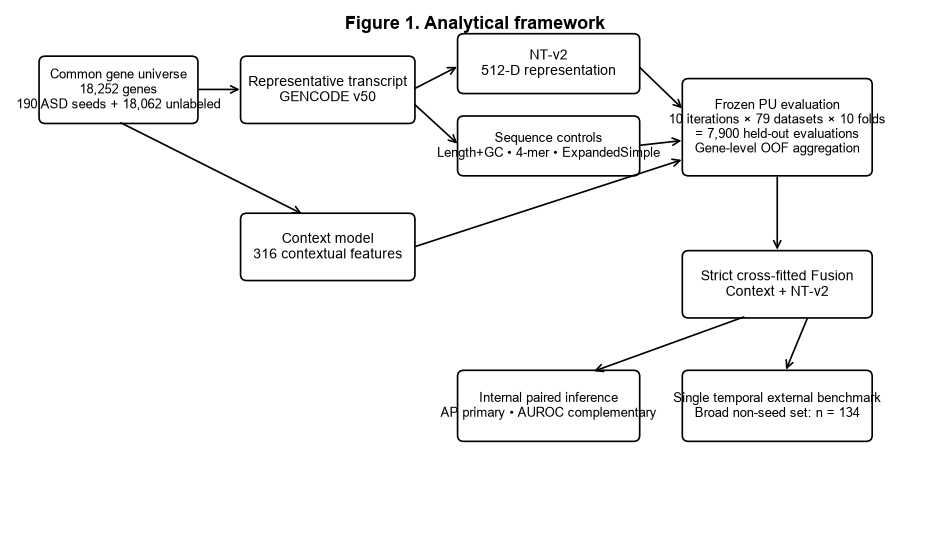

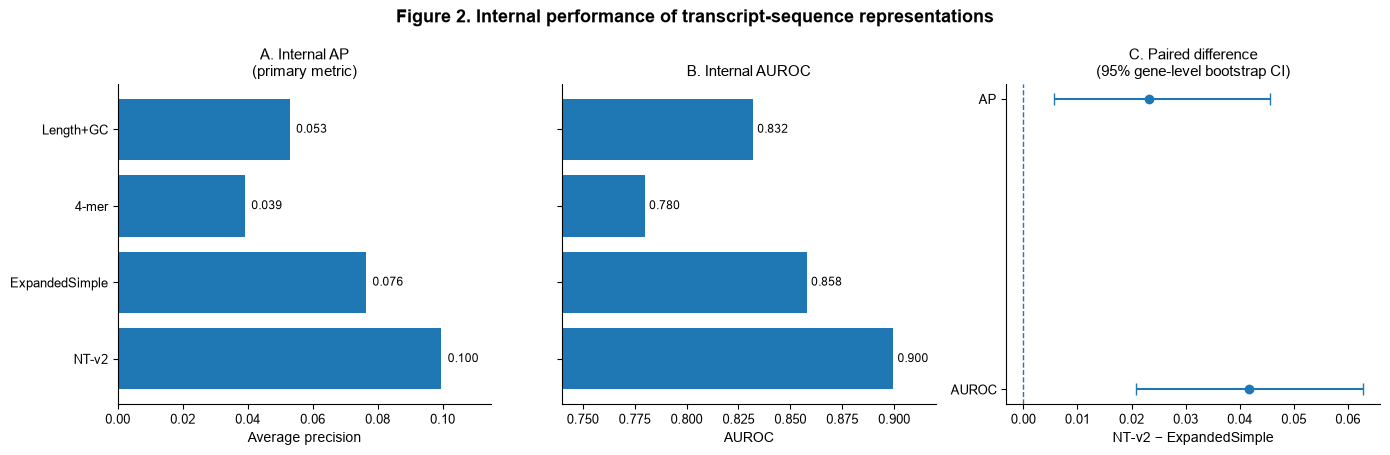

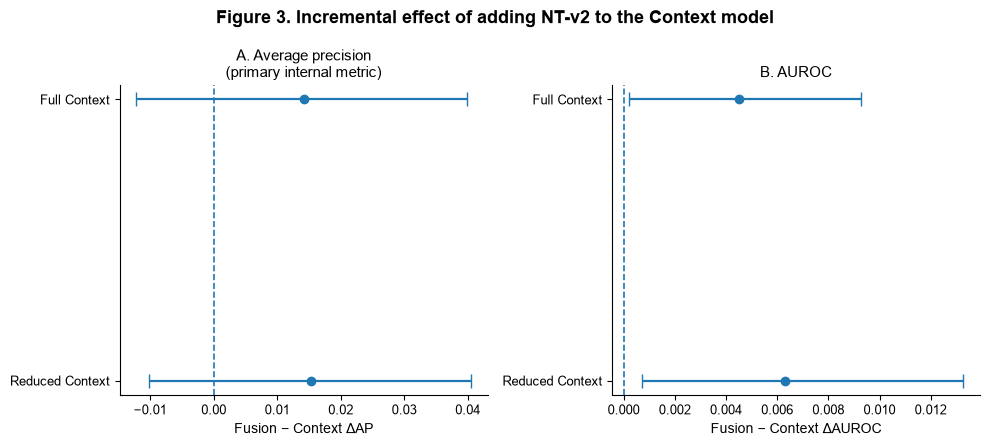

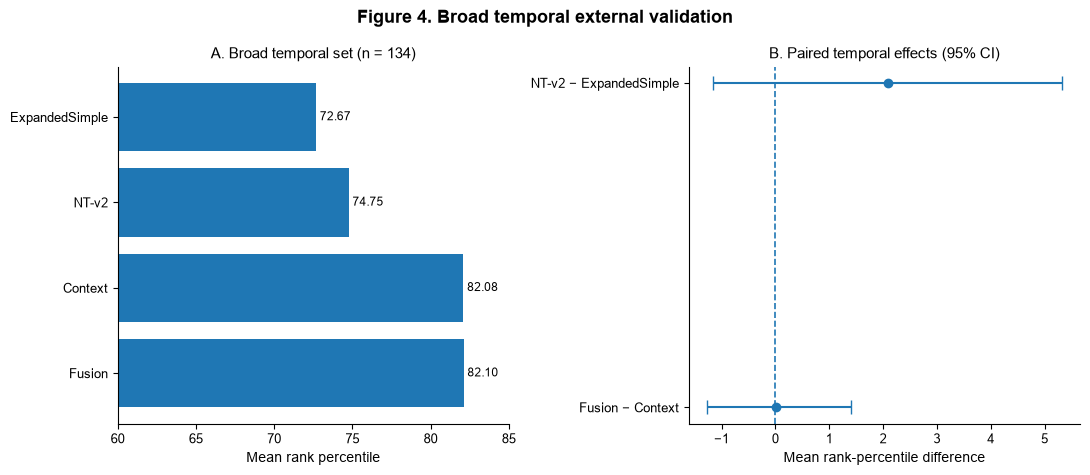


FINAL MANUSCRIPT REPORTING PACKAGE COMPLETE

TABLE 1
         Model                            Role Dimension Internal AUROC (95% CI) Internal AP (95% CI) Broad temporal mean rank percentile
     Length+GC                Sequence control         2     0.832 (0.805–0.858)  0.053 (0.043–0.073)                               70.98
         4-mer                Sequence control       256     0.780 (0.748–0.811)  0.039 (0.032–0.050)                               66.85
ExpandedSimple       Expanded sequence control       340     0.858 (0.832–0.883)  0.076 (0.061–0.099)                               72.67
         NT-v2 Foundation-model representation       512     0.900 (0.879–0.918)  0.100 (0.081–0.132)                               74.75
       Context        Disease-contextual model       316     0.947 (0.934–0.958)  0.182 (0.150–0.232)                               82.08
        Fusion    Cross-fitted Context + NT-v2         —     0.952 (0.941–0.961)  0.197 (0.162–0.249)                 

In [11]:
# ======================================================================================
# ASD ContextFusion
# FINAL MANUSCRIPT REPORTING PACKAGE
#
# NO MODEL FITTING
# NO NEW BOOTSTRAP
# NO NEW TEMPORAL ANALYSIS
# NO HYPERPARAMETER TUNING
#
# Creates:
#   Main Table 1
#   Main Table 2
#   Figure 1
#   Figure 2
#   Figure 3
#   Figure 4
#   Supplementary fixed top-K table
#
# IMPORTANT:
# Main manuscript is restricted to the CENTRAL study questions.
# Secondary lower-evidence / historical / candidate results are not inserted
# into the main figures here.
# ======================================================================================

from pathlib import Path
import json

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl

from matplotlib.patches import (
    FancyBboxPatch,
    FancyArrowPatch,
)


# ======================================================================================
# 0. PROJECT PATHS
# ======================================================================================

ROOT = Path(r"E:\ASD_ContextFusion_Q1")

EXPANDED_DIR = (
    ROOT
    / "05_results"
    / "proposed"
    / "expanded_simple_sequence_control"
)

EXPANDED_BOOT_FILE = (
    EXPANDED_DIR
    / "NTv2_vs_ExpandedSimple_bootstrap_5000.tsv.gz"
)

EXPANDED_BOOT_SUMMARY = (
    EXPANDED_DIR
    / "NTv2_vs_ExpandedSimple_bootstrap_summary.tsv"
)

EXPANDED_TEMPORAL_DIR = (
    EXPANDED_DIR
    / "temporal_validation"
)

EXPANDED_TEMP_RANK = (
    EXPANDED_TEMPORAL_DIR
    / "ExpandedTemporal_rank_summary.tsv"
)

EXPANDED_TEMP_BOOT = (
    EXPANDED_TEMPORAL_DIR
    / "ExpandedTemporal_NTv2_vs_Expanded_bootstrap_summary.tsv"
)

EXPANDED_TEMP_TOPK = (
    EXPANDED_TEMPORAL_DIR
    / "ExpandedTemporal_fixed_topK_hits.tsv"
)


OUT_ROOT = (
    ROOT
    / "06_publication"
    / "FINAL_REWRITE_2026"
)

TABLE_DIR = (
    OUT_ROOT
    / "tables"
)

FIG_DIR = (
    OUT_ROOT
    / "figures"
)

SUPP_DIR = (
    OUT_ROOT
    / "supplementary"
)

for d in [
    TABLE_DIR,
    FIG_DIR,
    SUPP_DIR,
]:
    d.mkdir(
        parents=True,
        exist_ok=True,
    )


# ======================================================================================
# 1. VERIFY REQUIRED NEW REVISION OUTPUTS
# ======================================================================================

required = [
    EXPANDED_BOOT_FILE,
    EXPANDED_BOOT_SUMMARY,
    EXPANDED_TEMP_RANK,
    EXPANDED_TEMP_BOOT,
    EXPANDED_TEMP_TOPK,
]

for p in required:

    if not p.exists():

        raise FileNotFoundError(
            f"Missing frozen result:\n{p}"
        )


# ======================================================================================
# 2. PLOT STYLE
# ======================================================================================

mpl.rcParams.update({

    "font.family":
        "Arial",

    "font.size":
        10,

    "axes.titlesize":
        11,

    "axes.labelsize":
        10,

    "xtick.labelsize":
        9,

    "ytick.labelsize":
        9,

    "legend.fontsize":
        9,

    "pdf.fonttype":
        42,

    "ps.fonttype":
        42,

    "axes.spines.top":
        False,

    "axes.spines.right":
        False,
})


# ======================================================================================
# 3. HELPER: SAVE PUBLICATION FIGURE
# ======================================================================================

def save_figure(fig, stem):

    fig.savefig(
        FIG_DIR / f"{stem}.pdf",
        bbox_inches="tight",
    )

    fig.savefig(
        FIG_DIR / f"{stem}.svg",
        bbox_inches="tight",
    )

    fig.savefig(
        FIG_DIR / f"{stem}.png",
        dpi=600,
        bbox_inches="tight",
    )

    fig.savefig(
        FIG_DIR / f"{stem}.tiff",
        dpi=600,
        bbox_inches="tight",
    )


# ======================================================================================
# 4. FROZEN FINAL INTERNAL RESULTS
#
# These are existing completed gene-level OOF results.
# No values are estimated here.
# ======================================================================================

internal = pd.DataFrame([

    {
        "Model":
            "Length+GC",

        "Role":
            "Sequence control",

        "Dimension":
            2,

        "AUROC":
            0.832049,

        "AP":
            0.052922,

        "AUROC_CI_low":
            0.804579,

        "AUROC_CI_high":
            0.857958,

        "AP_CI_low":
            0.042848,

        "AP_CI_high":
            0.072782,

        "Broad134_mean_RP":
            70.979070,
    },

    {
        "Model":
            "4-mer",

        "Role":
            "Sequence control",

        "Dimension":
            256,

        "AUROC":
            0.779947,

        "AP":
            0.039135,

        "AUROC_CI_low":
            0.747534,

        "AUROC_CI_high":
            0.810770,

        "AP_CI_low":
            0.031613,

        "AP_CI_high":
            0.050341,

        "Broad134_mean_RP":
            66.852135,
    },

    {
        "Model":
            "ExpandedSimple",

        "Role":
            "Expanded sequence control",

        "Dimension":
            340,

        "AUROC":
            0.857987,

        "AP":
            0.076419,

        # Filled from EXISTING bootstrap replicates below.
        "AUROC_CI_low":
            np.nan,

        "AUROC_CI_high":
            np.nan,

        "AP_CI_low":
            np.nan,

        "AP_CI_high":
            np.nan,

        "Broad134_mean_RP":
            72.671841,
    },

    {
        "Model":
            "NT-v2",

        "Role":
            "Foundation-model representation",

        "Dimension":
            512,

        "AUROC":
            0.899628,

        "AP":
            0.099593,

        "AUROC_CI_low":
            0.879340,

        "AUROC_CI_high":
            0.917879,

        "AP_CI_low":
            0.080871,

        "AP_CI_high":
            0.132325,

        "Broad134_mean_RP":
            74.754336,
    },

    {
        "Model":
            "Context",

        "Role":
            "Disease-contextual model",

        "Dimension":
            316,

        "AUROC":
            0.947076,

        "AP":
            0.182366,

        "AUROC_CI_low":
            0.934277,

        "AUROC_CI_high":
            0.958192,

        "AP_CI_low":
            0.150314,

        "AP_CI_high":
            0.231546,

        "Broad134_mean_RP":
            82.084263,
    },

    {
        "Model":
            "Fusion",

        "Role":
            "Cross-fitted Context + NT-v2",

        "Dimension":
            np.nan,

        "AUROC":
            0.951591,

        "AP":
            0.196525,

        "AUROC_CI_low":
            0.940797,

        "AUROC_CI_high":
            0.961402,

        "AP_CI_low":
            0.161530,

        "AP_CI_high":
            0.248707,

        "Broad134_mean_RP":
            82.101700,
    },
])


# ======================================================================================
# 5. EXPANDED-CONTROL ABSOLUTE CI
#
# IMPORTANT:
# We are NOT resampling.
# These percentiles are extracted from the already-created 5,000 bootstrap
# replicate file from the completed ExpandedSimple analysis.
# ======================================================================================

expanded_boot = pd.read_csv(
    EXPANDED_BOOT_FILE,
    sep="\t",
    compression="gzip",
)


assert len(
    expanded_boot
) == 5000


for c in [
    "Expanded_AUROC",
    "Expanded_AP",
]:

    assert c in expanded_boot.columns


exp_roc_ci = np.quantile(
    expanded_boot[
        "Expanded_AUROC"
    ].to_numpy(),
    [
        0.025,
        0.975,
    ],
)

exp_ap_ci = np.quantile(
    expanded_boot[
        "Expanded_AP"
    ].to_numpy(),
    [
        0.025,
        0.975,
    ],
)


mask_exp = (
    internal[
        "Model"
    ]
    ==
    "ExpandedSimple"
)


internal.loc[
    mask_exp,
    "AUROC_CI_low"
] = exp_roc_ci[0]

internal.loc[
    mask_exp,
    "AUROC_CI_high"
] = exp_roc_ci[1]

internal.loc[
    mask_exp,
    "AP_CI_low"
] = exp_ap_ci[0]

internal.loc[
    mask_exp,
    "AP_CI_high"
] = exp_ap_ci[1]


# ======================================================================================
# 6. QC AGAINST THE COMPLETED EXPANDED ANALYSIS
# ======================================================================================

expanded_summary = pd.read_csv(
    EXPANDED_BOOT_SUMMARY,
    sep="\t",
)

assert len(
    expanded_summary
) == 2


exp_ap_row = expanded_summary.loc[
    expanded_summary[
        "Metric"
    ] == "AP"
].iloc[0]

exp_roc_row = expanded_summary.loc[
    expanded_summary[
        "Metric"
    ] == "AUROC"
].iloc[0]


assert np.isclose(
    exp_ap_row[
        "Observed_delta"
    ],
    0.0231736152,
    atol=1e-9,
)

assert np.isclose(
    exp_roc_row[
        "Observed_delta"
    ],
    0.0416410726,
    atol=1e-9,
)


# ======================================================================================
# 7. QC TEMPORAL EXPANDED RESULT
# ======================================================================================

temp_rank = pd.read_csv(
    EXPANDED_TEMP_RANK,
    sep="\t",
)

temp_boot = pd.read_csv(
    EXPANDED_TEMP_BOOT,
    sep="\t",
)


broad_rank = temp_rank.loc[
    temp_rank[
        "external_set"
    ]
    ==
    "Tan_All245_nonseed"
]


assert len(
    broad_rank
) == 2


nt_broad = broad_rank.loc[
    broad_rank[
        "model"
    ] == "NTv2"
].iloc[0]

exp_broad = broad_rank.loc[
    broad_rank[
        "model"
    ] == "ExpandedSimple"
].iloc[0]


assert np.isclose(
    nt_broad[
        "mean_rank_percentile"
    ],
    74.7543358453,
    atol=1e-9,
)

assert np.isclose(
    exp_broad[
        "mean_rank_percentile"
    ],
    72.671841,
    atol=1e-5,
)


broad_boot = temp_boot.loc[
    temp_boot[
        "external_set"
    ]
    ==
    "Tan_All245_nonseed"
].iloc[0]


# ======================================================================================
# 8. TABLE 1
#    OVERALL MODEL PERFORMANCE
# ======================================================================================

table1 = internal.copy()


table1[
    "Internal AUROC (95% CI)"
] = table1.apply(
    lambda r:
        (
            f"{r['AUROC']:.3f} "
            f"({r['AUROC_CI_low']:.3f}–"
            f"{r['AUROC_CI_high']:.3f})"
        ),
    axis=1,
)


table1[
    "Internal AP (95% CI)"
] = table1.apply(
    lambda r:
        (
            f"{r['AP']:.3f} "
            f"({r['AP_CI_low']:.3f}–"
            f"{r['AP_CI_high']:.3f})"
        ),
    axis=1,
)


table1[
    "Broad temporal mean rank percentile"
] = (
    table1[
        "Broad134_mean_RP"
    ]
    .map(
        lambda x:
            f"{x:.2f}"
    )
)


table1_final = table1[
    [
        "Model",
        "Role",
        "Dimension",
        "Internal AUROC (95% CI)",
        "Internal AP (95% CI)",
        "Broad temporal mean rank percentile",
    ]
].copy()


table1_final[
    "Dimension"
] = (
    table1_final[
        "Dimension"
    ]
    .apply(
        lambda x:
            "—"
            if pd.isna(x)
            else str(
                int(
                    x
                )
            )
    )
)


TABLE1_FILE = (
    TABLE_DIR
    / "Table1_Overall_Model_Performance.tsv"
)


table1_final.to_csv(
    TABLE1_FILE,
    sep="\t",
    index=False,
)


# ======================================================================================
# 9. TABLE 2
#    CENTRAL PAIRED INFERENCE ONLY
#
# Do not fill this table with every exploratory comparison.
# These are the comparisons directly answering the manuscript hypotheses.
# ======================================================================================

table2 = pd.DataFrame([

    {
        "Analysis":
            "Internal",

        "Comparison":
            "NT-v2 − ExpandedSimple",

        "Endpoint":
            "AP (primary internal metric)",

        "Difference":
            +0.0231736152,

        "CI_low":
            +0.0056738848,

        "CI_high":
            +0.0456808156,

        "Interpretation":
            "Higher NT-v2 AP",
    },

    {
        "Analysis":
            "Internal",

        "Comparison":
            "NT-v2 − ExpandedSimple",

        "Endpoint":
            "AUROC",

        "Difference":
            +0.0416410726,

        "CI_low":
            +0.0209051571,

        "CI_high":
            +0.0628016656,

        "Interpretation":
            "Higher NT-v2 AUROC",
    },

    {
        "Analysis":
            "Internal",

        "Comparison":
            "Fusion − Context",

        "Endpoint":
            "AP (primary internal metric)",

        "Difference":
            +0.014159,

        "CI_low":
            -0.012178,

        "CI_high":
            +0.039833,

        "Interpretation":
            "Uncertain AP increment",
    },

    {
        "Analysis":
            "Internal",

        "Comparison":
            "Fusion − Context",

        "Endpoint":
            "AUROC",

        "Difference":
            +0.004515,

        "CI_low":
            +0.000206,

        "CI_high":
            +0.009281,

        "Interpretation":
            "Small positive AUROC increment",
    },

    {
        "Analysis":
            "Broad temporal benchmark",

        "Comparison":
            "NT-v2 − ExpandedSimple",

        "Endpoint":
            "Mean rank percentile",

        "Difference":
            float(
                broad_boot[
                    "observed_mean_rank_percentile_delta"
                ]
            ),

        "CI_low":
            float(
                broad_boot[
                    "CI95_low"
                ]
            ),

        "CI_high":
            float(
                broad_boot[
                    "CI95_high"
                ]
            ),

        "Interpretation":
            "Temporal difference uncertain",
    },

    {
        "Analysis":
            "Broad temporal benchmark",

        "Comparison":
            "Fusion − Context",

        "Endpoint":
            "Mean rank percentile",

        "Difference":
            +0.017437,

        "CI_low":
            -1.277108,

        "CI_high":
            +1.400825,

        "Interpretation":
            "Temporal difference uncertain",
    },
])


table2[
    "Difference (95% CI)"
] = table2.apply(
    lambda r:
        (
            f"{r['Difference']:+.4f} "
            f"({r['CI_low']:+.4f} to "
            f"{r['CI_high']:+.4f})"
        ),
    axis=1,
)


table2_final = table2[
    [
        "Analysis",
        "Comparison",
        "Endpoint",
        "Difference (95% CI)",
        "Interpretation",
    ]
]


TABLE2_FILE = (
    TABLE_DIR
    / "Table2_Key_Paired_Comparisons.tsv"
)


table2_final.to_csv(
    TABLE2_FILE,
    sep="\t",
    index=False,
)


# ======================================================================================
# 10. WRITE BOTH MAIN TABLES TO ONE EXCEL WORKBOOK
# ======================================================================================

EXCEL_FILE = (
    TABLE_DIR
    / "MAIN_TABLES_FINAL.xlsx"
)


with pd.ExcelWriter(
    EXCEL_FILE,
    engine="openpyxl",
) as writer:

    table1_final.to_excel(
        writer,
        sheet_name="Table1",
        index=False,
    )

    table2_final.to_excel(
        writer,
        sheet_name="Table2",
        index=False,
    )


# ======================================================================================
# 11. FIGURE 1
#     ANALYTICAL FRAMEWORK
# ======================================================================================

fig, ax = plt.subplots(
    figsize=(
        12,
        6.8,
    )
)

ax.set_xlim(
    0,
    12,
)

ax.set_ylim(
    0,
    7,
)

ax.axis(
    "off"
)


def box(
    x,
    y,
    w,
    h,
    text,
    fontsize=10,
):

    patch = FancyBboxPatch(
        (
            x,
            y,
        ),
        w,
        h,
        boxstyle=
            "round,pad=0.025,rounding_size=0.08",
        linewidth=1.2,
        edgecolor="black",
        facecolor="white",
    )

    ax.add_patch(
        patch
    )

    ax.text(
        x + w / 2,
        y + h / 2,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
    )


def arrow(
    x1,
    y1,
    x2,
    y2,
):

    arr = FancyArrowPatch(
        (
            x1,
            y1,
        ),
        (
            x2,
            y2,
        ),
        arrowstyle="->",
        mutation_scale=13,
        linewidth=1.2,
    )

    ax.add_patch(
        arr
    )


box(
    0.4,
    5.5,
    2.0,
    0.85,
    (
        "Common gene universe\n"
        "18,252 genes\n"
        "190 ASD seeds + 18,062 unlabeled"
    ),
    9.5,
)


box(
    3.0,
    5.5,
    2.2,
    0.85,
    (
        "Representative transcript\n"
        "GENCODE v50"
    ),
)


box(
    5.8,
    5.9,
    2.3,
    0.75,
    "NT-v2\n512-D representation",
)


box(
    5.8,
    4.8,
    2.3,
    0.75,
    (
        "Sequence controls\n"
        "Length+GC • 4-mer • ExpandedSimple"
    ),
    9,
)


box(
    3.0,
    3.4,
    2.2,
    0.85,
    (
        "Context model\n"
        "316 contextual features"
    ),
)


box(
    8.7,
    4.8,
    2.4,
    1.25,
    (
        "Frozen PU evaluation\n"
        "10 iterations × 79 datasets × 10 folds\n"
        "= 7,900 held-out evaluations\n"
        "Gene-level OOF aggregation"
    ),
    9,
)


box(
    8.7,
    2.9,
    2.4,
    0.85,
    (
        "Strict cross-fitted Fusion\n"
        "Context + NT-v2"
    ),
)


box(
    5.8,
    1.25,
    2.3,
    0.9,
    (
        "Internal paired inference\n"
        "AP primary • AUROC complementary"
    ),
    9,
)


box(
    8.7,
    1.25,
    2.4,
    0.9,
    (
        "Single temporal external benchmark\n"
        "Broad non-seed set: n = 134"
    ),
    9,
)


arrow(
    2.4,
    5.93,
    3.0,
    5.93,
)

arrow(
    5.2,
    5.93,
    5.8,
    6.25,
)

arrow(
    5.2,
    5.75,
    5.8,
    5.18,
)

arrow(
    1.4,
    5.5,
    3.8,
    4.25,
)

arrow(
    8.1,
    6.25,
    8.7,
    5.65,
)

arrow(
    8.1,
    5.18,
    8.7,
    5.25,
)

arrow(
    5.2,
    3.82,
    8.7,
    5.0,
)

arrow(
    9.9,
    4.8,
    9.9,
    3.75,
)

arrow(
    9.5,
    2.9,
    7.5,
    2.15,
)

arrow(
    10.3,
    2.9,
    10.0,
    2.15,
)


ax.text(
    6,
    6.8,
    "Figure 1. Analytical framework",
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold",
)


save_figure(
    fig,
    "Figure1_Analytical_Framework",
)

plt.show()


# ======================================================================================
# 12. FIGURE 2
#     NT-v2 VS CONVENTIONAL TRANSCRIPT-SEQUENCE CONTROLS
# ======================================================================================

sequence_models = [
    "Length+GC",
    "4-mer",
    "ExpandedSimple",
    "NT-v2",
]


seq = (
    internal
    .set_index(
        "Model"
    )
    .loc[
        sequence_models
    ]
    .reset_index()
)


fig, axes = plt.subplots(
    1,
    3,
    figsize=(
        14,
        4.6,
    ),
)


# --------------------------------------------------------------------------------------
# A. AP
# --------------------------------------------------------------------------------------

ax = axes[0]

y = np.arange(
    len(
        seq
    )
)

ax.barh(
    y,
    seq[
        "AP"
    ],
)

ax.set_yticks(
    y
)

ax.set_yticklabels(
    seq[
        "Model"
    ]
)

ax.invert_yaxis()

ax.set_xlabel(
    "Average precision"
)

ax.set_title(
    "A. Internal AP\n(primary metric)"
)

ax.set_xlim(
    0,
    0.115,
)


for i, value in enumerate(
    seq[
        "AP"
    ]
):

    ax.text(
        value + 0.002,
        i,
        f"{value:.3f}",
        va="center",
        fontsize=8.5,
    )


# --------------------------------------------------------------------------------------
# B. AUROC
# --------------------------------------------------------------------------------------

ax = axes[1]

ax.barh(
    y,
    seq[
        "AUROC"
    ],
)

ax.set_yticks(
    y
)

ax.set_yticklabels(
    []
)

ax.invert_yaxis()

ax.set_xlabel(
    "AUROC"
)

ax.set_title(
    "B. Internal AUROC"
)

ax.set_xlim(
    0.74,
    0.92,
)


for i, value in enumerate(
    seq[
        "AUROC"
    ]
):

    ax.text(
        value + 0.002,
        i,
        f"{value:.3f}",
        va="center",
        fontsize=8.5,
    )


# --------------------------------------------------------------------------------------
# C. Paired NT-v2 minus ExpandedSimple
# --------------------------------------------------------------------------------------

ax = axes[2]

effects = pd.DataFrame({

    "metric":
        [
            "AP",
            "AUROC",
        ],

    "delta":
        [
            0.0231736152,
            0.0416410726,
        ],

    "low":
        [
            0.0056738848,
            0.0209051571,
        ],

    "high":
        [
            0.0456808156,
            0.0628016656,
        ],
})


yy = np.arange(
    len(
        effects
    )
)


xerr = np.vstack([

    effects[
        "delta"
    ]
    -
    effects[
        "low"
    ],

    effects[
        "high"
    ]
    -
    effects[
        "delta"
    ],
])


ax.errorbar(
    effects[
        "delta"
    ],
    yy,
    xerr=xerr,
    fmt="o",
    capsize=4,
    linewidth=1.5,
)


ax.axvline(
    0,
    linewidth=1,
    linestyle="--",
)


ax.set_yticks(
    yy
)

ax.set_yticklabels(
    effects[
        "metric"
    ]
)

ax.invert_yaxis()

ax.set_xlabel(
    "NT-v2 − ExpandedSimple"
)

ax.set_title(
    "C. Paired difference\n(95% gene-level bootstrap CI)"
)


fig.suptitle(
    (
        "Figure 2. Internal performance of "
        "transcript-sequence representations"
    ),
    fontsize=13,
    fontweight="bold",
)


fig.tight_layout()


save_figure(
    fig,
    "Figure2_Sequence_Representation_Performance",
)

plt.show()


# ======================================================================================
# 13. FIGURE 3
#     FUSION MINUS CONTEXT
#
# Primary AP CI crossing zero is deliberately visible.
# ======================================================================================

fusion_effects = pd.DataFrame([

    {
        "Context specification":
            "Full Context",

        "Metric":
            "AP",

        "delta":
            0.014159,

        "low":
            -0.012178,

        "high":
            0.039833,
    },

    {
        "Context specification":
            "Reduced Context",

        "Metric":
            "AP",

        "delta":
            0.015343,

        "low":
            -0.010172,

        "high":
            0.040478,
    },

    {
        "Context specification":
            "Full Context",

        "Metric":
            "AUROC",

        "delta":
            0.004515,

        "low":
            0.000206,

        "high":
            0.009281,
    },

    {
        "Context specification":
            "Reduced Context",

        "Metric":
            "AUROC",

        "delta":
            0.006318,

        "low":
            0.000715,

        "high":
            0.013274,
    },
])


fig, axes = plt.subplots(
    1,
    2,
    figsize=(
        10,
        4.5,
    ),
)


for ax, metric in zip(
    axes,
    [
        "AP",
        "AUROC",
    ],
):

    d = (
        fusion_effects.loc[
            fusion_effects[
                "Metric"
            ] == metric
        ]
        .reset_index(
            drop=True
        )
    )

    yy = np.arange(
        len(
            d
        )
    )


    xerr = np.vstack([

        d[
            "delta"
        ]
        -
        d[
            "low"
        ],

        d[
            "high"
        ]
        -
        d[
            "delta"
        ],
    ])


    ax.errorbar(
        d[
            "delta"
        ],
        yy,
        xerr=xerr,
        fmt="o",
        capsize=5,
        linewidth=1.6,
    )


    ax.axvline(
        0,
        linewidth=1.2,
        linestyle="--",
    )


    ax.set_yticks(
        yy
    )

    ax.set_yticklabels(
        d[
            "Context specification"
        ]
    )

    ax.invert_yaxis()

    ax.set_xlabel(
        f"Fusion − Context Δ{metric}"
    )


    if metric == "AP":

        ax.set_title(
            "A. Average precision\n(primary internal metric)"
        )

    else:

        ax.set_title(
            "B. AUROC"
        )


fig.suptitle(
    (
        "Figure 3. Incremental effect of "
        "adding NT-v2 to the Context model"
    ),
    fontsize=13,
    fontweight="bold",
)


fig.tight_layout()


save_figure(
    fig,
    "Figure3_Fusion_Context_Paired_Effects",
)

plt.show()


# ======================================================================================
# 14. FIGURE 4
#     PRIMARY BROAD TEMPORAL EXTERNAL BENCHMARK
#
# Lower-evidence subsets are deliberately left for Supplementary reporting.
# ======================================================================================

temporal_models = pd.DataFrame({

    "Model":
        [
            "ExpandedSimple",
            "NT-v2",
            "Context",
            "Fusion",
        ],

    "Mean rank percentile":
        [
            72.671841,
            74.754336,
            82.084263,
            82.101700,
        ],
})


temporal_effects = pd.DataFrame({

    "Comparison":
        [
            "NT-v2 − ExpandedSimple",
            "Fusion − Context",
        ],

    "delta":
        [
            float(
                broad_boot[
                    "observed_mean_rank_percentile_delta"
                ]
            ),
            0.017437,
        ],

    "low":
        [
            float(
                broad_boot[
                    "CI95_low"
                ]
            ),
            -1.277108,
        ],

    "high":
        [
            float(
                broad_boot[
                    "CI95_high"
                ]
            ),
            1.400825,
        ],
})


fig, axes = plt.subplots(
    1,
    2,
    figsize=(
        11,
        4.8,
    ),
)


# --------------------------------------------------------------------------------------
# A. Mean rank percentile
# --------------------------------------------------------------------------------------

ax = axes[0]

yy = np.arange(
    len(
        temporal_models
    )
)


ax.barh(
    yy,
    temporal_models[
        "Mean rank percentile"
    ],
)


ax.set_yticks(
    yy
)

ax.set_yticklabels(
    temporal_models[
        "Model"
    ]
)

ax.invert_yaxis()

ax.set_xlim(
    60,
    85,
)

ax.set_xlabel(
    "Mean rank percentile"
)

ax.set_title(
    "A. Broad temporal set (n = 134)"
)


for i, value in enumerate(
    temporal_models[
        "Mean rank percentile"
    ]
):

    ax.text(
        value + 0.25,
        i,
        f"{value:.2f}",
        va="center",
        fontsize=8.5,
    )


# --------------------------------------------------------------------------------------
# B. Paired temporal contrasts
# --------------------------------------------------------------------------------------

ax = axes[1]

yy = np.arange(
    len(
        temporal_effects
    )
)


xerr = np.vstack([

    temporal_effects[
        "delta"
    ]
    -
    temporal_effects[
        "low"
    ],

    temporal_effects[
        "high"
    ]
    -
    temporal_effects[
        "delta"
    ],
])


ax.errorbar(
    temporal_effects[
        "delta"
    ],
    yy,
    xerr=xerr,
    fmt="o",
    capsize=5,
    linewidth=1.5,
)


ax.axvline(
    0,
    linestyle="--",
    linewidth=1.2,
)


ax.set_yticks(
    yy
)

ax.set_yticklabels(
    temporal_effects[
        "Comparison"
    ]
)

ax.invert_yaxis()

ax.set_xlabel(
    "Mean rank-percentile difference"
)

ax.set_title(
    "B. Paired temporal effects (95% CI)"
)


fig.suptitle(
    (
        "Figure 4. Broad temporal external validation"
    ),
    fontsize=13,
    fontweight="bold",
)


fig.tight_layout()


save_figure(
    fig,
    "Figure4_Broad_Temporal_Validation",
)

plt.show()


# ======================================================================================
# 15. SUPPLEMENTARY FIXED TOP-K TABLE
#
# Reviewer-requested practical ranking analysis.
# Kept in Supplementary material so it does not overcrowd the main story.
# ======================================================================================

K_VALUES = [
    10,
    50,
    100,
    200,
    500,
]


broad_topk = pd.DataFrame({

    "K":
        K_VALUES,

    "Context":
        [
            1,
            6,
            8,
            15,
            31,
        ],

    "NT-v2":
        [
            1,
            6,
            8,
            12,
            22,
        ],

    "ExpandedSimple":
        [
            0,
            4,
            5,
            10,
            19,
        ],

    "Fusion":
        [
            4,
            6,
            9,
            14,
            33,
        ],
})


# Confirm NT-v2 and ExpandedSimple against the completed temporal output.
topk_source = pd.read_csv(
    EXPANDED_TEMP_TOPK,
    sep="\t",
)


source_broad = topk_source.loc[
    topk_source[
        "external_set"
    ]
    ==
    "Tan_All245_nonseed"
]


for model in [
    "NTv2",
    "ExpandedSimple",
]:

    d = (
        source_broad.loc[
            source_broad[
                "model"
            ] == model
        ]
        .sort_values(
            "K"
        )
    )

    expected = (
        broad_topk[
            "NT-v2"
            if model == "NTv2"
            else "ExpandedSimple"
        ]
        .to_numpy()
    )

    observed = (
        d[
            "hit_count"
        ]
        .to_numpy()
    )

    assert np.array_equal(
        expected,
        observed,
    )


SUPP_TOPK_FILE = (
    SUPP_DIR
    / "TableS3_Broad134_Fixed_TopK_Hits.tsv"
)


broad_topk.to_csv(
    SUPP_TOPK_FILE,
    sep="\t",
    index=False,
)


# ======================================================================================
# 16. MANIFEST
# ======================================================================================

manifest = {

    "package":
        "Final manuscript reporting package",

    "new_model_fitting":
        False,

    "new_bootstrap_resampling":
        False,

    "new_external_analysis":
        False,

    "main_tables": [
        str(
            TABLE1_FILE
        ),
        str(
            TABLE2_FILE
        ),
        str(
            EXCEL_FILE
        ),
    ],

    "main_figures": [
        "Figure1_Analytical_Framework",
        "Figure2_Sequence_Representation_Performance",
        "Figure3_Fusion_Context_Paired_Effects",
        "Figure4_Broad_Temporal_Validation",
    ],

    "supplementary_topk":
        str(
            SUPP_TOPK_FILE
        ),

    "main_reporting_principle":
        (
            "Only central prespecified study questions are shown "
            "in the main figures/tables; secondary subgroup, "
            "historical-comparator, and candidate-level analyses "
            "are reserved for supplementary reporting."
        ),

    "primary_internal_metric":
        "Average precision",

    "key_statistical_note":
        (
            "Central inconclusive comparisons are retained rather "
            "than selectively omitted."
        ),
}


with open(
    OUT_ROOT
    / "FINAL_REPORTING_PACKAGE_MANIFEST.json",
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        manifest,
        f,
        indent=2,
    )


# ======================================================================================
# 17. FINAL REPORT
# ======================================================================================

print("\n" + "=" * 120)
print("FINAL MANUSCRIPT REPORTING PACKAGE COMPLETE")
print("=" * 120)

print("\nTABLE 1")
print(
    table1_final.to_string(
        index=False
    )
)

print("\nTABLE 2")
print(
    table2_final.to_string(
        index=False
    )
)

print("\nSaved main tables:")
print(TABLE1_FILE)
print(TABLE2_FILE)
print(EXCEL_FILE)

print("\nSaved figures to:")
print(FIG_DIR)

print("\nSupplementary top-K:")
print(SUPP_TOPK_FILE)

print("\nNO MODEL FITTING PERFORMED")
print("NO NEW BOOTSTRAP PERFORMED")
print("NO NEW TEMPORAL ANALYSIS PERFORMED")

print("\nFINAL REPORTING PACKAGE [OK]")

FINAL POLISHED MANUSCRIPT REPORTING PACKAGE

All required frozen inputs found [OK]


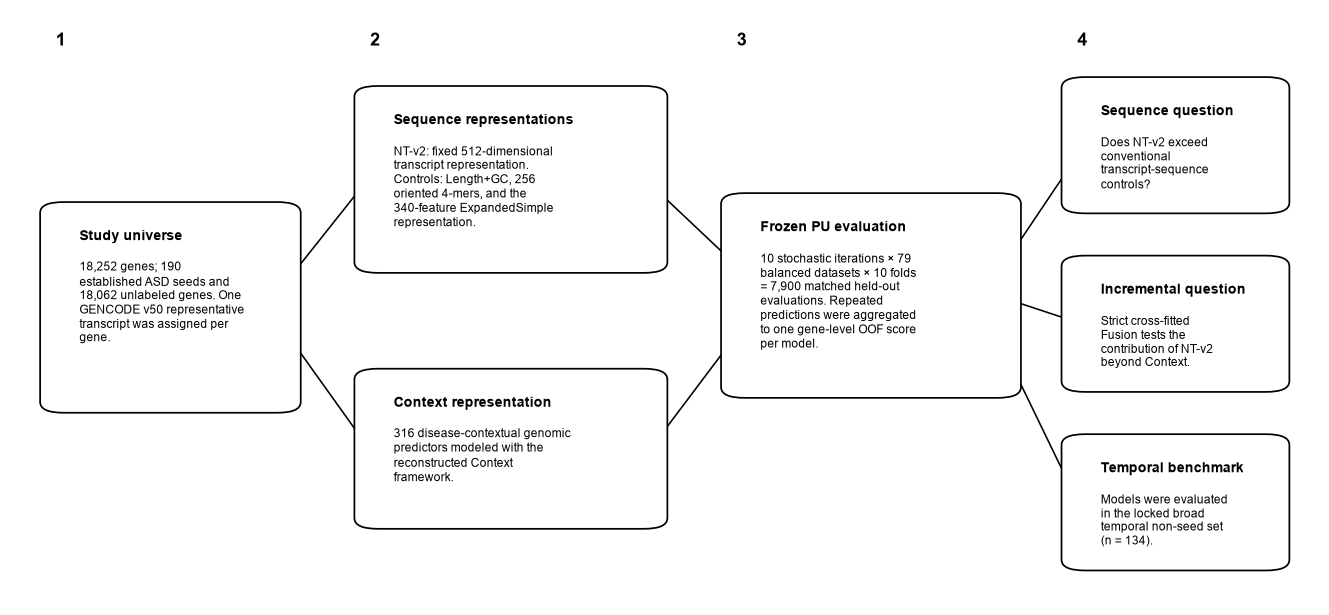

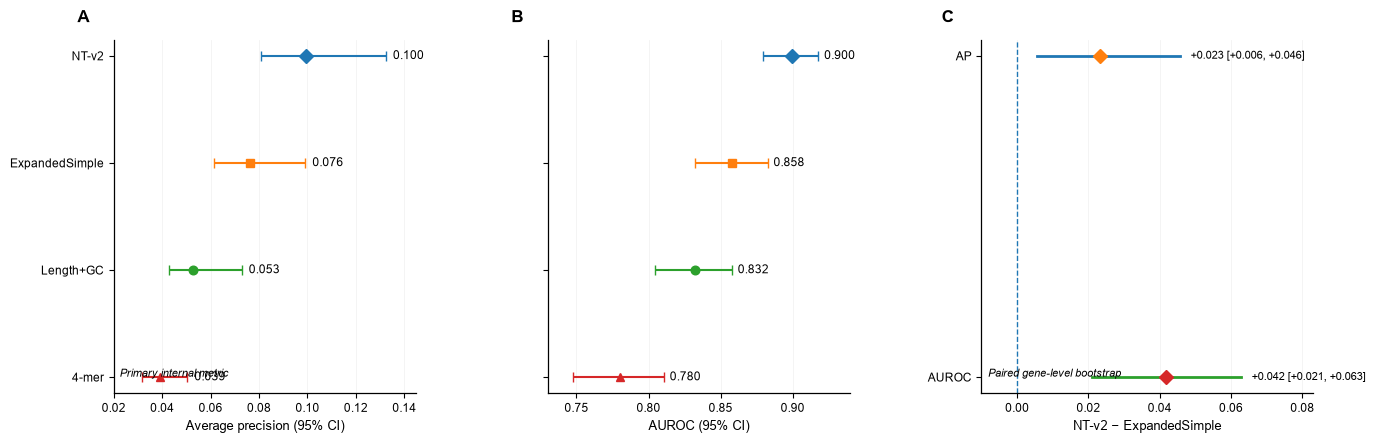

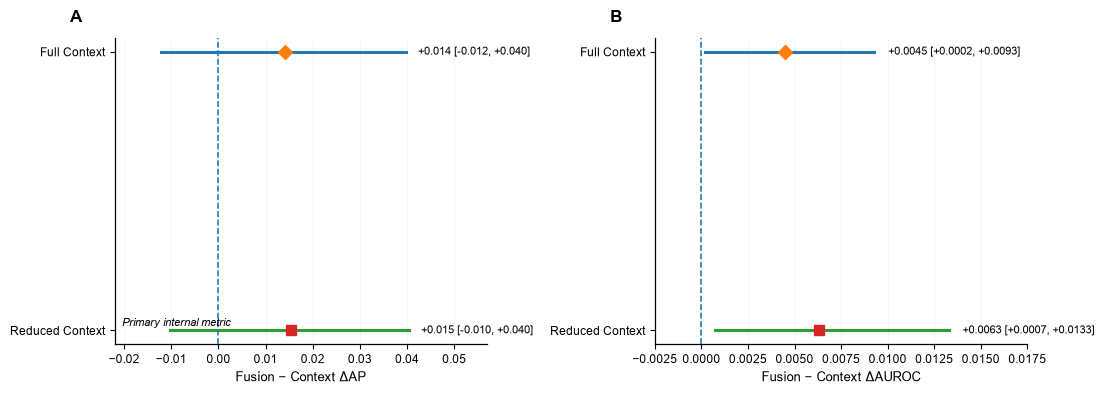

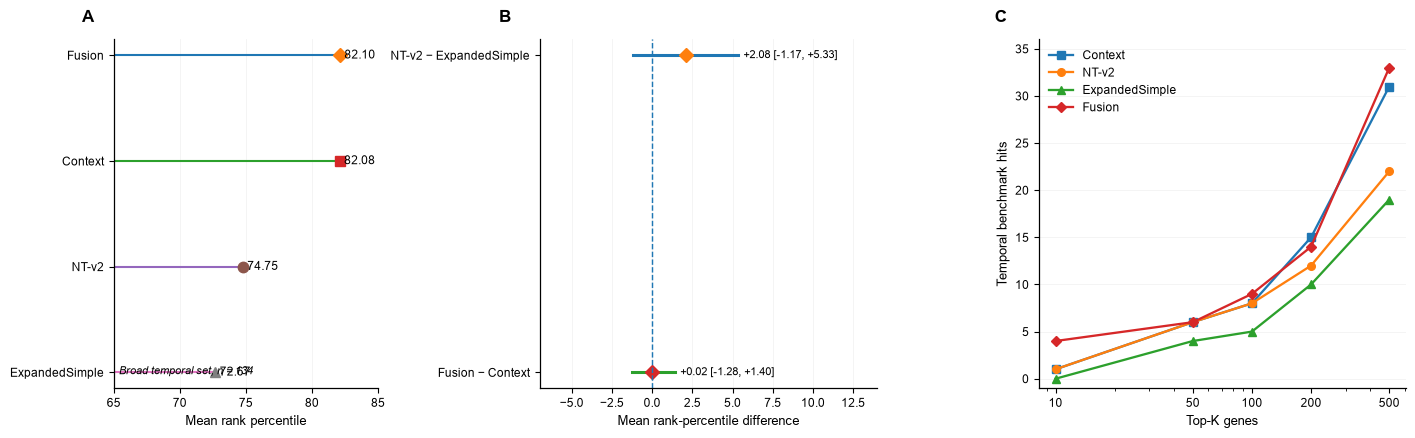


POLISHED MAIN TABLES + FIGURES COMPLETE

TABLE 1
         Model                            Role Dimension Internal AUROC (95% CI) Internal AP (95% CI) Broad temporal mean rank percentile
     Length+GC                Sequence control         2     0.832 (0.805–0.858)  0.053 (0.043–0.073)                               70.98
         4-mer                Sequence control       256     0.780 (0.748–0.811)  0.039 (0.032–0.050)                               66.85
ExpandedSimple       Expanded sequence control       340     0.858 (0.832–0.883)  0.076 (0.061–0.099)                               72.67
         NT-v2 Foundation-model representation       512     0.900 (0.879–0.918)  0.100 (0.081–0.132)                               74.75
       Context        Disease-contextual model       316     0.947 (0.934–0.958)  0.182 (0.150–0.232)                               82.08
        Fusion    Cross-fitted Context + NT-v2         —     0.952 (0.941–0.961)  0.197 (0.162–0.249)                     

In [12]:
# ======================================================================================
# ASD ContextFusion
# FINAL MANUSCRIPT TABLES + POLISHED PUBLICATION FIGURES — REVISED
#
# REPLACES THE PREVIOUS REPORTING CELL
#
# NO MODEL FITTING
# NO NEW BOOTSTRAP
# NO NEW TEMPORAL ANALYSIS
# NO NEW HYPOTHESIS TESTING
#
# SAME OUTPUT FILENAMES ARE USED -> PREVIOUS FILES WILL BE OVERWRITTEN.
#
# Main outputs:
#   Table1_Overall_Model_Performance.tsv
#   Table2_Key_Paired_Comparisons.tsv
#   MAIN_TABLES_FINAL.xlsx
#
#   Figure1_Analytical_Framework.*
#   Figure2_Sequence_Representation_Performance.*
#   Figure3_Fusion_Context_Paired_Effects.*
#   Figure4_Broad_Temporal_Validation.*
#
# ======================================================================================


from pathlib import Path
import json
import textwrap

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl

from matplotlib.patches import (
    FancyBboxPatch,
    FancyArrowPatch,
)


# ======================================================================================
# 0. PATHS
# ======================================================================================

ROOT = Path(
    r"E:\ASD_ContextFusion_Q1"
)


EXPANDED_DIR = (
    ROOT
    / "05_results"
    / "proposed"
    / "expanded_simple_sequence_control"
)


EXPANDED_BOOT_FILE = (
    EXPANDED_DIR
    / "NTv2_vs_ExpandedSimple_bootstrap_5000.tsv.gz"
)


EXPANDED_BOOT_SUMMARY = (
    EXPANDED_DIR
    / "NTv2_vs_ExpandedSimple_bootstrap_summary.tsv"
)


EXPANDED_TEMPORAL_DIR = (
    EXPANDED_DIR
    / "temporal_validation"
)


EXPANDED_TEMP_RANK = (
    EXPANDED_TEMPORAL_DIR
    / "ExpandedTemporal_rank_summary.tsv"
)


EXPANDED_TEMP_BOOT = (
    EXPANDED_TEMPORAL_DIR
    / "ExpandedTemporal_NTv2_vs_Expanded_bootstrap_summary.tsv"
)


EXPANDED_TEMP_TOPK = (
    EXPANDED_TEMPORAL_DIR
    / "ExpandedTemporal_fixed_topK_hits.tsv"
)


OUT_ROOT = (
    ROOT
    / "06_publication"
    / "FINAL_REWRITE_2026"
)


TABLE_DIR = (
    OUT_ROOT
    / "tables"
)


FIG_DIR = (
    OUT_ROOT
    / "figures"
)


SUPP_DIR = (
    OUT_ROOT
    / "supplementary"
)


for d in [
    TABLE_DIR,
    FIG_DIR,
    SUPP_DIR,
]:

    d.mkdir(
        parents=True,
        exist_ok=True,
    )


# ======================================================================================
# 1. REQUIRED INPUTS
# ======================================================================================

required = [
    EXPANDED_BOOT_FILE,
    EXPANDED_BOOT_SUMMARY,
    EXPANDED_TEMP_RANK,
    EXPANDED_TEMP_BOOT,
    EXPANDED_TEMP_TOPK,
]


for p in required:

    if not p.exists():

        raise FileNotFoundError(
            f"Missing frozen result:\n{p}"
        )


print(
    "=" * 120
)

print(
    "FINAL POLISHED MANUSCRIPT REPORTING PACKAGE"
)

print(
    "=" * 120
)

print(
    "\nAll required frozen inputs found [OK]"
)


# ======================================================================================
# 2. GLOBAL PUBLICATION STYLE
# ======================================================================================

mpl.rcParams.update({

    "font.family":
        "sans-serif",

    "font.sans-serif":
        [
            "Arial",
            "Helvetica",
            "DejaVu Sans",
        ],

    "font.size":
        9.5,

    "axes.labelsize":
        9.5,

    "xtick.labelsize":
        8.8,

    "ytick.labelsize":
        8.8,

    "legend.fontsize":
        8.5,

    "axes.linewidth":
        0.9,

    "xtick.major.width":
        0.8,

    "ytick.major.width":
        0.8,

    "xtick.major.size":
        3.5,

    "ytick.major.size":
        3.5,

    "pdf.fonttype":
        42,

    "ps.fonttype":
        42,

    "svg.fonttype":
        "none",

    "axes.spines.top":
        False,

    "axes.spines.right":
        False,
})


# ======================================================================================
# 3. HELPERS
# ======================================================================================

def save_figure(
    fig,
    stem,
):

    # Same names as previous version -> overwrite.
    fig.savefig(
        FIG_DIR
        / f"{stem}.pdf",
        bbox_inches="tight",
    )

    fig.savefig(
        FIG_DIR
        / f"{stem}.svg",
        bbox_inches="tight",
    )

    fig.savefig(
        FIG_DIR
        / f"{stem}.png",
        dpi=600,
        bbox_inches="tight",
    )

    fig.savefig(
        FIG_DIR
        / f"{stem}.tiff",
        dpi=600,
        bbox_inches="tight",
    )


def clean_axes(
    ax,
    grid_axis=None,
):

    ax.spines[
        "top"
    ].set_visible(
        False
    )

    ax.spines[
        "right"
    ].set_visible(
        False
    )

    if grid_axis is not None:

        ax.grid(
            axis=grid_axis,
            linewidth=0.55,
            alpha=0.18,
        )

        ax.set_axisbelow(
            True
        )


def panel_label(
    ax,
    label,
):

    ax.text(
        -0.12,
        1.04,
        label,
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold",
        ha="left",
        va="bottom",
    )


def effect_text(
    delta,
    low,
    high,
    digits=3,
):

    return (
        f"{delta:+.{digits}f} "
        f"[{low:+.{digits}f}, "
        f"{high:+.{digits}f}]"
    )


# ======================================================================================
# 4. FROZEN MODEL RESULTS
# ======================================================================================

internal = pd.DataFrame([

    {
        "Model":
            "Length+GC",

        "Role":
            "Sequence control",

        "Dimension":
            2,

        "AUROC":
            0.832049,

        "AP":
            0.052922,

        "AUROC_CI_low":
            0.804579,

        "AUROC_CI_high":
            0.857958,

        "AP_CI_low":
            0.042848,

        "AP_CI_high":
            0.072782,

        "Broad134_mean_RP":
            70.979070,
    },

    {
        "Model":
            "4-mer",

        "Role":
            "Sequence control",

        "Dimension":
            256,

        "AUROC":
            0.779947,

        "AP":
            0.039135,

        "AUROC_CI_low":
            0.747534,

        "AUROC_CI_high":
            0.810770,

        "AP_CI_low":
            0.031613,

        "AP_CI_high":
            0.050341,

        "Broad134_mean_RP":
            66.852135,
    },

    {
        "Model":
            "ExpandedSimple",

        "Role":
            "Expanded sequence control",

        "Dimension":
            340,

        "AUROC":
            0.857987,

        "AP":
            0.076419,

        "AUROC_CI_low":
            np.nan,

        "AUROC_CI_high":
            np.nan,

        "AP_CI_low":
            np.nan,

        "AP_CI_high":
            np.nan,

        "Broad134_mean_RP":
            72.671841,
    },

    {
        "Model":
            "NT-v2",

        "Role":
            "Foundation-model representation",

        "Dimension":
            512,

        "AUROC":
            0.899628,

        "AP":
            0.099593,

        "AUROC_CI_low":
            0.879340,

        "AUROC_CI_high":
            0.917879,

        "AP_CI_low":
            0.080871,

        "AP_CI_high":
            0.132325,

        "Broad134_mean_RP":
            74.754336,
    },

    {
        "Model":
            "Context",

        "Role":
            "Disease-contextual model",

        "Dimension":
            316,

        "AUROC":
            0.947076,

        "AP":
            0.182366,

        "AUROC_CI_low":
            0.934277,

        "AUROC_CI_high":
            0.958192,

        "AP_CI_low":
            0.150314,

        "AP_CI_high":
            0.231546,

        "Broad134_mean_RP":
            82.084263,
    },

    {
        "Model":
            "Fusion",

        "Role":
            "Cross-fitted Context + NT-v2",

        "Dimension":
            np.nan,

        "AUROC":
            0.951591,

        "AP":
            0.196525,

        "AUROC_CI_low":
            0.940797,

        "AUROC_CI_high":
            0.961402,

        "AP_CI_low":
            0.161530,

        "AP_CI_high":
            0.248707,

        "Broad134_mean_RP":
            82.101700,
    },
])


# ======================================================================================
# 5. LOAD EXISTING EXPANDED-CONTROL BOOTSTRAP
#    ONLY USED TO EXTRACT EXISTING ABSOLUTE CIs.
# ======================================================================================

expanded_boot = pd.read_csv(
    EXPANDED_BOOT_FILE,
    sep="\t",
    compression="gzip",
)


assert len(
    expanded_boot
) == 5000


for c in [
    "Expanded_AUROC",
    "Expanded_AP",
]:

    assert c in expanded_boot.columns


exp_roc_ci = np.quantile(
    expanded_boot[
        "Expanded_AUROC"
    ].to_numpy(
        dtype=float
    ),
    [
        0.025,
        0.975,
    ],
)


exp_ap_ci = np.quantile(
    expanded_boot[
        "Expanded_AP"
    ].to_numpy(
        dtype=float
    ),
    [
        0.025,
        0.975,
    ],
)


mask_exp = (
    internal[
        "Model"
    ]
    ==
    "ExpandedSimple"
)


internal.loc[
    mask_exp,
    "AUROC_CI_low"
] = exp_roc_ci[
    0
]


internal.loc[
    mask_exp,
    "AUROC_CI_high"
] = exp_roc_ci[
    1
]


internal.loc[
    mask_exp,
    "AP_CI_low"
] = exp_ap_ci[
    0
]


internal.loc[
    mask_exp,
    "AP_CI_high"
] = exp_ap_ci[
    1
]


# ======================================================================================
# 6. LOAD TEMPORAL REVISION OUTPUTS
# ======================================================================================

temp_rank = pd.read_csv(
    EXPANDED_TEMP_RANK,
    sep="\t",
)


temp_boot = pd.read_csv(
    EXPANDED_TEMP_BOOT,
    sep="\t",
)


temp_topk = pd.read_csv(
    EXPANDED_TEMP_TOPK,
    sep="\t",
)


broad_rank = temp_rank.loc[
    temp_rank[
        "external_set"
    ]
    ==
    "Tan_All245_nonseed"
].copy()


assert len(
    broad_rank
) == 2


broad_boot = temp_boot.loc[
    temp_boot[
        "external_set"
    ]
    ==
    "Tan_All245_nonseed"
].iloc[
    0
]


# ======================================================================================
# 7. TABLE 1 — OVERALL MODEL PERFORMANCE
# ======================================================================================

table1 = internal.copy()


table1[
    "Internal AUROC (95% CI)"
] = table1.apply(
    lambda r:
        (
            f"{r['AUROC']:.3f} "
            f"({r['AUROC_CI_low']:.3f}–"
            f"{r['AUROC_CI_high']:.3f})"
        ),
    axis=1,
)


table1[
    "Internal AP (95% CI)"
] = table1.apply(
    lambda r:
        (
            f"{r['AP']:.3f} "
            f"({r['AP_CI_low']:.3f}–"
            f"{r['AP_CI_high']:.3f})"
        ),
    axis=1,
)


table1[
    "Broad temporal mean rank percentile"
] = (
    table1[
        "Broad134_mean_RP"
    ]
    .map(
        lambda x:
            f"{x:.2f}"
    )
)


table1_final = table1[
    [
        "Model",
        "Role",
        "Dimension",
        "Internal AUROC (95% CI)",
        "Internal AP (95% CI)",
        "Broad temporal mean rank percentile",
    ]
].copy()


table1_final[
    "Dimension"
] = table1_final[
    "Dimension"
].apply(
    lambda x:
        "—"
        if pd.isna(
            x
        )
        else str(
            int(
                x
            )
        )
)


TABLE1_FILE = (
    TABLE_DIR
    / "Table1_Overall_Model_Performance.tsv"
)


table1_final.to_csv(
    TABLE1_FILE,
    sep="\t",
    index=False,
)


# ======================================================================================
# 8. TABLE 2 — CENTRAL PAIRED COMPARISONS
# ======================================================================================

table2 = pd.DataFrame([

    {
        "Analysis":
            "Internal",

        "Comparison":
            "NT-v2 − ExpandedSimple",

        "Endpoint":
            "AP (primary)",

        "Difference":
            0.0231736152,

        "CI_low":
            0.0056738848,

        "CI_high":
            0.0456808156,

        "Interpretation":
            "Higher NT-v2 AP",
    },

    {
        "Analysis":
            "Internal",

        "Comparison":
            "NT-v2 − ExpandedSimple",

        "Endpoint":
            "AUROC",

        "Difference":
            0.0416410726,

        "CI_low":
            0.0209051571,

        "CI_high":
            0.0628016656,

        "Interpretation":
            "Higher NT-v2 AUROC",
    },

    {
        "Analysis":
            "Internal",

        "Comparison":
            "Fusion − Context",

        "Endpoint":
            "AP (primary)",

        "Difference":
            0.014159,

        "CI_low":
            -0.012178,

        "CI_high":
            0.039833,

        "Interpretation":
            "AP increment uncertain",
    },

    {
        "Analysis":
            "Internal",

        "Comparison":
            "Fusion − Context",

        "Endpoint":
            "AUROC",

        "Difference":
            0.004515,

        "CI_low":
            0.000206,

        "CI_high":
            0.009281,

        "Interpretation":
            "Small AUROC increment",
    },

    {
        "Analysis":
            "Broad temporal",

        "Comparison":
            "NT-v2 − ExpandedSimple",

        "Endpoint":
            "Mean rank percentile",

        "Difference":
            float(
                broad_boot[
                    "observed_mean_rank_percentile_delta"
                ]
            ),

        "CI_low":
            float(
                broad_boot[
                    "CI95_low"
                ]
            ),

        "CI_high":
            float(
                broad_boot[
                    "CI95_high"
                ]
            ),

        "Interpretation":
            "Difference uncertain",
    },

    {
        "Analysis":
            "Broad temporal",

        "Comparison":
            "Fusion − Context",

        "Endpoint":
            "Mean rank percentile",

        "Difference":
            0.017437,

        "CI_low":
            -1.277108,

        "CI_high":
            1.400825,

        "Interpretation":
            "Difference uncertain",
    },
])


table2[
    "Difference (95% CI)"
] = table2.apply(
    lambda r:
        (
            f"{r['Difference']:+.4f} "
            f"({r['CI_low']:+.4f} to "
            f"{r['CI_high']:+.4f})"
        ),
    axis=1,
)


table2_final = table2[
    [
        "Analysis",
        "Comparison",
        "Endpoint",
        "Difference (95% CI)",
        "Interpretation",
    ]
].copy()


TABLE2_FILE = (
    TABLE_DIR
    / "Table2_Key_Paired_Comparisons.tsv"
)


table2_final.to_csv(
    TABLE2_FILE,
    sep="\t",
    index=False,
)


# ======================================================================================
# 9. EXCEL WORKBOOK — OVERWRITE PREVIOUS VERSION
# ======================================================================================

EXCEL_FILE = (
    TABLE_DIR
    / "MAIN_TABLES_FINAL.xlsx"
)


with pd.ExcelWriter(
    EXCEL_FILE,
    engine="openpyxl",
) as writer:

    table1_final.to_excel(
        writer,
        sheet_name="Table1",
        index=False,
    )

    table2_final.to_excel(
        writer,
        sheet_name="Table2",
        index=False,
    )


# ======================================================================================
# 10. FIGURE 1 — POLISHED ANALYTICAL FRAMEWORK
#
# No figure title.
# Text is wrapped to remain inside each box.
# ======================================================================================

fig, ax = plt.subplots(
    figsize=(
        13.5,
        6.2,
    )
)


ax.set_xlim(
    0,
    1
)

ax.set_ylim(
    0,
    1
)

ax.axis(
    "off"
)


def workflow_box(
    x,
    y,
    w,
    h,
    header,
    body,
    wrap_width=28,
    header_size=10,
    body_size=8.6,
    linewidth=1.25,
):

    patch = FancyBboxPatch(
        (
            x,
            y,
        ),
        w,
        h,
        boxstyle=
            "round,pad=0.012,rounding_size=0.018",
        linewidth=linewidth,
        facecolor="white",
        edgecolor="black",
        transform=ax.transAxes,
        zorder=3,
    )

    ax.add_patch(
        patch
    )


    ax.text(
        x + 0.018,
        y + h - 0.035,
        header,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=header_size,
        fontweight="bold",
        zorder=4,
    )


    wrapped = "\n".join(
        textwrap.wrap(
            body,
            width=wrap_width,
            break_long_words=False,
            break_on_hyphens=False,
        )
    )


    ax.text(
        x + 0.018,
        y + h - 0.085,
        wrapped,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=body_size,
        linespacing=1.28,
        zorder=4,
    )


def workflow_arrow(
    x1,
    y1,
    x2,
    y2,
    connectionstyle=
        "arc3,rad=0",
):

    arrow = FancyArrowPatch(
        (
            x1,
            y1,
        ),
        (
            x2,
            y2,
        ),
        transform=ax.transAxes,
        arrowstyle="-|>",
        mutation_scale=13,
        linewidth=1.15,
        connectionstyle=connectionstyle,
        zorder=1,
    )

    ax.add_patch(
        arrow
    )


# Stage 1
workflow_box(
    0.035,
    0.335,
    0.175,
    0.33,
    "Study universe",
    (
        "18,252 genes; 190 established ASD seeds and "
        "18,062 unlabeled genes. One GENCODE v50 "
        "representative transcript was assigned per gene."
    ),
    wrap_width=27,
)


# Stage 2 — sequence
workflow_box(
    0.275,
    0.57,
    0.215,
    0.29,
    "Sequence representations",
    (
        "NT-v2: fixed 512-dimensional transcript representation. "
        "Controls: Length+GC, 256 oriented 4-mers, and the "
        "340-feature ExpandedSimple representation."
    ),
    wrap_width=30,
)


# Stage 2 — context
workflow_box(
    0.275,
    0.14,
    0.215,
    0.245,
    "Context representation",
    (
        "316 disease-contextual genomic predictors modeled "
        "with the reconstructed Context framework."
    ),
    wrap_width=30,
)


# Stage 3
workflow_box(
    0.555,
    0.36,
    0.205,
    0.32,
    "Frozen PU evaluation",
    (
        "10 stochastic iterations × 79 balanced datasets × "
        "10 folds = 7,900 matched held-out evaluations. "
        "Repeated predictions were aggregated to one "
        "gene-level OOF score per model."
    ),
    wrap_width=29,
)


# Stage 4 upper
workflow_box(
    0.815,
    0.67,
    0.15,
    0.205,
    "Sequence question",
    (
        "Does NT-v2 exceed conventional transcript-sequence controls?"
    ),
    wrap_width=23,
    body_size=8.4,
)


# Stage 4 middle
workflow_box(
    0.815,
    0.37,
    0.15,
    0.205,
    "Incremental question",
    (
        "Strict cross-fitted Fusion tests the contribution of "
        "NT-v2 beyond Context."
    ),
    wrap_width=23,
    body_size=8.4,
)


# Stage 4 lower
workflow_box(
    0.815,
    0.07,
    0.15,
    0.205,
    "Temporal benchmark",
    (
        "Models were evaluated in the locked broad temporal "
        "non-seed set (n = 134)."
    ),
    wrap_width=23,
    body_size=8.4,
)


# Arrows behind boxes
workflow_arrow(
    0.210,
    0.54,
    0.275,
    0.72,
)

workflow_arrow(
    0.210,
    0.46,
    0.275,
    0.26,
)

workflow_arrow(
    0.490,
    0.705,
    0.555,
    0.57,
)

workflow_arrow(
    0.490,
    0.265,
    0.555,
    0.455,
)

workflow_arrow(
    0.760,
    0.575,
    0.815,
    0.755,
)

workflow_arrow(
    0.760,
    0.515,
    0.815,
    0.475,
)

workflow_arrow(
    0.760,
    0.425,
    0.815,
    0.175,
)


# Section markers only — no figure title
ax.text(
    0.035,
    0.94,
    "1",
    transform=ax.transAxes,
    fontsize=13,
    fontweight="bold",
)

ax.text(
    0.275,
    0.94,
    "2",
    transform=ax.transAxes,
    fontsize=13,
    fontweight="bold",
)

ax.text(
    0.555,
    0.94,
    "3",
    transform=ax.transAxes,
    fontsize=13,
    fontweight="bold",
)

ax.text(
    0.815,
    0.94,
    "4",
    transform=ax.transAxes,
    fontsize=13,
    fontweight="bold",
)


fig.subplots_adjust(
    left=0.015,
    right=0.985,
    top=0.98,
    bottom=0.02,
)


save_figure(
    fig,
    "Figure1_Analytical_Framework",
)

plt.show()


# ======================================================================================
# 11. FIGURE 2 — SEQUENCE REPRESENTATION PERFORMANCE
#
# No bars.
# Absolute model performance shown as dot–whisker plots.
# Panel C shows central paired inference.
# ======================================================================================

sequence_order = [
    "NT-v2",
    "ExpandedSimple",
    "Length+GC",
    "4-mer",
]


seq = (
    internal
    .set_index(
        "Model"
    )
    .loc[
        sequence_order
    ]
    .reset_index()
)


markers = {
    "NT-v2":
        "D",

    "ExpandedSimple":
        "s",

    "Length+GC":
        "o",

    "4-mer":
        "^",
}


fig = plt.figure(
    figsize=(
        13.4,
        4.65,
    )
)


gs = fig.add_gridspec(
    1,
    3,
    width_ratios=[
        1.05,
        1.05,
        1.15,
    ],
    wspace=0.42,
)


ax_ap = fig.add_subplot(
    gs[
        0,
        0
    ]
)


ax_roc = fig.add_subplot(
    gs[
        0,
        1
    ]
)


ax_delta = fig.add_subplot(
    gs[
        0,
        2
    ]
)


# --------------------------------------------------------------------------------------
# A. AP dot–whisker
# --------------------------------------------------------------------------------------

panel_label(
    ax_ap,
    "A",
)


y = np.arange(
    len(
        seq
    )
)


for i, r in seq.iterrows():

    left = (
        r[
            "AP"
        ]
        -
        r[
            "AP_CI_low"
        ]
    )

    right = (
        r[
            "AP_CI_high"
        ]
        -
        r[
            "AP"
        ]
    )


    ax_ap.errorbar(
        r[
            "AP"
        ],
        i,
        xerr=np.array(
            [
                [
                    left
                ],
                [
                    right
                ],
            ]
        ),
        fmt=markers[
            r[
                "Model"
            ]
        ],
        markersize=(
            7.5
            if r[
                "Model"
            ]
            ==
            "NT-v2"
            else
            6.2
        ),
        linewidth=1.5,
        capsize=3.5,
    )


    ax_ap.text(
        r[
            "AP_CI_high"
        ]
        +
        0.003,
        i,
        f"{r['AP']:.3f}",
        va="center",
        fontsize=8.3,
    )


ax_ap.set_yticks(
    y
)

ax_ap.set_yticklabels(
    sequence_order
)

ax_ap.invert_yaxis()

ax_ap.set_xlabel(
    "Average precision (95% CI)"
)

ax_ap.set_xlim(
    0.02,
    0.145,
)

clean_axes(
    ax_ap,
    grid_axis="x",
)


ax_ap.text(
    0.02,
    0.04,
    "Primary internal metric",
    transform=ax_ap.transAxes,
    fontsize=8,
    fontstyle="italic",
    ha="left",
    va="bottom",
)


# --------------------------------------------------------------------------------------
# B. AUROC dot–whisker
# --------------------------------------------------------------------------------------

panel_label(
    ax_roc,
    "B",
)


for i, r in seq.iterrows():

    left = (
        r[
            "AUROC"
        ]
        -
        r[
            "AUROC_CI_low"
        ]
    )

    right = (
        r[
            "AUROC_CI_high"
        ]
        -
        r[
            "AUROC"
        ]
    )


    ax_roc.errorbar(
        r[
            "AUROC"
        ],
        i,
        xerr=np.array(
            [
                [
                    left
                ],
                [
                    right
                ],
            ]
        ),
        fmt=markers[
            r[
                "Model"
            ]
        ],
        markersize=(
            7.5
            if r[
                "Model"
            ]
            ==
            "NT-v2"
            else
            6.2
        ),
        linewidth=1.5,
        capsize=3.5,
    )


    ax_roc.text(
        r[
            "AUROC_CI_high"
        ]
        +
        0.004,
        i,
        f"{r['AUROC']:.3f}",
        va="center",
        fontsize=8.3,
    )


ax_roc.set_yticks(
    y
)

ax_roc.set_yticklabels(
    []
)

ax_roc.invert_yaxis()

ax_roc.set_xlabel(
    "AUROC (95% CI)"
)

ax_roc.set_xlim(
    0.73,
    0.94,
)

clean_axes(
    ax_roc,
    grid_axis="x",
)


# --------------------------------------------------------------------------------------
# C. NT-v2 − ExpandedSimple paired effect
# --------------------------------------------------------------------------------------

panel_label(
    ax_delta,
    "C",
)


sequence_effects = pd.DataFrame([

    {
        "Metric":
            "AP",

        "delta":
            0.0231736152,

        "low":
            0.0056738848,

        "high":
            0.0456808156,
    },

    {
        "Metric":
            "AUROC",

        "delta":
            0.0416410726,

        "low":
            0.0209051571,

        "high":
            0.0628016656,
    },
])


yy = np.arange(
    len(
        sequence_effects
    )
)


for i, r in sequence_effects.iterrows():

    ax_delta.plot(
        [
            r[
                "low"
            ],
            r[
                "high"
            ],
        ],
        [
            i,
            i,
        ],
        linewidth=2.0,
    )


    ax_delta.plot(
        r[
            "delta"
        ],
        i,
        marker="D",
        markersize=7,
    )


    ax_delta.text(
        r[
            "high"
        ]
        +
        0.003,
        i,
        effect_text(
            r[
                "delta"
            ],
            r[
                "low"
            ],
            r[
                "high"
            ],
            digits=3,
        ),
        fontsize=8.1,
        va="center",
    )


ax_delta.axvline(
    0,
    linestyle="--",
    linewidth=1.0,
)


ax_delta.set_yticks(
    yy
)

ax_delta.set_yticklabels(
    [
        "AP",
        "AUROC",
    ]
)

ax_delta.invert_yaxis()

ax_delta.set_xlabel(
    "NT-v2 − ExpandedSimple"
)

ax_delta.set_xlim(
    -0.01,
    0.083,
)

clean_axes(
    ax_delta,
    grid_axis="x",
)


ax_delta.text(
    0.02,
    0.04,
    "Paired gene-level bootstrap",
    transform=ax_delta.transAxes,
    fontsize=8,
    fontstyle="italic",
    ha="left",
    va="bottom",
)


fig.subplots_adjust(
    left=0.09,
    right=0.985,
    top=0.94,
    bottom=0.18,
)


save_figure(
    fig,
    "Figure2_Sequence_Representation_Performance",
)

plt.show()


# ======================================================================================
# 12. FIGURE 3 — FUSION VS CONTEXT
#
# Publication-style forest plots.
# Zero line emphasized.
# No title.
# ======================================================================================

fusion_effects = pd.DataFrame([

    {
        "Context":
            "Full Context",

        "Metric":
            "AP",

        "delta":
            0.014159,

        "low":
            -0.012178,

        "high":
            0.039833,
    },

    {
        "Context":
            "Reduced Context",

        "Metric":
            "AP",

        "delta":
            0.015343,

        "low":
            -0.010172,

        "high":
            0.040478,
    },

    {
        "Context":
            "Full Context",

        "Metric":
            "AUROC",

        "delta":
            0.004515,

        "low":
            0.000206,

        "high":
            0.009281,
    },

    {
        "Context":
            "Reduced Context",

        "Metric":
            "AUROC",

        "delta":
            0.006318,

        "low":
            0.000715,

        "high":
            0.013274,
    },
])


fig, axes = plt.subplots(
    1,
    2,
    figsize=(
        10.8,
        4.2,
    ),
    gridspec_kw={
        "wspace":
            0.45
    },
)


metric_order = [
    "AP",
    "AUROC",
]


for ax_index, (
    ax,
    metric,
) in enumerate(
    zip(
        axes,
        metric_order,
    )
):

    panel_label(
        ax,
        "A"
        if ax_index == 0
        else
        "B",
    )


    d = (
        fusion_effects.loc[
            fusion_effects[
                "Metric"
            ]
            ==
            metric
        ]
        .reset_index(
            drop=True
        )
    )


    yy = np.arange(
        len(
            d
        )
    )


    marker_map = {
        "Full Context":
            "D",

        "Reduced Context":
            "s",
    }


    for i, r in d.iterrows():

        ax.plot(
            [
                r[
                    "low"
                ],
                r[
                    "high"
                ],
            ],
            [
                i,
                i,
            ],
            linewidth=2.2,
        )


        ax.plot(
            r[
                "delta"
            ],
            i,
            marker=marker_map[
                r[
                    "Context"
                ]
            ],
            markersize=7.5,
        )


        ax.text(
            r[
                "high"
            ]
            +
            (
                0.0025
                if metric == "AP"
                else
                0.00075
            ),
            i,
            effect_text(
                r[
                    "delta"
                ],
                r[
                    "low"
                ],
                r[
                    "high"
                ],
                digits=(
                    3
                    if metric == "AP"
                    else
                    4
                ),
            ),
            fontsize=8.1,
            va="center",
        )


    ax.axvline(
        0,
        linestyle="--",
        linewidth=1.15,
    )


    ax.set_yticks(
        yy
    )

    ax.set_yticklabels(
        d[
            "Context"
        ]
    )

    ax.invert_yaxis()


    if metric == "AP":

        ax.set_xlabel(
            "Fusion − Context ΔAP"
        )

        ax.set_xlim(
            -0.022,
            0.057,
        )


        ax.text(
            0.02,
            0.06,
            "Primary internal metric",
            transform=ax.transAxes,
            fontsize=8,
            fontstyle="italic",
        )


    else:

        ax.set_xlabel(
            "Fusion − Context ΔAUROC"
        )

        ax.set_xlim(
            -0.0025,
            0.0175,
        )


    clean_axes(
        ax,
        grid_axis="x",
    )


fig.subplots_adjust(
    left=0.13,
    right=0.975,
    bottom=0.20,
    top=0.93,
)


save_figure(
    fig,
    "Figure3_Fusion_Context_Paired_Effects",
)

plt.show()


# ======================================================================================
# 13. FIGURE 4 — BROAD TEMPORAL EXTERNAL VALIDATION
#
# A = rank-percentile dot plot
# B = paired temporal forest plot
# C = fixed top-K trajectories
#
# No title.
# ======================================================================================

temporal_models = pd.DataFrame([

    {
        "Model":
            "Fusion",

        "RP":
            82.101700,
    },

    {
        "Model":
            "Context",

        "RP":
            82.084263,
    },

    {
        "Model":
            "NT-v2",

        "RP":
            74.754336,
    },

    {
        "Model":
            "ExpandedSimple",

        "RP":
            72.671841,
    },
])


temporal_effects = pd.DataFrame([

    {
        "Comparison":
            "NT-v2 − ExpandedSimple",

        "delta":
            float(
                broad_boot[
                    "observed_mean_rank_percentile_delta"
                ]
            ),

        "low":
            float(
                broad_boot[
                    "CI95_low"
                ]
            ),

        "high":
            float(
                broad_boot[
                    "CI95_high"
                ]
            ),
    },

    {
        "Comparison":
            "Fusion − Context",

        "delta":
            0.017437,

        "low":
            -1.277108,

        "high":
            1.400825,
    },
])


topk_data = pd.DataFrame({

    "K":
        [
            10,
            50,
            100,
            200,
            500,
        ],

    "Context":
        [
            1,
            6,
            8,
            15,
            31,
        ],

    "NT-v2":
        [
            1,
            6,
            8,
            12,
            22,
        ],

    "ExpandedSimple":
        [
            0,
            4,
            5,
            10,
            19,
        ],

    "Fusion":
        [
            4,
            6,
            9,
            14,
            33,
        ],
})


fig = plt.figure(
    figsize=(
        14.2,
        4.65,
    )
)


gs = fig.add_gridspec(
    1,
    3,
    width_ratios=[
        0.9,
        1.15,
        1.25,
    ],
    wspace=0.50,
)


ax_rank = fig.add_subplot(
    gs[
        0,
        0
    ]
)


ax_effect = fig.add_subplot(
    gs[
        0,
        1
    ]
)


ax_topk = fig.add_subplot(
    gs[
        0,
        2
    ]
)


# --------------------------------------------------------------------------------------
# A. Rank-percentile lollipop / dot plot
# --------------------------------------------------------------------------------------

panel_label(
    ax_rank,
    "A",
)


yy = np.arange(
    len(
        temporal_models
    )
)


rank_markers = {
    "Fusion":
        "D",

    "Context":
        "s",

    "NT-v2":
        "o",

    "ExpandedSimple":
        "^",
}


for i, r in temporal_models.iterrows():

    ax_rank.plot(
        [
            65,
            r[
                "RP"
            ],
        ],
        [
            i,
            i,
        ],
        linewidth=1.5,
    )


    ax_rank.plot(
        r[
            "RP"
        ],
        i,
        marker=rank_markers[
            r[
                "Model"
            ]
        ],
        markersize=7.5,
    )


    ax_rank.text(
        r[
            "RP"
        ]
        +
        0.35,
        i,
        f"{r['RP']:.2f}",
        fontsize=8.3,
        va="center",
    )


ax_rank.set_yticks(
    yy
)

ax_rank.set_yticklabels(
    temporal_models[
        "Model"
    ]
)

ax_rank.invert_yaxis()

ax_rank.set_xlim(
    65,
    85,
)

ax_rank.set_xlabel(
    "Mean rank percentile"
)

clean_axes(
    ax_rank,
    grid_axis="x",
)


ax_rank.text(
    0.02,
    0.04,
    "Broad temporal set, n = 134",
    transform=ax_rank.transAxes,
    fontsize=8,
    fontstyle="italic",
)


# --------------------------------------------------------------------------------------
# B. Paired temporal effects
# --------------------------------------------------------------------------------------

panel_label(
    ax_effect,
    "B",
)


yy = np.arange(
    len(
        temporal_effects
    )
)


for i, r in temporal_effects.iterrows():

    ax_effect.plot(
        [
            r[
                "low"
            ],
            r[
                "high"
            ],
        ],
        [
            i,
            i,
        ],
        linewidth=2.2,
    )


    ax_effect.plot(
        r[
            "delta"
        ],
        i,
        marker="D",
        markersize=7.2,
    )


    ax_effect.text(
        r[
            "high"
        ]
        +
        0.35,
        i,
        effect_text(
            r[
                "delta"
            ],
            r[
                "low"
            ],
            r[
                "high"
            ],
            digits=2,
        ),
        fontsize=8.0,
        va="center",
    )


ax_effect.axvline(
    0,
    linestyle="--",
    linewidth=1.05,
)


ax_effect.set_yticks(
    yy
)

ax_effect.set_yticklabels(
    temporal_effects[
        "Comparison"
    ]
)

ax_effect.invert_yaxis()

ax_effect.set_xlabel(
    "Mean rank-percentile difference"
)

ax_effect.set_xlim(
    -7,
    14,
)

clean_axes(
    ax_effect,
    grid_axis="x",
)


# --------------------------------------------------------------------------------------
# C. Fixed top-K trajectories
# --------------------------------------------------------------------------------------

panel_label(
    ax_topk,
    "C",
)


model_markers = {
    "Context":
        "s",

    "NT-v2":
        "o",

    "ExpandedSimple":
        "^",

    "Fusion":
        "D",
}


for model in [
    "Context",
    "NT-v2",
    "ExpandedSimple",
    "Fusion",
]:

    ax_topk.plot(
        topk_data[
            "K"
        ],
        topk_data[
            model
        ],
        marker=model_markers[
            model
        ],
        markersize=5.5,
        linewidth=1.65,
        label=model,
    )


ax_topk.set_xscale(
    "log"
)

ax_topk.set_xticks(
    [
        10,
        50,
        100,
        200,
        500,
    ]
)

ax_topk.set_xticklabels(
    [
        "10",
        "50",
        "100",
        "200",
        "500",
    ]
)

ax_topk.set_xlabel(
    "Top-K genes"
)

ax_topk.set_ylabel(
    "Temporal benchmark hits"
)

ax_topk.set_ylim(
    -1,
    36,
)

clean_axes(
    ax_topk,
    grid_axis="y",
)


ax_topk.legend(
    frameon=False,
    loc="upper left",
)


fig.subplots_adjust(
    left=0.075,
    right=0.985,
    bottom=0.18,
    top=0.93,
)


save_figure(
    fig,
    "Figure4_Broad_Temporal_Validation",
)

plt.show()


# ======================================================================================
# 14. SUPPLEMENTARY FIXED TOP-K TABLE
# ======================================================================================

SUPP_TOPK_FILE = (
    SUPP_DIR
    / "TableS3_Broad134_Fixed_TopK_Hits.tsv"
)


topk_data.to_csv(
    SUPP_TOPK_FILE,
    sep="\t",
    index=False,
)


# ======================================================================================
# 15. MANIFEST
# ======================================================================================

manifest = {

    "package":
        "Final polished manuscript reporting package",

    "new_model_fitting":
        False,

    "new_bootstrap_resampling":
        False,

    "new_temporal_analysis":
        False,

    "overwrite_previous_outputs":
        True,

    "main_tables": [
        str(
            TABLE1_FILE
        ),
        str(
            TABLE2_FILE
        ),
        str(
            EXCEL_FILE
        ),
    ],

    "main_figures": [
        "Figure1_Analytical_Framework",
        "Figure2_Sequence_Representation_Performance",
        "Figure3_Fusion_Context_Paired_Effects",
        "Figure4_Broad_Temporal_Validation",
    ],

    "figure_design":
        (
            "Publication-style editorial workflow, "
            "dot-whisker plots, forest plots, "
            "lollipop rank display, and fixed top-K trajectories. "
            "No in-figure overall titles."
        ),

    "primary_internal_metric":
        "Average precision",

    "reporting_scope":
        (
            "Main figures retain only analyses directly relevant "
            "to the manuscript's central sequence-control, "
            "incremental-fusion, and broad temporal questions."
        ),
}


with open(
    OUT_ROOT
    / "FINAL_REPORTING_PACKAGE_MANIFEST.json",
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        manifest,
        f,
        indent=2,
    )


# ======================================================================================
# 16. FINAL CONSOLE REPORT
# ======================================================================================

print(
    "\n"
    +
    "=" * 120
)

print(
    "POLISHED MAIN TABLES + FIGURES COMPLETE"
)

print(
    "=" * 120
)


print(
    "\nTABLE 1"
)

print(
    table1_final.to_string(
        index=False
    )
)


print(
    "\nTABLE 2"
)

print(
    table2_final.to_string(
        index=False
    )
)


print(
    "\nOVERWRITTEN MAIN FIGURES:"
)

print(
    FIG_DIR
    / "Figure1_Analytical_Framework.pdf"
)

print(
    FIG_DIR
    / "Figure2_Sequence_Representation_Performance.pdf"
)

print(
    FIG_DIR
    / "Figure3_Fusion_Context_Paired_Effects.pdf"
)

print(
    FIG_DIR
    / "Figure4_Broad_Temporal_Validation.pdf"
)


print(
    "\nAlso saved each figure as SVG, PNG, and TIFF."
)


print(
    "\nNO MODEL FITTING"
)

print(
    "NO NEW BOOTSTRAP"
)

print(
    "NO NEW TEMPORAL ANALYSIS"
)

print(
    "\nFINAL POLISHED REPORTING PACKAGE [OK]"
)

In [ ]:
# ======================================================================================
# ASD ContextFusion
# FINAL Q1-JOURNAL MANUSCRIPT TABLES + FIGURES
# POLISHED REPLACEMENT VERSION
#
# IMPORTANT
# ---------
# - REPLACES the previous reporting/figure cell
# - Uses SAME output filenames -> previous files are overwritten
# - Times New Roman throughout
# - No overall titles inside figures
# - No model fitting
# - No new bootstrap
# - No new temporal analysis
# - No new hypothesis testing
#
# OUTPUTS
# -------
# Main tables:
#   Table1_Overall_Model_Performance.tsv
#   Table2_Key_Paired_Comparisons.tsv
#   MAIN_TABLES_FINAL.xlsx
#
# Table previews:
#   Table1_Overall_Model_Performance_preview.*
#   Table2_Key_Paired_Comparisons_preview.*
#
# Main figures:
#   Figure1_Analytical_Framework.*
#   Figure2_Sequence_Representation_Performance.*
#   Figure3_Fusion_Context_Paired_Effects.*
#   Figure4_Broad_Temporal_Validation.*
#
# Formats:
#   PDF, SVG, PNG (600 dpi), TIFF (600 dpi)
# ======================================================================================


# ======================================================================================
# 1. IMPORTS
# ======================================================================================

from pathlib import Path
import json
import textwrap

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager as fm

from matplotlib.patches import (
    FancyBboxPatch,
    FancyArrowPatch,
    Circle,
)

from openpyxl import load_workbook
from openpyxl.styles import (
    Font,
    PatternFill,
    Border,
    Side,
    Alignment,
)
from openpyxl.utils import get_column_letter


# ======================================================================================
# 2. PROJECT PATHS
# ======================================================================================

ROOT = Path(
    r"E:\ASD_ContextFusion_Q1"
)


EXPANDED_DIR = (
    ROOT
    / "05_results"
    / "proposed"
    / "expanded_simple_sequence_control"
)


EXPANDED_BOOT_FILE = (
    EXPANDED_DIR
    / "NTv2_vs_ExpandedSimple_bootstrap_5000.tsv.gz"
)


EXPANDED_BOOT_SUMMARY = (
    EXPANDED_DIR
    / "NTv2_vs_ExpandedSimple_bootstrap_summary.tsv"
)


EXPANDED_TEMPORAL_DIR = (
    EXPANDED_DIR
    / "temporal_validation"
)


EXPANDED_TEMP_RANK = (
    EXPANDED_TEMPORAL_DIR
    / "ExpandedTemporal_rank_summary.tsv"
)


EXPANDED_TEMP_BOOT = (
    EXPANDED_TEMPORAL_DIR
    / "ExpandedTemporal_NTv2_vs_Expanded_bootstrap_summary.tsv"
)


EXPANDED_TEMP_TOPK = (
    EXPANDED_TEMPORAL_DIR
    / "ExpandedTemporal_fixed_topK_hits.tsv"
)


OUT_ROOT = (
    ROOT
    / "06_publication"
    / "FINAL_REWRITE_2026"
)


TABLE_DIR = (
    OUT_ROOT
    / "tables"
)


FIG_DIR = (
    OUT_ROOT
    / "figures"
)


SUPP_DIR = (
    OUT_ROOT
    / "supplementary"
)


for directory in [
    TABLE_DIR,
    FIG_DIR,
    SUPP_DIR,
]:

    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


# ======================================================================================
# 3. REQUIRED INPUT CHECK
# ======================================================================================

required_files = [
    EXPANDED_BOOT_FILE,
    EXPANDED_BOOT_SUMMARY,
    EXPANDED_TEMP_RANK,
    EXPANDED_TEMP_BOOT,
    EXPANDED_TEMP_TOPK,
]


for path in required_files:

    if not path.exists():

        raise FileNotFoundError(
            f"Missing required frozen result:\n{path}"
        )


print(
    "=" * 125
)

print(
    "FINAL Q1-JOURNAL REPORTING PACKAGE"
)

print(
    "=" * 125
)

print(
    "\nRequired frozen result files found [OK]"
)


# ======================================================================================
# 4. STRICT TIMES NEW ROMAN CHECK
#
# We do NOT silently fall back to another font.
# ======================================================================================

try:

    TIMES_PATH = fm.findfont(
        "Times New Roman",
        fallback_to_default=False,
    )

except Exception as exc:

    raise RuntimeError(
        "\nTimes New Roman was not found by Matplotlib.\n"
        "Install/enable Times New Roman in Windows and restart the Jupyter kernel.\n"
        "The figure-generation cell has been stopped rather than silently using another font."
    ) from exc


if not Path(
    TIMES_PATH
).exists():

    raise RuntimeError(
        f"Resolved Times New Roman path does not exist:\n{TIMES_PATH}"
    )


print(
    "\nTimes New Roman verified:"
)

print(
    TIMES_PATH
)


# ======================================================================================
# 5. JOURNAL VISUAL SYSTEM
#
# Restrained color-blind-friendly palette.
# ======================================================================================

COLORS = {

    "navy":
        "#17365D",

    "deep_blue":
        "#1F4E79",

    "nt":
        "#0072B2",

    "context":
        "#4C4C4C",

    "fusion":
        "#7B4F9D",

    "expanded":
        "#009E73",

    "lengthgc":
        "#999999",

    "fourmer":
        "#C0A36E",

    "reduced":
        "#7A8793",

    "light_blue":
        "#EAF2F8",

    "light_green":
        "#EAF5F1",

    "light_gray":
        "#F4F5F6",

    "light_gold":
        "#F8F3E8",

    "header_fill":
        "#17365D",

    "header_text":
        "#FFFFFF",

    "border":
        "#A6A6A6",

    "grid":
        "#D9D9D9",

    "black":
        "#222222",
}


MODEL_COLORS = {

    "Length+GC":
        COLORS[
            "lengthgc"
        ],

    "4-mer":
        COLORS[
            "fourmer"
        ],

    "ExpandedSimple":
        COLORS[
            "expanded"
        ],

    "NT-v2":
        COLORS[
            "nt"
        ],

    "Context":
        COLORS[
            "context"
        ],

    "Fusion":
        COLORS[
            "fusion"
        ],
}


MODEL_MARKERS = {

    "Length+GC":
        "o",

    "4-mer":
        "^",

    "ExpandedSimple":
        "s",

    "NT-v2":
        "D",

    "Context":
        "o",

    "Fusion":
        "D",
}


# ======================================================================================
# 6. MATPLOTLIB STYLE
# ======================================================================================

mpl.rcParams.update({

    "font.family":
        "Times New Roman",

    "font.serif":
        [
            "Times New Roman"
        ],

    "font.size":
        10,

    "axes.labelsize":
        10,

    "xtick.labelsize":
        9,

    "ytick.labelsize":
        9,

    "legend.fontsize":
        8.8,

    "axes.linewidth":
        0.9,

    "xtick.major.width":
        0.8,

    "ytick.major.width":
        0.8,

    "xtick.major.size":
        3.3,

    "ytick.major.size":
        3.3,

    "pdf.fonttype":
        42,

    "ps.fonttype":
        42,

    "svg.fonttype":
        "none",

    "figure.facecolor":
        "white",

    "axes.facecolor":
        "white",

    "savefig.facecolor":
        "white",

    "axes.spines.top":
        False,

    "axes.spines.right":
        False,
})


# ======================================================================================
# 7. GENERAL HELPERS
# ======================================================================================

def save_figure(
    fig,
    stem,
):

    """
    Save one manuscript figure in:
    PDF, SVG, 600-dpi PNG, 600-dpi TIFF.
    """

    fig.savefig(
        FIG_DIR
        / f"{stem}.pdf",
        bbox_inches="tight",
        pad_inches=0.06,
    )

    fig.savefig(
        FIG_DIR
        / f"{stem}.svg",
        bbox_inches="tight",
        pad_inches=0.06,
    )

    fig.savefig(
        FIG_DIR
        / f"{stem}.png",
        dpi=600,
        bbox_inches="tight",
        pad_inches=0.06,
    )

    fig.savefig(
        FIG_DIR
        / f"{stem}.tiff",
        dpi=600,
        bbox_inches="tight",
        pad_inches=0.06,
        pil_kwargs={
            "compression":
                "tiff_lzw"
        },
    )


def clean_axes(
    ax,
    grid_axis=None,
):

    ax.spines[
        "top"
    ].set_visible(
        False
    )

    ax.spines[
        "right"
    ].set_visible(
        False
    )

    ax.spines[
        "left"
    ].set_color(
        "#666666"
    )

    ax.spines[
        "bottom"
    ].set_color(
        "#666666"
    )

    if grid_axis is not None:

        ax.grid(
            axis=grid_axis,
            linewidth=0.6,
            color=COLORS[
                "grid"
            ],
            alpha=0.65,
            zorder=0,
        )

        ax.set_axisbelow(
            True
        )


def panel_label(
    ax,
    label,
):

    ax.text(
        -0.11,
        1.035,
        label,
        transform=ax.transAxes,
        fontsize=13,
        fontweight="bold",
        ha="left",
        va="bottom",
        fontname="Times New Roman",
    )


def effect_string(
    delta,
    low,
    high,
    digits=3,
):

    return (
        f"{delta:+.{digits}f} "
        f"[{low:+.{digits}f}, "
        f"{high:+.{digits}f}]"
    )


# ======================================================================================
# 8. FROZEN RESULTS
# ======================================================================================

internal = pd.DataFrame([

    {
        "Model":
            "Length+GC",

        "Role":
            "Sequence control",

        "Dimension":
            2,

        "AUROC":
            0.832049,

        "AP":
            0.052922,

        "AUROC_CI_low":
            0.804579,

        "AUROC_CI_high":
            0.857958,

        "AP_CI_low":
            0.042848,

        "AP_CI_high":
            0.072782,

        "Broad134_mean_RP":
            70.979070,
    },

    {
        "Model":
            "4-mer",

        "Role":
            "Sequence control",

        "Dimension":
            256,

        "AUROC":
            0.779947,

        "AP":
            0.039135,

        "AUROC_CI_low":
            0.747534,

        "AUROC_CI_high":
            0.810770,

        "AP_CI_low":
            0.031613,

        "AP_CI_high":
            0.050341,

        "Broad134_mean_RP":
            66.852135,
    },

    {
        "Model":
            "ExpandedSimple",

        "Role":
            "Expanded sequence control",

        "Dimension":
            340,

        "AUROC":
            0.857987,

        "AP":
            0.076419,

        "AUROC_CI_low":
            np.nan,

        "AUROC_CI_high":
            np.nan,

        "AP_CI_low":
            np.nan,

        "AP_CI_high":
            np.nan,

        "Broad134_mean_RP":
            72.671841,
    },

    {
        "Model":
            "NT-v2",

        "Role":
            "Foundation-model representation",

        "Dimension":
            512,

        "AUROC":
            0.899628,

        "AP":
            0.099593,

        "AUROC_CI_low":
            0.879340,

        "AUROC_CI_high":
            0.917879,

        "AP_CI_low":
            0.080871,

        "AP_CI_high":
            0.132325,

        "Broad134_mean_RP":
            74.754336,
    },

    {
        "Model":
            "Context",

        "Role":
            "Disease-contextual model",

        "Dimension":
            316,

        "AUROC":
            0.947076,

        "AP":
            0.182366,

        "AUROC_CI_low":
            0.934277,

        "AUROC_CI_high":
            0.958192,

        "AP_CI_low":
            0.150314,

        "AP_CI_high":
            0.231546,

        "Broad134_mean_RP":
            82.084263,
    },

    {
        "Model":
            "Fusion",

        "Role":
            "Cross-fitted Context + NT-v2",

        "Dimension":
            np.nan,

        "AUROC":
            0.951591,

        "AP":
            0.196525,

        "AUROC_CI_low":
            0.940797,

        "AUROC_CI_high":
            0.961402,

        "AP_CI_low":
            0.161530,

        "AP_CI_high":
            0.248707,

        "Broad134_mean_RP":
            82.101700,
    },
])


# ======================================================================================
# 9. EXISTING EXPANDED BOOTSTRAP — ABSOLUTE CI EXTRACTION ONLY
# ======================================================================================

expanded_boot = pd.read_csv(
    EXPANDED_BOOT_FILE,
    sep="\t",
    compression="gzip",
)


assert len(
    expanded_boot
) == 5000


for column in [
    "Expanded_AUROC",
    "Expanded_AP",
]:

    assert column in expanded_boot.columns


exp_roc_ci = np.quantile(
    expanded_boot[
        "Expanded_AUROC"
    ].to_numpy(
        dtype=float
    ),
    [
        0.025,
        0.975,
    ],
)


exp_ap_ci = np.quantile(
    expanded_boot[
        "Expanded_AP"
    ].to_numpy(
        dtype=float
    ),
    [
        0.025,
        0.975,
    ],
)


exp_mask = (
    internal[
        "Model"
    ]
    ==
    "ExpandedSimple"
)


internal.loc[
    exp_mask,
    "AUROC_CI_low"
] = exp_roc_ci[
    0
]


internal.loc[
    exp_mask,
    "AUROC_CI_high"
] = exp_roc_ci[
    1
]


internal.loc[
    exp_mask,
    "AP_CI_low"
] = exp_ap_ci[
    0
]


internal.loc[
    exp_mask,
    "AP_CI_high"
] = exp_ap_ci[
    1
]


# ======================================================================================
# 10. TEMPORAL RESULTS
# ======================================================================================

temp_rank = pd.read_csv(
    EXPANDED_TEMP_RANK,
    sep="\t",
)


temp_boot = pd.read_csv(
    EXPANDED_TEMP_BOOT,
    sep="\t",
)


temp_topk = pd.read_csv(
    EXPANDED_TEMP_TOPK,
    sep="\t",
)


broad_rank = temp_rank.loc[
    temp_rank[
        "external_set"
    ]
    ==
    "Tan_All245_nonseed"
].copy()


assert len(
    broad_rank
) == 2


broad_boot = temp_boot.loc[
    temp_boot[
        "external_set"
    ]
    ==
    "Tan_All245_nonseed"
].iloc[
    0
]


# ======================================================================================
# 11. MAIN TABLE 1
# ======================================================================================

table1 = internal.copy()


table1[
    "Internal AUROC (95% CI)"
] = table1.apply(
    lambda row:
        (
            f"{row['AUROC']:.3f} "
            f"({row['AUROC_CI_low']:.3f}–"
            f"{row['AUROC_CI_high']:.3f})"
        ),
    axis=1,
)


table1[
    "Internal AP (95% CI)"
] = table1.apply(
    lambda row:
        (
            f"{row['AP']:.3f} "
            f"({row['AP_CI_low']:.3f}–"
            f"{row['AP_CI_high']:.3f})"
        ),
    axis=1,
)


table1[
    "Broad temporal mean rank percentile"
] = (
    table1[
        "Broad134_mean_RP"
    ]
    .map(
        lambda value:
            f"{value:.2f}"
    )
)


table1_final = table1[
    [
        "Model",
        "Role",
        "Dimension",
        "Internal AUROC (95% CI)",
        "Internal AP (95% CI)",
        "Broad temporal mean rank percentile",
    ]
].copy()


table1_final[
    "Dimension"
] = (
    table1_final[
        "Dimension"
    ]
    .apply(
        lambda value:
            "—"
            if pd.isna(
                value
            )
            else
            str(
                int(
                    value
                )
            )
    )
)


TABLE1_FILE = (
    TABLE_DIR
    / "Table1_Overall_Model_Performance.tsv"
)


table1_final.to_csv(
    TABLE1_FILE,
    sep="\t",
    index=False,
)


# ======================================================================================
# 12. MAIN TABLE 2
# ======================================================================================

table2 = pd.DataFrame([

    {
        "Analysis":
            "Internal",

        "Comparison":
            "NT-v2 − ExpandedSimple",

        "Endpoint":
            "AP (primary)",

        "Difference":
            0.0231736152,

        "CI_low":
            0.0056738848,

        "CI_high":
            0.0456808156,

        "Interpretation":
            "Higher NT-v2 AP",
    },

    {
        "Analysis":
            "Internal",

        "Comparison":
            "NT-v2 − ExpandedSimple",

        "Endpoint":
            "AUROC",

        "Difference":
            0.0416410726,

        "CI_low":
            0.0209051571,

        "CI_high":
            0.0628016656,

        "Interpretation":
            "Higher NT-v2 AUROC",
    },

    {
        "Analysis":
            "Internal",

        "Comparison":
            "Fusion − Context",

        "Endpoint":
            "AP (primary)",

        "Difference":
            0.014159,

        "CI_low":
            -0.012178,

        "CI_high":
            0.039833,

        "Interpretation":
            "AP increment uncertain",
    },

    {
        "Analysis":
            "Internal",

        "Comparison":
            "Fusion − Context",

        "Endpoint":
            "AUROC",

        "Difference":
            0.004515,

        "CI_low":
            0.000206,

        "CI_high":
            0.009281,

        "Interpretation":
            "Small AUROC increment",
    },

    {
        "Analysis":
            "Broad temporal",

        "Comparison":
            "NT-v2 − ExpandedSimple",

        "Endpoint":
            "Mean rank percentile",

        "Difference":
            float(
                broad_boot[
                    "observed_mean_rank_percentile_delta"
                ]
            ),

        "CI_low":
            float(
                broad_boot[
                    "CI95_low"
                ]
            ),

        "CI_high":
            float(
                broad_boot[
                    "CI95_high"
                ]
            ),

        "Interpretation":
            "Difference uncertain",
    },

    {
        "Analysis":
            "Broad temporal",

        "Comparison":
            "Fusion − Context",

        "Endpoint":
            "Mean rank percentile",

        "Difference":
            0.017437,

        "CI_low":
            -1.277108,

        "CI_high":
            1.400825,

        "Interpretation":
            "Difference uncertain",
    },
])


table2[
    "Difference (95% CI)"
] = table2.apply(
    lambda row:
        (
            f"{row['Difference']:+.4f} "
            f"({row['CI_low']:+.4f} to "
            f"{row['CI_high']:+.4f})"
        ),
    axis=1,
)


table2_final = table2[
    [
        "Analysis",
        "Comparison",
        "Endpoint",
        "Difference (95% CI)",
        "Interpretation",
    ]
].copy()


TABLE2_FILE = (
    TABLE_DIR
    / "Table2_Key_Paired_Comparisons.tsv"
)


table2_final.to_csv(
    TABLE2_FILE,
    sep="\t",
    index=False,
)


# ======================================================================================
# 13. EXCEL WORKBOOK
# ======================================================================================

EXCEL_FILE = (
    TABLE_DIR
    / "MAIN_TABLES_FINAL.xlsx"
)


with pd.ExcelWriter(
    EXCEL_FILE,
    engine="openpyxl",
) as writer:

    table1_final.to_excel(
        writer,
        sheet_name="Table1",
        index=False,
    )

    table2_final.to_excel(
        writer,
        sheet_name="Table2",
        index=False,
    )


# ======================================================================================
# 14. PROFESSIONAL EXCEL TABLE STYLING
# ======================================================================================

wb = load_workbook(
    EXCEL_FILE
)


thin_gray = Side(
    style="thin",
    color="B7B7B7",
)


medium_navy = Side(
    style="medium",
    color="17365D",
)


def style_excel_sheet(
    ws,
    widths,
    note_text,
):

    ws.sheet_view.showGridLines = False

    ws.freeze_panes = "A2"

    ws.auto_filter.ref = (
        f"A1:"
        f"{get_column_letter(ws.max_column)}"
        f"{ws.max_row}"
    )


    # Header
    for cell in ws[
        1
    ]:

        cell.font = Font(
            name="Times New Roman",
            size=10.5,
            bold=True,
            color="FFFFFF",
        )

        cell.fill = PatternFill(
            fill_type="solid",
            fgColor="17365D",
        )

        cell.alignment = Alignment(
            horizontal="center",
            vertical="center",
            wrap_text=True,
        )

        cell.border = Border(
            top=medium_navy,
            bottom=medium_navy,
        )


    ws.row_dimensions[
        1
    ].height = 38


    # Body
    for row_idx in range(
        2,
        ws.max_row + 1,
    ):

        fill_color = (
            "F7F9FB"
            if row_idx % 2 == 0
            else
            "FFFFFF"
        )

        for col_idx in range(
            1,
            ws.max_column + 1,
        ):

            cell = ws.cell(
                row=row_idx,
                column=col_idx,
            )

            cell.font = Font(
                name="Times New Roman",
                size=10,
                color="1F1F1F",
            )

            cell.fill = PatternFill(
                fill_type="solid",
                fgColor=fill_color,
            )

            cell.border = Border(
                bottom=thin_gray,
            )

            cell.alignment = Alignment(
                horizontal=(
                    "left"
                    if col_idx
                    in [
                        1,
                        2,
                    ]
                    else
                    "center"
                ),
                vertical="center",
                wrap_text=True,
            )


        ws.row_dimensions[
            row_idx
        ].height = 28


    # Column widths
    for col_idx, width in enumerate(
        widths,
        start=1,
    ):

        ws.column_dimensions[
            get_column_letter(
                col_idx
            )
        ].width = width


    # Note below the table
    note_row = (
        ws.max_row
        +
        2
    )


    ws.merge_cells(
        start_row=note_row,
        start_column=1,
        end_row=note_row,
        end_column=ws.max_column,
    )


    note_cell = ws.cell(
        row=note_row,
        column=1,
    )


    note_cell.value = note_text

    note_cell.font = Font(
        name="Times New Roman",
        size=9,
        italic=True,
        color="595959",
    )

    note_cell.alignment = Alignment(
        horizontal="left",
        vertical="top",
        wrap_text=True,
    )


    ws.row_dimensions[
        note_row
    ].height = 48


    # Print settings
    ws.page_setup.orientation = "landscape"

    ws.page_setup.fitToWidth = 1

    ws.page_setup.fitToHeight = 0

    ws.sheet_properties.pageSetUpPr.fitToPage = True

    ws.print_options.horizontalCentered = True

    ws.sheet_view.zoomScale = 90


style_excel_sheet(

    wb[
        "Table1"
    ],

    widths=[
        18,
        32,
        12,
        25,
        25,
        28,
    ],

    note_text=(
        "AP was the prespecified primary internal metric. "
        "Internal intervals are 95% gene-level bootstrap confidence intervals. "
        "Temporal rank percentile refers to the locked broad post-benchmark set "
        "(n=134 represented non-seed genes)."
    ),
)


style_excel_sheet(

    wb[
        "Table2"
    ],

    widths=[
        18,
        28,
        24,
        30,
        26,
    ],

    note_text=(
        "Positive differences favor the first-named model. "
        "Intervals are paired 95% bootstrap confidence intervals. "
        "AP was the prespecified primary internal metric."
    ),
)


# Slightly emphasize central rows without excessive coloring.
for ws_name in [
    "Table1",
    "Table2",
]:

    ws = wb[
        ws_name
    ]

    for row in range(
        2,
        ws.max_row + 1,
    ):

        first_value = str(
            ws.cell(
                row=row,
                column=1,
            ).value
            or
            ""
        )

        second_value = str(
            ws.cell(
                row=row,
                column=2,
            ).value
            or
            ""
        )


        if (
            "NT-v2"
            in first_value
            or
            "NT-v2"
            in second_value
        ):

            for col in range(
                1,
                ws.max_column + 1,
            ):

                ws.cell(
                    row=row,
                    column=col,
                ).font = Font(
                    name="Times New Roman",
                    size=10,
                    bold=True,
                    color="17365D",
                )


wb.save(
    EXCEL_FILE
)


# ======================================================================================
# 15. ATTRACTIVE TABLE PREVIEW RENDERER
# ======================================================================================

def render_table_preview(
    df,
    stem,
    column_widths,
    note,
    figsize,
    font_size=8.7,
):

    fig, ax = plt.subplots(
        figsize=figsize
    )

    ax.axis(
        "off"
    )


    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="center",
        colLoc="center",
        colWidths=column_widths,
        bbox=[
            0.0,
            0.12,
            1.0,
            0.84,
        ],
    )


    table.auto_set_font_size(
        False
    )

    table.set_fontsize(
        font_size
    )


    for (
        row_idx,
        col_idx,
    ), cell in table.get_celld().items():

        cell.get_text().set_fontname(
            "Times New Roman"
        )

        cell.set_edgecolor(
            COLORS[
                "border"
            ]
        )


        if row_idx == 0:

            cell.set_facecolor(
                COLORS[
                    "header_fill"
                ]
            )

            cell.get_text().set_color(
                COLORS[
                    "header_text"
                ]
            )

            cell.get_text().set_weight(
                "bold"
            )

            cell.set_linewidth(
                0.9
            )

            cell.set_height(
                0.12
            )

        else:

            cell.set_facecolor(
                "#F8FAFC"
                if row_idx % 2 == 0
                else
                "#FFFFFF"
            )

            cell.set_linewidth(
                0.5
            )

            cell.set_height(
                0.092
            )


            # Left-align descriptive columns
            if col_idx in [
                0,
                1,
            ]:

                cell.get_text().set_ha(
                    "left"
                )


    fig.text(
        0.01,
        0.035,
        note,
        ha="left",
        va="bottom",
        fontsize=8.2,
        fontstyle="italic",
        fontname="Times New Roman",
        color="#555555",
        wrap=True,
    )


    fig.savefig(
        TABLE_DIR
        / f"{stem}.pdf",
        bbox_inches="tight",
        pad_inches=0.08,
    )

    fig.savefig(
        TABLE_DIR
        / f"{stem}.svg",
        bbox_inches="tight",
        pad_inches=0.08,
    )

    fig.savefig(
        TABLE_DIR
        / f"{stem}.png",
        dpi=600,
        bbox_inches="tight",
        pad_inches=0.08,
    )

    fig.savefig(
        TABLE_DIR
        / f"{stem}.tiff",
        dpi=600,
        bbox_inches="tight",
        pad_inches=0.08,
        pil_kwargs={
            "compression":
                "tiff_lzw"
        },
    )

    plt.show()


render_table_preview(

    table1_final,

    "Table1_Overall_Model_Performance_preview",

    column_widths=[
        0.12,
        0.21,
        0.08,
        0.18,
        0.18,
        0.20,
    ],

    note=(
        "AP was the prespecified primary internal metric. "
        "Internal values are gene-level OOF estimates with 95% bootstrap CIs; "
        "temporal rank percentile refers to the broad temporal set (n=134)."
    ),

    figsize=(
        13.5,
        4.1,
    ),

    font_size=8.4,
)


render_table_preview(

    table2_final,

    "Table2_Key_Paired_Comparisons_preview",

    column_widths=[
        0.13,
        0.22,
        0.18,
        0.24,
        0.21,
    ],

    note=(
        "Positive differences favor the first-named model. "
        "Values are paired differences with 95% bootstrap confidence intervals."
    ),

    figsize=(
        13.2,
        4.0,
    ),

    font_size=8.5,
)


# ======================================================================================
# 16. FIGURE 1 — ANALYTICAL FRAMEWORK
#
# Editorial workflow.
# Minimal text.
# No overall figure title.
# ======================================================================================

fig, ax = plt.subplots(
    figsize=(
        13.8,
        5.8,
    )
)


ax.set_xlim(
    0,
    1
)

ax.set_ylim(
    0,
    1
)

ax.axis(
    "off"
)


def workflow_box(
    x,
    y,
    w,
    h,
    header,
    body,
    edge,
    fill,
    wrap_width,
    body_size=8.8,
):

    patch = FancyBboxPatch(
        (
            x,
            y,
        ),
        w,
        h,
        boxstyle=
            "round,pad=0.012,rounding_size=0.018",
        linewidth=1.35,
        edgecolor=edge,
        facecolor=fill,
        transform=ax.transAxes,
        zorder=3,
    )

    ax.add_patch(
        patch
    )


    ax.text(
        x + 0.018,
        y + h - 0.040,
        header,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10.2,
        fontweight="bold",
        color=edge,
        fontname="Times New Roman",
        zorder=4,
    )


    wrapped_body = "\n".join(
        textwrap.wrap(
            body,
            width=wrap_width,
            break_long_words=False,
            break_on_hyphens=False,
        )
    )


    ax.text(
        x + 0.018,
        y + h - 0.095,
        wrapped_body,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=body_size,
        color=COLORS[
            "black"
        ],
        fontname="Times New Roman",
        linespacing=1.25,
        zorder=4,
    )


def workflow_arrow(
    start,
    end,
    rad=0,
):

    arrow = FancyArrowPatch(
        start,
        end,
        transform=ax.transAxes,
        arrowstyle="-|>",
        mutation_scale=14,
        linewidth=1.25,
        color="#737373",
        connectionstyle=
            f"arc3,rad={rad}",
        zorder=1,
    )

    ax.add_patch(
        arrow
    )


def stage_badge(
    x,
    y,
    number,
):

    badge = Circle(
        (
            x,
            y,
        ),
        radius=0.020,
        transform=ax.transAxes,
        facecolor=COLORS[
            "navy"
        ],
        edgecolor="none",
        zorder=5,
    )

    ax.add_patch(
        badge
    )

    ax.text(
        x,
        y,
        str(
            number
        ),
        transform=ax.transAxes,
        ha="center",
        va="center",
        color="white",
        fontsize=9,
        fontweight="bold",
        fontname="Times New Roman",
        zorder=6,
    )


# INPUT
workflow_box(
    0.030,
    0.345,
    0.180,
    0.305,
    "Study universe",
    (
        "18,252 genes: 190 ASD seeds and 18,062 unlabeled genes. "
        "One GENCODE v50 representative transcript was assigned to each gene."
    ),
    edge=COLORS[
        "navy"
    ],
    fill=COLORS[
        "light_blue"
    ],
    wrap_width=27,
)

stage_badge(
    0.050,
    0.705,
    1,
)


# SEQUENCE
workflow_box(
    0.272,
    0.575,
    0.220,
    0.270,
    "Transcript-sequence representations",
    (
        "NT-v2: fixed 512-D representation. Controls: Length+GC, "
        "256 oriented 4-mers, and the 340-feature ExpandedSimple representation."
    ),
    edge=COLORS[
        "nt"
    ],
    fill="#EEF6FB",
    wrap_width=31,
)

stage_badge(
    0.292,
    0.895,
    2,
)


# CONTEXT
workflow_box(
    0.272,
    0.155,
    0.220,
    0.235,
    "Context representation",
    (
        "316 disease-contextual genomic predictors evaluated with "
        "the reconstructed Context model."
    ),
    edge=COLORS[
        "context"
    ],
    fill=COLORS[
        "light_gray"
    ],
    wrap_width=31,
)


# PU
workflow_box(
    0.555,
    0.345,
    0.205,
    0.330,
    "Frozen PU evaluation",
    (
        "10 stochastic iterations × 79 balanced datasets × 10 folds "
        "= 7,900 matched held-out evaluations. Repeated predictions were "
        "aggregated to one gene-level OOF score per model."
    ),
    edge=COLORS[
        "navy"
    ],
    fill="#F7F9FC",
    wrap_width=28,
)

stage_badge(
    0.575,
    0.725,
    3,
)


# QUESTION 1
workflow_box(
    0.815,
    0.680,
    0.155,
    0.185,
    "Sequence question",
    (
        "Does NT-v2 exceed conventional transcript-sequence controls?"
    ),
    edge=COLORS[
        "expanded"
    ],
    fill=COLORS[
        "light_green"
    ],
    wrap_width=22,
    body_size=8.5,
)

stage_badge(
    0.835,
    0.915,
    4,
)


# QUESTION 2
workflow_box(
    0.815,
    0.390,
    0.155,
    0.185,
    "Incremental question",
    (
        "Strict cross-fitted Fusion tests NT-v2 beyond Context."
    ),
    edge=COLORS[
        "fusion"
    ],
    fill="#F4EEF8",
    wrap_width=22,
    body_size=8.5,
)


# TEMPORAL
workflow_box(
    0.815,
    0.100,
    0.155,
    0.185,
    "Temporal benchmark",
    (
        "Locked broad post-benchmark non-seed gene set (n=134)."
    ),
    edge="#8A6D3B",
    fill=COLORS[
        "light_gold"
    ],
    wrap_width=22,
    body_size=8.5,
)


# ARROWS
workflow_arrow(
    (
        0.210,
        0.560
    ),
    (
        0.272,
        0.705
    ),
)


workflow_arrow(
    (
        0.210,
        0.440
    ),
    (
        0.272,
        0.280
    ),
)


workflow_arrow(
    (
        0.492,
        0.705
    ),
    (
        0.555,
        0.565
    ),
)


workflow_arrow(
    (
        0.492,
        0.275
    ),
    (
        0.555,
        0.455
    ),
)


workflow_arrow(
    (
        0.760,
        0.570
    ),
    (
        0.815,
        0.765
    ),
)


workflow_arrow(
    (
        0.760,
        0.510
    ),
    (
        0.815,
        0.485
    ),
)


workflow_arrow(
    (
        0.760,
        0.420
    ),
    (
        0.815,
        0.195
    ),
)


fig.subplots_adjust(
    left=0.010,
    right=0.990,
    top=0.985,
    bottom=0.015,
)


save_figure(
    fig,
    "Figure1_Analytical_Framework",
)

plt.show()


# ======================================================================================
# 17. FIGURE 2 — SEQUENCE REPRESENTATION PERFORMANCE
#
# Dot-whisker design.
# No bar charts.
# No overall title.
# ======================================================================================

sequence_order = [
    "NT-v2",
    "ExpandedSimple",
    "Length+GC",
    "4-mer",
]


seq = (
    internal
    .set_index(
        "Model"
    )
    .loc[
        sequence_order
    ]
    .reset_index()
)


fig = plt.figure(
    figsize=(
        13.4,
        4.6,
    ),
    constrained_layout=True,
)


gs = fig.add_gridspec(
    1,
    3,
    width_ratios=[
        1.0,
        1.0,
        1.20,
    ],
)


ax_ap = fig.add_subplot(
    gs[
        0,
        0
    ]
)


ax_auc = fig.add_subplot(
    gs[
        0,
        1
    ]
)


ax_effect = fig.add_subplot(
    gs[
        0,
        2
    ]
)


# --------------------------------------------------------------------------------------
# PANEL A — AP
# --------------------------------------------------------------------------------------

panel_label(
    ax_ap,
    "A",
)


y_positions = np.arange(
    len(
        seq
    )
)


for i, row in seq.iterrows():

    model = row[
        "Model"
    ]


    left_error = (
        row[
            "AP"
        ]
        -
        row[
            "AP_CI_low"
        ]
    )


    right_error = (
        row[
            "AP_CI_high"
        ]
        -
        row[
            "AP"
        ]
    )


    ax_ap.errorbar(
        row[
            "AP"
        ],
        i,
        xerr=np.array(
            [
                [
                    left_error
                ],
                [
                    right_error
                ],
            ]
        ),
        fmt=MODEL_MARKERS[
            model
        ],
        markersize=(
            8.0
            if model
            ==
            "NT-v2"
            else
            6.8
        ),
        linewidth=1.7,
        capsize=3.5,
        color=MODEL_COLORS[
            model
        ],
        markerfacecolor=(
            MODEL_COLORS[
                model
            ]
            if model
            ==
            "NT-v2"
            else
            "white"
        ),
        markeredgecolor=MODEL_COLORS[
            model
        ],
        markeredgewidth=1.5,
        zorder=3,
    )


    ax_ap.text(
        0.98,
        i,
        f"{row['AP']:.3f}",
        transform=ax_ap.get_yaxis_transform(),
        ha="right",
        va="center",
        fontsize=8.4,
        color="#333333",
        fontname="Times New Roman",
    )


ax_ap.set_yticks(
    y_positions
)

ax_ap.set_yticklabels(
    sequence_order
)

ax_ap.invert_yaxis()

ax_ap.set_xlim(
    0.02,
    0.145,
)

ax_ap.set_xlabel(
    "Average precision (95% CI)"
)

clean_axes(
    ax_ap,
    grid_axis="x",
)


ax_ap.text(
    0.02,
    0.03,
    "Primary internal metric",
    transform=ax_ap.transAxes,
    ha="left",
    va="bottom",
    fontsize=8.1,
    fontstyle="italic",
    color="#555555",
    fontname="Times New Roman",
)


# --------------------------------------------------------------------------------------
# PANEL B — AUROC
# --------------------------------------------------------------------------------------

panel_label(
    ax_auc,
    "B",
)


for i, row in seq.iterrows():

    model = row[
        "Model"
    ]


    left_error = (
        row[
            "AUROC"
        ]
        -
        row[
            "AUROC_CI_low"
        ]
    )


    right_error = (
        row[
            "AUROC_CI_high"
        ]
        -
        row[
            "AUROC"
        ]
    )


    ax_auc.errorbar(
        row[
            "AUROC"
        ],
        i,
        xerr=np.array(
            [
                [
                    left_error
                ],
                [
                    right_error
                ],
            ]
        ),
        fmt=MODEL_MARKERS[
            model
        ],
        markersize=(
            8.0
            if model
            ==
            "NT-v2"
            else
            6.8
        ),
        linewidth=1.7,
        capsize=3.5,
        color=MODEL_COLORS[
            model
        ],
        markerfacecolor=(
            MODEL_COLORS[
                model
            ]
            if model
            ==
            "NT-v2"
            else
            "white"
        ),
        markeredgecolor=MODEL_COLORS[
            model
        ],
        markeredgewidth=1.5,
        zorder=3,
    )


    ax_auc.text(
        0.98,
        i,
        f"{row['AUROC']:.3f}",
        transform=ax_auc.get_yaxis_transform(),
        ha="right",
        va="center",
        fontsize=8.4,
        color="#333333",
        fontname="Times New Roman",
    )


ax_auc.set_yticks(
    y_positions
)

ax_auc.set_yticklabels(
    []
)

ax_auc.invert_yaxis()

ax_auc.set_xlim(
    0.72,
    0.94,
)

ax_auc.set_xlabel(
    "AUROC (95% CI)"
)

clean_axes(
    ax_auc,
    grid_axis="x",
)


# --------------------------------------------------------------------------------------
# PANEL C — NT-v2 minus ExpandedSimple
# --------------------------------------------------------------------------------------

panel_label(
    ax_effect,
    "C",
)


sequence_effects = pd.DataFrame([

    {
        "Metric":
            "AP",

        "delta":
            0.0231736152,

        "low":
            0.0056738848,

        "high":
            0.0456808156,
    },

    {
        "Metric":
            "AUROC",

        "delta":
            0.0416410726,

        "low":
            0.0209051571,

        "high":
            0.0628016656,
    },
])


effect_y = np.arange(
    len(
        sequence_effects
    )
)


for i, row in sequence_effects.iterrows():

    ax_effect.plot(
        [
            row[
                "low"
            ],
            row[
                "high"
            ],
        ],
        [
            i,
            i,
        ],
        linewidth=2.5,
        color=COLORS[
            "nt"
        ],
        solid_capstyle="round",
        zorder=2,
    )


    ax_effect.scatter(
        row[
            "delta"
        ],
        i,
        marker="D",
        s=55,
        facecolor=COLORS[
            "nt"
        ],
        edgecolor="white",
        linewidth=0.7,
        zorder=3,
    )


    ax_effect.text(
        0.98,
        i,
        effect_string(
            row[
                "delta"
            ],
            row[
                "low"
            ],
            row[
                "high"
            ],
            digits=3,
        ),
        transform=ax_effect.get_yaxis_transform(),
        ha="right",
        va="center",
        fontsize=8.3,
        color="#333333",
        fontname="Times New Roman",
    )


ax_effect.axvline(
    0,
    linestyle="--",
    linewidth=1.0,
    color="#555555",
    zorder=1,
)


ax_effect.set_yticks(
    effect_y
)

ax_effect.set_yticklabels(
    [
        "AP",
        "AUROC",
    ]
)

ax_effect.invert_yaxis()

ax_effect.set_xlim(
    -0.010,
    0.085,
)

ax_effect.set_xlabel(
    "NT-v2 − ExpandedSimple"
)

clean_axes(
    ax_effect,
    grid_axis="x",
)


ax_effect.text(
    0.02,
    0.03,
    "Paired gene-level bootstrap",
    transform=ax_effect.transAxes,
    ha="left",
    va="bottom",
    fontsize=8.1,
    fontstyle="italic",
    color="#555555",
    fontname="Times New Roman",
)


save_figure(
    fig,
    "Figure2_Sequence_Representation_Performance",
)

plt.show()


# ======================================================================================
# 18. FIGURE 3 — FUSION vs CONTEXT
#
# Pure forest-plot design.
# Zero line clearly visible.
# No overall title.
# ======================================================================================

fusion_effects = pd.DataFrame([

    {
        "Specification":
            "Full Context",

        "Metric":
            "AP",

        "delta":
            0.014159,

        "low":
            -0.012178,

        "high":
            0.039833,
    },

    {
        "Specification":
            "Reduced Context",

        "Metric":
            "AP",

        "delta":
            0.015343,

        "low":
            -0.010172,

        "high":
            0.040478,
    },

    {
        "Specification":
            "Full Context",

        "Metric":
            "AUROC",

        "delta":
            0.004515,

        "low":
            0.000206,

        "high":
            0.009281,
    },

    {
        "Specification":
            "Reduced Context",

        "Metric":
            "AUROC",

        "delta":
            0.006318,

        "low":
            0.000715,

        "high":
            0.013274,
    },
])


fig, axes = plt.subplots(
    1,
    2,
    figsize=(
        11.0,
        4.1,
    ),
    constrained_layout=True,
)


for panel_index, (
    ax,
    metric,
) in enumerate(
    zip(
        axes,
        [
            "AP",
            "AUROC",
        ],
    )
):

    panel_label(
        ax,
        (
            "A"
            if panel_index
            ==
            0
            else
            "B"
        ),
    )


    subset = (
        fusion_effects.loc[
            fusion_effects[
                "Metric"
            ]
            ==
            metric
        ]
        .reset_index(
            drop=True
        )
    )


    yy = np.arange(
        len(
            subset
        )
    )


    for i, row in subset.iterrows():

        color = (
            COLORS[
                "navy"
            ]
            if row[
                "Specification"
            ]
            ==
            "Full Context"
            else
            COLORS[
                "reduced"
            ]
        )


        marker = (
            "D"
            if row[
                "Specification"
            ]
            ==
            "Full Context"
            else
            "s"
        )


        ax.plot(
            [
                row[
                    "low"
                ],
                row[
                    "high"
                ],
            ],
            [
                i,
                i,
            ],
            linewidth=2.6,
            color=color,
            solid_capstyle="round",
            zorder=2,
        )


        ax.scatter(
            row[
                "delta"
            ],
            i,
            marker=marker,
            s=60,
            facecolor=color,
            edgecolor="white",
            linewidth=0.7,
            zorder=3,
        )


        ax.text(
            0.98,
            i,
            effect_string(
                row[
                    "delta"
                ],
                row[
                    "low"
                ],
                row[
                    "high"
                ],
                digits=(
                    3
                    if metric
                    ==
                    "AP"
                    else
                    4
                ),
            ),
            transform=ax.get_yaxis_transform(),
            ha="right",
            va="center",
            fontsize=8.3,
            color="#333333",
            fontname="Times New Roman",
        )


    ax.axvline(
        0,
        linestyle="--",
        linewidth=1.15,
        color="#4F4F4F",
        zorder=1,
    )


    ax.set_yticks(
        yy
    )

    ax.set_yticklabels(
        subset[
            "Specification"
        ]
    )

    ax.invert_yaxis()


    if metric == "AP":

        ax.set_xlim(
            -0.023,
            0.057,
        )

        ax.set_xlabel(
            "Fusion − Context ΔAP"
        )


        ax.text(
            0.02,
            0.04,
            "Primary internal metric",
            transform=ax.transAxes,
            fontsize=8.2,
            fontstyle="italic",
            color="#555555",
            fontname="Times New Roman",
        )

    else:

        ax.set_xlim(
            -0.0025,
            0.0180,
        )

        ax.set_xlabel(
            "Fusion − Context ΔAUROC"
        )


    clean_axes(
        ax,
        grid_axis="x",
    )


save_figure(
    fig,
    "Figure3_Fusion_Context_Paired_Effects",
)

plt.show()


# ======================================================================================
# 19. FIGURE 4 — BROAD TEMPORAL VALIDATION
#
# Panel A: ranked-dot display
# Panel B: paired forest comparison
# Panel C: fixed top-K trajectory
#
# No overall title.
# ======================================================================================

temporal_models = pd.DataFrame([

    {
        "Model":
            "Fusion",

        "RP":
            82.101700,
    },

    {
        "Model":
            "Context",

        "RP":
            82.084263,
    },

    {
        "Model":
            "NT-v2",

        "RP":
            74.754336,
    },

    {
        "Model":
            "ExpandedSimple",

        "RP":
            72.671841,
    },
])


temporal_effects = pd.DataFrame([

    {
        "Comparison":
            "NT-v2 − ExpandedSimple",

        "delta":
            float(
                broad_boot[
                    "observed_mean_rank_percentile_delta"
                ]
            ),

        "low":
            float(
                broad_boot[
                    "CI95_low"
                ]
            ),

        "high":
            float(
                broad_boot[
                    "CI95_high"
                ]
            ),
    },

    {
        "Comparison":
            "Fusion − Context",

        "delta":
            0.017437,

        "low":
            -1.277108,

        "high":
            1.400825,
    },
])


topk_data = pd.DataFrame({

    "K":
        [
            10,
            50,
            100,
            200,
            500,
        ],

    "Context":
        [
            1,
            6,
            8,
            15,
            31,
        ],

    "NT-v2":
        [
            1,
            6,
            8,
            12,
            22,
        ],

    "ExpandedSimple":
        [
            0,
            4,
            5,
            10,
            19,
        ],

    "Fusion":
        [
            4,
            6,
            9,
            14,
            33,
        ],
})


# Verify NT-v2 + ExpandedSimple values against the frozen file.
source_broad_topk = temp_topk.loc[
    temp_topk[
        "external_set"
    ]
    ==
    "Tan_All245_nonseed"
]


for source_model, dataframe_model in [

    (
        "NTv2",
        "NT-v2"
    ),

    (
        "ExpandedSimple",
        "ExpandedSimple"
    ),
]:

    observed = (
        source_broad_topk.loc[
            source_broad_topk[
                "model"
            ]
            ==
            source_model
        ]
        .sort_values(
            "K"
        )[
            "hit_count"
        ]
        .to_numpy()
    )


    expected = (
        topk_data[
            dataframe_model
        ]
        .to_numpy()
    )


    assert np.array_equal(
        observed,
        expected,
    )


fig = plt.figure(
    figsize=(
        14.3,
        4.7,
    ),
    constrained_layout=True,
)


gs = fig.add_gridspec(
    1,
    3,
    width_ratios=[
        0.92,
        1.18,
        1.30,
    ],
)


ax_rank = fig.add_subplot(
    gs[
        0,
        0
    ]
)


ax_pair = fig.add_subplot(
    gs[
        0,
        1
    ]
)


ax_topk = fig.add_subplot(
    gs[
        0,
        2
    ]
)


# --------------------------------------------------------------------------------------
# PANEL A — MEAN RANK PERCENTILE
# --------------------------------------------------------------------------------------

panel_label(
    ax_rank,
    "A",
)


yy = np.arange(
    len(
        temporal_models
    )
)


for i, row in temporal_models.iterrows():

    model = row[
        "Model"
    ]


    ax_rank.plot(
        [
            65,
            row[
                "RP"
            ],
        ],
        [
            i,
            i,
        ],
        color=MODEL_COLORS[
            model
        ],
        linewidth=1.9,
        alpha=0.75,
        zorder=1,
    )


    ax_rank.scatter(
        row[
            "RP"
        ],
        i,
        marker=MODEL_MARKERS[
            model
        ],
        s=65,
        facecolor=MODEL_COLORS[
            model
        ],
        edgecolor="white",
        linewidth=0.7,
        zorder=3,
    )


    ax_rank.text(
        0.98,
        i,
        f"{row['RP']:.2f}",
        transform=ax_rank.get_yaxis_transform(),
        ha="right",
        va="center",
        fontsize=8.4,
        color="#333333",
        fontname="Times New Roman",
    )


ax_rank.set_yticks(
    yy
)

ax_rank.set_yticklabels(
    temporal_models[
        "Model"
    ]
)

ax_rank.invert_yaxis()

ax_rank.set_xlim(
    65,
    85.5,
)

ax_rank.set_xlabel(
    "Mean rank percentile"
)

clean_axes(
    ax_rank,
    grid_axis="x",
)


ax_rank.text(
    0.02,
    0.035,
    "Broad temporal set, n=134",
    transform=ax_rank.transAxes,
    fontsize=8.1,
    fontstyle="italic",
    color="#555555",
    fontname="Times New Roman",
)


# --------------------------------------------------------------------------------------
# PANEL B — PAIRED TEMPORAL EFFECTS
# --------------------------------------------------------------------------------------

panel_label(
    ax_pair,
    "B",
)


pair_y = np.arange(
    len(
        temporal_effects
    )
)


pair_colors = [
    COLORS[
        "nt"
    ],
    COLORS[
        "fusion"
    ],
]


for i, row in temporal_effects.iterrows():

    color = pair_colors[
        i
    ]


    ax_pair.plot(
        [
            row[
                "low"
            ],
            row[
                "high"
            ],
        ],
        [
            i,
            i,
        ],
        linewidth=2.6,
        color=color,
        solid_capstyle="round",
        zorder=2,
    )


    ax_pair.scatter(
        row[
            "delta"
        ],
        i,
        marker="D",
        s=60,
        facecolor=color,
        edgecolor="white",
        linewidth=0.7,
        zorder=3,
    )


    ax_pair.text(
        0.98,
        i,
        effect_string(
            row[
                "delta"
            ],
            row[
                "low"
            ],
            row[
                "high"
            ],
            digits=2,
        ),
        transform=ax_pair.get_yaxis_transform(),
        ha="right",
        va="center",
        fontsize=8.2,
        color="#333333",
        fontname="Times New Roman",
    )


ax_pair.axvline(
    0,
    linestyle="--",
    linewidth=1.10,
    color="#555555",
)


ax_pair.set_yticks(
    pair_y
)

ax_pair.set_yticklabels(
    temporal_effects[
        "Comparison"
    ]
)

ax_pair.invert_yaxis()

ax_pair.set_xlim(
    -7.0,
    14.5,
)

ax_pair.set_xlabel(
    "Mean rank-percentile difference"
)

clean_axes(
    ax_pair,
    grid_axis="x",
)


# --------------------------------------------------------------------------------------
# PANEL C — TOP-K TRAJECTORIES
# --------------------------------------------------------------------------------------

panel_label(
    ax_topk,
    "C",
)


for model in [
    "Context",
    "Fusion",
    "NT-v2",
    "ExpandedSimple",
]:

    ax_topk.plot(
        topk_data[
            "K"
        ],
        topk_data[
            model
        ],
        marker=MODEL_MARKERS[
            model
        ],
        markersize=6,
        linewidth=1.8,
        color=MODEL_COLORS[
            model
        ],
        label=model,
    )


ax_topk.set_xscale(
    "log"
)


ax_topk.set_xticks(
    [
        10,
        50,
        100,
        200,
        500,
    ]
)


ax_topk.set_xticklabels(
    [
        "10",
        "50",
        "100",
        "200",
        "500",
    ]
)


ax_topk.set_xlabel(
    "Top-K genes"
)

ax_topk.set_ylabel(
    "Temporal benchmark hits"
)

ax_topk.set_ylim(
    -1,
    36,
)

clean_axes(
    ax_topk,
    grid_axis="y",
)


legend = ax_topk.legend(
    frameon=False,
    loc="upper left",
    ncol=1,
)


for text_item in legend.get_texts():

    text_item.set_fontname(
        "Times New Roman"
    )


save_figure(
    fig,
    "Figure4_Broad_Temporal_Validation",
)

plt.show()


# ======================================================================================
# 20. SUPPLEMENTARY TOP-K TABLE
# ======================================================================================

SUPP_TOPK_FILE = (
    SUPP_DIR
    / "TableS3_Broad134_Fixed_TopK_Hits.tsv"
)


topk_data.to_csv(
    SUPP_TOPK_FILE,
    sep="\t",
    index=False,
)


# ======================================================================================
# 21. MANIFEST
# ======================================================================================

manifest = {

    "package":
        "Final Q1 manuscript reporting package",

    "font":
        "Times New Roman",

    "times_new_roman_path":
        str(
            TIMES_PATH
        ),

    "new_model_fitting":
        False,

    "new_bootstrap_resampling":
        False,

    "new_temporal_analysis":
        False,

    "overwrite_previous_outputs":
        True,

    "figure_titles_inside_images":
        False,

    "main_tables": [
        str(
            TABLE1_FILE
        ),
        str(
            TABLE2_FILE
        ),
        str(
            EXCEL_FILE
        ),
    ],

    "main_figures": [
        "Figure1_Analytical_Framework",
        "Figure2_Sequence_Representation_Performance",
        "Figure3_Fusion_Context_Paired_Effects",
        "Figure4_Broad_Temporal_Validation",
    ],

    "figure_formats": [
        "PDF",
        "SVG",
        "PNG_600dpi",
        "TIFF_600dpi",
    ],

    "table_design":
        (
            "Native Excel tables with Times New Roman, "
            "dark professional header, alternating restrained rows, "
            "wrapped text, optimized widths, notes and print settings."
        ),

    "figure_design":
        (
            "Editorial workflow, dot-whisker plots, forest plots, "
            "rank-percentile lollipop display and top-K trajectories."
        ),

    "primary_internal_metric":
        "Average precision",
}


with open(
    OUT_ROOT
    / "FINAL_REPORTING_PACKAGE_MANIFEST.json",
    "w",
    encoding="utf-8",
) as handle:

    json.dump(
        manifest,
        handle,
        indent=2,
    )


# ======================================================================================
# 22. FINAL QC / CONSOLE REPORT
# ======================================================================================

print(
    "\n"
    +
    "=" * 125
)

print(
    "FINAL Q1 REPORTING PACKAGE COMPLETE"
)

print(
    "=" * 125
)


print(
    "\nFONT"
)

print(
    "Times New Roman: VERIFIED [OK]"
)


print(
    "\nTABLE 1"
)

print(
    table1_final.to_string(
        index=False
    )
)


print(
    "\nTABLE 2"
)

print(
    table2_final.to_string(
        index=False
    )
)


print(
    "\nMAIN TABLE FILES"
)

print(
    TABLE1_FILE
)

print(
    TABLE2_FILE
)

print(
    EXCEL_FILE
)


print(
    "\nTABLE PREVIEWS"
)

print(
    TABLE_DIR
    / "Table1_Overall_Model_Performance_preview.png"
)

print(
    TABLE_DIR
    / "Table2_Key_Paired_Comparisons_preview.png"
)


print(
    "\nOVERWRITTEN MAIN FIGURES"
)

for stem in [

    "Figure1_Analytical_Framework",

    "Figure2_Sequence_Representation_Performance",

    "Figure3_Fusion_Context_Paired_Effects",

    "Figure4_Broad_Temporal_Validation",

]:

    print(
        FIG_DIR
        / f"{stem}.pdf"
    )


print(
    "\nEach figure also saved as SVG, 600-dpi PNG and 600-dpi TIFF."
)


print(
    "\nANALYTICAL STATUS"
)

print(
    "New model fitting        : NO"
)

print(
    "New bootstrap resampling : NO"
)

print(
    "New temporal analysis    : NO"
)

print(
    "Result-dependent tuning  : NO"
)

print(
    "\nFINAL Q1 TABLE/FIGURE PACKAGE [OK]"
)

FINAL Q1-JOURNAL REPORTING PACKAGE

Required frozen result files found [OK]

Times New Roman verified:
C:\Windows\Fonts\times.ttf


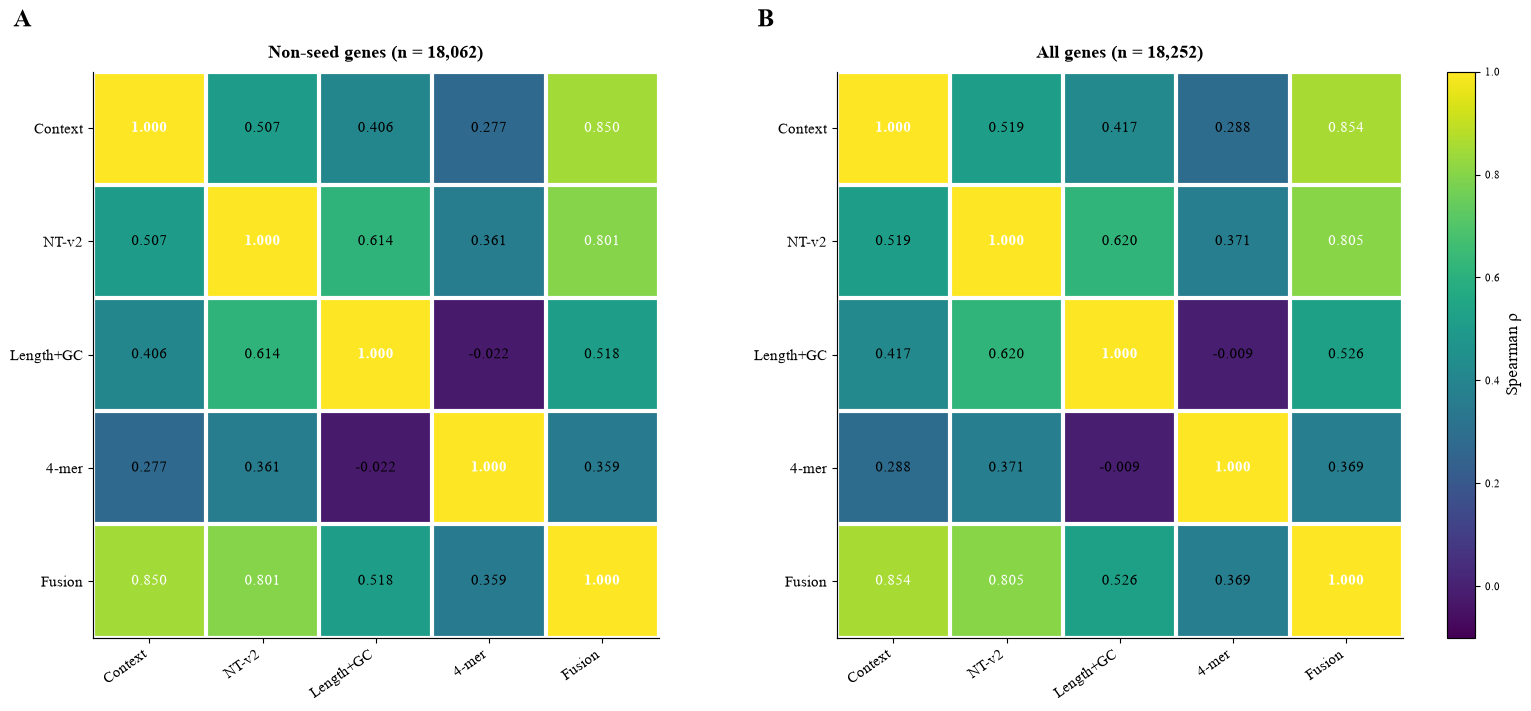


SAVED:
E:\ASD_ContextFusion_Q1\06_publication\FINAL_REWRITE_2026\supplementary\FigureS1_Prediction_Score_Correlations.pdf
E:\ASD_ContextFusion_Q1\06_publication\FINAL_REWRITE_2026\supplementary\FigureS1_Prediction_Score_Correlations.png
E:\ASD_ContextFusion_Q1\06_publication\FINAL_REWRITE_2026\supplementary\FigureS1_Prediction_Score_Correlations.svg
E:\ASD_ContextFusion_Q1\06_publication\FINAL_REWRITE_2026\supplementary\FigureS1A_nonseed_Spearman_matrix.tsv
E:\ASD_ContextFusion_Q1\06_publication\FINAL_REWRITE_2026\supplementary\FigureS1B_allgenes_Spearman_matrix.tsv


In [17]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ======================================================================================
# PATHS
# ======================================================================================

ROOT = Path(r"E:\ASD_ContextFusion_Q1")

IN_NONSEED = (
    ROOT / "05_results" / "proposed" / "reviewer_requested_additional_analyses" /
    "Reviewer13_Spearman_nonseed_18062_genes.tsv"
)

IN_ALLGENES = (
    ROOT / "05_results" / "proposed" / "reviewer_requested_additional_analyses" /
    "Reviewer13_Spearman_all_18252_genes.tsv"
)

OUT_DIR = ROOT / "06_publication" / "FINAL_REWRITE_2026" / "supplementary"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_FIG_STEM = "FigureS1_Prediction_Score_Correlations"
OUT_NONSEED_MATRIX = OUT_DIR / "FigureS1A_nonseed_Spearman_matrix.tsv"
OUT_ALLGENES_MATRIX = OUT_DIR / "FigureS1B_allgenes_Spearman_matrix.tsv"

# ======================================================================================
# SETTINGS
# ======================================================================================

MODEL_ORDER = ["Context", "NT-v2", "Length+GC", "4-mer", "Fusion"]
VMIN = -0.10
VMAX = 1.00

# ======================================================================================
# HELPERS
# ======================================================================================

def normalize_model_name(x):
    s = str(x).strip().lower()
    s = s.replace("_", "").replace(" ", "").replace("-", "")
    mapping = {
        "context": "Context",
        "ntv2": "NT-v2",
        "length+gc": "Length+GC",
        "lengthgc": "Length+GC",
        "4mer": "4-mer",
        "fusion": "Fusion",
    }
    if s not in mapping:
        raise ValueError(f"Unknown model label: {x}")
    return mapping[s]

def pick_col(df, candidates):
    lower_map = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    return None

def read_spearman_input(path):
    """
    Supports:
    1) square matrix file
    2) long/pairwise table with columns like model_1, model_2, spearman_rho
    """
    if not path.exists():
        raise FileNotFoundError(f"Missing input file:\n{path}")

    df = pd.read_csv(path, sep="\t")

    # ------------------------------------------------------------------
    # CASE 1: already a square matrix
    # ------------------------------------------------------------------
    # Example:
    #   model    Context NT-v2 Length+GC 4-mer Fusion
    #   Context  1.0 ...
    possible_index_col = df.columns[0]
    if len(df.columns) >= 2:
        temp = df.copy()
        if "Unnamed: 0" in temp.columns:
            temp = temp.rename(columns={"Unnamed: 0": "model"})
            possible_index_col = "model"

        if possible_index_col in temp.columns:
            temp = temp.set_index(possible_index_col)
            try:
                temp.index = [normalize_model_name(x) for x in temp.index]
                temp.columns = [normalize_model_name(x) for x in temp.columns]
                if set(MODEL_ORDER).issubset(set(temp.index)) and set(MODEL_ORDER).issubset(set(temp.columns)):
                    mat = temp.loc[MODEL_ORDER, MODEL_ORDER].astype(float)
                    return mat
            except Exception:
                pass

    # ------------------------------------------------------------------
    # CASE 2: long/pairwise table
    # ------------------------------------------------------------------
    c1 = pick_col(df, ["model_1", "model1", "row_model", "model_a", "model_x"])
    c2 = pick_col(df, ["model_2", "model2", "col_model", "model_b", "model_y"])
    cr = pick_col(df, ["spearman_rho", "rho", "spearman", "correlation", "corr"])

    if c1 is None or c2 is None or cr is None:
        raise ValueError(
            f"Could not identify model pair / rho columns in file:\n{path}\n"
            f"Columns found: {list(df.columns)}"
        )

    df = df[[c1, c2, cr]].copy()
    df[c1] = df[c1].map(normalize_model_name)
    df[c2] = df[c2].map(normalize_model_name)

    mat = pd.DataFrame(
        np.eye(len(MODEL_ORDER)),
        index=MODEL_ORDER,
        columns=MODEL_ORDER,
        dtype=float,
    )

    for _, row in df.iterrows():
        m1 = row[c1]
        m2 = row[c2]
        rho = float(row[cr])
        mat.loc[m1, m2] = rho
        mat.loc[m2, m1] = rho

    return mat

def draw_heatmap(ax, mat, title, panel_letter):
    im = ax.imshow(mat.values, vmin=VMIN, vmax=VMAX)

    ax.set_xticks(range(len(mat.columns)))
    ax.set_xticklabels(mat.columns, rotation=35, ha="right", fontsize=11)

    ax.set_yticks(range(len(mat.index)))
    ax.set_yticklabels(mat.index, fontsize=11)

    ax.set_title(title, fontsize=13, weight="bold", pad=10)

    # cell borders
    ax.set_xticks(np.arange(-0.5, len(mat.columns), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(mat.index), 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=3)
    ax.tick_params(which="minor", bottom=False, left=False)

    # annotations
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat.iloc[i, j]
            text_color = "white" if val >= 0.75 else "black"
            ax.text(
                j, i, f"{val:.3f}",
                ha="center", va="center",
                fontsize=11, color=text_color,
                fontweight="bold" if i == j else None
            )

    # panel label
    ax.text(
        -0.14, 1.08, panel_letter,
        transform=ax.transAxes,
        fontsize=18, fontweight="bold"
    )
    return im

# ======================================================================================
# LOAD
# ======================================================================================

nonseed_mat = read_spearman_input(IN_NONSEED)
allgenes_mat = read_spearman_input(IN_ALLGENES)

# sanity checks
assert list(nonseed_mat.index) == MODEL_ORDER
assert list(nonseed_mat.columns) == MODEL_ORDER
assert list(allgenes_mat.index) == MODEL_ORDER
assert list(allgenes_mat.columns) == MODEL_ORDER

# save matrices used in final figure
nonseed_mat.to_csv(OUT_NONSEED_MATRIX, sep="\t", index=True, index_label="model")
allgenes_mat.to_csv(OUT_ALLGENES_MATRIX, sep="\t", index=True, index_label="model")

# ======================================================================================
# PLOT
# ======================================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)

im = draw_heatmap(
    axes[0],
    nonseed_mat,
    "Non-seed genes (n = 18,062)",
    "A"
)

draw_heatmap(
    axes[1],
    allgenes_mat,
    "All genes (n = 18,252)",
    "B"
)

cbar = fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.025, pad=0.03)
cbar.set_label("Spearman ρ", fontsize=12)

# save final supplementary figure
for ext in ["pdf", "png", "svg"]:
    out_file = OUT_DIR / f"{OUT_FIG_STEM}.{ext}"
    if ext == "png":
        fig.savefig(out_file, dpi=600, bbox_inches="tight")
    else:
        fig.savefig(out_file, bbox_inches="tight")

plt.show()

print("\nSAVED:")
print(OUT_DIR / f"{OUT_FIG_STEM}.pdf")
print(OUT_DIR / f"{OUT_FIG_STEM}.png")
print(OUT_DIR / f"{OUT_FIG_STEM}.svg")
print(OUT_NONSEED_MATRIX)
print(OUT_ALLGENES_MATRIX)

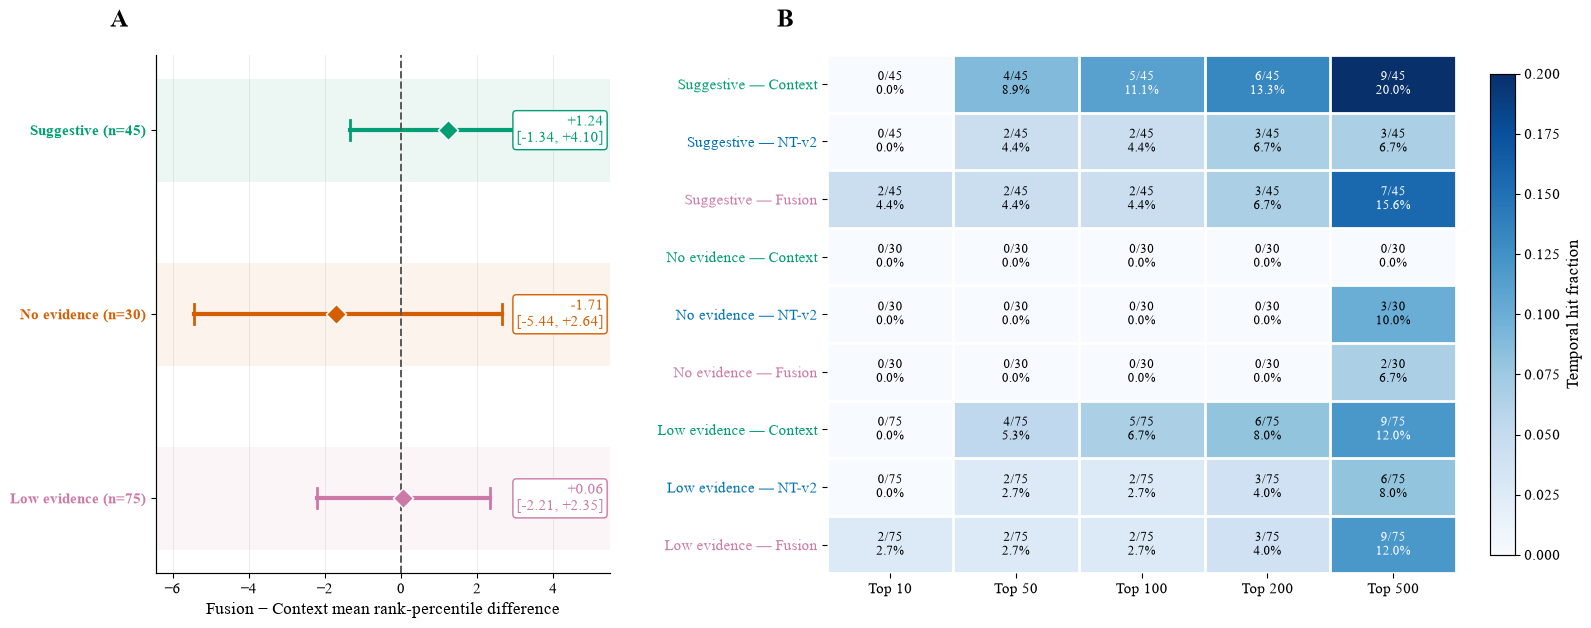


FIGURE S2 FINAL LOWER-EVIDENCE VERSION — QC PASS

Panel A groups:
Evidence_group  n  difference    ci_low  ci_high
    Suggestive 45    1.238888 -1.344748 4.095239
   No evidence 30   -1.714744 -5.442380 2.643292
  Low evidence 75    0.057435 -2.208194 2.351433

Saved files:
E:\ASD_ContextFusion_Q1\06_publication\FINAL_REWRITE_2026\supplementary\FigureS2_Lower_Evidence_Temporal_Analysis.pdf
E:\ASD_ContextFusion_Q1\06_publication\FINAL_REWRITE_2026\supplementary\FigureS2_Lower_Evidence_Temporal_Analysis.svg
E:\ASD_ContextFusion_Q1\06_publication\FINAL_REWRITE_2026\supplementary\FigureS2_Lower_Evidence_Temporal_Analysis.png
E:\ASD_ContextFusion_Q1\06_publication\FINAL_REWRITE_2026\supplementary\FigureS2_Lower_Evidence_Temporal_Analysis.tiff
E:\ASD_ContextFusion_Q1\06_publication\FINAL_REWRITE_2026\supplementary\FigureS2A_Fusion_Context_temporal_effects.tsv
E:\ASD_ContextFusion_Q1\06_publication\FINAL_REWRITE_2026\supplementary\FigureS2B_lower_evidence_topK.tsv

NO MODEL FITTING
NO NEW B

In [18]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize


# ======================================================================================
# FIGURE S2 — LOWER-EVIDENCE TEMPORAL VALIDATION
#
# FINAL CLEAN VERSION
# - Panel A: Suggestive45, NoEvidence30, LowEvidence75 ONLY
# - Broad134 removed because it is already shown in Main Figure 4
# - Panel B: fixed Top-K temporal recovery for lower-evidence groups
# - Models shown in Panel B: Context, NT-v2, Fusion
#
# NO MODEL FITTING
# NO NEW BOOTSTRAP
# NO NEW TEMPORAL ANALYSIS
# ======================================================================================


# ======================================================================================
# 1. PATHS
# ======================================================================================

ROOT = Path(r"E:\ASD_ContextFusion_Q1")

OUT_DIR = (
    ROOT
    / "06_publication"
    / "FINAL_REWRITE_2026"
    / "supplementary"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIG_STEM = "FigureS2_Lower_Evidence_Temporal_Analysis"

PANEL_A_SOURCE = (
    OUT_DIR
    / "FigureS2A_Fusion_Context_temporal_effects.tsv"
)

PANEL_B_SOURCE = (
    OUT_DIR
    / "FigureS2B_lower_evidence_topK.tsv"
)


# ======================================================================================
# 2. PUBLICATION STYLE
# ======================================================================================

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10.5,
    "ytick.labelsize": 10.5,
    "legend.fontsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})


# ======================================================================================
# 3. LOCKED PANEL A DATA
#    Fusion − Context temporal mean-rank-percentile difference
# ======================================================================================

panel_a = pd.DataFrame([
    {
        "Evidence_group": "Suggestive",
        "n": 45,
        "difference": 1.238888,
        "ci_low": -1.344748,
        "ci_high": 4.095239,
    },
    {
        "Evidence_group": "No evidence",
        "n": 30,
        "difference": -1.714744,
        "ci_low": -5.442380,
        "ci_high": 2.643292,
    },
    {
        "Evidence_group": "Low evidence",
        "n": 75,
        "difference": 0.057435,
        "ci_low": -2.208194,
        "ci_high": 2.351433,
    },
])

panel_a.to_csv(
    PANEL_A_SOURCE,
    sep="\t",
    index=False
)


# ======================================================================================
# 4. LOCKED PANEL B DATA
#    Fixed temporal recovery counts at K = 10, 50, 100, 200, 500
# ======================================================================================

K_VALUES = [10, 50, 100, 200, 500]

topk_counts = {
    ("Suggestive", "Context"): [0, 4, 5, 6, 9],
    ("Suggestive", "NT-v2"):   [0, 2, 2, 3, 3],
    ("Suggestive", "Fusion"):  [2, 2, 2, 3, 7],

    ("No evidence", "Context"): [0, 0, 0, 0, 0],
    ("No evidence", "NT-v2"):   [0, 0, 0, 0, 3],
    ("No evidence", "Fusion"):  [0, 0, 0, 0, 2],

    ("Low evidence", "Context"): [0, 4, 5, 6, 9],
    ("Low evidence", "NT-v2"):   [0, 2, 2, 3, 6],
    ("Low evidence", "Fusion"):  [2, 2, 2, 3, 9],
}

GROUP_N = {
    "Suggestive": 45,
    "No evidence": 30,
    "Low evidence": 75,
}

rows = []

for (group, model), counts in topk_counts.items():
    n = GROUP_N[group]

    for k, count in zip(K_VALUES, counts):
        rows.append({
            "Evidence_group": group,
            "Model": model,
            "K": k,
            "Hit_count": count,
            "Group_n": n,
            "Hit_fraction": count / n,
        })

panel_b = pd.DataFrame(rows)

panel_b.to_csv(
    PANEL_B_SOURCE,
    sep="\t",
    index=False
)


# ======================================================================================
# 5. PANEL B MATRIX
# ======================================================================================

row_order = [
    ("Suggestive", "Context"),
    ("Suggestive", "NT-v2"),
    ("Suggestive", "Fusion"),

    ("No evidence", "Context"),
    ("No evidence", "NT-v2"),
    ("No evidence", "Fusion"),

    ("Low evidence", "Context"),
    ("Low evidence", "NT-v2"),
    ("Low evidence", "Fusion"),
]

matrix = []
count_matrix = []
n_matrix = []

for group, model in row_order:
    d = (
        panel_b.loc[
            (panel_b["Evidence_group"] == group)
            & (panel_b["Model"] == model)
        ]
        .set_index("K")
        .loc[K_VALUES]
    )

    matrix.append(
        d["Hit_fraction"].to_numpy()
    )

    count_matrix.append(
        d["Hit_count"].to_numpy()
    )

    n_matrix.append(
        d["Group_n"].to_numpy()
    )

matrix = np.asarray(matrix)
count_matrix = np.asarray(count_matrix)
n_matrix = np.asarray(n_matrix)


# ======================================================================================
# 6. CREATE FIGURE
# ======================================================================================

fig = plt.figure(
    figsize=(15.8, 6.4)
)

gs = fig.add_gridspec(
    1,
    2,
    width_ratios=[0.86, 1.30],
    wspace=0.38
)

axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[0, 1])


# ======================================================================================
# 7. PANEL A — LOWER-EVIDENCE FUSION − CONTEXT EFFECTS
# ======================================================================================

panel_a_colors = [
    "#009E73",   # Suggestive
    "#D55E00",   # No evidence
    "#CC79A7",   # Low evidence
]

y = np.arange(
    len(panel_a)
)[::-1]

for idx, (_, row) in enumerate(
    panel_a.iterrows()
):
    yy = y[idx]
    color = panel_a_colors[idx]

    # subtle background band
    axA.axhspan(
        yy - 0.28,
        yy + 0.28,
        color=color,
        alpha=0.075,
        linewidth=0
    )

    # CI
    axA.plot(
        [
            row["ci_low"],
            row["ci_high"]
        ],
        [yy, yy],
        color=color,
        linewidth=3
    )

    # CI end caps
    axA.plot(
        [
            row["ci_low"],
            row["ci_low"]
        ],
        [
            yy - 0.055,
            yy + 0.055
        ],
        color=color,
        linewidth=2
    )

    axA.plot(
        [
            row["ci_high"],
            row["ci_high"]
        ],
        [
            yy - 0.055,
            yy + 0.055
        ],
        color=color,
        linewidth=2
    )

    # estimate
    axA.scatter(
        row["difference"],
        yy,
        marker="D",
        s=105,
        color=color,
        edgecolor="white",
        linewidth=1.1,
        zorder=5
    )

    # text box
    label = (
        f'{row["difference"]:+.2f}\n'
        f'[{row["ci_low"]:+.2f}, '
        f'{row["ci_high"]:+.2f}]'
    )

    axA.text(
        0.985,
        yy,
        label,
        transform=axA.get_yaxis_transform(),
        ha="right",
        va="center",
        fontsize=10.5,
        color=color,
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor=color,
            linewidth=1
        )
    )


# null line
axA.axvline(
    0,
    color="0.35",
    linestyle="--",
    linewidth=1.4
)

axA.set_yticks(y)

axA.set_yticklabels([
    "Suggestive (n=45)",
    "No evidence (n=30)",
    "Low evidence (n=75)",
])

for tick, color in zip(
    axA.get_yticklabels(),
    panel_a_colors
):
    tick.set_color(color)
    tick.set_fontweight("bold")

axA.set_xlabel(
    "Fusion − Context mean rank-percentile difference"
)

axA.grid(
    axis="x",
    linewidth=0.55,
    alpha=0.30
)

# enough room for all CIs
xmin = min(
    panel_a["ci_low"].min() - 1.0,
    -6.0
)

xmax = max(
    panel_a["ci_high"].max() + 1.0,
    5.5
)

axA.set_xlim(
    xmin,
    xmax
)

axA.text(
    -0.10,
    1.055,
    "A",
    transform=axA.transAxes,
    fontsize=18,
    fontweight="bold"
)


# ======================================================================================
# 8. PANEL B — LOWER-EVIDENCE FIXED TOP-K RECOVERY
# ======================================================================================

norm = Normalize(
    vmin=0.0,
    vmax=0.20
)

im = axB.imshow(
    matrix,
    cmap="Blues",
    norm=norm,
    aspect="auto"
)

axB.set_xticks(
    np.arange(
        len(K_VALUES)
    )
)

axB.set_xticklabels([
    "Top 10",
    "Top 50",
    "Top 100",
    "Top 200",
    "Top 500",
])

row_labels = [
    "Suggestive — Context",
    "Suggestive — NT-v2",
    "Suggestive — Fusion",

    "No evidence — Context",
    "No evidence — NT-v2",
    "No evidence — Fusion",

    "Low evidence — Context",
    "Low evidence — NT-v2",
    "Low evidence — Fusion",
]

axB.set_yticks(
    np.arange(
        len(row_labels)
    )
)

axB.set_yticklabels(
    row_labels
)


# color model labels
model_colors = {
    "Context": "#009E73",
    "NT-v2": "#0072B2",
    "Fusion": "#CC79A7",
}

for tick in axB.get_yticklabels():
    text = tick.get_text()

    if "Context" in text:
        tick.set_color(
            model_colors["Context"]
        )

    elif "NT-v2" in text:
        tick.set_color(
            model_colors["NT-v2"]
        )

    elif "Fusion" in text:
        tick.set_color(
            model_colors["Fusion"]
        )


# white borders between heatmap cells
axB.set_xticks(
    np.arange(
        -0.5,
        len(K_VALUES),
        1
    ),
    minor=True
)

axB.set_yticks(
    np.arange(
        -0.5,
        len(row_labels),
        1
    ),
    minor=True
)

axB.grid(
    which="minor",
    color="white",
    linewidth=2
)

axB.tick_params(
    which="minor",
    bottom=False,
    left=False
)


# annotate each heatmap cell
for i in range(
    matrix.shape[0]
):
    for j in range(
        matrix.shape[1]
    ):

        count = int(
            count_matrix[i, j]
        )

        n = int(
            n_matrix[i, j]
        )

        frac = matrix[i, j]

        txt = (
            f"{count}/{n}\n"
            f"{100 * frac:.1f}%"
        )

        text_color = (
            "white"
            if frac >= 0.11
            else "black"
        )

        axB.text(
            j,
            i,
            txt,
            ha="center",
            va="center",
            fontsize=9.4,
            color=text_color
        )


# remove unnecessary spines
for side in [
    "top",
    "right",
    "left",
    "bottom"
]:
    axB.spines[side].set_visible(
        False
    )


# colorbar
cbar = fig.colorbar(
    im,
    ax=axB,
    fraction=0.035,
    pad=0.05
)

cbar.set_label(
    "Temporal hit fraction"
)

cbar.ax.yaxis.set_major_formatter(
    lambda x, pos: f"{x:.3f}"
)


axB.text(
    -0.08,
    1.055,
    "B",
    transform=axB.transAxes,
    fontsize=18,
    fontweight="bold"
)


# ======================================================================================
# 9. FINAL LAYOUT
# ======================================================================================

fig.subplots_adjust(
    left=0.105,
    right=0.965,
    bottom=0.13,
    top=0.94,
    wspace=0.42
)


# ======================================================================================
# 10. SAVE
# ======================================================================================

PDF_FILE = (
    OUT_DIR
    / f"{FIG_STEM}.pdf"
)

SVG_FILE = (
    OUT_DIR
    / f"{FIG_STEM}.svg"
)

PNG_FILE = (
    OUT_DIR
    / f"{FIG_STEM}.png"
)

TIFF_FILE = (
    OUT_DIR
    / f"{FIG_STEM}.tiff"
)


fig.savefig(
    PDF_FILE,
    bbox_inches="tight"
)

fig.savefig(
    SVG_FILE,
    bbox_inches="tight"
)

fig.savefig(
    PNG_FILE,
    dpi=600,
    bbox_inches="tight"
)

fig.savefig(
    TIFF_FILE,
    dpi=600,
    bbox_inches="tight"
)

plt.show()


# ======================================================================================
# 11. QC
# ======================================================================================

assert len(panel_a) == 3

assert set(
    panel_a["Evidence_group"]
) == {
    "Suggestive",
    "No evidence",
    "Low evidence",
}

# Make sure Broad134 cannot accidentally re-enter Panel A.
assert (
    "Broad"
    not in panel_a[
        "Evidence_group"
    ].astype(str).tolist()
)

# Frozen Fusion − Context effects
np.testing.assert_allclose(
    panel_a[
        "difference"
    ].to_numpy(),
    [
        1.238888,
        -1.714744,
        0.057435,
    ],
    rtol=0,
    atol=1e-9
)

# Expected lower-evidence top-K row count:
# 3 evidence groups × 3 models × 5 K values
assert len(
    panel_b
) == 45


print(
    "\n"
    + "=" * 90
)

print(
    "FIGURE S2 FINAL LOWER-EVIDENCE VERSION — QC PASS"
)

print(
    "=" * 90
)

print(
    "\nPanel A groups:"
)

print(
    panel_a[
        [
            "Evidence_group",
            "n",
            "difference",
            "ci_low",
            "ci_high",
        ]
    ].to_string(
        index=False
    )
)

print(
    "\nSaved files:"
)

print(
    PDF_FILE
)

print(
    SVG_FILE
)

print(
    PNG_FILE
)

print(
    TIFF_FILE
)

print(
    PANEL_A_SOURCE
)

print(
    PANEL_B_SOURCE
)

print(
    "\nNO MODEL FITTING"
)

print(
    "NO NEW BOOTSTRAP"
)

print(
    "NO NEW TEMPORAL ANALYSIS"
)

In [20]:
from pathlib import Path

from docx import Document
from docx.shared import Inches, Pt, RGBColor
from docx.enum.section import WD_ORIENT
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.table import WD_TABLE_ALIGNMENT, WD_CELL_VERTICAL_ALIGNMENT
from docx.oxml import OxmlElement
from docx.oxml.ns import qn


# =============================================================================
# PATHS
# =============================================================================

ROOT = Path(r"E:\ASD_ContextFusion_Q1")

INPUT_FILE = (
    ROOT
    / "06_publication"
    / "FINAL_REWRITE_2026"
    / "supplementary"
    / "TableS1_Study_Design_and_Reproducibility.docx"
)

OUTPUT_FILE = (
    ROOT
    / "06_publication"
    / "FINAL_REWRITE_2026"
    / "supplementary"
    / "TableS1_Study_Design_and_Reproducibility_FINAL.docx"
)


# =============================================================================
# LOW-LEVEL HELPERS
# =============================================================================

def set_cell_border(cell, **kwargs):
    """
    Example:
    set_cell_border(
        cell,
        top={"sz": 8, "val": "single", "color": "000000"},
        bottom={"sz": 8, "val": "single", "color": "000000"},
        start={"sz": 8, "val": "single", "color": "000000"},
        end={"sz": 8, "val": "single", "color": "000000"},
    )

    sz is in eighths of a point:
    4 = 0.5 pt
    6 = 0.75 pt
    8 = 1.0 pt
    """

    tc = cell._tc
    tcPr = tc.get_or_add_tcPr()

    tcBorders = tcPr.first_child_found_in("w:tcBorders")

    if tcBorders is None:
        tcBorders = OxmlElement("w:tcBorders")
        tcPr.append(tcBorders)

    for edge in ("top", "start", "bottom", "end", "insideH", "insideV"):

        if edge not in kwargs:
            continue

        edge_data = kwargs.get(edge)

        tag = "w:{}".format(edge)

        element = tcBorders.find(qn(tag))

        if element is None:
            element = OxmlElement(tag)
            tcBorders.append(element)

        for key, value in edge_data.items():
            element.set(
                qn("w:{}".format(key)),
                str(value)
            )


def remove_cell_shading(cell):
    """
    Remove all background/shading from a cell.
    """
    tcPr = cell._tc.get_or_add_tcPr()

    for shd in list(tcPr.findall(qn("w:shd"))):
        tcPr.remove(shd)


def set_cell_margins(
    cell,
    top=80,
    start=90,
    bottom=80,
    end=90
):
    tc = cell._tc
    tcPr = tc.get_or_add_tcPr()

    tcMar = tcPr.first_child_found_in("w:tcMar")

    if tcMar is None:
        tcMar = OxmlElement("w:tcMar")
        tcPr.append(tcMar)

    for margin_name, margin_value in [
        ("top", top),
        ("start", start),
        ("bottom", bottom),
        ("end", end),
    ]:

        node = tcMar.find(
            qn(f"w:{margin_name}")
        )

        if node is None:
            node = OxmlElement(
                f"w:{margin_name}"
            )
            tcMar.append(node)

        node.set(
            qn("w:w"),
            str(margin_value)
        )

        node.set(
            qn("w:type"),
            "dxa"
        )


def set_repeat_table_header(row):
    trPr = row._tr.get_or_add_trPr()

    tblHeader = OxmlElement("w:tblHeader")
    tblHeader.set(
        qn("w:val"),
        "true"
    )

    trPr.append(tblHeader)


def prevent_row_split(row):
    """
    Prevent table row splitting across two Word pages.
    """
    trPr = row._tr.get_or_add_trPr()

    cantSplit = OxmlElement("w:cantSplit")
    cantSplit.set(
        qn("w:val"),
        "true"
    )

    trPr.append(cantSplit)


def is_merged_section_row(row):
    """
    Detect rows where all 3 displayed cells are the same merged XML cell.
    """

    if len(row.cells) < 3:
        return False

    return (
        row.cells[0]._tc is row.cells[1]._tc
        and
        row.cells[1]._tc is row.cells[2]._tc
    )


def set_run_font(
    run,
    size=9,
    bold=False,
    italic=False
):
    run.font.name = "Times New Roman"
    run.font.size = Pt(size)
    run.font.bold = bold
    run.font.italic = italic

    # force black text
    run.font.color.rgb = RGBColor(
        0,
        0,
        0
    )

    # ensure Word uses TNR for all scripts
    rPr = run._element.get_or_add_rPr()

    rFonts = rPr.rFonts

    if rFonts is None:
        rFonts = OxmlElement("w:rFonts")
        rPr.append(rFonts)

    rFonts.set(
        qn("w:ascii"),
        "Times New Roman"
    )

    rFonts.set(
        qn("w:hAnsi"),
        "Times New Roman"
    )

    rFonts.set(
        qn("w:eastAsia"),
        "Times New Roman"
    )

    rFonts.set(
        qn("w:cs"),
        "Times New Roman"
    )


# =============================================================================
# LOAD DOCUMENT
# =============================================================================

if not INPUT_FILE.exists():
    raise FileNotFoundError(
        f"Input DOCX not found:\n{INPUT_FILE}"
    )

doc = Document(
    INPUT_FILE
)


# =============================================================================
# PAGE SETUP
# =============================================================================

section = doc.sections[0]

section.orientation = WD_ORIENT.LANDSCAPE

section.page_width = Inches(11)
section.page_height = Inches(8.5)

section.top_margin = Inches(0.55)
section.bottom_margin = Inches(0.55)
section.left_margin = Inches(0.55)
section.right_margin = Inches(0.55)


# =============================================================================
# DOCUMENT-LEVEL PARAGRAPHS
# =============================================================================

for i, paragraph in enumerate(doc.paragraphs):

    paragraph.paragraph_format.space_before = Pt(0)

    if i == 0:
        # Table title
        paragraph.alignment = WD_ALIGN_PARAGRAPH.CENTER
        paragraph.paragraph_format.space_after = Pt(5)
        paragraph.paragraph_format.keep_with_next = True

        for run in paragraph.runs:
            set_run_font(
                run,
                size=11,
                bold=True
            )

    elif i == 1:
        # explanatory note
        paragraph.alignment = WD_ALIGN_PARAGRAPH.LEFT
        paragraph.paragraph_format.space_after = Pt(7)
        paragraph.paragraph_format.line_spacing = 1.0
        paragraph.paragraph_format.keep_with_next = True

        for run in paragraph.runs:
            set_run_font(
                run,
                size=8.5,
                italic=True
            )

    else:
        for run in paragraph.runs:
            set_run_font(
                run,
                size=9
            )


# =============================================================================
# TABLE FORMATTING
# =============================================================================

if len(doc.tables) != 1:
    print(
        f"WARNING: document contains {len(doc.tables)} tables."
    )

table = doc.tables[0]

table.alignment = WD_TABLE_ALIGNMENT.CENTER
table.autofit = False

# Use Word's plain grid style as baseline.
table.style = "Table Grid"


# -----------------------------------------------------------------------------
# Column widths
# -----------------------------------------------------------------------------

col_widths = [
    Inches(2.15),
    Inches(2.20),
    Inches(5.25),
]

for row in table.rows:

    for idx, width in enumerate(col_widths):

        if idx < len(row.cells):
            row.cells[idx].width = width


# =============================================================================
# FORMAT EACH ROW
# =============================================================================

for row_index, row in enumerate(table.rows):

    prevent_row_split(
        row
    )

    section_row = is_merged_section_row(
        row
    )

    # -------------------------------------------------------------------------
    # HEADER ROW
    # -------------------------------------------------------------------------

    if row_index == 0:

        set_repeat_table_header(
            row
        )

        for cell in row.cells:

            remove_cell_shading(
                cell
            )

            cell.vertical_alignment = (
                WD_CELL_VERTICAL_ALIGNMENT.CENTER
            )

            set_cell_margins(
                cell,
                top=90,
                start=90,
                bottom=90,
                end=90
            )

            # full black grid
            set_cell_border(
                cell,
                top={
                    "val": "single",
                    "sz": "8",
                    "color": "000000"
                },
                bottom={
                    "val": "single",
                    "sz": "8",
                    "color": "000000"
                },
                start={
                    "val": "single",
                    "sz": "8",
                    "color": "000000"
                },
                end={
                    "val": "single",
                    "sz": "8",
                    "color": "000000"
                },
            )

            for paragraph in cell.paragraphs:

                paragraph.alignment = (
                    WD_ALIGN_PARAGRAPH.CENTER
                )

                paragraph.paragraph_format.space_before = Pt(0)
                paragraph.paragraph_format.space_after = Pt(0)
                paragraph.paragraph_format.line_spacing = 1.0

                for run in paragraph.runs:
                    set_run_font(
                        run,
                        size=9,
                        bold=True
                    )

        continue


    # -------------------------------------------------------------------------
    # SECTION HEADER ROW
    # -------------------------------------------------------------------------

    if section_row:

        cell = row.cells[0]

        remove_cell_shading(
            cell
        )

        cell.vertical_alignment = (
            WD_CELL_VERTICAL_ALIGNMENT.CENTER
        )

        set_cell_margins(
            cell,
            top=80,
            start=90,
            bottom=80,
            end=90
        )

        # slightly stronger top/bottom separator
        set_cell_border(
            cell,
            top={
                "val": "single",
                "sz": "8",
                "color": "000000"
            },
            bottom={
                "val": "single",
                "sz": "8",
                "color": "000000"
            },
            start={
                "val": "single",
                "sz": "4",
                "color": "000000"
            },
            end={
                "val": "single",
                "sz": "4",
                "color": "000000"
            },
        )

        for paragraph in cell.paragraphs:

            paragraph.alignment = (
                WD_ALIGN_PARAGRAPH.LEFT
            )

            paragraph.paragraph_format.space_before = Pt(0)
            paragraph.paragraph_format.space_after = Pt(0)
            paragraph.paragraph_format.line_spacing = 1.0

            for run in paragraph.runs:
                set_run_font(
                    run,
                    size=9,
                    bold=True
                )

        continue


    # -------------------------------------------------------------------------
    # NORMAL BODY ROW
    # -------------------------------------------------------------------------

    for col_index, cell in enumerate(row.cells):

        remove_cell_shading(
            cell
        )

        cell.vertical_alignment = (
            WD_CELL_VERTICAL_ALIGNMENT.CENTER
        )

        set_cell_margins(
            cell,
            top=75,
            start=85,
            bottom=75,
            end=85
        )

        # complete thin black grid
        set_cell_border(
            cell,
            top={
                "val": "single",
                "sz": "4",
                "color": "000000"
            },
            bottom={
                "val": "single",
                "sz": "4",
                "color": "000000"
            },
            start={
                "val": "single",
                "sz": "4",
                "color": "000000"
            },
            end={
                "val": "single",
                "sz": "4",
                "color": "000000"
            },
        )

        for paragraph in cell.paragraphs:

            paragraph.paragraph_format.space_before = Pt(0)
            paragraph.paragraph_format.space_after = Pt(0)
            paragraph.paragraph_format.line_spacing = 1.0

            # Item + specification left aligned.
            # Details also left aligned for readability.
            paragraph.alignment = (
                WD_ALIGN_PARAGRAPH.LEFT
            )

            for run in paragraph.runs:

                if col_index == 0:
                    set_run_font(
                        run,
                        size=8.8
                    )

                elif col_index == 1:
                    set_run_font(
                        run,
                        size=8.8
                    )

                else:
                    set_run_font(
                        run,
                        size=8.6
                    )


# =============================================================================
# ENSURE ALL CELL TEXT IS BLACK AND TIMES NEW ROMAN
# =============================================================================

for row in table.rows:

    for cell in row.cells:

        remove_cell_shading(
            cell
        )

        for paragraph in cell.paragraphs:

            for run in paragraph.runs:

                # preserve existing bold/italic status
                current_bold = bool(
                    run.bold
                )

                current_italic = bool(
                    run.italic
                )

                size = (
                    run.font.size.pt
                    if run.font.size
                    else 8.8
                )

                set_run_font(
                    run,
                    size=size,
                    bold=current_bold,
                    italic=current_italic
                )


# =============================================================================
# SAVE
# =============================================================================

doc.save(
    OUTPUT_FILE
)


# =============================================================================
# FINAL REPORT
# =============================================================================

print("=" * 100)
print("PUBLICATION-STYLE TABLE S1 CREATED")
print("=" * 100)

print("\nOutput:")
print(OUTPUT_FILE)

print("\nFormatting:")
print("  Times New Roman throughout")
print("  Black text only")
print("  No background colors")
print("  No table shading")
print("  Full black grid")
print("  Header repeated on each page")
print("  Rows protected from page splitting")
print("  Landscape orientation")
print("  Publication-style spacing")

print("\nContent was not changed.")
print("Only formatting was modified.")

PUBLICATION-STYLE TABLE S1 CREATED

Output:
E:\ASD_ContextFusion_Q1\06_publication\FINAL_REWRITE_2026\supplementary\TableS1_Study_Design_and_Reproducibility_FINAL.docx

Formatting:
  Times New Roman throughout
  Black text only
  No background colors
  No table shading
  Full black grid
  Header repeated on each page
  Rows protected from page splitting
  Landscape orientation
  Publication-style spacing

Content was not changed.
Only formatting was modified.


In [21]:
from pathlib import Path

from docx import Document
from docx.shared import Inches, Pt, RGBColor
from docx.enum.section import WD_ORIENT
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.table import WD_TABLE_ALIGNMENT, WD_CELL_VERTICAL_ALIGNMENT
from docx.oxml import OxmlElement
from docx.oxml.ns import qn


# =============================================================================
# OUTPUT
# =============================================================================

ROOT = Path(r"E:\ASD_ContextFusion_Q1")

OUT_DIR = (
    ROOT
    / "06_publication"
    / "FINAL_REWRITE_2026"
    / "supplementary"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

OUT_FILE = (
    OUT_DIR
    / "TableS2_Sequence_Representation_Features.docx"
)


# =============================================================================
# HELPERS
# =============================================================================

def set_cell_border(cell, size="4"):
    """Apply full black border to a cell."""

    tcPr = cell._tc.get_or_add_tcPr()

    tcBorders = tcPr.first_child_found_in("w:tcBorders")

    if tcBorders is None:
        tcBorders = OxmlElement("w:tcBorders")
        tcPr.append(tcBorders)

    for edge in ["top", "start", "bottom", "end"]:

        tag = f"w:{edge}"

        element = tcBorders.find(
            qn(tag)
        )

        if element is None:
            element = OxmlElement(tag)
            tcBorders.append(element)

        element.set(
            qn("w:val"),
            "single"
        )

        element.set(
            qn("w:sz"),
            size
        )

        element.set(
            qn("w:color"),
            "000000"
        )


def remove_cell_shading(cell):
    tcPr = cell._tc.get_or_add_tcPr()

    for shd in list(
        tcPr.findall(
            qn("w:shd")
        )
    ):
        tcPr.remove(shd)


def set_cell_margins(
    cell,
    top=85,
    start=90,
    bottom=85,
    end=90
):

    tcPr = cell._tc.get_or_add_tcPr()

    tcMar = tcPr.first_child_found_in(
        "w:tcMar"
    )

    if tcMar is None:
        tcMar = OxmlElement("w:tcMar")
        tcPr.append(tcMar)

    for name, value in [
        ("top", top),
        ("start", start),
        ("bottom", bottom),
        ("end", end),
    ]:

        node = tcMar.find(
            qn(f"w:{name}")
        )

        if node is None:
            node = OxmlElement(
                f"w:{name}"
            )

            tcMar.append(node)

        node.set(
            qn("w:w"),
            str(value)
        )

        node.set(
            qn("w:type"),
            "dxa"
        )


def set_repeat_header(row):

    trPr = row._tr.get_or_add_trPr()

    tblHeader = OxmlElement(
        "w:tblHeader"
    )

    tblHeader.set(
        qn("w:val"),
        "true"
    )

    trPr.append(
        tblHeader
    )


def prevent_row_split(row):

    trPr = row._tr.get_or_add_trPr()

    cantSplit = OxmlElement(
        "w:cantSplit"
    )

    cantSplit.set(
        qn("w:val"),
        "true"
    )

    trPr.append(
        cantSplit
    )


def set_run_font(
    run,
    size=9,
    bold=False,
    italic=False
):

    run.font.name = "Times New Roman"

    run.font.size = Pt(
        size
    )

    run.font.bold = bold
    run.font.italic = italic

    run.font.color.rgb = RGBColor(
        0,
        0,
        0
    )

    rPr = run._element.get_or_add_rPr()

    rFonts = rPr.rFonts

    if rFonts is None:

        rFonts = OxmlElement(
            "w:rFonts"
        )

        rPr.append(
            rFonts
        )

    for attr in [
        "ascii",
        "hAnsi",
        "eastAsia",
        "cs"
    ]:

        rFonts.set(
            qn(
                f"w:{attr}"
            ),
            "Times New Roman"
        )


# =============================================================================
# TABLE DATA
# =============================================================================

rows = [

    {
        "Representation": "Length+GC",

        "Dimensions": "2",

        "Input": (
            "One fixed GENCODE v50 representative "
            "transcript per gene"
        ),

        "Feature_definition": (
            "Transcript length and GC proportion."
        ),

        "Scope": (
            "Minimal intrinsic transcript-composition control. "
            "Tests whether predictive performance can be explained "
            "by basic sequence length and nucleotide composition."
        ),
    },

    {
        "Representation": "4-mer",

        "Dimensions": "256",

        "Input": (
            "Same fixed representative transcript used for NT-v2"
        ),

        "Feature_definition": (
            "Frequency of all 256 oriented nucleotide 4-mers."
        ),

        "Scope": (
            "Explicit short-range sequence-composition control. "
            "Captures local nucleotide-word frequencies but does not "
            "model learned higher-order sequence representations."
        ),
    },

    {
        "Representation": "ExpandedSimple",

        "Dimensions": "340",

        "Input": (
            "Same fixed representative transcript used for NT-v2"
        ),

        "Feature_definition": (
            "1 transcript-length feature + "
            "1 GC feature + "
            "1 CpG observed/expected feature + "
            "16 oriented dimer frequencies + "
            "64 oriented trimer frequencies + "
            "1 normalized trinucleotide Shannon-entropy feature + "
            "256 oriented 4-mer frequencies."
        ),

        "Scope": (
            "Stronger explicit intrinsic transcript-sequence control. "
            "Tests whether the NT-v2 signal can be explained by a broader "
            "set of directly measurable sequence-composition properties. "
            "It is not an exhaustive decomposition of conservation, "
            "repeat architecture, locus-level regulation, or "
            "coding-sequence-specific properties."
        ),
    },

    {
        "Representation": "NT-v2",

        "Dimensions": "512",

        "Input": (
            "Same fixed representative transcript; "
            "locked gene-level NT-v2 embedding matrix"
        ),

        "Feature_definition": (
            "512-dimensional representation generated with "
            "InstaDeepAI/nucleotide-transformer-v2-50m-multi-species. "
            "The pretrained model was used as a fixed feature extractor "
            "without ASD-specific fine-tuning."
        ),

        "Scope": (
            "Learned nucleotide representation evaluated for incremental "
            "predictive information beyond the explicit transcript controls. "
            "The study evaluates this specific NT-v2 representation and does "
            "not establish superiority of genomic foundation models generally. "
            "Exact pooling/aggregation provenance and its forensic caveat are "
            "reported in Supplementary Table S1."
        ),
    },

]


# =============================================================================
# CREATE DOCUMENT
# =============================================================================

doc = Document()

section = doc.sections[0]

section.orientation = WD_ORIENT.LANDSCAPE

section.page_width = Inches(11)
section.page_height = Inches(8.5)

section.top_margin = Inches(0.65)
section.bottom_margin = Inches(0.65)
section.left_margin = Inches(0.60)
section.right_margin = Inches(0.60)


# =============================================================================
# TITLE
# =============================================================================

p = doc.add_paragraph()

p.alignment = (
    WD_ALIGN_PARAGRAPH.CENTER
)

p.paragraph_format.space_after = Pt(
    7
)

title_run = p.add_run(
    "Supplementary Table S2. Sequence representation features"
)

set_run_font(
    title_run,
    size=11,
    bold=True
)


# =============================================================================
# TABLE
# =============================================================================

table = doc.add_table(
    rows=1,
    cols=5
)

table.style = "Table Grid"

table.alignment = (
    WD_TABLE_ALIGNMENT.CENTER
)

table.autofit = False


# Column widths
widths = [
    Inches(1.35),
    Inches(0.90),
    Inches(2.05),
    Inches(3.25),
    Inches(3.05),
]


headers = [
    "Representation",
    "Dimensions",
    "Sequence input",
    "Feature definition",
    "Interpretation / scope",
]


# =============================================================================
# HEADER ROW
# =============================================================================

header_row = table.rows[0]

set_repeat_header(
    header_row
)

prevent_row_split(
    header_row
)

for i, header in enumerate(
    headers
):

    cell = header_row.cells[i]

    cell.width = widths[i]

    cell.text = header

    remove_cell_shading(
        cell
    )

    set_cell_border(
        cell,
        size="8"
    )

    set_cell_margins(
        cell,
        top=95,
        start=90,
        bottom=95,
        end=90
    )

    cell.vertical_alignment = (
        WD_CELL_VERTICAL_ALIGNMENT.CENTER
    )

    for paragraph in cell.paragraphs:

        paragraph.alignment = (
            WD_ALIGN_PARAGRAPH.CENTER
        )

        paragraph.paragraph_format.space_before = Pt(
            0
        )

        paragraph.paragraph_format.space_after = Pt(
            0
        )

        paragraph.paragraph_format.line_spacing = 1.0

        for run in paragraph.runs:

            set_run_font(
                run,
                size=9,
                bold=True
            )


# =============================================================================
# BODY ROWS
# =============================================================================

for record in rows:

    row = table.add_row()

    prevent_row_split(
        row
    )

    values = [

        record["Representation"],

        record["Dimensions"],

        record["Input"],

        record["Feature_definition"],

        record["Scope"],
    ]

    for col_index, value in enumerate(
        values
    ):

        cell = row.cells[
            col_index
        ]

        cell.width = widths[
            col_index
        ]

        cell.text = str(
            value
        )

        remove_cell_shading(
            cell
        )

        set_cell_border(
            cell,
            size="4"
        )

        set_cell_margins(
            cell,
            top=90,
            start=90,
            bottom=90,
            end=90
        )

        cell.vertical_alignment = (
            WD_CELL_VERTICAL_ALIGNMENT.CENTER
        )

        for paragraph in cell.paragraphs:

            paragraph.paragraph_format.space_before = Pt(
                0
            )

            paragraph.paragraph_format.space_after = Pt(
                0
            )

            paragraph.paragraph_format.line_spacing = 1.05

            if col_index == 1:

                paragraph.alignment = (
                    WD_ALIGN_PARAGRAPH.CENTER
                )

            else:

                paragraph.alignment = (
                    WD_ALIGN_PARAGRAPH.LEFT
                )

            for run in paragraph.runs:

                set_run_font(
                    run,
                    size=8.8,
                    bold=(
                        col_index == 0
                    )
                )


# =============================================================================
# FOOTNOTES / TABLE NOTES
# =============================================================================

note = doc.add_paragraph()

note.paragraph_format.space_before = Pt(
    6
)

note.paragraph_format.space_after = Pt(
    0
)

note.paragraph_format.line_spacing = 1.0


r1 = note.add_run(
    "Note. "
)

set_run_font(
    r1,
    size=8.5,
    bold=True
)


r2 = note.add_run(
    "All four sequence representations were derived from the same "
    "prespecified representative transcript per gene. "
    "All were evaluated using the same frozen positive-unlabeled partitions. "
    "NT-v2, Length+GC, 4-mer, and ExpandedSimple were evaluated with a "
    "training-fold StandardScaler followed by L2 logistic regression "
    "(C = 1.0, solver = lbfgs, max_iter = 2000), with no study-specific "
    "hyperparameter tuning. Standardization was fitted within each training "
    "fold only."
)

set_run_font(
    r2,
    size=8.5
)


note2 = doc.add_paragraph()

note2.paragraph_format.space_before = Pt(
    2
)

note2.paragraph_format.space_after = Pt(
    0
)

note2.paragraph_format.line_spacing = 1.0


r3 = note2.add_run(
    "Abbreviations: "
)

set_run_font(
    r3,
    size=8.5,
    bold=True
)


r4 = note2.add_run(
    "GC, guanine-cytosine; "
    "CpG, cytosine-phosphate-guanine; "
    "NT-v2, Nucleotide Transformer v2."
)

set_run_font(
    r4,
    size=8.5
)


# =============================================================================
# FINAL FONT ENFORCEMENT
# =============================================================================

for paragraph in doc.paragraphs:

    for run in paragraph.runs:

        current_size = (
            run.font.size.pt
            if run.font.size
            else 9
        )

        set_run_font(
            run,
            size=current_size,
            bold=bool(
                run.bold
            ),
            italic=bool(
                run.italic
            )
        )


for table_obj in doc.tables:

    for row in table_obj.rows:

        for cell in row.cells:

            remove_cell_shading(
                cell
            )

            for paragraph in cell.paragraphs:

                for run in paragraph.runs:

                    current_size = (
                        run.font.size.pt
                        if run.font.size
                        else 8.8
                    )

                    set_run_font(
                        run,
                        size=current_size,
                        bold=bool(
                            run.bold
                        ),
                        italic=bool(
                            run.italic
                        )
                    )


# =============================================================================
# SAVE
# =============================================================================

doc.save(
    OUT_FILE
)


# =============================================================================
# REPORT
# =============================================================================

print(
    "=" * 100
)

print(
    "SUPPLEMENTARY TABLE S2 CREATED"
)

print(
    "=" * 100
)

print(
    "\nOutput:"
)

print(
    OUT_FILE
)

print(
    "\nQC:"
)

print(
    "Length+GC dimensions   = 2"
)

print(
    "4-mer dimensions       = 256"
)

print(
    "ExpandedSimple         = 340"
)

print(
    "NT-v2 dimensions       = 512"
)

print(
    "\nFormatting:"
)

print(
    "Times New Roman"
)

print(
    "Black text only"
)

print(
    "No shading / no color"
)

print(
    "Full black grid"
)

print(
    "Landscape publication layout"
)

print(
    "Repeated header row"
)

print(
    "No performance-result duplication"
)

SUPPLEMENTARY TABLE S2 CREATED

Output:
E:\ASD_ContextFusion_Q1\06_publication\FINAL_REWRITE_2026\supplementary\TableS2_Sequence_Representation_Features.docx

QC:
Length+GC dimensions   = 2
4-mer dimensions       = 256
ExpandedSimple         = 340
NT-v2 dimensions       = 512

Formatting:
Times New Roman
Black text only
No shading / no color
Full black grid
Landscape publication layout
Repeated header row
No performance-result duplication


In [22]:
from pathlib import Path
import pandas as pd
import numpy as np

from docx import Document
from docx.shared import Inches, Pt, RGBColor
from docx.enum.section import WD_ORIENT
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.table import WD_TABLE_ALIGNMENT, WD_CELL_VERTICAL_ALIGNMENT
from docx.oxml import OxmlElement
from docx.oxml.ns import qn


# =============================================================================
# PATHS
# =============================================================================

ROOT = Path(r"E:\ASD_ContextFusion_Q1")

REVIEWER_FILE = (
    ROOT
    / "05_results"
    / "proposed"
    / "reviewer_requested_additional_analyses"
    / "Reviewer15_fixed_top10_50_100_200_500.tsv"
)

EXPANDED_FILE = (
    ROOT
    / "05_results"
    / "proposed"
    / "expanded_simple_sequence_control"
    / "temporal_validation"
    / "ExpandedTemporal_fixed_topK_hits.tsv"
)

OUT_DIR = (
    ROOT
    / "06_publication"
    / "FINAL_REWRITE_2026"
    / "supplementary"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

OUT_DOCX = (
    OUT_DIR
    / "TableS3_Fixed_TopK_Temporal_Recovery.docx"
)

OUT_TSV = (
    OUT_DIR
    / "TableS3_Fixed_TopK_Temporal_Recovery.tsv"
)


# =============================================================================
# BASIC FILE CHECKS
# =============================================================================

if not REVIEWER_FILE.exists():
    raise FileNotFoundError(
        f"Missing source file:\n{REVIEWER_FILE}"
    )

if not EXPANDED_FILE.exists():
    raise FileNotFoundError(
        f"Missing source file:\n{EXPANDED_FILE}"
    )


# =============================================================================
# LOAD FROZEN RESULTS
# =============================================================================

reviewer = pd.read_csv(
    REVIEWER_FILE,
    sep="\t"
)

expanded = pd.read_csv(
    EXPANDED_FILE,
    sep="\t"
)


print("\nReviewer15 columns:")
print(reviewer.columns.tolist())

print("\nExpandedSimple temporal columns:")
print(expanded.columns.tolist())


# =============================================================================
# VALIDATE REQUIRED COLUMNS
# =============================================================================

reviewer_required = {
    "external_set",
    "external_set_n",
    "model",
    "K",
    "recovered_genes",
}

expanded_required = {
    "external_set",
    "model",
    "K",
    "hit_count",
}

missing_reviewer = (
    reviewer_required
    - set(reviewer.columns)
)

missing_expanded = (
    expanded_required
    - set(expanded.columns)
)

if missing_reviewer:
    raise ValueError(
        "Reviewer15 file missing columns: "
        + str(sorted(missing_reviewer))
    )

if missing_expanded:
    raise ValueError(
        "ExpandedSimple file missing columns: "
        + str(sorted(missing_expanded))
    )


# =============================================================================
# EXPECTED K VALUES
# =============================================================================

K_VALUES = [
    10,
    50,
    100,
    200,
    500
]


# =============================================================================
# STANDARDIZE REVIEWER15 RESULTS
# =============================================================================

reviewer = reviewer.loc[
    reviewer["K"].isin(K_VALUES)
].copy()

reviewer["K"] = (
    reviewer["K"]
    .astype(int)
)

reviewer["recovered_genes"] = (
    reviewer["recovered_genes"]
    .astype(int)
)

reviewer["external_set_n"] = (
    reviewer["external_set_n"]
    .astype(int)
)


# Normalize model labels
model_map = {
    "Context": "Context",
    "NT-v2": "NT-v2",
    "NTv2": "NT-v2",
    "Length+GC": "Length+GC",
    "4-mer": "4-mer",
    "Fourmer": "4-mer",
    "Fusion": "Fusion",
    "StrictFusion": "Fusion",
}

reviewer["model"] = (
    reviewer["model"]
    .map(
        lambda x: model_map.get(
            str(x),
            str(x)
        )
    )
)


# =============================================================================
# STANDARDIZE EXPANDED SIMPLE RESULTS
# =============================================================================

expanded = expanded.loc[
    expanded["K"].isin(K_VALUES)
].copy()

expanded["K"] = (
    expanded["K"]
    .astype(int)
)

expanded["hit_count"] = (
    expanded["hit_count"]
    .astype(int)
)


# Only need ExpandedSimple here.
expanded = expanded.loc[
    expanded["model"]
    .astype(str)
    .str.lower()
    .eq("expandedsimple")
].copy()


# Map source-specific temporal-set names onto manuscript names.
expanded_set_map = {

    "Tan_All245_nonseed":
        ("Broad134", 134),

    "Tan_Suggestive46_nonseed":
        ("Suggestive45", 45),

    "Tan_NoEvidence32_nonseed":
        ("NoEvidence30", 30),

    "Tan_SuggestiveOrNoEvidence78_nonseed":
        ("LowEvidence75", 75),
}


def map_expanded_set(x):

    x = str(x)

    if x not in expanded_set_map:
        raise ValueError(
            f"Unexpected ExpandedSimple external set: {x}"
        )

    return expanded_set_map[x]


mapped = expanded[
    "external_set"
].map(
    map_expanded_set
)

expanded[
    "external_set"
] = [
    x[0]
    for x in mapped
]

expanded[
    "external_set_n"
] = [
    x[1]
    for x in mapped
]

expanded[
    "model"
] = "ExpandedSimple"

expanded[
    "recovered_genes"
] = expanded[
    "hit_count"
]


# =============================================================================
# COMBINE
# =============================================================================

reviewer_keep = reviewer[
    [
        "external_set",
        "external_set_n",
        "model",
        "K",
        "recovered_genes",
    ]
].copy()

expanded_keep = expanded[
    [
        "external_set",
        "external_set_n",
        "model",
        "K",
        "recovered_genes",
    ]
].copy()


combined = pd.concat(
    [
        reviewer_keep,
        expanded_keep,
    ],
    ignore_index=True
)


# =============================================================================
# STANDARDIZE EXTERNAL SET NAMES
# =============================================================================

set_aliases = {

    "Broad134":
        "Broad134",

    "Suggestive45":
        "Suggestive45",

    "NoEvidence30":
        "NoEvidence30",

    "LowEvidence75":
        "LowEvidence75",

    # defensive aliases
    "Broad":
        "Broad134",

    "Suggestive":
        "Suggestive45",

    "NoEvidence":
        "NoEvidence30",

    "LowEvidence":
        "LowEvidence75",
}


combined[
    "external_set"
] = combined[
    "external_set"
].map(
    lambda x: set_aliases.get(
        str(x),
        str(x)
    )
)


# =============================================================================
# EXPECTED SET SIZES
# =============================================================================

SET_N = {

    "Broad134": 134,

    "Suggestive45": 45,

    "NoEvidence30": 30,

    "LowEvidence75": 75,
}


for set_name, expected_n in SET_N.items():

    observed = combined.loc[
        combined["external_set"].eq(
            set_name
        ),
        "external_set_n"
    ].unique()

    if len(observed) == 0:
        raise ValueError(
            f"No rows found for {set_name}"
        )

    if not np.all(
        observed == expected_n
    ):
        raise AssertionError(
            f"{set_name}: unexpected n values {observed}"
        )


# =============================================================================
# REQUIRED MODELS
# =============================================================================

MODEL_ORDER = [
    "Context",
    "NT-v2",
    "Length+GC",
    "4-mer",
    "ExpandedSimple",
    "Fusion",
]

SET_ORDER = [
    "Broad134",
    "Suggestive45",
    "NoEvidence30",
    "LowEvidence75",
]


# =============================================================================
# CHECK FOR DUPLICATES
# =============================================================================

dups = combined.duplicated(
    subset=[
        "external_set",
        "model",
        "K",
    ],
    keep=False
)

if dups.any():

    print(
        combined.loc[
            dups
        ].sort_values(
            [
                "external_set",
                "model",
                "K",
            ]
        )
    )

    raise AssertionError(
        "Duplicate set-model-K rows detected."
    )


# =============================================================================
# VERIFY COMPLETE GRID
# =============================================================================

expected_rows = (
    len(SET_ORDER)
    * len(MODEL_ORDER)
    * len(K_VALUES)
)

combined_final = combined.loc[
    combined["external_set"].isin(
        SET_ORDER
    )
    &
    combined["model"].isin(
        MODEL_ORDER
    )
].copy()


if len(combined_final) != expected_rows:

    print(
        "\nObserved rows:",
        len(combined_final)
    )

    print(
        "Expected rows:",
        expected_rows
    )

    print(
        "\nCounts by set/model:"
    )

    print(
        combined_final.groupby(
            [
                "external_set",
                "model",
            ]
        ).size()
    )

    raise AssertionError(
        "Incomplete temporal top-K result grid."
    )


# =============================================================================
# FROZEN COUNT QC
# =============================================================================

EXPECTED_COUNTS = {

    ("Broad134", "Context"):
        [1, 6, 8, 15, 31],

    ("Broad134", "NT-v2"):
        [1, 6, 8, 12, 22],

    ("Broad134", "Length+GC"):
        [0, 0, 3, 5, 14],

    ("Broad134", "4-mer"):
        [1, 5, 5, 8, 19],

    ("Broad134", "ExpandedSimple"):
        [0, 4, 5, 10, 19],

    ("Broad134", "Fusion"):
        [4, 6, 9, 14, 33],


    ("Suggestive45", "Context"):
        [0, 4, 5, 6, 9],

    ("Suggestive45", "NT-v2"):
        [0, 2, 2, 3, 3],

    ("Suggestive45", "Length+GC"):
        [0, 0, 0, 1, 6],

    ("Suggestive45", "4-mer"):
        [0, 3, 3, 4, 5],

    ("Suggestive45", "ExpandedSimple"):
        [0, 1, 1, 4, 5],

    ("Suggestive45", "Fusion"):
        [2, 2, 2, 3, 7],


    ("NoEvidence30", "Context"):
        [0, 0, 0, 0, 0],

    ("NoEvidence30", "NT-v2"):
        [0, 0, 0, 0, 3],

    ("NoEvidence30", "Length+GC"):
        [0, 0, 1, 1, 4],

    ("NoEvidence30", "4-mer"):
        [1, 1, 1, 1, 2],

    ("NoEvidence30", "ExpandedSimple"):
        [0, 1, 1, 1, 3],

    ("NoEvidence30", "Fusion"):
        [0, 0, 0, 0, 2],


    ("LowEvidence75", "Context"):
        [0, 4, 5, 6, 9],

    ("LowEvidence75", "NT-v2"):
        [0, 2, 2, 3, 6],

    ("LowEvidence75", "Length+GC"):
        [0, 0, 1, 2, 10],

    ("LowEvidence75", "4-mer"):
        [1, 4, 4, 5, 7],

    ("LowEvidence75", "ExpandedSimple"):
        [0, 2, 2, 5, 8],

    ("LowEvidence75", "Fusion"):
        [2, 2, 2, 3, 9],
}


for key, expected in EXPECTED_COUNTS.items():

    set_name, model = key

    observed = (
        combined_final.loc[
            combined_final["external_set"].eq(
                set_name
            )
            &
            combined_final["model"].eq(
                model
            )
        ]
        .sort_values(
            "K"
        )[
            "recovered_genes"
        ]
        .astype(int)
        .tolist()
    )

    if observed != expected:

        raise AssertionError(
            "\nFrozen count mismatch:\n"
            f"{set_name} / {model}\n"
            f"Expected: {expected}\n"
            f"Observed: {observed}"
        )


print(
    "\nFrozen top-K count QC: PASS"
)


# =============================================================================
# CREATE PUBLICATION TABLE DATA
# =============================================================================

publication_rows = []

for set_name in SET_ORDER:

    n = SET_N[
        set_name
    ]

    for model in MODEL_ORDER:

        d = (
            combined_final.loc[
                combined_final[
                    "external_set"
                ].eq(
                    set_name
                )
                &
                combined_final[
                    "model"
                ].eq(
                    model
                )
            ]
            .set_index(
                "K"
            )
            .loc[
                K_VALUES
            ]
        )

        row = {

            "External evidence set":
                set_name,

            "n":
                n,

            "Model":
                model,
        }

        for K in K_VALUES:

            count = int(
                d.loc[
                    K,
                    "recovered_genes"
                ]
            )

            pct = (
                100.0
                * count
                / n
            )

            row[
                f"Top {K}"
            ] = (
                f"{count}/{n} "
                f"({pct:.1f}%)"
            )

        publication_rows.append(
            row
        )


pub = pd.DataFrame(
    publication_rows
)


# =============================================================================
# SAVE FINAL MACHINE-READABLE TSV
# =============================================================================

pub.to_csv(
    OUT_TSV,
    sep="\t",
    index=False
)


# =============================================================================
# WORD FORMATTING HELPERS
# =============================================================================

def set_run_font(
    run,
    size=8.5,
    bold=False,
    italic=False
):

    run.font.name = (
        "Times New Roman"
    )

    run.font.size = Pt(
        size
    )

    run.font.bold = bold
    run.font.italic = italic

    run.font.color.rgb = (
        RGBColor(
            0,
            0,
            0
        )
    )

    rPr = (
        run._element
        .get_or_add_rPr()
    )

    rFonts = rPr.rFonts

    if rFonts is None:

        rFonts = OxmlElement(
            "w:rFonts"
        )

        rPr.append(
            rFonts
        )

    for attr in [
        "ascii",
        "hAnsi",
        "eastAsia",
        "cs",
    ]:

        rFonts.set(
            qn(
                f"w:{attr}"
            ),
            "Times New Roman"
        )


def remove_shading(cell):

    tcPr = (
        cell._tc
        .get_or_add_tcPr()
    )

    for shd in list(
        tcPr.findall(
            qn("w:shd")
        )
    ):

        tcPr.remove(
            shd
        )


def set_cell_border(
    cell,
    size="4"
):

    tcPr = (
        cell._tc
        .get_or_add_tcPr()
    )

    tcBorders = (
        tcPr.first_child_found_in(
            "w:tcBorders"
        )
    )

    if tcBorders is None:

        tcBorders = OxmlElement(
            "w:tcBorders"
        )

        tcPr.append(
            tcBorders
        )

    for edge in [
        "top",
        "start",
        "bottom",
        "end",
    ]:

        node = tcBorders.find(
            qn(
                f"w:{edge}"
            )
        )

        if node is None:

            node = OxmlElement(
                f"w:{edge}"
            )

            tcBorders.append(
                node
            )

        node.set(
            qn("w:val"),
            "single"
        )

        node.set(
            qn("w:sz"),
            size
        )

        node.set(
            qn("w:color"),
            "000000"
        )


def set_cell_margins(
    cell,
    top=65,
    start=65,
    bottom=65,
    end=65,
):

    tcPr = (
        cell._tc
        .get_or_add_tcPr()
    )

    tcMar = (
        tcPr.first_child_found_in(
            "w:tcMar"
        )
    )

    if tcMar is None:

        tcMar = OxmlElement(
            "w:tcMar"
        )

        tcPr.append(
            tcMar
        )

    for name, value in [

        ("top", top),
        ("start", start),
        ("bottom", bottom),
        ("end", end),

    ]:

        node = tcMar.find(
            qn(
                f"w:{name}"
            )
        )

        if node is None:

            node = OxmlElement(
                f"w:{name}"
            )

            tcMar.append(
                node
            )

        node.set(
            qn("w:w"),
            str(value)
        )

        node.set(
            qn("w:type"),
            "dxa"
        )


def repeat_header(row):

    trPr = (
        row._tr
        .get_or_add_trPr()
    )

    header = OxmlElement(
        "w:tblHeader"
    )

    header.set(
        qn("w:val"),
        "true"
    )

    trPr.append(
        header
    )


def prevent_split(row):

    trPr = (
        row._tr
        .get_or_add_trPr()
    )

    element = OxmlElement(
        "w:cantSplit"
    )

    element.set(
        qn("w:val"),
        "true"
    )

    trPr.append(
        element
    )


# =============================================================================
# CREATE WORD DOCUMENT
# =============================================================================

doc = Document()

section = doc.sections[0]

section.orientation = (
    WD_ORIENT.LANDSCAPE
)

section.page_width = (
    Inches(11)
)

section.page_height = (
    Inches(8.5)
)

section.top_margin = (
    Inches(0.55)
)

section.bottom_margin = (
    Inches(0.55)
)

section.left_margin = (
    Inches(0.45)
)

section.right_margin = (
    Inches(0.45)
)


# =============================================================================
# TITLE
# =============================================================================

p = doc.add_paragraph()

p.alignment = (
    WD_ALIGN_PARAGRAPH.CENTER
)

p.paragraph_format.space_after = (
    Pt(6)
)

run = p.add_run(
    "Supplementary Table S3. Fixed top-K temporal recovery"
)

set_run_font(
    run,
    size=11,
    bold=True
)


# =============================================================================
# TABLE
# =============================================================================

headers = [
    "External evidence set",
    "n",
    "Model",
    "Top 10",
    "Top 50",
    "Top 100",
    "Top 200",
    "Top 500",
]

table = doc.add_table(
    rows=1,
    cols=len(headers)
)

table.style = (
    "Table Grid"
)

table.alignment = (
    WD_TABLE_ALIGNMENT.CENTER
)

table.autofit = False


widths = [

    Inches(1.55),

    Inches(0.45),

    Inches(1.25),

    Inches(1.10),

    Inches(1.10),

    Inches(1.10),

    Inches(1.10),

    Inches(1.10),
]


# =============================================================================
# HEADER
# =============================================================================

header_row = (
    table.rows[0]
)

repeat_header(
    header_row
)

prevent_split(
    header_row
)

for col, text in enumerate(
    headers
):

    cell = (
        header_row.cells[
            col
        ]
    )

    cell.width = (
        widths[col]
    )

    cell.text = text

    remove_shading(
        cell
    )

    set_cell_border(
        cell,
        size="8"
    )

    set_cell_margins(
        cell,
        top=75,
        start=60,
        bottom=75,
        end=60,
    )

    cell.vertical_alignment = (
        WD_CELL_VERTICAL_ALIGNMENT.CENTER
    )

    for paragraph in (
        cell.paragraphs
    ):

        paragraph.alignment = (
            WD_ALIGN_PARAGRAPH.CENTER
        )

        paragraph.paragraph_format.space_before = (
            Pt(0)
        )

        paragraph.paragraph_format.space_after = (
            Pt(0)
        )

        paragraph.paragraph_format.line_spacing = (
            1.0
        )

        for r in paragraph.runs:

            set_run_font(
                r,
                size=8.5,
                bold=True
            )


# =============================================================================
# BODY
# =============================================================================

previous_set = None

for _, record in (
    pub.iterrows()
):

    row = table.add_row()

    prevent_split(
        row
    )

    current_set = (
        record[
            "External evidence set"
        ]
    )

    display_set = (
        current_set
        if current_set
        != previous_set
        else ""
    )

    display_n = (
        str(
            record["n"]
        )
        if current_set
        != previous_set
        else ""
    )

    values = [

        display_set,

        display_n,

        record["Model"],

        record["Top 10"],

        record["Top 50"],

        record["Top 100"],

        record["Top 200"],

        record["Top 500"],
    ]

    for col, value in enumerate(
        values
    ):

        cell = (
            row.cells[
                col
            ]
        )

        cell.width = (
            widths[col]
        )

        cell.text = str(
            value
        )

        remove_shading(
            cell
        )

        # Slightly stronger line at start of each evidence group
        border_size = (
            "8"
            if current_set
            != previous_set
            else "4"
        )

        set_cell_border(
            cell,
            size=border_size
        )

        set_cell_margins(
            cell,
            top=55,
            start=55,
            bottom=55,
            end=55,
        )

        cell.vertical_alignment = (
            WD_CELL_VERTICAL_ALIGNMENT.CENTER
        )

        for paragraph in (
            cell.paragraphs
        ):

            paragraph.paragraph_format.space_before = (
                Pt(0)
            )

            paragraph.paragraph_format.space_after = (
                Pt(0)
            )

            paragraph.paragraph_format.line_spacing = (
                1.0
            )

            if col >= 1:

                paragraph.alignment = (
                    WD_ALIGN_PARAGRAPH.CENTER
                )

            else:

                paragraph.alignment = (
                    WD_ALIGN_PARAGRAPH.LEFT
                )

            for r in paragraph.runs:

                set_run_font(
                    r,
                    size=8.1,
                    bold=(
                        col == 0
                        and
                        current_set
                        != previous_set
                    )
                )

    previous_set = (
        current_set
    )


# =============================================================================
# TABLE NOTE
# =============================================================================

note = doc.add_paragraph()

note.paragraph_format.space_before = (
    Pt(5)
)

note.paragraph_format.space_after = (
    Pt(0)
)

note.paragraph_format.line_spacing = (
    1.0
)


r1 = note.add_run(
    "Note. "
)

set_run_font(
    r1,
    size=8.2,
    bold=True
)


r2 = note.add_run(
    "Cells report the number of genes from each temporally defined evidence "
    "set recovered within the indicated genome-wide non-seed rank cutoff, "
    "followed by the corresponding temporal-benchmark hit fraction in "
    "parentheses. K was fixed at 10, 50, 100, 200, and 500 before reporting. "
    "These values should be interpreted as recovery counts / temporal-benchmark "
    "hit fractions rather than as conventional precision@K estimates. "
    "All models were evaluated over the same 18,062-gene non-seed ranking universe."
)

set_run_font(
    r2,
    size=8.2
)


# =============================================================================
# SAVE WORD FILE
# =============================================================================

doc.save(
    OUT_DOCX
)


# =============================================================================
# FINAL QC PRINT
# =============================================================================

print(
    "\n"
    + "=" * 100
)

print(
    "TABLE S3 CREATED — QC PASS"
)

print(
    "=" * 100
)

print(
    "\nSource files:"
)

print(
    REVIEWER_FILE
)

print(
    EXPANDED_FILE
)

print(
    "\nOutput files:"
)

print(
    OUT_DOCX
)

print(
    OUT_TSV
)

print(
    "\nRows in final Word table:"
)

print(
    len(pub)
)

print(
    "\nExpected:"
)

print(
    "4 temporal sets x 6 models = 24 rows"
)

print(
    "\nIMPORTANT:"
)

print(
    "All counts were read from frozen result files."
)

print(
    "No random numbers were generated."
)

print(
    "No model was fitted."
)

print(
    "No new temporal analysis was performed."
)


Reviewer15 columns:
['analysis_status', 'external_set', 'external_set_n', 'model', 'K', 'recovered_genes', 'recall', 'precision_at_K', 'expected_random_overlap', 'enrichment_fold', 'hypergeometric_p', 'BH_FDR_q_across_reviewer_requested_tests']

ExpandedSimple temporal columns:
['external_set', 'role', 'n_external_genes', 'model', 'K', 'hit_count', 'hit_fraction']

Frozen top-K count QC: PASS

TABLE S3 CREATED — QC PASS

Source files:
E:\ASD_ContextFusion_Q1\05_results\proposed\reviewer_requested_additional_analyses\Reviewer15_fixed_top10_50_100_200_500.tsv
E:\ASD_ContextFusion_Q1\05_results\proposed\expanded_simple_sequence_control\temporal_validation\ExpandedTemporal_fixed_topK_hits.tsv

Output files:
E:\ASD_ContextFusion_Q1\06_publication\FINAL_REWRITE_2026\supplementary\TableS3_Fixed_TopK_Temporal_Recovery.docx
E:\ASD_ContextFusion_Q1\06_publication\FINAL_REWRITE_2026\supplementary\TableS3_Fixed_TopK_Temporal_Recovery.tsv

Rows in final Word table:
24

Expected:
4 temporal sets x 

In [23]:
from pathlib import Path
import pandas as pd
import numpy as np

from docx import Document
from docx.shared import Inches, Pt, RGBColor
from docx.enum.section import WD_ORIENT
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.table import WD_TABLE_ALIGNMENT, WD_CELL_VERTICAL_ALIGNMENT
from docx.oxml import OxmlElement
from docx.oxml.ns import qn


# =============================================================================
# TABLE S4
# HISTORICAL COMPARATOR METADATA AND COVERAGE
#
# Coverage values:
#   READ DIRECTLY FROM FROZEN STAGE 9E.1 RESULTS
#
# Metadata:
#   Descriptive information about the original comparator methods.
#
# NO MODEL FITTING
# NO NEW BOOTSTRAP
# NO NEW TEMPORAL ANALYSIS
# =============================================================================


# =============================================================================
# 1. PATHS
# =============================================================================

ROOT = Path(r"E:\ASD_ContextFusion_Q1")

SOURCE_FILE = (
    ROOT
    / "05_results"
    / "proposed"
    / "stage9E_historical_comparator_benchmark"
    / "Stage9E1_historical_comparator_coverage.tsv"
)

OUT_DIR = (
    ROOT
    / "06_publication"
    / "FINAL_REWRITE_2026"
    / "supplementary"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

OUT_TSV = (
    OUT_DIR
    / "TableS4_Historical_Comparator_Metadata_and_Coverage.tsv"
)

OUT_DOCX = (
    OUT_DIR
    / "TableS4_Historical_Comparator_Metadata_and_Coverage.docx"
)


# =============================================================================
# 2. LOAD FROZEN COVERAGE RESULTS
# =============================================================================

if not SOURCE_FILE.exists():
    raise FileNotFoundError(
        f"Frozen Stage 9E.1 coverage file not found:\n{SOURCE_FILE}"
    )

coverage = pd.read_csv(
    SOURCE_FILE,
    sep="\t"
)

print("\nSource columns:")
print(coverage.columns.tolist())


# =============================================================================
# 3. REQUIRED COLUMNS
# =============================================================================

required = {
    "comparator",
    "comparison_universe_N",
    "external_set",
    "locked_external_n",
    "historically_unlabeled_and_comparator_evaluable_n",
    "external_evaluable_fraction",
}

missing = required - set(
    coverage.columns
)

if missing:
    raise ValueError(
        "Missing required columns: "
        + str(sorted(missing))
    )


# =============================================================================
# 4. STANDARDIZE LABELS
# =============================================================================

COMPARATOR_ORDER = [
    "DeepND",
    "Krishnan",
    "DAWN",
    "DAMAGES",
    "pLI",
]

SET_MAP = {

    "Tan_All245_nonseed":
        "Broad134",

    "Tan_Suggestive46_nonseed":
        "Suggestive45",

    "Tan_NoEvidence32_nonseed":
        "NoEvidence30",

    "Tan_SuggestiveOrNoEvidence78_nonseed":
        "LowEvidence75",
}

SET_N = {

    "Broad134": 134,

    "Suggestive45": 45,

    "NoEvidence30": 30,

    "LowEvidence75": 75,
}


coverage = coverage.copy()

coverage[
    "external_set_display"
] = coverage[
    "external_set"
].map(
    SET_MAP
)


if coverage[
    "external_set_display"
].isna().any():

    bad = coverage.loc[
        coverage[
            "external_set_display"
        ].isna(),
        "external_set"
    ].unique()

    raise ValueError(
        f"Unexpected external set labels: {bad}"
    )


# =============================================================================
# 5. FROZEN COVERAGE QC
#
# These values are ASSERTIONS ONLY.
# Publication values are still read from SOURCE_FILE.
# =============================================================================

EXPECTED_UNIVERSE = {

    "DeepND": 15640,

    "Krishnan": 15639,

    "DAWN": 7506,

    "DAMAGES": 13213,

    "pLI": 12791,
}


EXPECTED_COVERAGE = {

    "DeepND": {
        "Broad134": 100,
        "Suggestive45": 33,
        "NoEvidence30": 28,
        "LowEvidence75": 61,
    },

    "Krishnan": {
        "Broad134": 100,
        "Suggestive45": 33,
        "NoEvidence30": 28,
        "LowEvidence75": 61,
    },

    "DAWN": {
        "Broad134": 74,
        "Suggestive45": 26,
        "NoEvidence30": 16,
        "LowEvidence75": 42,
    },

    "DAMAGES": {
        "Broad134": 95,
        "Suggestive45": 32,
        "NoEvidence30": 24,
        "LowEvidence75": 56,
    },

    "pLI": {
        "Broad134": 92,
        "Suggestive45": 29,
        "NoEvidence30": 26,
        "LowEvidence75": 55,
    },
}


for comparator in COMPARATOR_ORDER:

    d = coverage.loc[
        coverage[
            "comparator"
        ].eq(
            comparator
        )
    ].copy()

    if len(d) != 4:
        raise AssertionError(
            f"{comparator}: expected 4 temporal-set rows, found {len(d)}"
        )

    universe_values = d[
        "comparison_universe_N"
    ].astype(int).unique()

    if len(
        universe_values
    ) != 1:

        raise AssertionError(
            f"{comparator}: multiple comparison-universe values: "
            f"{universe_values}"
        )

    observed_universe = int(
        universe_values[0]
    )

    if observed_universe != EXPECTED_UNIVERSE[
        comparator
    ]:

        raise AssertionError(
            f"{comparator}: comparison universe mismatch. "
            f"Expected {EXPECTED_UNIVERSE[comparator]}, "
            f"observed {observed_universe}"
        )

    for set_name, expected_count in (
        EXPECTED_COVERAGE[
            comparator
        ].items()
    ):

        row = d.loc[
            d[
                "external_set_display"
            ].eq(
                set_name
            )
        ]

        if len(row) != 1:
            raise AssertionError(
                f"{comparator}/{set_name}: expected exactly one row."
            )

        observed = int(
            row[
                "historically_unlabeled_and_comparator_evaluable_n"
            ].iloc[0]
        )

        if observed != expected_count:
            raise AssertionError(
                f"{comparator}/{set_name}: "
                f"expected {expected_count}, observed {observed}"
            )


print(
    "\nFrozen Stage 9E.1 coverage QC: PASS"
)


# =============================================================================
# 6. HISTORICAL COMPARATOR METADATA
#
# These are descriptive method metadata, NOT newly calculated results.
# =============================================================================

METADATA = {

    "DeepND": {

        "Study":
            "DeepND (2022)",

        "Objective":
            (
                "Joint genome-wide prioritization of ASD and "
                "intellectual-disability risk genes using multitask learning."
            ),

        "Evidence_model_basis":
            (
                "ASD/ID labels and non-mental-health negative genes; "
                "BrainSpan expression, pLI, and 52 coexpression networks; "
                "graph-convolutional representation with a multitask "
                "mixture-of-experts framework."
            ),

        "ASD_NDD_role":
            (
                "Disease-specific ASD/ID predictor."
            ),
    },


    "Krishnan": {

        "Study":
            "Krishnan et al. (2016)",

        "Objective":
            (
                "Genome-wide ASD gene prediction using a "
                "brain-specific functional interaction network."
            ),

        "Evidence_model_basis":
            (
                "Known ASD-associated genes and non-mental-health negative "
                "genes integrated with a brain-specific functional network."
            ),

        "ASD_NDD_role":
            (
                "Disease-specific ASD predictor."
            ),
    },


    "DAWN": {

        "Study":
            "DAWN (2014)",

        "Objective":
            (
                "Identification of ASD-associated genes and subnetworks "
                "by integrating rare genetic variation with developmental "
                "cortical coexpression."
            ),

        "Evidence_model_basis":
            (
                "Rare-variant association evidence and developmental "
                "cortical gene coexpression integrated using a hidden "
                "Markov random-field/network framework."
            ),

        "ASD_NDD_role":
            (
                "Disease-specific ASD gene/network framework."
            ),
    },


    "DAMAGES": {

        "Study":
            "DAMAGES (2017)",

        "Objective":
            (
                "Prioritization of haploinsufficient "
                "autism-susceptibility genes."
            ),

        "Evidence_model_basis":
            (
                "Likely gene-disrupting de novo variants in ASD cases "
                "versus siblings together with mouse CNS cell-type "
                "expression; PCA/regularized scoring framework."
            ),

        "ASD_NDD_role":
            (
                "Disease-specific autism gene-prioritization score."
            ),
    },


    "pLI": {

        "Study":
            "pLI (2016)",

        "Objective":
            (
                "Estimation of gene intolerance to protein-truncating/"
                "loss-of-function variation."
            ),

        "Evidence_model_basis":
            (
                "Population variation from 60,706 ExAC reference "
                "individuals; comparison of observed versus expected "
                "protein-truncating variation."
            ),

        "ASD_NDD_role":
            (
                "Disease-agnostic population constraint metric; "
                "not an ASD-specific predictor."
            ),
    },
}


# =============================================================================
# 7. BUILD FINAL PUBLICATION TABLE
# =============================================================================

publication_rows = []


def coverage_text(
    comparator,
    set_name
):

    row = coverage.loc[
        coverage[
            "comparator"
        ].eq(
            comparator
        )
        &
        coverage[
            "external_set_display"
        ].eq(
            set_name
        )
    ].iloc[0]

    numerator = int(
        row[
            "historically_unlabeled_and_comparator_evaluable_n"
        ]
    )

    denominator = int(
        row[
            "locked_external_n"
        ]
    )

    fraction = float(
        row[
            "external_evaluable_fraction"
        ]
    )

    return (
        f"{numerator}/{denominator} "
        f"({100*fraction:.1f}%)"
    )


for comparator in COMPARATOR_ORDER:

    d = coverage.loc[
        coverage[
            "comparator"
        ].eq(
            comparator
        )
    ]

    universe = int(
        d[
            "comparison_universe_N"
        ].iloc[0]
    )

    meta = METADATA[
        comparator
    ]

    temporal_coverage = (
        "Broad134: "
        + coverage_text(
            comparator,
            "Broad134"
        )
        + "\n"
        + "Suggestive45: "
        + coverage_text(
            comparator,
            "Suggestive45"
        )
        + "\n"
        + "NoEvidence30: "
        + coverage_text(
            comparator,
            "NoEvidence30"
        )
        + "\n"
        + "LowEvidence75: "
        + coverage_text(
            comparator,
            "LowEvidence75"
        )
    )

    publication_rows.append(
        {

            "Comparator":
                meta[
                    "Study"
                ],

            "Original objective":
                meta[
                    "Objective"
                ],

            "Training/evidence data and feature/model basis":
                meta[
                    "Evidence_model_basis"
                ],

            "ASD/NDD evidence role":
                meta[
                    "ASD_NDD_role"
                ],

            "Comparison universe, N":
                universe,

            "Temporal-set coverage":
                temporal_coverage,
        }
    )


pub = pd.DataFrame(
    publication_rows
)


# =============================================================================
# 8. SAVE MACHINE-READABLE TSV
# =============================================================================

pub.to_csv(
    OUT_TSV,
    sep="\t",
    index=False
)


# =============================================================================
# 9. WORD HELPERS
# =============================================================================

def set_run_font(
    run,
    size=8.1,
    bold=False,
    italic=False
):

    run.font.name = (
        "Times New Roman"
    )

    run.font.size = Pt(
        size
    )

    run.font.bold = bold
    run.font.italic = italic

    run.font.color.rgb = (
        RGBColor(
            0,
            0,
            0
        )
    )

    rPr = (
        run._element
        .get_or_add_rPr()
    )

    rFonts = rPr.rFonts

    if rFonts is None:

        rFonts = OxmlElement(
            "w:rFonts"
        )

        rPr.append(
            rFonts
        )

    for attr in [
        "ascii",
        "hAnsi",
        "eastAsia",
        "cs",
    ]:

        rFonts.set(
            qn(
                f"w:{attr}"
            ),
            "Times New Roman"
        )


def remove_shading(cell):

    tcPr = (
        cell._tc
        .get_or_add_tcPr()
    )

    for shd in list(
        tcPr.findall(
            qn("w:shd")
        )
    ):

        tcPr.remove(
            shd
        )


def set_cell_border(
    cell,
    size="4"
):

    tcPr = (
        cell._tc
        .get_or_add_tcPr()
    )

    borders = (
        tcPr.first_child_found_in(
            "w:tcBorders"
        )
    )

    if borders is None:

        borders = OxmlElement(
            "w:tcBorders"
        )

        tcPr.append(
            borders
        )

    for edge in [
        "top",
        "start",
        "bottom",
        "end",
    ]:

        node = borders.find(
            qn(
                f"w:{edge}"
            )
        )

        if node is None:

            node = OxmlElement(
                f"w:{edge}"
            )

            borders.append(
                node
            )

        node.set(
            qn("w:val"),
            "single"
        )

        node.set(
            qn("w:sz"),
            str(size)
        )

        node.set(
            qn("w:color"),
            "000000"
        )


def set_cell_margins(
    cell,
    top=75,
    start=75,
    bottom=75,
    end=75
):

    tcPr = (
        cell._tc
        .get_or_add_tcPr()
    )

    tcMar = (
        tcPr.first_child_found_in(
            "w:tcMar"
        )
    )

    if tcMar is None:

        tcMar = OxmlElement(
            "w:tcMar"
        )

        tcPr.append(
            tcMar
        )

    for name, value in [
        ("top", top),
        ("start", start),
        ("bottom", bottom),
        ("end", end),
    ]:

        node = tcMar.find(
            qn(
                f"w:{name}"
            )
        )

        if node is None:

            node = OxmlElement(
                f"w:{name}"
            )

            tcMar.append(
                node
            )

        node.set(
            qn("w:w"),
            str(value)
        )

        node.set(
            qn("w:type"),
            "dxa"
        )


def repeat_header(row):

    trPr = (
        row._tr
        .get_or_add_trPr()
    )

    node = OxmlElement(
        "w:tblHeader"
    )

    node.set(
        qn("w:val"),
        "true"
    )

    trPr.append(
        node
    )


def prevent_row_split(row):

    trPr = (
        row._tr
        .get_or_add_trPr()
    )

    node = OxmlElement(
        "w:cantSplit"
    )

    node.set(
        qn("w:val"),
        "true"
    )

    trPr.append(
        node
    )


# =============================================================================
# 10. CREATE WORD DOCUMENT
# =============================================================================

doc = Document()

section = doc.sections[0]

section.orientation = (
    WD_ORIENT.LANDSCAPE
)

section.page_width = Inches(
    11
)

section.page_height = Inches(
    8.5
)

section.top_margin = Inches(
    0.55
)

section.bottom_margin = Inches(
    0.55
)

section.left_margin = Inches(
    0.45
)

section.right_margin = Inches(
    0.45
)


# =============================================================================
# TITLE
# =============================================================================

p = doc.add_paragraph()

p.alignment = (
    WD_ALIGN_PARAGRAPH.CENTER
)

p.paragraph_format.space_after = Pt(
    6
)

run = p.add_run(
    "Supplementary Table S4. Historical comparator metadata and temporal coverage"
)

set_run_font(
    run,
    size=11,
    bold=True
)


# =============================================================================
# TABLE
# =============================================================================

headers = [

    "Comparator",

    "Original objective",

    "Training/evidence data and feature/model basis",

    "ASD/NDD evidence role",

    "Comparison universe, N",

    "Temporal-set coverage",
]


table = doc.add_table(
    rows=1,
    cols=len(headers)
)

table.style = (
    "Table Grid"
)

table.alignment = (
    WD_TABLE_ALIGNMENT.CENTER
)

table.autofit = False


# Publication-oriented widths
widths = [

    Inches(1.10),

    Inches(1.90),

    Inches(2.75),

    Inches(1.55),

    Inches(0.85),

    Inches(2.20),
]


# =============================================================================
# HEADER
# =============================================================================

header_row = table.rows[0]

repeat_header(
    header_row
)

prevent_row_split(
    header_row
)

for col, text in enumerate(
    headers
):

    cell = header_row.cells[
        col
    ]

    cell.width = widths[
        col
    ]

    cell.text = text

    remove_shading(
        cell
    )

    set_cell_border(
        cell,
        size="8"
    )

    set_cell_margins(
        cell,
        top=85,
        start=70,
        bottom=85,
        end=70,
    )

    cell.vertical_alignment = (
        WD_CELL_VERTICAL_ALIGNMENT.CENTER
    )

    for paragraph in (
        cell.paragraphs
    ):

        paragraph.alignment = (
            WD_ALIGN_PARAGRAPH.CENTER
        )

        paragraph.paragraph_format.space_before = Pt(
            0
        )

        paragraph.paragraph_format.space_after = Pt(
            0
        )

        paragraph.paragraph_format.line_spacing = (
            1.0
        )

        for r in paragraph.runs:

            set_run_font(
                r,
                size=8.0,
                bold=True
            )


# =============================================================================
# BODY
# =============================================================================

for _, record in pub.iterrows():

    row = table.add_row()

    prevent_row_split(
        row
    )

    values = [

        record[
            "Comparator"
        ],

        record[
            "Original objective"
        ],

        record[
            "Training/evidence data and feature/model basis"
        ],

        record[
            "ASD/NDD evidence role"
        ],

        f'{int(record["Comparison universe, N"]):,}',

        record[
            "Temporal-set coverage"
        ],
    ]

    for col, value in enumerate(
        values
    ):

        cell = row.cells[
            col
        ]

        cell.width = widths[
            col
        ]

        cell.text = str(
            value
        )

        remove_shading(
            cell
        )

        set_cell_border(
            cell,
            size="4"
        )

        set_cell_margins(
            cell,
            top=75,
            start=70,
            bottom=75,
            end=70,
        )

        cell.vertical_alignment = (
            WD_CELL_VERTICAL_ALIGNMENT.CENTER
        )

        for paragraph in (
            cell.paragraphs
        ):

            paragraph.paragraph_format.space_before = Pt(
                0
            )

            paragraph.paragraph_format.space_after = Pt(
                0
            )

            paragraph.paragraph_format.line_spacing = (
                1.0
            )

            if col == 4:

                paragraph.alignment = (
                    WD_ALIGN_PARAGRAPH.CENTER
                )

            else:

                paragraph.alignment = (
                    WD_ALIGN_PARAGRAPH.LEFT
                )

            for r in paragraph.runs:

                set_run_font(
                    r,
                    size=7.9,
                    bold=(
                        col == 0
                    )
                )


# =============================================================================
# NOTE
# =============================================================================

note = doc.add_paragraph()

note.paragraph_format.space_before = Pt(
    5
)

note.paragraph_format.space_after = Pt(
    0
)

note.paragraph_format.line_spacing = (
    1.0
)


r = note.add_run(
    "Note. "
)

set_run_font(
    r,
    size=8.1,
    bold=True
)


r = note.add_run(
    "Comparison universes were comparator-specific and restricted to "
    "historically unlabeled genes that were also represented in the "
    "18,062-gene project non-seed universe. Temporal coverage reports "
    "the number of locked Tan 2026 genes evaluable within each comparator "
    "universe. Historical frameworks differ in training period, labels, "
    "gene coverage, feature construction, and original objective; these "
    "comparisons therefore should not be interpreted as a universal "
    "ranking of methods. pLI is a disease-agnostic population-constraint "
    "measure rather than an ASD-specific predictor."
)

set_run_font(
    r,
    size=8.1
)


# =============================================================================
# SAVE
# =============================================================================

doc.save(
    OUT_DOCX
)


# =============================================================================
# FINAL REPORT
# =============================================================================

print(
    "\n"
    + "=" * 105
)

print(
    "TABLE S4 CREATED — FROZEN COVERAGE QC PASS"
)

print(
    "=" * 105
)

print(
    "\nSource:"
)

print(
    SOURCE_FILE
)

print(
    "\nOutputs:"
)

print(
    OUT_TSV
)

print(
    OUT_DOCX
)

print(
    "\nComparator universes:"
)

for comparator in COMPARATOR_ORDER:

    d = coverage.loc[
        coverage[
            "comparator"
        ].eq(
            comparator
        )
    ]

    print(
        f"{comparator:10s} "
        f"{int(d['comparison_universe_N'].iloc[0]):,}"
    )

print(
    "\nAll coverage values came directly from frozen Stage 9E.1 output."
)

print(
    "No model fitting."
)

print(
    "No bootstrap."
)

print(
    "No new temporal analysis."
)


Source columns:
['comparator', 'comparison_universe_N', 'external_set', 'locked_external_n', 'historically_unlabeled_and_comparator_evaluable_n', 'external_evaluable_fraction']

Frozen Stage 9E.1 coverage QC: PASS

TABLE S4 CREATED — FROZEN COVERAGE QC PASS

Source:
E:\ASD_ContextFusion_Q1\05_results\proposed\stage9E_historical_comparator_benchmark\Stage9E1_historical_comparator_coverage.tsv

Outputs:
E:\ASD_ContextFusion_Q1\06_publication\FINAL_REWRITE_2026\supplementary\TableS4_Historical_Comparator_Metadata_and_Coverage.tsv
E:\ASD_ContextFusion_Q1\06_publication\FINAL_REWRITE_2026\supplementary\TableS4_Historical_Comparator_Metadata_and_Coverage.docx

Comparator universes:
DeepND     15,640
Krishnan   15,639
DAWN       7,506
DAMAGES    13,213
pLI        12,791

All coverage values came directly from frozen Stage 9E.1 output.
No model fitting.
No bootstrap.
No new temporal analysis.


In [24]:
from pathlib import Path
import pandas as pd
import numpy as np

from docx import Document
from docx.shared import Inches, Pt, RGBColor
from docx.enum.section import WD_ORIENT
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.table import WD_TABLE_ALIGNMENT, WD_CELL_VERTICAL_ALIGNMENT
from docx.oxml import OxmlElement
from docx.oxml.ns import qn


# =============================================================================
# SUPPLEMENTARY TABLE S5
# LOCKED SEQUENCE-REPRIORITIZED CANDIDATES
#
# IMPORTANT
# - Reads frozen Stage10C candidate lock.
# - Does NOT re-select candidates.
# - Does NOT fit models.
# - Does NOT use literature/biology to change candidate identities.
# =============================================================================


# =============================================================================
# 1. PATHS
# =============================================================================

ROOT = Path(r"E:\ASD_ContextFusion_Q1")

STAGE10C = (
    ROOT
    / "06_publication"
    / "stage10_tables_figures"
    / "stage10C_biology"
)

CANDIDATE_FILE = (
    STAGE10C
    / "locks"
    / "Stage10C_LOCKED_sequence_reprioritized_NoEvidence_candidates.tsv"
)

FULL_BIO_FILE = (
    STAGE10C
    / "tables"
    / "Table7_Tan2026_NoEvidence30_model_and_genetic_interpretation.tsv"
)

CURATION_FILE = (
    STAGE10C
    / "tables"
    / "Stage10C_LOCKED_candidate_independent_literature_curation_template.tsv"
)

OUT_DIR = (
    ROOT
    / "06_publication"
    / "FINAL_REWRITE_2026"
    / "supplementary"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

OUT_TSV = (
    OUT_DIR
    / "TableS5_Locked_Sequence_Reprioritized_Candidates.tsv"
)

OUT_DOCX = (
    OUT_DIR
    / "TableS5_Locked_Sequence_Reprioritized_Candidates.docx"
)


# =============================================================================
# 2. LOAD FROZEN CANDIDATE LOCK
# =============================================================================

if not CANDIDATE_FILE.exists():
    raise FileNotFoundError(
        f"Candidate lock not found:\n{CANDIDATE_FILE}"
    )

cand = pd.read_csv(
    CANDIDATE_FILE,
    sep="\t"
)

print("\nLocked candidate columns:")
print(cand.columns.tolist())


# =============================================================================
# 3. REQUIRED FROZEN COLUMNS
# =============================================================================

required = {

    "Sequence_reprioritization_rank",

    "Gene_Name",

    "Context_rank_percentile",
    "NTv2_rank_percentile",
    "NT_minus_Context_rank_percentile",

    "Fusion_rank_percentile",

    "Independent_genetic_evidence_route",

    "Tan_TADA_FDR",
    "Tan_DeNovoWEST_ASD_all_FDR",

    "gnomAD_v4_pLI",
}

missing = required - set(
    cand.columns
)

if missing:
    raise ValueError(
        "Candidate lock missing required columns: "
        + str(sorted(missing))
    )


# =============================================================================
# 4. LOCK INTEGRITY QC
# =============================================================================

cand = cand.copy()

cand[
    "Sequence_reprioritization_rank"
] = pd.to_numeric(
    cand[
        "Sequence_reprioritization_rank"
    ],
    errors="raise"
).astype(int)


cand = cand.sort_values(
    "Sequence_reprioritization_rank"
).reset_index(
    drop=True
)


# Must be exactly 10 locked candidates
assert len(cand) == 10, (
    f"Expected 10 locked candidates, found {len(cand)}"
)


# Rank must be exactly 1..10
assert cand[
    "Sequence_reprioritization_rank"
].tolist() == list(
    range(1, 11)
)


# Frozen identities — QC ONLY.
EXPECTED_GENES = [

    "METTL23",
    "SLC25A44",
    "TCHP",
    "TCF7L1",
    "ROBO1",
    "PPP6R2",
    "KIAA0947",
    "TRIOBP",
    "SLTM",
    "PPP1R10",
]

observed_genes = cand[
    "Gene_Name"
].astype(str).tolist()

if observed_genes != EXPECTED_GENES:

    raise AssertionError(
        "\nCandidate identity/order mismatch.\n"
        f"Expected:\n{EXPECTED_GENES}\n\n"
        f"Observed:\n{observed_genes}"
    )


# Selection delta must be positive
delta = pd.to_numeric(
    cand[
        "NT_minus_Context_rank_percentile"
    ],
    errors="raise"
)

assert (
    delta > 0
).all()


# Verify ordering by descending delta,
# with gene name as tie-break.
order_check = (
    cand
    .sort_values(
        [
            "NT_minus_Context_rank_percentile",
            "Gene_Name",
        ],
        ascending=[
            False,
            True,
        ],
        kind="mergesort"
    )
    [
        "Gene_Name"
    ]
    .tolist()
)

assert order_check == observed_genes


print(
    "\nCandidate identity/order QC: PASS"
)


# =============================================================================
# 5. OPTIONAL FULL BIOLOGICAL TABLE CROSS-CHECK
# =============================================================================

if FULL_BIO_FILE.exists():

    bio = pd.read_csv(
        FULL_BIO_FILE,
        sep="\t"
    )

    assert "Gene_Name" in bio.columns

    check = cand[
        ["Gene_Name"]
    ].merge(
        bio[
            ["Gene_Name"]
        ],
        on="Gene_Name",
        how="left",
        indicator=True
    )

    if not (
        check["_merge"] == "both"
    ).all():

        raise AssertionError(
            "One or more locked candidates are absent from Table7."
        )

    print(
        "Table7 candidate coverage QC: PASS"
    )

else:

    print(
        "\nWARNING: Full Table7 file not found."
    )


# =============================================================================
# 6. OPTIONAL POST-LOCK LITERATURE CURATION
#
# Literature / biological annotations are incorporated ONLY if the
# existing post-lock curation file actually contains curated values.
#
# No missing literature information is invented.
# =============================================================================

curation_used = False

CURATION_COLUMNS = [

    "Gene_Name",

    "Molecular_function",

    "Neuronal_or_neurodevelopmental_evidence",

    "Human_NDD_or_neurological_evidence",

    "Relevant_brain_or_neuronal_expression_evidence",

    "Key_independent_reference_PMID_or_DOI",

    "Brief_evidence_summary",

    "Curation_status",
]


if CURATION_FILE.exists():

    cur = pd.read_csv(
        CURATION_FILE,
        sep="\t",
        keep_default_na=False
    )

    available = [
        c
        for c in CURATION_COLUMNS
        if c in cur.columns
    ]

    if "Gene_Name" in available:

        # Check whether any genuine curation was completed.
        if "Curation_status" in cur.columns:

            status = (
                cur[
                    "Curation_status"
                ]
                .astype(str)
                .str.strip()
                .str.upper()
            )

            curated_mask = ~status.isin(
                [
                    "",
                    "NOT_CURATED",
                    "NOT CURATED",
                    "NA",
                    "N/A",
                ]
            )

        else:

            content_cols = [
                c
                for c in available
                if c != "Gene_Name"
            ]

            curated_mask = (
                cur[
                    content_cols
                ]
                .astype(str)
                .apply(
                    lambda x:
                    x.str.strip()
                )
                .ne("")
                .any(axis=1)
            )

        if curated_mask.any():

            cur_use = cur[
                available
            ].copy()

            cand = cand.merge(
                cur_use,
                on="Gene_Name",
                how="left",
                validate="one_to_one"
            )

            curation_used = True

            print(
                "Post-lock literature curation detected and merged."
            )

        else:

            print(
                "\nLiterature-curation file exists but remains uncurated."
            )

            print(
                "No biological/literature claims will be invented."
            )

else:

    print(
        "\nNo literature-curation file found."
    )

    print(
        "Proceeding with frozen model/genetic evidence only."
    )


# =============================================================================
# 7. FORMATTING FUNCTIONS
# =============================================================================

def fmt_num(
    x,
    digits=2
):

    if pd.isna(x):
        return "NA"

    return f"{float(x):.{digits}f}"


def fmt_fdr(x):

    if pd.isna(x):
        return "NA"

    x = float(x)

    if x == 0:
        return "0"

    if x < 0.001:
        return f"{x:.2e}"

    return f"{x:.3f}"


def fmt_pli(x):

    if pd.isna(x):
        return "NA"

    return f"{float(x):.3f}"


# =============================================================================
# 8. BUILD PUBLICATION DATA
# =============================================================================

pub = pd.DataFrame({

    "Rank":
        cand[
            "Sequence_reprioritization_rank"
        ].astype(int),

    "Gene":
        cand[
            "Gene_Name"
        ].astype(str),

    "Context rank percentile":
        cand[
            "Context_rank_percentile"
        ].map(
            lambda x:
            fmt_num(
                x,
                2
            )
        ),

    "NT-v2 rank percentile":
        cand[
            "NTv2_rank_percentile"
        ].map(
            lambda x:
            fmt_num(
                x,
                2
            )
        ),

    "NT-v2 - Context":
        cand[
            "NT_minus_Context_rank_percentile"
        ].map(
            lambda x:
            f"{float(x):+.2f}"
        ),

    "Fusion rank percentile":
        cand[
            "Fusion_rank_percentile"
        ].map(
            lambda x:
            fmt_num(
                x,
                2
            )
        ),

    "Tan 2026 genetic evidence route":
        cand[
            "Independent_genetic_evidence_route"
        ].fillna(
            "Neither"
        ).astype(str),

    "TADA FDR":
        cand[
            "Tan_TADA_FDR"
        ].map(
            fmt_fdr
        ),

    "DeNovoWEST FDR":
        cand[
            "Tan_DeNovoWEST_ASD_all_FDR"
        ].map(
            fmt_fdr
        ),

    "gnomAD v4 pLI":
        cand[
            "gnomAD_v4_pLI"
        ].map(
            fmt_pli
        ),
})


# =============================================================================
# 9. ADD CURATED BIOLOGICAL/LITERATURE INFORMATION ONLY IF PRESENT
# =============================================================================

if curation_used:

    if (
        "Brief_evidence_summary"
        in cand.columns
    ):

        pub[
            "Post-lock biological annotation"
        ] = (
            cand[
                "Brief_evidence_summary"
            ]
            .fillna("")
            .astype(str)
        )

    elif (
        "Molecular_function"
        in cand.columns
    ):

        pub[
            "Post-lock biological annotation"
        ] = (
            cand[
                "Molecular_function"
            ]
            .fillna("")
            .astype(str)
        )


    if (
        "Key_independent_reference_PMID_or_DOI"
        in cand.columns
    ):

        pub[
            "Post-lock literature identifier"
        ] = (
            cand[
                "Key_independent_reference_PMID_or_DOI"
            ]
            .fillna("")
            .astype(str)
        )


# =============================================================================
# 10. SAVE FINAL TSV
# =============================================================================

pub.to_csv(
    OUT_TSV,
    sep="\t",
    index=False
)


# =============================================================================
# 11. WORD HELPERS
# =============================================================================

def set_run_font(
    run,
    size=8.0,
    bold=False,
    italic=False
):

    run.font.name = (
        "Times New Roman"
    )

    run.font.size = Pt(
        size
    )

    run.font.bold = bold
    run.font.italic = italic

    run.font.color.rgb = (
        RGBColor(
            0,
            0,
            0
        )
    )

    rPr = (
        run._element
        .get_or_add_rPr()
    )

    rFonts = rPr.rFonts

    if rFonts is None:

        rFonts = OxmlElement(
            "w:rFonts"
        )

        rPr.append(
            rFonts
        )

    for attr in [
        "ascii",
        "hAnsi",
        "eastAsia",
        "cs",
    ]:

        rFonts.set(
            qn(
                f"w:{attr}"
            ),
            "Times New Roman"
        )


def remove_shading(cell):

    tcPr = (
        cell._tc
        .get_or_add_tcPr()
    )

    for shd in list(
        tcPr.findall(
            qn("w:shd")
        )
    ):

        tcPr.remove(
            shd
        )


def set_cell_border(
    cell,
    size="4"
):

    tcPr = (
        cell._tc
        .get_or_add_tcPr()
    )

    borders = (
        tcPr.first_child_found_in(
            "w:tcBorders"
        )
    )

    if borders is None:

        borders = OxmlElement(
            "w:tcBorders"
        )

        tcPr.append(
            borders
        )

    for edge in [
        "top",
        "start",
        "bottom",
        "end",
    ]:

        node = borders.find(
            qn(
                f"w:{edge}"
            )
        )

        if node is None:

            node = OxmlElement(
                f"w:{edge}"
            )

            borders.append(
                node
            )

        node.set(
            qn("w:val"),
            "single"
        )

        node.set(
            qn("w:sz"),
            str(size)
        )

        node.set(
            qn("w:color"),
            "000000"
        )


def set_cell_margins(
    cell,
    top=60,
    start=55,
    bottom=60,
    end=55
):

    tcPr = (
        cell._tc
        .get_or_add_tcPr()
    )

    tcMar = (
        tcPr.first_child_found_in(
            "w:tcMar"
        )
    )

    if tcMar is None:

        tcMar = OxmlElement(
            "w:tcMar"
        )

        tcPr.append(
            tcMar
        )

    for name, value in [
        ("top", top),
        ("start", start),
        ("bottom", bottom),
        ("end", end),
    ]:

        node = tcMar.find(
            qn(
                f"w:{name}"
            )
        )

        if node is None:

            node = OxmlElement(
                f"w:{name}"
            )

            tcMar.append(
                node
            )

        node.set(
            qn("w:w"),
            str(value)
        )

        node.set(
            qn("w:type"),
            "dxa"
        )


def repeat_header(row):

    trPr = (
        row._tr
        .get_or_add_trPr()
    )

    node = OxmlElement(
        "w:tblHeader"
    )

    node.set(
        qn("w:val"),
        "true"
    )

    trPr.append(
        node
    )


def prevent_split(row):

    trPr = (
        row._tr
        .get_or_add_trPr()
    )

    node = OxmlElement(
        "w:cantSplit"
    )

    node.set(
        qn("w:val"),
        "true"
    )

    trPr.append(
        node
    )


# =============================================================================
# 12. CREATE WORD DOCUMENT
# =============================================================================

doc = Document()

section = doc.sections[0]

section.orientation = (
    WD_ORIENT.LANDSCAPE
)

section.page_width = Inches(
    11
)

section.page_height = Inches(
    8.5
)

section.top_margin = Inches(
    0.45
)

section.bottom_margin = Inches(
    0.45
)

section.left_margin = Inches(
    0.35
)

section.right_margin = Inches(
    0.35
)


# =============================================================================
# TITLE
# =============================================================================

p = doc.add_paragraph()

p.alignment = (
    WD_ALIGN_PARAGRAPH.CENTER
)

p.paragraph_format.space_after = Pt(
    5
)

r = p.add_run(
    "Supplementary Table S5. Locked sequence-reprioritized candidates"
)

set_run_font(
    r,
    size=11,
    bold=True
)


# =============================================================================
# TABLE
# =============================================================================

headers = pub.columns.tolist()

table = doc.add_table(
    rows=1,
    cols=len(headers)
)

table.style = (
    "Table Grid"
)

table.alignment = (
    WD_TABLE_ALIGNMENT.CENTER
)

table.autofit = True


# =============================================================================
# HEADER ROW
# =============================================================================

header_row = table.rows[0]

repeat_header(
    header_row
)

prevent_split(
    header_row
)

for j, header in enumerate(
    headers
):

    cell = header_row.cells[
        j
    ]

    cell.text = str(
        header
    )

    remove_shading(
        cell
    )

    set_cell_border(
        cell,
        size="8"
    )

    set_cell_margins(
        cell
    )

    cell.vertical_alignment = (
        WD_CELL_VERTICAL_ALIGNMENT.CENTER
    )

    for paragraph in (
        cell.paragraphs
    ):

        paragraph.alignment = (
            WD_ALIGN_PARAGRAPH.CENTER
        )

        paragraph.paragraph_format.space_before = Pt(
            0
        )

        paragraph.paragraph_format.space_after = Pt(
            0
        )

        paragraph.paragraph_format.line_spacing = (
            1.0
        )

        for run in paragraph.runs:

            set_run_font(
                run,
                size=7.4,
                bold=True
            )


# =============================================================================
# BODY
# =============================================================================

for _, record in pub.iterrows():

    row = table.add_row()

    prevent_split(
        row
    )

    for j, header in enumerate(
        headers
    ):

        value = record[
            header
        ]

        cell = row.cells[
            j
        ]

        cell.text = str(
            value
        )

        remove_shading(
            cell
        )

        set_cell_border(
            cell,
            size="4"
        )

        set_cell_margins(
            cell
        )

        cell.vertical_alignment = (
            WD_CELL_VERTICAL_ALIGNMENT.CENTER
        )

        for paragraph in (
            cell.paragraphs
        ):

            paragraph.paragraph_format.space_before = Pt(
                0
            )

            paragraph.paragraph_format.space_after = Pt(
                0
            )

            paragraph.paragraph_format.line_spacing = (
                1.0
            )

            if header in [
                "Rank",
                "Context rank percentile",
                "NT-v2 rank percentile",
                "NT-v2 - Context",
                "Fusion rank percentile",
                "TADA FDR",
                "DeNovoWEST FDR",
                "gnomAD v4 pLI",
            ]:

                paragraph.alignment = (
                    WD_ALIGN_PARAGRAPH.CENTER
                )

            else:

                paragraph.alignment = (
                    WD_ALIGN_PARAGRAPH.LEFT
                )

            for run in paragraph.runs:

                set_run_font(
                    run,
                    size=7.5,
                    bold=(
                        header == "Gene"
                    )
                )


# =============================================================================
# NOTE
# =============================================================================

note = doc.add_paragraph()

note.paragraph_format.space_before = Pt(
    5
)

note.paragraph_format.space_after = Pt(
    0
)

note.paragraph_format.line_spacing = (
    1.0
)


r = note.add_run(
    "Note. "
)

set_run_font(
    r,
    size=8.0,
    bold=True
)


r = note.add_run(
    "Candidates were selected exclusively from the locked Tan 2026 "
    "NoEvidence30 set by positive NT-v2 minus Context rank-percentile "
    "difference, ordered by decreasing difference with gene symbol as "
    "the tie-break; the top 10 were retained. Fusion ranking, Tan TADA "
    "and DeNovoWEST FDR values, pLI, biological annotation, pathway "
    "membership, and literature evidence were not used for candidate "
    "selection. Tan 2026 genetic-evidence columns therefore provide "
    "selection-independent annotation from the same later study and "
    "should not be interpreted as an independent external validation. "
    "These genes are hypothesis-generating sequence-reprioritized "
    "candidates, not independently validated or newly discovered ASD "
    "risk genes."
)

set_run_font(
    r,
    size=8.0
)


if curation_used:

    note2 = doc.add_paragraph()

    note2.paragraph_format.space_before = Pt(
        2
    )

    r = note2.add_run(
        "Post-lock curation. "
    )

    set_run_font(
        r,
        size=8.0,
        bold=True
    )

    r = note2.add_run(
        "Biological and literature annotations shown in this table were "
        "added only after candidate identities had been frozen and did not "
        "contribute to candidate selection."
    )

    set_run_font(
        r,
        size=8.0
    )


# =============================================================================
# SAVE
# =============================================================================

doc.save(
    OUT_DOCX
)


# =============================================================================
# FINAL QC REPORT
# =============================================================================

print(
    "\n"
    + "=" * 105
)

print(
    "TABLE S5 CREATED — CANDIDATE LOCK QC PASS"
)

print(
    "=" * 105
)

print(
    "\nSource candidate lock:"
)

print(
    CANDIDATE_FILE
)

print(
    "\nOutput:"
)

print(
    OUT_TSV
)

print(
    OUT_DOCX
)

print(
    "\nLocked genes:"
)

print(
    ", ".join(
        observed_genes
    )
)

print(
    "\nLiterature/biology curation merged:",
    curation_used
)

print(
    "\nNO candidate reselection."
)

print(
    "NO model fitting."
)

print(
    "NO new statistical analysis."
)

print(
    "NO literature-derived candidate selection."
)


Locked candidate columns:
['Sequence_reprioritization_rank', 'Gene_Name', 'Context_rank_percentile', 'NTv2_rank_percentile', 'Fusion_rank_percentile', 'NT_minus_Context_rank_percentile', 'Fusion_minus_Context_rank_percentile', 'source_gene', 'source_group', 'mapping_mode', 'Tan_TADA_FDR', 'Tan_DeNovoWEST_ASD_all_FDR', 'gnomAD_v4_pLI', 'TADA_supported', 'DeNovoWEST_supported', 'Independent_genetic_evidence_route', 'Minimum_genetic_FDR', 'Minus_log10_minimum_genetic_FDR']

Candidate identity/order QC: PASS
Table7 candidate coverage QC: PASS

Literature-curation file exists but remains uncurated.
No biological/literature claims will be invented.

TABLE S5 CREATED — CANDIDATE LOCK QC PASS

Source candidate lock:
E:\ASD_ContextFusion_Q1\06_publication\stage10_tables_figures\stage10C_biology\locks\Stage10C_LOCKED_sequence_reprioritized_NoEvidence_candidates.tsv

Output:
E:\ASD_ContextFusion_Q1\06_publication\FINAL_REWRITE_2026\supplementary\TableS5_Locked_Sequence_Reprioritized_Candidates.t

In [26]:
from pathlib import Path
import pandas as pd

from docx import Document
from docx.shared import Inches, Pt, RGBColor
from docx.enum.section import WD_ORIENT
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.table import WD_TABLE_ALIGNMENT, WD_CELL_VERTICAL_ALIGNMENT
from docx.oxml import OxmlElement
from docx.oxml.ns import qn


# =============================================================================
# FINAL MAIN TABLE 1
# INTERNAL MODEL PERFORMANCE
#
# NON-REDUNDANT VERSION
#
# Includes:
#   Model
#   Role
#   Dimension
#   Internal AP (95% CI)
#   Internal AUROC (95% CI)
#
# Excludes:
#   Paired deltas      -> shown in Figures 2 and 3
#   Temporal results   -> shown in Figure 4
#   Historical results -> shown in Figure 5
#   Candidate results  -> shown in Figure 6
#
# NO MODEL FITTING
# NO NEW BOOTSTRAP
# NO NEW ANALYSIS
# =============================================================================


# =============================================================================
# 1. PATHS
# =============================================================================

ROOT = Path(r"E:\ASD_ContextFusion_Q1")

TABLE_DIR = (
    ROOT
    / "06_publication"
    / "FINAL_REWRITE_2026"
    / "tables"
)

SOURCE_FILE = (
    TABLE_DIR
    / "Table1_Overall_Model_Performance.tsv"
)

OUT_TSV = (
    TABLE_DIR
    / "Table1_Internal_Model_Performance.tsv"
)

OUT_DOCX = (
    TABLE_DIR
    / "Table1_Internal_Model_Performance.docx"
)


# =============================================================================
# 2. LOAD FROZEN RESULT TABLE
# =============================================================================

if not SOURCE_FILE.exists():
    raise FileNotFoundError(
        f"Source file not found:\n{SOURCE_FILE}"
    )

df = pd.read_csv(
    SOURCE_FILE,
    sep="\t"
)

print("\nSource columns:")
print(df.columns.tolist())


# =============================================================================
# 3. REQUIRED COLUMNS
# =============================================================================

required = {
    "Model",
    "Role",
    "Dimension",
    "Internal AP (95% CI)",
    "Internal AUROC (95% CI)",
}

missing = (
    required
    - set(df.columns)
)

if missing:
    raise ValueError(
        "Missing required columns: "
        + str(sorted(missing))
    )


# =============================================================================
# 4. FINAL MODEL ORDER
# =============================================================================

MODEL_ORDER = [
    "Context",
    "NT-v2",
    "ExpandedSimple",
    "Length+GC",
    "4-mer",
    "Fusion",
]


final = (
    df
    .set_index("Model")
    .loc[MODEL_ORDER]
    .reset_index()
)


# =============================================================================
# 5. KEEP ONLY FINAL NON-REDUNDANT COLUMNS
# =============================================================================

final = final[
    [
        "Model",
        "Role",
        "Dimension",
        "Internal AP (95% CI)",
        "Internal AUROC (95% CI)",
    ]
].copy()


# =============================================================================
# 6. CLEAN DIMENSION DISPLAY
# =============================================================================

def clean_dimension(x):

    if pd.isna(x):
        return "—"

    x = str(x).strip()

    if x.lower() in {
        "nan",
        "none",
        "na",
        ""
    }:
        return "—"

    try:
        return str(
            int(
                float(x)
            )
        )

    except Exception:
        return x


final[
    "Dimension"
] = final[
    "Dimension"
].map(
    clean_dimension
)


# =============================================================================
# 7. FROZEN NUMERIC QC
# =============================================================================

expected_ap = {

    "Context":
        "0.182",

    "NT-v2":
        "0.100",

    "ExpandedSimple":
        "0.076",

    "Length+GC":
        "0.053",

    "4-mer":
        "0.039",

    "Fusion":
        "0.197",
}


expected_auroc = {

    "Context":
        "0.947",

    "NT-v2":
        "0.900",

    "ExpandedSimple":
        "0.858",

    "Length+GC":
        "0.832",

    "4-mer":
        "0.780",

    "Fusion":
        "0.952",
}


for model in MODEL_ORDER:

    row = final.loc[
        final["Model"].eq(
            model
        )
    ].iloc[0]

    assert (
        expected_ap[model]
        in str(
            row[
                "Internal AP (95% CI)"
            ]
        )
    ), (
        f"AP mismatch for {model}"
    )

    assert (
        expected_auroc[model]
        in str(
            row[
                "Internal AUROC (95% CI)"
            ]
        )
    ), (
        f"AUROC mismatch for {model}"
    )


assert len(final) == 6

print(
    "\nFrozen internal-performance QC: PASS"
)


# =============================================================================
# 8. SAVE FINAL TSV
# =============================================================================

final.to_csv(
    OUT_TSV,
    sep="\t",
    index=False
)


# =============================================================================
# 9. WORD HELPERS
# =============================================================================

def set_run_font(
    run,
    size=9,
    bold=False,
    italic=False
):

    run.font.name = (
        "Times New Roman"
    )

    run.font.size = Pt(
        size
    )

    run.font.bold = bold
    run.font.italic = italic

    run.font.color.rgb = (
        RGBColor(
            0,
            0,
            0
        )
    )

    rPr = (
        run._element
        .get_or_add_rPr()
    )

    rFonts = rPr.rFonts

    if rFonts is None:

        rFonts = OxmlElement(
            "w:rFonts"
        )

        rPr.append(
            rFonts
        )

    for attr in [
        "ascii",
        "hAnsi",
        "eastAsia",
        "cs",
    ]:

        rFonts.set(
            qn(
                f"w:{attr}"
            ),
            "Times New Roman"
        )


def remove_shading(cell):

    tcPr = (
        cell._tc
        .get_or_add_tcPr()
    )

    for shd in list(
        tcPr.findall(
            qn("w:shd")
        )
    ):

        tcPr.remove(
            shd
        )


def set_cell_border(
    cell,
    size="4"
):

    tcPr = (
        cell._tc
        .get_or_add_tcPr()
    )

    borders = (
        tcPr.first_child_found_in(
            "w:tcBorders"
        )
    )

    if borders is None:

        borders = OxmlElement(
            "w:tcBorders"
        )

        tcPr.append(
            borders
        )

    for edge in [
        "top",
        "start",
        "bottom",
        "end",
    ]:

        node = borders.find(
            qn(
                f"w:{edge}"
            )
        )

        if node is None:

            node = OxmlElement(
                f"w:{edge}"
            )

            borders.append(
                node
            )

        node.set(
            qn("w:val"),
            "single"
        )

        node.set(
            qn("w:sz"),
            size
        )

        node.set(
            qn("w:color"),
            "000000"
        )


def set_cell_margins(
    cell,
    top=90,
    start=90,
    bottom=90,
    end=90
):

    tcPr = (
        cell._tc
        .get_or_add_tcPr()
    )

    tcMar = (
        tcPr.first_child_found_in(
            "w:tcMar"
        )
    )

    if tcMar is None:

        tcMar = OxmlElement(
            "w:tcMar"
        )

        tcPr.append(
            tcMar
        )

    for name, value in [
        ("top", top),
        ("start", start),
        ("bottom", bottom),
        ("end", end),
    ]:

        node = tcMar.find(
            qn(
                f"w:{name}"
            )
        )

        if node is None:

            node = OxmlElement(
                f"w:{name}"
            )

            tcMar.append(
                node
            )

        node.set(
            qn("w:w"),
            str(value)
        )

        node.set(
            qn("w:type"),
            "dxa"
        )


def repeat_header(row):

    trPr = (
        row._tr
        .get_or_add_trPr()
    )

    node = OxmlElement(
        "w:tblHeader"
    )

    node.set(
        qn("w:val"),
        "true"
    )

    trPr.append(
        node
    )


def prevent_split(row):

    trPr = (
        row._tr
        .get_or_add_trPr()
    )

    node = OxmlElement(
        "w:cantSplit"
    )

    node.set(
        qn("w:val"),
        "true"
    )

    trPr.append(
        node
    )


# =============================================================================
# 10. CREATE WORD DOCUMENT
# =============================================================================

doc = Document()

section = doc.sections[0]

# Landscape gives cleaner journal layout
section.orientation = (
    WD_ORIENT.LANDSCAPE
)

section.page_width = Inches(
    11
)

section.page_height = Inches(
    8.5
)

section.top_margin = Inches(
    0.65
)

section.bottom_margin = Inches(
    0.65
)

section.left_margin = Inches(
    0.65
)

section.right_margin = Inches(
    0.65
)


# =============================================================================
# 11. TITLE
# =============================================================================

p = doc.add_paragraph()

p.alignment = (
    WD_ALIGN_PARAGRAPH.CENTER
)

p.paragraph_format.space_after = Pt(
    7
)

r = p.add_run(
    "Table 1. Internal predictive performance of the evaluated models"
)

set_run_font(
    r,
    size=11,
    bold=True
)


# =============================================================================
# 12. TABLE
# =============================================================================

headers = [

    "Model",

    "Role",

    "Dimension",

    "Internal AP (95% CI)",

    "Internal AUROC (95% CI)",
]


table = doc.add_table(
    rows=1,
    cols=len(headers)
)

table.style = (
    "Table Grid"
)

table.alignment = (
    WD_TABLE_ALIGNMENT.CENTER
)

table.autofit = False


widths = [

    Inches(1.30),

    Inches(3.00),

    Inches(0.90),

    Inches(2.05),

    Inches(2.05),
]


# =============================================================================
# 13. HEADER
# =============================================================================

header_row = table.rows[0]

repeat_header(
    header_row
)

prevent_split(
    header_row
)


for j, header in enumerate(
    headers
):

    cell = (
        header_row.cells[
            j
        ]
    )

    cell.width = (
        widths[j]
    )

    cell.text = header

    remove_shading(
        cell
    )

    set_cell_border(
        cell,
        size="8"
    )

    set_cell_margins(
        cell,
        top=100,
        start=90,
        bottom=100,
        end=90
    )

    cell.vertical_alignment = (
        WD_CELL_VERTICAL_ALIGNMENT.CENTER
    )

    for paragraph in (
        cell.paragraphs
    ):

        paragraph.alignment = (
            WD_ALIGN_PARAGRAPH.CENTER
        )

        paragraph.paragraph_format.space_before = Pt(
            0
        )

        paragraph.paragraph_format.space_after = Pt(
            0
        )

        paragraph.paragraph_format.line_spacing = (
            1.0
        )

        for run in paragraph.runs:

            set_run_font(
                run,
                size=9,
                bold=True
            )


# =============================================================================
# 14. BODY
# =============================================================================

for _, record in final.iterrows():

    row = table.add_row()

    prevent_split(
        row
    )

    values = [

        record[
            "Model"
        ],

        record[
            "Role"
        ],

        record[
            "Dimension"
        ],

        record[
            "Internal AP (95% CI)"
        ],

        record[
            "Internal AUROC (95% CI)"
        ],
    ]


    for j, value in enumerate(
        values
    ):

        cell = (
            row.cells[
                j
            ]
        )

        cell.width = (
            widths[j]
        )

        cell.text = str(
            value
        )

        remove_shading(
            cell
        )

        set_cell_border(
            cell,
            size="4"
        )

        set_cell_margins(
            cell,
            top=90,
            start=85,
            bottom=90,
            end=85
        )

        cell.vertical_alignment = (
            WD_CELL_VERTICAL_ALIGNMENT.CENTER
        )

        for paragraph in (
            cell.paragraphs
        ):

            paragraph.paragraph_format.space_before = Pt(
                0
            )

            paragraph.paragraph_format.space_after = Pt(
                0
            )

            paragraph.paragraph_format.line_spacing = (
                1.0
            )

            # numeric columns centered
            if j >= 2:

                paragraph.alignment = (
                    WD_ALIGN_PARAGRAPH.CENTER
                )

            else:

                paragraph.alignment = (
                    WD_ALIGN_PARAGRAPH.LEFT
                )


            for run in paragraph.runs:

                set_run_font(
                    run,
                    size=8.8,
                    bold=(
                        j == 0
                    )
                )


# =============================================================================
# 15. TABLE NOTE
# =============================================================================

note = doc.add_paragraph()

note.paragraph_format.space_before = Pt(
    6
)

note.paragraph_format.space_after = Pt(
    0
)

note.paragraph_format.line_spacing = (
    1.0
)


r = note.add_run(
    "Note. "
)

set_run_font(
    r,
    size=8.5,
    bold=True
)


r = note.add_run(
    "AP was the prespecified primary internal evaluation metric and AUROC "
    "was secondary. Values are gene-level performance estimates from the "
    "frozen positive-unlabeled evaluation framework. Paired model differences "
    "and confidence intervals are presented in Figures 2 and 3 rather than "
    "repeated here. Temporal validation is presented separately in Figure 4."
)

set_run_font(
    r,
    size=8.5
)


# =============================================================================
# 16. SAVE
# =============================================================================

doc.save(
    OUT_DOCX
)


# =============================================================================
# 17. FINAL REPORT
# =============================================================================

print(
    "\n"
    + "=" * 100
)

print(
    "FINAL NON-REDUNDANT MAIN TABLE 1 CREATED"
)

print(
    "=" * 100
)

print(
    "\nSource:"
)

print(
    SOURCE_FILE
)

print(
    "\nOutputs:"
)

print(
    OUT_TSV
)

print(
    OUT_DOCX
)

print(
    "\nModels:"
)

print(
    ", ".join(
        final[
            "Model"
        ].tolist()
    )
)

print(
    "\nIncluded:"
)

print(
    "  Model / role / dimension"
)

print(
    "  Internal AP with 95% CI"
)

print(
    "  Internal AUROC with 95% CI"
)

print(
    "\nExcluded to prevent redundancy:"
)

print(
    "  Paired deltas -> Figures 2 and 3"
)

print(
    "  Temporal validation -> Figure 4"
)

print(
    "  Historical benchmark -> Figure 5"
)

print(
    "  Candidate analysis -> Figure 6"
)

print(
    "\nNO random numbers."
)

print(
    "NO model fitting."
)

print(
    "NO bootstrap."
)

print(
    "NO new analysis."
)


Source columns:
['Model', 'Role', 'Dimension', 'Internal AUROC (95% CI)', 'Internal AP (95% CI)', 'Broad temporal mean rank percentile']

Frozen internal-performance QC: PASS

FINAL NON-REDUNDANT MAIN TABLE 1 CREATED

Source:
E:\ASD_ContextFusion_Q1\06_publication\FINAL_REWRITE_2026\tables\Table1_Overall_Model_Performance.tsv

Outputs:
E:\ASD_ContextFusion_Q1\06_publication\FINAL_REWRITE_2026\tables\Table1_Internal_Model_Performance.tsv
E:\ASD_ContextFusion_Q1\06_publication\FINAL_REWRITE_2026\tables\Table1_Internal_Model_Performance.docx

Models:
Context, NT-v2, ExpandedSimple, Length+GC, 4-mer, Fusion

Included:
  Model / role / dimension
  Internal AP with 95% CI
  Internal AUROC with 95% CI

Excluded to prevent redundancy:
  Paired deltas -> Figures 2 and 3
  Temporal validation -> Figure 4
  Historical benchmark -> Figure 5
  Candidate analysis -> Figure 6

NO random numbers.
NO model fitting.
NO bootstrap.
NO new analysis.
